<a href="https://colab.research.google.com/github/mardocheeogecime-gif/Rede_Colabora-o_Acad-mica_ECI_UFMG/blob/main/CAPES_EPISTEMIC_CHANGE_EMBEDDINGS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================================================
# CAPES — TESTE DO AMBIENTE GPU
# ================================================================

print("▶ VERIFICANDO GPU DO GOOGLE COLAB...\n")

!nvidia-smi

▶ VERIFICANDO GPU DO GOOGLE COLAB...

Tue Oct  6 20:22:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------

In [ ]:
from google.colab import drive

print("▶ CONECTANDO GOOGLE DRIVE...", flush=True)

drive.mount("/content/drive")

print("\n✅ GOOGLE DRIVE CONECTADO.", flush=True)

▶ CONECTANDO GOOGLE DRIVE...
Mounted at /content/drive

✅ GOOGLE DRIVE CONECTADO.


In [ ]:
# =====================================================================
# CAPES — VALIDAÇÃO DO PACOTE NO GOOGLE DRIVE
# =====================================================================

print("▶ VALIDANDO OS 12 PARQUETS NO GOOGLE DRIVE...", flush=True)

from pathlib import Path
import pyarrow.parquet as pq
import time


BASE = Path(
    "/content/drive/MyDrive/"
    "CAPES_Epistemic_Change/"
    "05_transferencia_colab"
)


ESPERADO = {
    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


TOTAL_ESPERADO = 993_086

total = 0
tamanho_total = 0

inicio = time.time()

print("\n" + "=" * 100)
print("VALIDAÇÃO DOS ARQUIVOS")
print("=" * 100)


for posicao, ano in enumerate(
    range(2013, 2025),
    start=1
):

    arquivo = (
        BASE
        / f"CAPES_BTD_EMBED_INPUT_{ano}.parquet"
    )

    if not arquivo.exists():

        raise RuntimeError(
            f"\n❌ ARQUIVO NÃO ENCONTRADO:\n{arquivo}"
        )

    meta = pq.read_metadata(
        arquivo
    )

    n = int(
        meta.num_rows
    )

    tamanho_mb = (
        arquivo.stat().st_size
        /
        1024**2
    )

    if n != ESPERADO[ano]:

        raise RuntimeError(
            f"\n❌ {ano}: CONTAGEM INCORRETA\n"
            f"Esperado: {ESPERADO[ano]:,}\n"
            f"Encontrado: {n:,}"
        )

    total += n

    tamanho_total += (
        arquivo.stat().st_size
    )

    percentual = (
        posicao
        /
        12
        *
        100
    )

    print(
        f"[{posicao:02d}/12] "
        f"{percentual:6.2f}% | "
        f"{ano} | "
        f"{n:,} registros | "
        f"{tamanho_mb:.1f} MB | ✅",
        flush=True
    )


if total != TOTAL_ESPERADO:

    raise RuntimeError(
        f"\n❌ TOTAL INCORRETO: {total:,}"
    )


print("\n" + "=" * 100)
print("RESULTADO FINAL — VALIDAÇÃO NO COLAB")
print("=" * 100)

print(
    f"\nArquivos: 12/12"
)

print(
    f"Registros: {total:,}"
)

print(
    f"Tamanho total: "
    f"{tamanho_total / 1024**3:.2f} GB"
)

print(
    f"Tempo: "
    f"{time.time() - inicio:.1f} segundos"
)

print(
    f"\nPasta: {BASE}"
)

print("\n✅ PACOTE ÍNTEGRO E PRONTO PARA EMBEDDINGS.")

▶ VALIDANDO OS 12 PARQUETS NO GOOGLE DRIVE...

VALIDAÇÃO DOS ARQUIVOS
[01/12]   8.33% | 2013 | 67,431 registros | 50.0 MB | ✅
[02/12]  16.67% | 2014 | 70,487 registros | 52.5 MB | ✅
[03/12]  25.00% | 2015 | 75,666 registros | 56.9 MB | ✅
[04/12]  33.33% | 2016 | 80,075 registros | 61.3 MB | ✅
[05/12]  41.67% | 2017 | 85,137 registros | 63.7 MB | ✅
[06/12]  50.00% | 2018 | 90,295 registros | 67.9 MB | ✅
[07/12]  58.33% | 2019 | 94,349 registros | 71.5 MB | ✅
[08/12]  66.67% | 2020 | 79,989 registros | 61.6 MB | ✅
[09/12]  75.00% | 2021 | 82,600 registros | 64.2 MB | ✅
[10/12]  83.33% | 2022 | 83,981 registros | 65.3 MB | ✅
[11/12]  91.67% | 2023 | 91,355 registros | 71.0 MB | ✅
[12/12] 100.00% | 2024 | 91,721 registros | 70.9 MB | ✅

RESULTADO FINAL — VALIDAÇÃO NO COLAB

Arquivos: 12/12
Registros: 993,086
Tamanho total: 0.74 GB
Tempo: 33.2 segundos

Pasta: /content/drive/MyDrive/CAPES_Epistemic_Change/05_transferencia_colab

✅ PACOTE ÍNTEGRO E PRONTO PARA EMBEDDINGS.


In [ ]:
# =====================================================================
# CAPES — INSTALAÇÃO DO AMBIENTE DE EMBEDDINGS GPU
# =====================================================================

print("▶ INSTALANDO BIBLIOTECAS...", flush=True)

%pip install -q sentence-transformers duckdb

print("\n✅ INSTALAÇÃO CONCLUÍDA.", flush=True)
print("Agora: Ambiente de execução → Reiniciar sessão.")

▶ INSTALANDO BIBLIOTECAS...

✅ INSTALAÇÃO CONCLUÍDA.
Agora: Ambiente de execução → Reiniciar sessão.


In [ ]:
# =====================================================================
# CAPES — BENCHMARK GPU M1–M4
# MULTILINGUAL-E5-BASE + CHUNKING SEM TRUNCAMENTO SILENCIOSO
#
# UNIVERSO FINAL:
#   993.086 trabalhos completos para M1–M4
#
# BENCHMARK:
#   amostra determinística e proporcional de 1.200 trabalhos
#
# M1 = título
# M2 = título + palavras-chave
# M3 = título + resumo
# M4 = título + resumo + palavras-chave
#
# LONG DOCUMENTS:
#   - tokenização integral;
#   - chunks de até 480 tokens de conteúdo;
#   - prefixo "query: " em cada chunk;
#   - embedding por chunk;
#   - pooling ponderado pelo nº de tokens;
#   - normalização L2 final;
#
# O código:
#   - mede número real de chunks;
#   - testa batch sizes;
#   - monitora VRAM;
#   - mede velocidade;
#   - estima tempo nacional M1–M4;
#   - NÃO gera os 993 mil embeddings ainda.
# =====================================================================


# =====================================================================
# 0. SINAL IMEDIATO
# =====================================================================

print(
    "▶ INICIANDO BENCHMARK GPU M1–M4...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

import os
import gc
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import duckdb
import torch

from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer


os.environ[
    "TOKENIZERS_PARALLELISM"
] = "false"


# =====================================================================
# 2. FUNÇÕES
# =====================================================================

def tempo_fmt(segundos):

    segundos = int(
        max(
            0,
            segundos
        )
    )

    h, resto = divmod(
        segundos,
        3600
    )

    m, s = divmod(
        resto,
        60
    )

    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d}"
    )


def gb(bytes_):

    return (
        bytes_
        /
        1024**3
    )


def normalizar_l2(
    matriz
):

    normas = np.linalg.norm(
        matriz,
        axis=1,
        keepdims=True
    )

    normas[
        normas == 0
    ] = 1.0

    return (
        matriz
        /
        normas
    )


def gpu_status(
    rotulo=""
):

    livre, total = torch.cuda.mem_get_info()

    usado = (
        total
        -
        livre
    )

    print(
        f"{rotulo}"
        f"VRAM usada={gb(usado):.2f} GB | "
        f"livre={gb(livre):.2f} GB | "
        f"total={gb(total):.2f} GB",
        flush=True
    )


# =====================================================================
# 3. VALIDAR GPU
# =====================================================================

print(
    "\n" + "=" * 105,
    flush=True
)

print(
    "ETAPA 1/8 — VALIDANDO GPU",
    flush=True
)

print(
    "=" * 105,
    flush=True
)


if not torch.cuda.is_available():

    raise RuntimeError(
        "❌ CUDA não está disponível.\n"
        "Ative GPU no ambiente de execução antes de continuar."
    )


GPU = torch.cuda.get_device_name(
    0
)


VRAM_TOTAL = torch.cuda.get_device_properties(
    0
).total_memory


print(
    f"✅ GPU: {GPU}",
    flush=True
)

print(
    f"✅ VRAM: "
    f"{gb(VRAM_TOTAL):.2f} GB",
    flush=True
)

print(
    f"✅ PyTorch: "
    f"{torch.__version__}",
    flush=True
)


gpu_status(
    "   "
)


# =====================================================================
# 4. MONTAR GOOGLE DRIVE, SE NECESSÁRIO
# =====================================================================

print(
    "\n" + "=" * 105,
    flush=True
)

print(
    "ETAPA 2/8 — GOOGLE DRIVE",
    flush=True
)

print(
    "=" * 105,
    flush=True
)


DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


if not DRIVE.exists():

    raise RuntimeError(
        "Google Drive não foi montado."
    )


BASE = (
    DRIVE
    / "CAPES_Epistemic_Change"
    / "05_transferencia_colab"
)


if not BASE.exists():

    raise RuntimeError(
        f"Pasta não encontrada:\n{BASE}"
    )


OUT = (
    DRIVE
    / "CAPES_Epistemic_Change"
    / "06_benchmark_embeddings"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


RESULTADO_CSV = (
    OUT
    / "benchmark_M1_M4_multilingual_e5_base.csv"
)


CHUNKS_CSV = (
    OUT
    / "estatisticas_chunks_M1_M4.csv"
)


print(
    f"✅ Entrada: {BASE}",
    flush=True
)

print(
    f"✅ Saída: {OUT}",
    flush=True
)


# =====================================================================
# 5. UNIVERSO E TAMANHO DA AMOSTRA
# =====================================================================

ESPERADO = {

    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


TOTAL = sum(
    ESPERADO.values()
)


if TOTAL != 993_086:

    raise RuntimeError(
        f"Total inesperado: {TOTAL:,}"
    )


N_BENCH = 1_200


# =====================================================================
# 6. ALOCAÇÃO PROPORCIONAL DA AMOSTRA
# =====================================================================

proporcoes = {
    ano:
        (
            N_BENCH
            *
            n
            /
            TOTAL
        )
    for ano, n
    in ESPERADO.items()
}


AMOSTRA_ANO = {
    ano:
        int(
            math.floor(
                valor
            )
        )
    for ano, valor
    in proporcoes.items()
}


faltam = (
    N_BENCH
    -
    sum(
        AMOSTRA_ANO.values()
    )
)


restos = sorted(
    proporcoes.keys(),
    key=lambda ano:
        (
            proporcoes[
                ano
            ]
            -
            math.floor(
                proporcoes[
                    ano
                ]
            )
        ),
    reverse=True
)


for ano in restos[
    :faltam
]:

    AMOSTRA_ANO[
        ano
    ] += 1


if sum(
    AMOSTRA_ANO.values()
) != N_BENCH:

    raise RuntimeError(
        "Erro na alocação da amostra."
    )


print(
    "\nAmostra proporcional:",
    flush=True
)


for ano in range(
    2013,
    2025
):

    print(
        f"   {ano}: "
        f"{AMOSTRA_ANO[ano]}",
        flush=True
    )


# =====================================================================
# 7. EXTRAIR AMOSTRA DETERMINÍSTICA
# =====================================================================

print(
    "\n" + "=" * 105,
    flush=True
)

print(
    "ETAPA 3/8 — EXTRAINDO 1.200 TRABALHOS",
    flush=True
)

print(
    "=" * 105,
    flush=True
)


amostras = []

inicio_amostra = time.time()


con = duckdb.connect()


for posicao, ano in enumerate(
    range(
        2013,
        2025
    ),
    start=1
):


    arquivo = (
        BASE
        /
        f"CAPES_BTD_EMBED_INPUT_{ano}.parquet"
    )


    caminho = (
        str(
            arquivo
        )
        .replace(
            "\\",
            "/"
        )
        .replace(
            "'",
            "''"
        )
    )


    n = AMOSTRA_ANO[
        ano
    ]


    df_ano = con.execute(
        f"""
        SELECT

            ID_TRABALHO,
            ANO,
            TITULO,
            RESUMO,
            PALAVRAS_CHAVE,
            NM_AREA_AVALIACAO

        FROM read_parquet(
            '{caminho}'
        )

        ORDER BY
            HASH(
                ID_TRABALHO
            )

        LIMIT {n}
        """
    ).fetchdf()


    if len(
        df_ano
    ) != n:

        raise RuntimeError(
            f"{ano}: "
            f"esperado na amostra={n}; "
            f"obtido={len(df_ano)}"
        )


    amostras.append(
        df_ano
    )


    print(
        f"[{posicao:02d}/12] "
        f"{ano}: "
        f"{len(df_ano):,} trabalhos ✅",
        flush=True
    )


con.close()


df = pd.concat(
    amostras,
    ignore_index=True
)


del amostras

gc.collect()


if len(
    df
) != N_BENCH:

    raise RuntimeError(
        f"Amostra final={len(df):,}"
    )


print(
    f"\n✅ Amostra final: "
    f"{len(df):,}",
    flush=True
)

print(
    f"✅ Tempo: "
    f"{tempo_fmt(time.time() - inicio_amostra)}",
    flush=True
)


# =====================================================================
# 8. CONSTRUIR TEXTOS M1–M4
# =====================================================================

print(
    "\n" + "=" * 105,
    flush=True
)

print(
    "ETAPA 4/8 — CONSTRUINDO M1–M4",
    flush=True
)

print(
    "=" * 105,
    flush=True
)


titulo = (
    df[
        "TITULO"
    ]
    .fillna("")
    .astype(str)
)


resumo = (
    df[
        "RESUMO"
    ]
    .fillna("")
    .astype(str)
)


palavras = (
    df[
        "PALAVRAS_CHAVE"
    ]
    .fillna("")
    .astype(str)
)


TEXTOS = {

    "M1":
        (
            "Título: "
            +
            titulo
        ).tolist(),

    "M2":
        (
            "Título: "
            +
            titulo
            +
            "\nPalavras-chave: "
            +
            palavras
        ).tolist(),

    "M3":
        (
            "Título: "
            +
            titulo
            +
            "\nResumo: "
            +
            resumo
        ).tolist(),

    "M4":
        (
            "Título: "
            +
            titulo
            +
            "\nResumo: "
            +
            resumo
            +
            "\nPalavras-chave: "
            +
            palavras
        ).tolist(),
}


print(
    "✅ Textos M1–M4 construídos.",
    flush=True
)


# =====================================================================
# 9. CARREGAR MODELO
# =====================================================================

print(
    "\n" + "=" * 105,
    flush=True
)

print(
    "ETAPA 5/8 — CARREGANDO MULTILINGUAL-E5-BASE",
    flush=True
)

print(
    "=" * 105,
    flush=True
)


MODELO = (
    "intfloat/multilingual-e5-base"
)


print(
    f"Modelo: {MODELO}",
    flush=True
)

print(
    "Na primeira execução haverá download do modelo (~1 GB).",
    flush=True
)


inicio_modelo = time.time()


modelo = SentenceTransformer(
    MODELO,
    device="cuda",
)


# FP16 na Tesla T4
modelo.half()


# limite explícito
modelo.max_seq_length = 512


# Tokenizador SEPARADO para criar chunks sem truncar.
tokenizador_chunks = AutoTokenizer.from_pretrained(
    MODELO,
    use_fast=True
)


# Impede apenas o AVISO durante a tokenização integral.
# O limite do modelo continua sendo 512.
tokenizador_chunks.model_max_length = (
    1_000_000_000
)


print(
    f"✅ Modelo carregado em "
    f"{tempo_fmt(time.time() - inicio_modelo)}",
    flush=True
)


print(
    f"✅ Dimensão esperada: "
    f"{modelo.get_sentence_embedding_dimension()}",
    flush=True
)


gpu_status(
    "   "
)


# =====================================================================
# 10. CHUNKING
#
# 480 tokens de conteúdo.
#
# Os tokens restantes acomodam:
#   query:
#   tokens especiais
#
# Sem overlap neste benchmark.
# =====================================================================

CHUNK_TOKENS = 480


def preparar_chunks(
    textos,
    nome_modelo
):

    chunks_texto = []

    chunks_doc = []

    chunks_peso = []

    tokens_documento = []

    chunks_documento = []


    total_docs = len(
        textos
    )


    inicio = time.time()


    for i, texto in enumerate(
        textos
    ):


        ids = tokenizador_chunks.encode(
            texto,
            add_special_tokens=False,
            truncation=False,
        )


        n_tokens = len(
            ids
        )


        tokens_documento.append(
            n_tokens
        )


        partes = [

            ids[
                inicio_chunk:
                inicio_chunk
                +
                CHUNK_TOKENS
            ]

            for inicio_chunk
            in range(
                0,
                n_tokens,
                CHUNK_TOKENS
            )

        ]


        if not partes:

            partes = [
                []
            ]


        chunks_documento.append(
            len(
                partes
            )
        )


        for parte in partes:

            texto_chunk = (
                tokenizador_chunks.decode(
                    parte,
                    skip_special_tokens=True,
                    clean_up_tokenization_spaces=False,
                )
            )


            # E5 exige o prefixo também para clustering.
            texto_chunk = (
                "query: "
                +
                texto_chunk
            )


            chunks_texto.append(
                texto_chunk
            )


            chunks_doc.append(
                i
            )


            chunks_peso.append(
                max(
                    1,
                    len(
                        parte
                    )
                )
            )


        # progresso a cada 100 documentos
        if (
            (i + 1) % 100 == 0
            or
            (i + 1) == total_docs
        ):

            pct = (
                (i + 1)
                /
                total_docs
                *
                100
            )


            decorrido = (
                time.time()
                -
                inicio
            )


            velocidade = (
                (i + 1)
                /
                decorrido
                if decorrido > 0
                else 0
            )


            restantes = (
                total_docs
                -
                (i + 1)
            )


            eta = (
                restantes
                /
                velocidade
                if velocidade > 0
                else 0
            )


            print(
                f"\r   {nome_modelo} tokenização: "
                f"{pct:6.2f}% "
                f"| {i+1:,}/{total_docs:,} "
                f"| ETA {tempo_fmt(eta)}",
                end="",
                flush=True
            )


    print(
        "",
        flush=True
    )


    return {

        "textos":
            chunks_texto,

        "doc":
            np.asarray(
                chunks_doc,
                dtype=np.int32
            ),

        "peso":
            np.asarray(
                chunks_peso,
                dtype=np.float32
            ),

        "tokens_doc":
            np.asarray(
                tokens_documento,
                dtype=np.int32
            ),

        "chunks_doc":
            np.asarray(
                chunks_documento,
                dtype=np.int16
            ),
    }


# =====================================================================
# 11. TOKENIZAR M1–M4 E MEDIR CHUNKS
# =====================================================================

print(
    "\n" + "=" * 105,
    flush=True
)

print(
    "ETAPA 6/8 — MEDINDO TOKENS E CHUNKS",
    flush=True
)

print(
    "=" * 105,
    flush=True
)


PREPARADOS = {}

estatisticas_chunks = []


for m in [
    "M1",
    "M2",
    "M3",
    "M4",
]:

    print(
        f"\n▶ {m}",
        flush=True
    )


    preparado = preparar_chunks(
        TEXTOS[
            m
        ],
        m
    )


    PREPARADOS[
        m
    ] = preparado


    tokens_doc = preparado[
        "tokens_doc"
    ]


    chunks_doc = preparado[
        "chunks_doc"
    ]


    n_chunks = len(
        preparado[
            "textos"
        ]
    )


    pct_multichunk = (
        (
            chunks_doc > 1
        ).mean()
        *
        100
    )


    registro = {

        "modelo":
            m,

        "documentos":
            len(
                tokens_doc
            ),

        "chunks":
            n_chunks,

        "chunks_por_documento_media":
            float(
                chunks_doc.mean()
            ),

        "pct_documentos_multichunk":
            float(
                pct_multichunk
            ),

        "tokens_media":
            float(
                tokens_doc.mean()
            ),

        "tokens_mediana":
            float(
                np.median(
                    tokens_doc
                )
            ),

        "tokens_p95":
            float(
                np.percentile(
                    tokens_doc,
                    95
                )
            ),

        "tokens_p99":
            float(
                np.percentile(
                    tokens_doc,
                    99
                )
            ),

        "tokens_max":
            int(
                tokens_doc.max()
            ),

        "chunks_max":
            int(
                chunks_doc.max()
            ),
    }


    estatisticas_chunks.append(
        registro
    )


    print(
        f"   documentos: "
        f"{len(tokens_doc):,}",
        flush=True
    )

    print(
        f"   chunks: "
        f"{n_chunks:,}",
        flush=True
    )

    print(
        f"   média chunks/doc: "
        f"{chunks_doc.mean():.3f}",
        flush=True
    )

    print(
        f"   documentos >1 chunk: "
        f"{pct_multichunk:.2f}%",
        flush=True
    )

    print(
        f"   tokens: "
        f"mediana={np.median(tokens_doc):.0f} | "
        f"p95={np.percentile(tokens_doc,95):.0f} | "
        f"máx={tokens_doc.max():,}",
        flush=True
    )


estatisticas_chunks_df = pd.DataFrame(
    estatisticas_chunks
)


estatisticas_chunks_df.to_csv(
    CHUNKS_CSV,
    index=False
)


# =====================================================================
# 12. WARM-UP
# =====================================================================

print(
    "\n" + "=" * 105,
    flush=True
)

print(
    "ETAPA 7/8 — DEFININDO BATCH SIZE SEGURO",
    flush=True
)

print(
    "=" * 105,
    flush=True
)


probe = PREPARADOS[
    "M4"
][
    "textos"
][
    :min(
        256,
        len(
            PREPARADOS[
                "M4"
            ][
                "textos"
            ]
        )
    )
]


print(
    "Executando warm-up...",
    flush=True
)


_ = modelo.encode(

    probe[
        :16
    ],

    batch_size=8,

    device="cuda",

    normalize_embeddings=True,

    convert_to_numpy=True,

    show_progress_bar=False,
)


del _

torch.cuda.synchronize()

torch.cuda.empty_cache()

gc.collect()


# =====================================================================
# 13. TESTAR BATCH SIZES
# =====================================================================

CANDIDATOS = [
    16,
    24,
    32,
    48,
    64,
]


testes_batch = []


for batch_size in CANDIDATOS:

    print(
        f"\nTestando batch_size={batch_size}...",
        flush=True
    )


    torch.cuda.empty_cache()

    gc.collect()


    try:

        torch.cuda.reset_peak_memory_stats()


        inicio = time.time()


        emb = modelo.encode(

            probe,

            batch_size=
                batch_size,

            device=
                "cuda",

            normalize_embeddings=
                True,

            convert_to_numpy=
                True,

            show_progress_bar=
                False,
        )


        torch.cuda.synchronize()


        tempo = (
            time.time()
            -
            inicio
        )


        pico = torch.cuda.max_memory_reserved(
            0
        )


        velocidade = (
            len(
                probe
            )
            /
            tempo
        )


        seguro = (
            pico
            <=
            VRAM_TOTAL
            *
            0.85
        )


        testes_batch.append({

            "batch_size":
                batch_size,

            "ok":
                True,

            "seguro_85pct":
                seguro,

            "chunks_s":
                velocidade,

            "tempo_s":
                tempo,

            "pico_vram_gb":
                gb(
                    pico
                ),
        })


        print(
            f"✅ {velocidade:.2f} chunks/s "
            f"| VRAM pico={gb(pico):.2f} GB "
            f"| seguro={seguro}",
            flush=True
        )


        del emb


    except RuntimeError as e:

        if (
            "out of memory"
            in str(
                e
            ).lower()
        ):

            print(
                "⚠️ CUDA OOM",
                flush=True
            )


            testes_batch.append({

                "batch_size":
                    batch_size,

                "ok":
                    False,

                "seguro_85pct":
                    False,

                "chunks_s":
                    np.nan,

                "tempo_s":
                    np.nan,

                "pico_vram_gb":
                    np.nan,
            })


            torch.cuda.empty_cache()

            gc.collect()


        else:

            raise


batch_df = pd.DataFrame(
    testes_batch
)


seguros = batch_df[
    (
        batch_df[
            "ok"
        ]
        ==
        True
    )
    &
    (
        batch_df[
            "seguro_85pct"
        ]
        ==
        True
    )
]


if seguros.empty:

    possiveis = batch_df[
        batch_df[
            "ok"
        ]
        ==
        True
    ]


    if possiveis.empty:

        raise RuntimeError(
            "Nenhum batch size funcionou."
        )


    MELHOR_BATCH = int(
        possiveis
        .sort_values(
            "batch_size"
        )
        .iloc[0][
            "batch_size"
        ]
    )


else:

    MELHOR_BATCH = int(
        seguros
        .sort_values(
            "chunks_s",
            ascending=False
        )
        .iloc[0][
            "batch_size"
        ]
    )


print(
    "\nResultados dos batch sizes:",
    flush=True
)


print(
    batch_df.to_string(
        index=False
    ),
    flush=True
)


print(
    f"\n✅ Batch size escolhido: "
    f"{MELHOR_BATCH}",
    flush=True
)


# =====================================================================
# 14. FUNÇÃO DE EMBEDDING + POOLING DE CHUNKS
# =====================================================================

def benchmark_modelo(
    nome,
    preparado
):

    textos_chunks = preparado[
        "textos"
    ]

    doc_idx = preparado[
        "doc"
    ]

    pesos = preparado[
        "peso"
    ]


    n_documentos = len(
        preparado[
            "tokens_doc"
        ]
    )


    n_chunks = len(
        textos_chunks
    )


    print(
        "\n" + "-" * 105,
        flush=True
    )

    print(
        f"{nome} | "
        f"{n_documentos:,} documentos | "
        f"{n_chunks:,} chunks",
        flush=True
    )


    torch.cuda.empty_cache()

    gc.collect()

    torch.cuda.reset_peak_memory_stats()


    inicio = time.time()


    embeddings_chunks = modelo.encode(

        textos_chunks,

        batch_size=
            MELHOR_BATCH,

        device=
            "cuda",

        normalize_embeddings=
            True,

        convert_to_numpy=
            True,

        show_progress_bar=
            True,
    )


    torch.cuda.synchronize()


    tempo_gpu = (
        time.time()
        -
        inicio
    )


    embeddings_chunks = np.asarray(
        embeddings_chunks,
        dtype=np.float32
    )


    DIM = embeddings_chunks.shape[
        1
    ]


    # -------------------------------------------------------------
    # Pooling ponderado pelo nº de tokens do chunk
    # -------------------------------------------------------------

    inicio_pool = time.time()


    documentos = np.zeros(
        (
            n_documentos,
            DIM
        ),
        dtype=np.float32
    )


    pesos_doc = np.zeros(
        n_documentos,
        dtype=np.float32
    )


    np.add.at(

        documentos,

        doc_idx,

        embeddings_chunks
        *
        pesos[
            :,
            None
        ]
    )


    np.add.at(

        pesos_doc,

        doc_idx,

        pesos
    )


    documentos = (
        documentos
        /
        pesos_doc[
            :,
            None
        ]
    )


    documentos = normalizar_l2(
        documentos
    )


    tempo_pool = (
        time.time()
        -
        inicio_pool
    )


    tempo_total = (
        tempo_gpu
        +
        tempo_pool
    )


    pico_vram = torch.cuda.max_memory_reserved(
        0
    )


    chunks_s = (
        n_chunks
        /
        tempo_gpu
    )


    docs_s = (
        n_documentos
        /
        tempo_total
    )


    media_chunks = (
        n_chunks
        /
        n_documentos
    )


    chunks_estimados_total = (
        media_chunks
        *
        TOTAL
    )


    horas_estimadas_gpu = (
        chunks_estimados_total
        /
        chunks_s
        /
        3600
    )


    horas_estimadas_pipeline = (
        TOTAL
        /
        docs_s
        /
        3600
    )


    # -------------------------------------------------------------
    # Validações
    # -------------------------------------------------------------

    if documentos.shape != (
        n_documentos,
        DIM
    ):

        raise RuntimeError(
            f"{nome}: shape inválido."
        )


    if not np.isfinite(
        documentos
    ).all():

        raise RuntimeError(
            f"{nome}: NaN/Inf encontrado."
        )


    norma_media = float(
        np.linalg.norm(
            documentos,
            axis=1
        ).mean()
    )


    print(
        f"\n✅ {nome} concluído",
        flush=True
    )

    print(
        f"   dimensão: "
        f"{DIM}",
        flush=True
    )

    print(
        f"   tempo GPU: "
        f"{tempo_fmt(tempo_gpu)}",
        flush=True
    )

    print(
        f"   pooling: "
        f"{tempo_fmt(tempo_pool)}",
        flush=True
    )

    print(
        f"   velocidade GPU: "
        f"{chunks_s:.2f} chunks/s",
        flush=True
    )

    print(
        f"   velocidade pipeline: "
        f"{docs_s:.2f} docs/s",
        flush=True
    )

    print(
        f"   VRAM pico: "
        f"{gb(pico_vram):.2f} GB",
        flush=True
    )

    print(
        f"   norma média final: "
        f"{norma_media:.4f}",
        flush=True
    )

    print(
        f"   estimativa nacional: "
        f"{horas_estimadas_pipeline:.2f} h",
        flush=True
    )


    resultado = {

        "modelo":
            nome,

        "documentos_benchmark":
            n_documentos,

        "chunks_benchmark":
            n_chunks,

        "chunks_por_doc":
            media_chunks,

        "dimensoes":
            DIM,

        "batch_size":
            MELHOR_BATCH,

        "tempo_gpu_s":
            tempo_gpu,

        "tempo_pool_s":
            tempo_pool,

        "chunks_s":
            chunks_s,

        "docs_s_pipeline":
            docs_s,

        "pico_vram_gb":
            gb(
                pico_vram
            ),

        "chunks_estimados_993086":
            chunks_estimados_total,

        "horas_estimadas_gpu":
            horas_estimadas_gpu,

        "horas_estimadas_pipeline":
            horas_estimadas_pipeline,

        "norma_media":
            norma_media,
    }


    del embeddings_chunks
    del documentos
    del pesos_doc

    torch.cuda.empty_cache()

    gc.collect()


    return resultado


# =====================================================================
# 15. BENCHMARK REAL M1–M4
# =====================================================================

print(
    "\n" + "=" * 105,
    flush=True
)

print(
    "ETAPA 8/8 — BENCHMARK REAL M1–M4",
    flush=True
)

print(
    "=" * 105,
    flush=True
)


resultados = []


inicio_total_bench = time.time()


for m in [
    "M1",
    "M2",
    "M3",
    "M4",
]:

    resultado = benchmark_modelo(

        m,

        PREPARADOS[
            m
        ]
    )


    resultados.append(
        resultado
    )


resultados_df = pd.DataFrame(
    resultados
)


# =====================================================================
# 16. ARMAZENAMENTO ESTIMADO
# =====================================================================

DIM_FINAL = int(
    resultados_df[
        "dimensoes"
    ].iloc[0]
)


bytes_float32_modelo = (
    TOTAL
    *
    DIM_FINAL
    *
    4
)


bytes_float16_modelo = (
    TOTAL
    *
    DIM_FINAL
    *
    2
)


gb_float32_modelo = gb(
    bytes_float32_modelo
)


gb_float16_modelo = gb(
    bytes_float16_modelo
)


gb_float32_quatro = (
    gb_float32_modelo
    *
    4
)


gb_float16_quatro = (
    gb_float16_modelo
    *
    4
)


# =====================================================================
# 17. TEMPO TOTAL ESTIMADO
# =====================================================================

horas_total_estimadas = float(
    resultados_df[
        "horas_estimadas_pipeline"
    ].sum()
)


horas_total_com_margem = (
    horas_total_estimadas
    *
    1.20
)


resultados_df.to_csv(
    RESULTADO_CSV,
    index=False
)


# =====================================================================
# 18. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 105,
    flush=True
)

print(
    "RESULTADO FINAL — BENCHMARK GPU M1–M4",
    flush=True
)

print(
    "=" * 105,
    flush=True
)


print(
    f"\nGPU: "
    f"{GPU}",
    flush=True
)

print(
    f"VRAM: "
    f"{gb(VRAM_TOTAL):.2f} GB",
    flush=True
)

print(
    f"Modelo: "
    f"{MODELO}",
    flush=True
)

print(
    f"Dimensão: "
    f"{DIM_FINAL}",
    flush=True
)

print(
    f"Chunk de conteúdo: "
    f"{CHUNK_TOKENS} tokens",
    flush=True
)

print(
    f"Batch size selecionado: "
    f"{MELHOR_BATCH}",
    flush=True
)


print(
    "\nESTATÍSTICAS DE TOKENS/CHUNKS:",
    flush=True
)


print(
    estatisticas_chunks_df[
        [
            "modelo",
            "chunks_por_documento_media",
            "pct_documentos_multichunk",
            "tokens_mediana",
            "tokens_p95",
            "tokens_max",
            "chunks_max",
        ]
    ].to_string(
        index=False
    ),
    flush=True
)


print(
    "\nVELOCIDADE E ETA NACIONAL:",
    flush=True
)


print(
    resultados_df[
        [
            "modelo",
            "chunks_s",
            "docs_s_pipeline",
            "pico_vram_gb",
            "horas_estimadas_pipeline",
        ]
    ].to_string(
        index=False
    ),
    flush=True
)


print(
    f"\nTempo estimado bruto M1–M4: "
    f"{horas_total_estimadas:.2f} horas",
    flush=True
)

print(
    f"Tempo estimado com margem de 20%: "
    f"{horas_total_com_margem:.2f} horas",
    flush=True
)


print(
    "\nARMAZENAMENTO DOS 993.086 VETORES:",
    flush=True
)


print(
    f"Float32 — por modelo: "
    f"{gb_float32_modelo:.2f} GB",
    flush=True
)

print(
    f"Float32 — quatro modelos: "
    f"{gb_float32_quatro:.2f} GB",
    flush=True
)

print(
    f"Float16 — por modelo: "
    f"{gb_float16_modelo:.2f} GB",
    flush=True
)

print(
    f"Float16 — quatro modelos: "
    f"{gb_float16_quatro:.2f} GB",
    flush=True
)


print(
    "\nArquivos de benchmark:",
    flush=True
)

print(
    RESULTADO_CSV,
    flush=True
)

print(
    CHUNKS_CSV,
    flush=True
)


print(
    "\nTempo real desta execução:",
    flush=True
)

print(
    tempo_fmt(
        time.time()
        -
        inicio_total_bench
    ),
    flush=True
)


print(
    "\n" + "=" * 105,
    flush=True
)

print(
    "✅ BENCHMARK GPU M1–M4 CONCLUÍDO",
    flush=True
)

print(
    "=" * 105,
    flush=True
)

▶ INICIANDO BENCHMARK GPU M1–M4...

ETAPA 1/8 — VALIDANDO GPU
✅ GPU: Tesla T4
✅ VRAM: 14.56 GB
✅ PyTorch: 2.11.0+cu130
   VRAM usada=0.10 GB | livre=14.46 GB | total=14.56 GB

ETAPA 2/8 — GOOGLE DRIVE
✅ Entrada: /content/drive/MyDrive/CAPES_Epistemic_Change/05_transferencia_colab
✅ Saída: /content/drive/MyDrive/CAPES_Epistemic_Change/06_benchmark_embeddings

Amostra proporcional:
   2013: 82
   2014: 85
   2015: 91
   2016: 97
   2017: 103
   2018: 109
   2019: 114
   2020: 97
   2021: 100
   2022: 101
   2023: 110
   2024: 111

ETAPA 3/8 — EXTRAINDO 1.200 TRABALHOS


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[01/12] 2013: 82 trabalhos ✅


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[02/12] 2014: 85 trabalhos ✅


...


✅ M2 concluído
   dimensão: 768
   tempo GPU: 00:00:01
   pooling: 00:00:00
   velocidade GPU: 834.67 chunks/s
   velocidade pipeline: 826.32 docs/s
   VRAM pico: 0.75 GB
   norma média final: 1.0000
   estimativa nacional: 0.33 h

---------------------------------------------------------------------------------------------------------
M3 | 1,200 documentos | 2,670 chunks


Batches:   0%|          | 0/112 [00:00<?, ?it/s]


✅ M3 concluído
   dimensão: 768
   tempo GPU: 00:00:14
   pooling: 00:00:00
   velocidade GPU: 180.57 chunks/s
   velocidade pipeline: 80.99 docs/s
   VRAM pico: 0.84 GB
   norma média final: 1.0000
   estimativa nacional: 3.41 h

---------------------------------------------------------------------------------------------------------
M4 | 1,200 documentos | 2,766 chunks


Batches:   0%|          | 0/116 [00:00<?, ?it/s]


✅ M4 concluído
   dimensão: 768
   tempo GPU: 00:00:15
   pooling: 00:00:00
   velocidade GPU: 178.06 chunks/s
   velocidade pipeline: 77.12 docs/s
   VRAM pico: 0.84 GB
   norma média final: 1.0000
   estimativa nacional: 3.58 h

RESULTADO FINAL — BENCHMARK GPU M1–M4

GPU: Tesla T4
VRAM: 14.56 GB
Modelo: intfloat/multilingual-e5-base
Dimensão: 768
Chunk de conteúdo: 480 tokens
Batch size selecionado: 24

ESTATÍSTICAS DE TOKENS/CHUNKS:
modelo  chunks_por_documento_media  pct_documentos_multichunk  tokens_mediana  tokens_p95  tokens_max  chunks_max
    M1                       1.000                   0.000000            40.0       63.05         116           1
    M2                       1.000                   0.000000            77.0      112.00         176           1
    M3                       2.225                  87.166667           811.5     1362.30        3188           7
    M4                       2.305                  90.250000           849.0     1410.25        3273  

In [ ]:
%pip install -q sentence-transformers duckdb

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# =====================================================================
# CAPES — EMBEDDINGS NACIONAIS M1–M4
# 993.086 TESES/DISSERTAÇÕES — 2013–2024
#
# MODELO:
#   intfloat/multilingual-e5-base
#
# GPU testada:
#   Tesla T4
#
# METODOLOGIA:
#
# M1 = título
# M2 = título + palavras-chave
# M3 = título + resumo
# M4 = título + resumo + palavras-chave
#
# TEXTOS LONGOS:
#   - tokenização integral;
#   - chunks NÃO sobrepostos de até 480 tokens;
#   - prefixo "query: ";
#   - embeddings dos chunks SEM normalização prévia;
#   - pooling ponderado pelo número de tokens;
#   - normalização L2 apenas no vetor documental final.
#
# ARMAZENAMENTO:
#   - embeddings em float16;
#   - cálculos posteriores serão feitos em float32;
#   - arquivo .npy por ANO × MODELO;
#   - sidecar Parquet com ID_TRABALHO;
#   - manifesto/checkpoint permanente.
#
# REINICIÁVEL:
#   se Colab cair, execute esta MESMA célula novamente.
# =====================================================================


# =====================================================================
# 0. SINAL IMEDIATO
# =====================================================================

print(
    "▶ INICIANDO EMBEDDINGS NACIONAIS M1–M4...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

import os
import gc
import math
import time
import json
import shutil
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

import torch

from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer


os.environ[
    "TOKENIZERS_PARALLELISM"
] = "false"


# =====================================================================
# 2. CONFIGURAÇÃO
# =====================================================================

MODELO_HF = (
    "intfloat/multilingual-e5-base"
)

DIM = 768

BATCH_SIZE = 24

CHUNK_TOKENS = 480

DTYPE_SAIDA = np.float16

TOTAL_GLOBAL = 993_086


ESPERADO = {

    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


MODELOS_ANALITICOS = [
    "M1",
    "M2",
    "M3",
    "M4",
]


# =====================================================================
# 3. FUNÇÕES GERAIS
# =====================================================================

def tempo_fmt(
    segundos
):

    if segundos is None:
        return "--:--:--"

    segundos = int(
        max(
            0,
            segundos
        )
    )

    h, resto = divmod(
        segundos,
        3600
    )

    m, s = divmod(
        resto,
        60
    )

    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d}"
    )


def gb(
    valor
):

    return (
        valor
        /
        1024**3
    )


def normalizar_l2(
    matriz
):

    matriz = np.asarray(
        matriz,
        dtype=np.float32
    )

    normas = np.linalg.norm(
        matriz,
        axis=1,
        keepdims=True
    )

    normas[
        normas == 0
    ] = 1.0

    return (
        matriz
        /
        normas
    )


def status_gpu():

    livre, total = torch.cuda.mem_get_info()

    usado = (
        total
        -
        livre
    )

    return (
        gb(usado),
        gb(livre),
        gb(total)
    )


# =====================================================================
# 4. VALIDAR GPU
# =====================================================================

print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "ETAPA 1 — VALIDANDO GPU E DRIVE",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA não está disponível."
    )


GPU = torch.cuda.get_device_name(
    0
)


print(
    f"✅ GPU: {GPU}",
    flush=True
)


# =====================================================================
# 5. MONTAR DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    drive.mount(
        "/content/drive"
    )


ENTRADA = (
    DRIVE
    / "CAPES_Epistemic_Change"
    / "05_transferencia_colab"
)


OUT = (
    DRIVE
    / "CAPES_Epistemic_Change"
    / "07_embeddings_nacionais"
)


CHECKPOINTS = (
    OUT
    / "checkpoints"
)


MANIFESTOS = (
    OUT
    / "manifestos"
)


for pasta in [
    OUT,
    CHECKPOINTS,
    MANIFESTOS,
]:

    pasta.mkdir(
        parents=True,
        exist_ok=True
    )


MANIFESTO_GLOBAL = (
    MANIFESTOS
    / "manifesto_embeddings_M1_M4.csv"
)


CONFIG_JSON = (
    MANIFESTOS
    / "configuracao_embeddings.json"
)


print(
    f"✅ Entrada: {ENTRADA}",
    flush=True
)

print(
    f"✅ Saída: {OUT}",
    flush=True
)


# =====================================================================
# 6. VALIDAR ENTRADAS
# =====================================================================

for ano in range(
    2013,
    2025
):

    arquivo = (
        ENTRADA
        /
        f"CAPES_BTD_EMBED_INPUT_{ano}.parquet"
    )

    if not arquivo.exists():

        raise RuntimeError(
            f"Entrada ausente:\n{arquivo}"
        )

    meta = pq.read_metadata(
        arquivo
    )

    n = int(
        meta.num_rows
    )

    if n != ESPERADO[
        ano
    ]:

        raise RuntimeError(
            f"{ano}: "
            f"esperado={ESPERADO[ano]:,}; "
            f"encontrado={n:,}"
        )


print(
    "✅ 12 Parquets de entrada validados.",
    flush=True
)


# =====================================================================
# 7. CARREGAR MODELO
#
# Se o modelo do benchmark ainda existir na memória,
# podemos reutilizá-lo.
# =====================================================================

print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "ETAPA 2 — CARREGANDO/REUTILIZANDO MODELO",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


if (
    "modelo" in globals()
    and
    isinstance(
        modelo,
        SentenceTransformer
    )
):

    print(
        "✅ Modelo do benchmark encontrado na memória. Reutilizando.",
        flush=True
    )

else:

    print(
        f"Carregando {MODELO_HF}...",
        flush=True
    )

    modelo = SentenceTransformer(
        MODELO_HF,
        device="cuda",
    )

    modelo.half()


modelo.max_seq_length = 512


# Tokenizador independente para chunking integral.
tokenizador_chunks = AutoTokenizer.from_pretrained(
    MODELO_HF,
    use_fast=True,
)


tokenizador_chunks.model_max_length = (
    1_000_000_000
)


DIM_REAL = int(
    modelo.get_sentence_embedding_dimension()
)


if DIM_REAL != DIM:

    raise RuntimeError(
        f"Dimensão inesperada: {DIM_REAL}"
    )


print(
    f"✅ Modelo pronto | dimensão={DIM_REAL}",
    flush=True
)


gpu_usada, gpu_livre, gpu_total = status_gpu()


print(
    f"✅ VRAM: "
    f"{gpu_usada:.2f} GB usada | "
    f"{gpu_livre:.2f} GB livre",
    flush=True
)


# =====================================================================
# 8. CONFIGURAÇÃO REPRODUTÍVEL
# =====================================================================

config = {

    "modelo_huggingface":
        MODELO_HF,

    "dimensao":
        DIM,

    "batch_size":
        BATCH_SIZE,

    "chunk_tokens":
        CHUNK_TOKENS,

    "chunk_overlap":
        0,

    "prefixo_e5":
        "query: ",

    "pooling_documental":
        (
            "media ponderada pelo numero "
            "de tokens do chunk"
        ),

    "normalizacao_chunk":
        False,

    "normalizacao_documento_final":
        "L2",

    "armazenamento":
        "float16",

    "calculos_posteriores":
        "converter para float32",

    "universo":
        TOTAL_GLOBAL,

    "periodo":
        "2013-2024",

    "M1":
        "titulo",

    "M2":
        "titulo + palavras-chave",

    "M3":
        "titulo + resumo",

    "M4":
        (
            "titulo + resumo + "
            "palavras-chave"
        ),

    "criado_em":
        datetime.now().isoformat(),
}


with open(
    CONFIG_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        config,
        f,
        ensure_ascii=False,
        indent=2
    )


# =====================================================================
# 9. CRIAR TEXTO DE CADA MODELO
# =====================================================================

def construir_textos(
    tabela,
    nome_modelo
):

    titulo = (
        tabela[
            "TITULO"
        ]
        .fillna("")
        .astype(str)
    )

    resumo = (
        tabela[
            "RESUMO"
        ]
        .fillna("")
        .astype(str)
    )

    palavras = (
        tabela[
            "PALAVRAS_CHAVE"
        ]
        .fillna("")
        .astype(str)
    )


    if nome_modelo == "M1":

        return (
            "Título: "
            +
            titulo
        ).tolist()


    if nome_modelo == "M2":

        return (
            "Título: "
            +
            titulo
            +
            "\nPalavras-chave: "
            +
            palavras
        ).tolist()


    if nome_modelo == "M3":

        return (
            "Título: "
            +
            titulo
            +
            "\nResumo: "
            +
            resumo
        ).tolist()


    if nome_modelo == "M4":

        return (
            "Título: "
            +
            titulo
            +
            "\nResumo: "
            +
            resumo
            +
            "\nPalavras-chave: "
            +
            palavras
        ).tolist()


    raise ValueError(
        nome_modelo
    )


# =====================================================================
# 10. PREPARAR CHUNKS DE UM BLOCO DE DOCUMENTOS
# =====================================================================

def chunks_de_textos(
    textos
):

    chunks_texto = []

    chunks_doc = []

    chunks_peso = []


    for i, texto in enumerate(
        textos
    ):

        ids = tokenizador_chunks.encode(
            texto,
            add_special_tokens=False,
            truncation=False,
        )


        if len(ids) == 0:

            partes = [
                []
            ]

        else:

            partes = [

                ids[
                    inicio:
                    inicio
                    +
                    CHUNK_TOKENS
                ]

                for inicio
                in range(
                    0,
                    len(ids),
                    CHUNK_TOKENS
                )

            ]


        for parte in partes:

            trecho = tokenizador_chunks.decode(
                parte,
                skip_special_tokens=True,
                clean_up_tokenization_spaces=False,
            )


            chunks_texto.append(
                "query: "
                +
                trecho
            )


            chunks_doc.append(
                i
            )


            chunks_peso.append(
                max(
                    1,
                    len(
                        parte
                    )
                )
            )


    return (

        chunks_texto,

        np.asarray(
            chunks_doc,
            dtype=np.int32
        ),

        np.asarray(
            chunks_peso,
            dtype=np.float32
        ),
    )


# =====================================================================
# 11. EMBEDDING DE UM BLOCO
# =====================================================================

def embedding_bloco(
    textos
):

    (
        chunks_texto,
        doc_idx,
        pesos,
    ) = chunks_de_textos(
        textos
    )


    # -------------------------------------------------------------
    # IMPORTANTE:
    #
    # normalize_embeddings=False
    #
    # A normalização é feita APÓS o pooling documental.
    # -------------------------------------------------------------

    emb_chunks = modelo.encode(

        chunks_texto,

        batch_size=
            BATCH_SIZE,

        device=
            "cuda",

        normalize_embeddings=
            False,

        convert_to_numpy=
            True,

        show_progress_bar=
            False,
    )


    emb_chunks = np.asarray(
        emb_chunks,
        dtype=np.float32
    )


    n_docs = len(
        textos
    )


    documentos = np.zeros(
        (
            n_docs,
            DIM
        ),
        dtype=np.float32
    )


    soma_pesos = np.zeros(
        n_docs,
        dtype=np.float32
    )


    np.add.at(

        documentos,

        doc_idx,

        emb_chunks
        *
        pesos[
            :,
            None
        ]
    )


    np.add.at(

        soma_pesos,

        doc_idx,

        pesos
    )


    documentos /= (
        soma_pesos[
            :,
            None
        ]
    )


    documentos = normalizar_l2(
        documentos
    )


    n_chunks = len(
        chunks_texto
    )


    del emb_chunks
    del chunks_texto
    del doc_idx
    del pesos
    del soma_pesos


    return (
        documentos,
        n_chunks
    )


# =====================================================================
# 12. TAMANHO DO BLOCO DOCUMENTAL
#
# Mantemos pequeno para:
#   - memória;
#   - checkpoint;
#   - monitoramento;
# =====================================================================

DOC_BLOCK = 1_000


# =====================================================================
# 13. VALIDAR ARQUIVO DE SAÍDA EXISTENTE
# =====================================================================

def validar_saida(
    modelo_nome,
    ano
):

    pasta = (
        OUT
        / modelo_nome
    )


    vetor = (
        pasta
        /
        f"{modelo_nome}_{ano}_embeddings_float16.npy"
    )


    ids = (
        pasta
        /
        f"{modelo_nome}_{ano}_ids.parquet"
    )


    meta = (
        pasta
        /
        f"{modelo_nome}_{ano}_metadata.json"
    )


    if not (
        vetor.exists()
        and
        ids.exists()
        and
        meta.exists()
    ):

        return None


    try:

        arr = np.load(
            vetor,
            mmap_mode="r"
        )


        if arr.shape != (
            ESPERADO[
                ano
            ],
            DIM
        ):

            return None


        if arr.dtype != np.float16:

            return None


        meta_ids = pq.read_metadata(
            ids
        )


        if int(
            meta_ids.num_rows
        ) != ESPERADO[
            ano
        ]:

            return None


        with open(
            meta,
            "r",
            encoding="utf-8"
        ) as f:

            md = json.load(
                f
            )


        if (
            md.get(
                "status"
            )
            !=
            "COMPLETE"
        ):

            return None


        return md


    except Exception:

        return None


# =====================================================================
# 14. MANIFESTO EM MEMÓRIA
# =====================================================================

manifesto_rows = []


if MANIFESTO_GLOBAL.exists():

    try:

        manifesto_antigo = pd.read_csv(
            MANIFESTO_GLOBAL
        )


        manifesto_rows = (
            manifesto_antigo
            .to_dict(
                orient="records"
            )
        )


    except Exception:

        manifesto_rows = []


def atualizar_manifesto(
    registro
):

    global manifesto_rows


    manifesto_rows = [

        r

        for r in manifesto_rows

        if not (
            str(
                r.get(
                    "modelo"
                )
            )
            ==
            str(
                registro[
                    "modelo"
                ]
            )

            and

            int(
                r.get(
                    "ano"
                )
            )
            ==
            int(
                registro[
                    "ano"
                ]
            )
        )
    ]


    manifesto_rows.append(
        registro
    )


    df_manifesto = pd.DataFrame(
        manifesto_rows
    )


    if not df_manifesto.empty:

        df_manifesto = (
            df_manifesto
            .sort_values(
                [
                    "modelo",
                    "ano",
                ]
            )
        )


    df_manifesto.to_csv(
        MANIFESTO_GLOBAL,
        index=False
    )


# =====================================================================
# 15. CARGA DE UM ANO
# =====================================================================

def carregar_ano(
    ano
):

    arquivo = (
        ENTRADA
        /
        f"CAPES_BTD_EMBED_INPUT_{ano}.parquet"
    )


    tabela = pq.read_table(

        arquivo,

        columns=[
            "ID_TRABALHO",
            "ANO",
            "TITULO",
            "RESUMO",
            "PALAVRAS_CHAVE",
        ]
    )


    df = tabela.to_pandas()


    del tabela

    gc.collect()


    if len(
        df
    ) != ESPERADO[
        ano
    ]:

        raise RuntimeError(
            f"{ano}: erro de leitura."
        )


    return df


# =====================================================================
# 16. PROCESSAR UMA UNIDADE MODELO × ANO
# =====================================================================

def processar_unidade(
    modelo_nome,
    ano,
    inicio_global,
    unidades_concluidas,
    total_unidades,
):


    esperado = ESPERADO[
        ano
    ]


    pasta_modelo = (
        OUT
        /
        modelo_nome
    )


    pasta_modelo.mkdir(
        parents=True,
        exist_ok=True
    )


    vetor_final = (
        pasta_modelo
        /
        f"{modelo_nome}_{ano}_embeddings_float16.npy"
    )


    ids_final = (
        pasta_modelo
        /
        f"{modelo_nome}_{ano}_ids.parquet"
    )


    meta_final = (
        pasta_modelo
        /
        f"{modelo_nome}_{ano}_metadata.json"
    )


    vetor_temp = Path(
        str(
            vetor_final
        )
        +
        ".writing.npy"
    )


    ids_temp = Path(
        str(
            ids_final
        )
        +
        ".writing.parquet"
    )


    # -------------------------------------------------------------
    # Reutilização
    # -------------------------------------------------------------

    existente = validar_saida(
        modelo_nome,
        ano
    )


    if existente is not None:

        print(
            f"✅ {modelo_nome}/{ano}: "
            f"já concluído anteriormente. "
            f"Reutilizando.",
            flush=True
        )


        atualizar_manifesto(
            existente
        )


        return existente


    # -------------------------------------------------------------
    # Limpar temporários incompletos
    # -------------------------------------------------------------

    for arq in [
        vetor_temp,
        ids_temp,
    ]:

        if arq.exists():

            arq.unlink()


    # -------------------------------------------------------------
    # Carregar ano
    # -------------------------------------------------------------

    print(
        "\n" + "-" * 110,
        flush=True
    )


    print(
        f"▶ {modelo_nome} | {ano} "
        f"| {esperado:,} documentos",
        flush=True
    )


    inicio_ano = time.time()


    df = carregar_ano(
        ano
    )


    textos = construir_textos(
        df,
        modelo_nome
    )


    # -------------------------------------------------------------
    # Sidecar de IDs
    # -------------------------------------------------------------

    ids_df = df[
        [
            "ID_TRABALHO",
            "ANO",
        ]
    ].copy()


    ids_df.to_parquet(
        ids_temp,
        index=False,
        compression="zstd"
    )


    # -------------------------------------------------------------
    # Criar .NPY mapeado em disco
    #
    # open_memmap cria arquivo válido NPY sem manter
    # a matriz nacional em RAM.
    # -------------------------------------------------------------

    matriz = np.lib.format.open_memmap(

        vetor_temp,

        mode="w+",

        dtype=
            DTYPE_SAIDA,

        shape=(
            esperado,
            DIM
        ),
    )


    processados = 0

    chunks_total = 0


    for inicio_bloco in range(
        0,
        esperado,
        DOC_BLOCK
    ):


        fim_bloco = min(
            inicio_bloco
            +
            DOC_BLOCK,
            esperado
        )


        textos_bloco = textos[
            inicio_bloco:
            fim_bloco
        ]


        embeddings_bloco, n_chunks = embedding_bloco(
            textos_bloco
        )


        matriz[
            inicio_bloco:
            fim_bloco,
            :
        ] = embeddings_bloco.astype(
            np.float16
        )


        matriz.flush()


        processados = (
            fim_bloco
        )


        chunks_total += (
            n_chunks
        )


        decorrido = (
            time.time()
            -
            inicio_ano
        )


        docs_s = (
            processados
            /
            decorrido
            if decorrido > 0
            else 0
        )


        restantes = (
            esperado
            -
            processados
        )


        eta_ano = (
            restantes
            /
            docs_s
            if docs_s > 0
            else None
        )


        pct = (
            processados
            /
            esperado
            *
            100
        )


        largura = 30

        cheio = int(
            largura
            *
            processados
            /
            esperado
        )


        barra = (
            "█" * cheio
            +
            "░" * (
                largura
                -
                cheio
            )
        )


        usada, livre, total_vram = status_gpu()


        # estimativa global simples baseada em unidades concluídas
        unidades_equiv = (
            unidades_concluidas
            +
            processados
            /
            esperado
        )


        dec_global = (
            time.time()
            -
            inicio_global
        )


        if unidades_equiv > 0:

            eta_global = (
                dec_global
                /
                unidades_equiv
                *
                (
                    total_unidades
                    -
                    unidades_equiv
                )
            )

        else:

            eta_global = None


        print(
            f"\r"
            f"[{barra}] "
            f"{pct:6.2f}% "
            f"| docs {processados:,}/{esperado:,} "
            f"| chunks {chunks_total:,} "
            f"| {docs_s:.1f} docs/s "
            f"| ETA ano {tempo_fmt(eta_ano)} "
            f"| VRAM {usada:.1f}/{total_vram:.1f} GB "
            f"| ETA global~ {tempo_fmt(eta_global)}",
            end="",
            flush=True
        )


        del embeddings_bloco
        del textos_bloco


        torch.cuda.empty_cache()

        gc.collect()


    print(
        "",
        flush=True
    )


    matriz.flush()

    del matriz


    # -------------------------------------------------------------
    # Validação do NPY temporário
    # -------------------------------------------------------------

    check = np.load(
        vetor_temp,
        mmap_mode="r"
    )


    if check.shape != (
        esperado,
        DIM
    ):

        raise RuntimeError(
            f"{modelo_nome}/{ano}: "
            f"shape inválido {check.shape}"
        )


    if check.dtype != np.float16:

        raise RuntimeError(
            f"{modelo_nome}/{ano}: "
            "dtype inválido."
        )


    # validação amostral de finitude
    pontos = np.linspace(
        0,
        esperado - 1,
        num=min(
            100,
            esperado
        ),
        dtype=int
    )


    amostra_check = np.asarray(
        check[
            pontos
        ],
        dtype=np.float32
    )


    if not np.isfinite(
        amostra_check
    ).all():

        raise RuntimeError(
            f"{modelo_nome}/{ano}: "
            "NaN ou Inf detectado."
        )


    normas = np.linalg.norm(
        amostra_check,
        axis=1
    )


    norma_media = float(
        normas.mean()
    )


    del check
    del amostra_check
    del normas


    # -------------------------------------------------------------
    # Validar sidecar
    # -------------------------------------------------------------

    meta_ids = pq.read_metadata(
        ids_temp
    )


    if int(
        meta_ids.num_rows
    ) != esperado:

        raise RuntimeError(
            f"{modelo_nome}/{ano}: "
            "sidecar de IDs inválido."
        )


    # -------------------------------------------------------------
    # Promover temporários a finais
    # -------------------------------------------------------------

    os.replace(
        vetor_temp,
        vetor_final
    )


    os.replace(
        ids_temp,
        ids_final
    )


    tempo_ano = (
        time.time()
        -
        inicio_ano
    )


    tamanho_gb = (
        vetor_final.stat().st_size
        /
        1024**3
    )


    registro = {

        "modelo":
            modelo_nome,

        "ano":
            int(
                ano
            ),

        "status":
            "COMPLETE",

        "documentos":
            int(
                esperado
            ),

        "chunks":
            int(
                chunks_total
            ),

        "chunks_por_documento":
            float(
                chunks_total
                /
                esperado
            ),

        "dimensao":
            int(
                DIM
            ),

        "dtype":
            "float16",

        "batch_size":
            int(
                BATCH_SIZE
            ),

        "chunk_tokens":
            int(
                CHUNK_TOKENS
            ),

        "tempo_segundos":
            float(
                tempo_ano
            ),

        "docs_por_segundo":
            float(
                esperado
                /
                tempo_ano
            ),

        "norma_media_amostra_float16":
            norma_media,

        "tamanho_embeddings_gb":
            tamanho_gb,

        "arquivo_embeddings":
            str(
                vetor_final
            ),

        "arquivo_ids":
            str(
                ids_final
            ),

        "concluido_em":
            datetime.now().isoformat(),
    }


    # -------------------------------------------------------------
    # Metadata individual
    # -------------------------------------------------------------

    with open(
        meta_final,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            registro,
            f,
            ensure_ascii=False,
            indent=2
        )


    atualizar_manifesto(
        registro
    )


    print(
        f"✅ {modelo_nome}/{ano} concluído "
        f"| {esperado:,} docs "
        f"| {chunks_total:,} chunks "
        f"| {tempo_fmt(tempo_ano)} "
        f"| {tamanho_gb:.3f} GB",
        flush=True
    )


    del df
    del textos
    del ids_df

    torch.cuda.empty_cache()

    gc.collect()


    return registro


# =====================================================================
# 17. MAPEAR UNIDADES JÁ CONCLUÍDAS
# =====================================================================

TOTAL_UNIDADES = (
    len(
        MODELOS_ANALITICOS
    )
    *
    12
)


concluidas_inicio = 0


for modelo_nome in MODELOS_ANALITICOS:

    for ano in range(
        2013,
        2025
    ):

        if validar_saida(
            modelo_nome,
            ano
        ) is not None:

            concluidas_inicio += 1


print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "ETAPA 3 — PROCESSAMENTO NACIONAL",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


print(
    f"Unidades: "
    f"{TOTAL_UNIDADES}",
    flush=True
)


print(
    f"Já concluídas: "
    f"{concluidas_inicio}",
    flush=True
)


print(
    f"Faltantes: "
    f"{TOTAL_UNIDADES - concluidas_inicio}",
    flush=True
)


# =====================================================================
# 18. EXECUÇÃO M1 → M2 → M3 → M4
# =====================================================================

inicio_global = time.time()

unidades_concluidas = (
    concluidas_inicio
)


for modelo_nome in MODELOS_ANALITICOS:


    print(
        "\n" + "#" * 110,
        flush=True
    )

    print(
        f"# INICIANDO {modelo_nome}",
        flush=True
    )

    print(
        "#" * 110,
        flush=True
    )


    for ano in range(
        2013,
        2025
    ):


        existente = validar_saida(
            modelo_nome,
            ano
        )


        if existente is not None:

            print(
                f"✅ {modelo_nome}/{ano}: "
                "checkpoint COMPLETE — pulando.",
                flush=True
            )


            atualizar_manifesto(
                existente
            )


            continue


        registro = processar_unidade(

            modelo_nome=
                modelo_nome,

            ano=
                ano,

            inicio_global=
                inicio_global,

            unidades_concluidas=
                unidades_concluidas,

            total_unidades=
                TOTAL_UNIDADES,
        )


        unidades_concluidas += 1


# =====================================================================
# 19. VALIDAÇÃO FINAL DAS 48 UNIDADES
# =====================================================================

print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "ETAPA 4 — VALIDAÇÃO FINAL",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


validacao = []

falhas = []


for modelo_nome in MODELOS_ANALITICOS:

    for ano in range(
        2013,
        2025
    ):

        md = validar_saida(
            modelo_nome,
            ano
        )


        if md is None:

            falhas.append(
                f"{modelo_nome}/{ano}"
            )

        else:

            validacao.append(
                md
            )


if falhas:

    print(
        "\n⚠️ AINDA FALTAM UNIDADES:",
        flush=True
    )

    for x in falhas:

        print(
            "   ",
            x,
            flush=True
        )


    print(
        "\nExecute esta MESMA célula novamente. "
        "Os resultados COMPLETE serão reutilizados.",
        flush=True
    )


else:

    print(
        "✅ 48/48 unidades completas.",
        flush=True
    )


# =====================================================================
# 20. RESUMO FINAL
# =====================================================================

manifesto_final = pd.DataFrame(
    validacao
)


if not manifesto_final.empty:

    manifesto_final = (
        manifesto_final
        .sort_values(
            [
                "modelo",
                "ano",
            ]
        )
    )


    manifesto_final.to_csv(
        MANIFESTO_GLOBAL,
        index=False
    )


print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "RESULTADO FINAL — EMBEDDINGS NACIONAIS",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


print(
    f"\nUnidades completas: "
    f"{len(validacao)}/48",
    flush=True
)


if not manifesto_final.empty:

    resumo = (
        manifesto_final
        .groupby(
            "modelo",
            as_index=False
        )
        .agg(
            anos_completos=(
                "ano",
                "count"
            ),

            documentos=(
                "documentos",
                "sum"
            ),

            chunks=(
                "chunks",
                "sum"
            ),

            tempo_horas=(
                "tempo_segundos",
                lambda x:
                    x.sum()
                    /
                    3600
            ),

            armazenamento_gb=(
                "tamanho_embeddings_gb",
                "sum"
            ),
        )
    )


    print(
        "\nResumo por modelo:",
        flush=True
    )


    print(
        resumo.to_string(
            index=False
        ),
        flush=True
    )


print(
    "\nManifesto:",
    flush=True
)

print(
    MANIFESTO_GLOBAL,
    flush=True
)


print(
    "\nConfiguração metodológica:",
    flush=True
)

print(
    CONFIG_JSON,
    flush=True
)


print(
    "\nTempo desta sessão:",
    flush=True
)

print(
    tempo_fmt(
        time.time()
        -
        inicio_global
    ),
    flush=True
)


if not falhas:

    print(
        "\n" + "=" * 110,
        flush=True
    )

    print(
        "✅ EMBEDDINGS M1–M4 — 993.086 TRABALHOS — CONCLUÍDOS",
        flush=True
    )

    print(
        "=" * 110,
        flush=True
    )

else:

    print(
        "\n" + "=" * 110,
        flush=True
    )

    print(
        "⚠️ PROCESSAMENTO PARCIAL SALVO COM SEGURANÇA",
        flush=True
    )

    print(
        "Execute novamente a mesma célula para continuar.",
        flush=True
    )

    print(
        "=" * 110,
        flush=True
    )

▶ INICIANDO EMBEDDINGS NACIONAIS M1–M4...

ETAPA 1 — VALIDANDO GPU E DRIVE
✅ GPU: Tesla T4
✅ Entrada: /content/drive/MyDrive/CAPES_Epistemic_Change/05_transferencia_colab
✅ Saída: /content/drive/MyDrive/CAPES_Epistemic_Change/07_embeddings_nacionais
✅ 12 Parquets de entrada validados.

ETAPA 2 — CARREGANDO/REUTILIZANDO MODELO
Carregando intfloat/multilingual-e5-base...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

✅ Modelo pronto | dimensão=768
✅ VRAM: 1.57 GB usada | 13.00 GB livre


/tmp/ipykernel_686/1107658308.py:442: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  modelo.get_sentence_embedding_dimension()



ETAPA 3 — PROCESSAMENTO NACIONAL
Unidades: 48
Já concluídas: 39
Faltantes: 9

##############################################################################################################
# INICIANDO M1
##############################################################################################################
✅ M1/2013: checkpoint COMPLETE — pulando.
✅ M1/2014: checkpoint COMPLETE — pulando.
✅ M1/2015: checkpoint COMPLETE — pulando.
✅ M1/2016: checkpoint COMPLETE — pulando.
✅ M1/2017: checkpoint COMPLETE — pulando.
✅ M1/2018: checkpoint COMPLETE — pulando.
✅ M1/2019: checkpoint COMPLETE — pulando.
✅ M1/2020: checkpoint COMPLETE — pulando.
✅ M1/2021: checkpoint COMPLETE — pulando.
✅ M1/2022: checkpoint COMPLETE — pulando.
✅ M1/2023: checkpoint COMPLETE — pulando.
✅ M1/2024: checkpoint COMPLETE — pulando.

##############################################################################################################
# INICIANDO M2
#####################################################

In [ ]:
# =====================================================================
# CAPES — AUDITORIA FINAL DOS EMBEDDINGS M1–M4
#
# AMBIENTE: CPU
# GPU: NÃO NECESSÁRIA
#
# Verifica:
#   1. existência das 48 unidades;
#   2. shape exato;
#   3. dtype float16;
#   4. quantidade de IDs;
#   5. alinhamento exato dos IDs com o corpus original;
#   6. NaN / Inf em TODA a matriz;
#   7. normas L2 dos vetores;
#   8. resumo auditável em CSV.
#
# Os embeddings NÃO são alterados.
# =====================================================================


print(
    "▶ INICIANDO AUDITORIA FINAL DOS EMBEDDINGS...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import time
import gc

import numpy as np
import pandas as pd
import pyarrow.parquet as pq


# =====================================================================
# 2. GOOGLE DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    / "CAPES_Epistemic_Change"
)


ENTRADA = (
    BASE
    / "05_transferencia_colab"
)


EMBED = (
    BASE
    / "07_embeddings_nacionais"
)


OUT = (
    BASE
    / "08_auditoria_embeddings"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


AUDITORIA_CSV = (
    OUT
    / "auditoria_integridade_embeddings_M1_M4.csv"
)


RESUMO_CSV = (
    OUT
    / "resumo_auditoria_embeddings_M1_M4.csv"
)


# =====================================================================
# 3. CONFIGURAÇÃO
# =====================================================================

ESPERADO = {

    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


MODELOS = [
    "M1",
    "M2",
    "M3",
    "M4",
]


DIM = 768

BLOCO = 5_000

TOTAL_UNIDADES = 48


# =====================================================================
# 4. FUNÇÕES
# =====================================================================

def tempo_fmt(segundos):

    segundos = int(
        max(
            0,
            segundos
        )
    )

    h, resto = divmod(
        segundos,
        3600
    )

    m, s = divmod(
        resto,
        60
    )

    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d}"
    )


def ids_originais_ano(
    ano
):

    arquivo = (
        ENTRADA
        /
        f"CAPES_BTD_EMBED_INPUT_{ano}.parquet"
    )


    tabela = pq.read_table(
        arquivo,
        columns=[
            "ID_TRABALHO"
        ]
    )


    ids = (
        tabela[
            "ID_TRABALHO"
        ]
        .to_pylist()
    )


    del tabela

    return ids


# =====================================================================
# 5. AUDITORIA
# =====================================================================

print(
    "\n" + "=" * 108,
    flush=True
)

print(
    "AUDITANDO 48 UNIDADES",
    flush=True
)

print(
    "=" * 108,
    flush=True
)


resultados = []

inicio_global = time.time()

unidade_atual = 0


for ano in range(
    2013,
    2025
):

    # -------------------------------------------------------------
    # Ordem canônica de IDs daquele ano
    # -------------------------------------------------------------

    print(
        f"\nCarregando IDs canônicos de {ano}...",
        flush=True
    )


    ids_canonicos = ids_originais_ano(
        ano
    )


    if len(
        ids_canonicos
    ) != ESPERADO[
        ano
    ]:

        raise RuntimeError(
            f"{ano}: contagem de IDs "
            f"do corpus original incorreta."
        )


    for modelo in MODELOS:

        unidade_atual += 1


        print(
            "\n" + "-" * 108,
            flush=True
        )


        print(
            f"[{unidade_atual:02d}/48] "
            f"{modelo}/{ano}",
            flush=True
        )


        pasta = (
            EMBED
            / modelo
        )


        vetor = (
            pasta
            /
            f"{modelo}_{ano}_embeddings_float16.npy"
        )


        ids_file = (
            pasta
            /
            f"{modelo}_{ano}_ids.parquet"
        )


        # ---------------------------------------------------------
        # Existência
        # ---------------------------------------------------------

        existe_vetor = vetor.exists()

        existe_ids = ids_file.exists()


        if not existe_vetor:

            raise RuntimeError(
                f"Arquivo ausente:\n{vetor}"
            )


        if not existe_ids:

            raise RuntimeError(
                f"Arquivo ausente:\n{ids_file}"
            )


        # ---------------------------------------------------------
        # NPY
        # ---------------------------------------------------------

        matriz = np.load(
            vetor,
            mmap_mode="r"
        )


        shape_ok = (
            matriz.shape
            ==
            (
                ESPERADO[
                    ano
                ],
                DIM
            )
        )


        dtype_ok = (
            matriz.dtype
            ==
            np.float16
        )


        print(
            f"   shape: {matriz.shape} "
            f"| {'✅' if shape_ok else '❌'}",
            flush=True
        )


        print(
            f"   dtype: {matriz.dtype} "
            f"| {'✅' if dtype_ok else '❌'}",
            flush=True
        )


        if not shape_ok:

            raise RuntimeError(
                f"{modelo}/{ano}: shape incorreto."
            )


        if not dtype_ok:

            raise RuntimeError(
                f"{modelo}/{ano}: dtype incorreto."
            )


        # ---------------------------------------------------------
        # IDs e alinhamento
        # ---------------------------------------------------------

        tabela_ids = pq.read_table(
            ids_file,
            columns=[
                "ID_TRABALHO"
            ]
        )


        ids_embedding = (
            tabela_ids[
                "ID_TRABALHO"
            ]
            .to_pylist()
        )


        del tabela_ids


        ids_count_ok = (
            len(
                ids_embedding
            )
            ==
            ESPERADO[
                ano
            ]
        )


        ids_ordem_ok = (
            ids_embedding
            ==
            ids_canonicos
        )


        print(
            f"   IDs: {len(ids_embedding):,} "
            f"| quantidade "
            f"{'✅' if ids_count_ok else '❌'} "
            f"| ordem "
            f"{'✅' if ids_ordem_ok else '❌'}",
            flush=True
        )


        if not ids_count_ok:

            raise RuntimeError(
                f"{modelo}/{ano}: "
                "quantidade de IDs incorreta."
            )


        if not ids_ordem_ok:

            raise RuntimeError(
                f"{modelo}/{ano}: "
                "ORDEM DOS IDs NÃO COINCIDE."
            )


        # ---------------------------------------------------------
        # Scan completo dos embeddings
        #
        # Não carregamos tudo na RAM.
        # ---------------------------------------------------------

        n = matriz.shape[
            0
        ]


        todos_finitos = True

        norma_min = np.inf

        norma_max = -np.inf

        soma_normas = 0.0

        total_normas = 0


        inicio_unidade = time.time()


        for inicio in range(
            0,
            n,
            BLOCO
        ):

            fim = min(
                inicio
                +
                BLOCO,
                n
            )


            bloco = np.asarray(
                matriz[
                    inicio:
                    fim
                ],
                dtype=np.float32
            )


            if not np.isfinite(
                bloco
            ).all():

                todos_finitos = False


            normas = np.linalg.norm(
                bloco,
                axis=1
            )


            norma_min = min(
                norma_min,
                float(
                    normas.min()
                )
            )


            norma_max = max(
                norma_max,
                float(
                    normas.max()
                )
            )


            soma_normas += float(
                normas.sum(
                    dtype=np.float64
                )
            )


            total_normas += len(
                normas
            )


            processados = fim


            pct = (
                processados
                /
                n
                *
                100
            )


            decorrido = (
                time.time()
                -
                inicio_unidade
            )


            velocidade = (
                processados
                /
                decorrido
                if decorrido > 0
                else 0
            )


            restante = (
                n
                -
                processados
            )


            eta = (
                restante
                /
                velocidade
                if velocidade > 0
                else 0
            )


            largura = 25

            cheio = int(
                largura
                *
                processados
                /
                n
            )


            barra = (
                "█" * cheio
                +
                "░" * (
                    largura
                    -
                    cheio
                )
            )


            print(
                f"\r   [{barra}] "
                f"{pct:6.2f}% "
                f"| {processados:,}/{n:,} "
                f"| ETA {tempo_fmt(eta)}",
                end="",
                flush=True
            )


            del bloco
            del normas


        print(
            "",
            flush=True
        )


        norma_media = (
            soma_normas
            /
            total_normas
        )


        # Float16 introduz pequena diferença
        # em relação à norma exatamente 1.
        normas_ok = (
            norma_min > 0.995
            and
            norma_max < 1.005
        )


        print(
            f"   finitos: "
            f"{'✅' if todos_finitos else '❌'}",
            flush=True
        )


        print(
            f"   norma L2: "
            f"min={norma_min:.6f} | "
            f"média={norma_media:.6f} | "
            f"max={norma_max:.6f} "
            f"| {'✅' if normas_ok else '⚠️'}",
            flush=True
        )


        status = (
            "OK"
            if (
                shape_ok
                and
                dtype_ok
                and
                ids_count_ok
                and
                ids_ordem_ok
                and
                todos_finitos
                and
                normas_ok
            )
            else
            "REVISAR"
        )


        resultados.append({

            "modelo":
                modelo,

            "ano":
                ano,

            "registros":
                n,

            "dimensoes":
                DIM,

            "dtype":
                str(
                    matriz.dtype
                ),

            "shape_ok":
                shape_ok,

            "ids_count_ok":
                ids_count_ok,

            "ids_ordem_ok":
                ids_ordem_ok,

            "todos_finitos":
                todos_finitos,

            "norma_min":
                norma_min,

            "norma_media":
                norma_media,

            "norma_max":
                norma_max,

            "normas_ok":
                normas_ok,

            "status":
                status,

            "tamanho_gb":
                vetor.stat().st_size
                /
                1024**3,
        })


        del matriz
        del ids_embedding

        gc.collect()


        # ---------------------------------------------------------
        # Progresso global
        # ---------------------------------------------------------

        dec_global = (
            time.time()
            -
            inicio_global
        )


        pct_global = (
            unidade_atual
            /
            TOTAL_UNIDADES
            *
            100
        )


        eta_global = (
            dec_global
            /
            unidade_atual
            *
            (
                TOTAL_UNIDADES
                -
                unidade_atual
            )
        )


        print(
            f"   GLOBAL: "
            f"{unidade_atual}/48 "
            f"({pct_global:.1f}%) "
            f"| ETA ~{tempo_fmt(eta_global)}",
            flush=True
        )


    del ids_canonicos

    gc.collect()


# =====================================================================
# 6. SALVAR AUDITORIA
# =====================================================================

auditoria = pd.DataFrame(
    resultados
)


auditoria.to_csv(
    AUDITORIA_CSV,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 7. RESUMO
# =====================================================================

resumo = (
    auditoria
    .groupby(
        "modelo",
        as_index=False
    )
    .agg(

        unidades=(
            "ano",
            "count"
        ),

        registros=(
            "registros",
            "sum"
        ),

        unidades_ok=(
            "status",
            lambda x:
                (
                    x == "OK"
                ).sum()
        ),

        norma_media=(
            "norma_media",
            "mean"
        ),

        armazenamento_gb=(
            "tamanho_gb",
            "sum"
        ),
    )
)


resumo.to_csv(
    RESUMO_CSV,
    index=False,
    encoding="utf-8-sig"
)


TOTAL_OK = int(
    (
        auditoria[
            "status"
        ]
        ==
        "OK"
    ).sum()
)


# =====================================================================
# 8. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 108,
    flush=True
)

print(
    "RESULTADO FINAL — AUDITORIA DOS EMBEDDINGS",
    flush=True
)

print(
    "=" * 108,
    flush=True
)


print(
    f"\nUnidades auditadas: "
    f"{len(auditoria)}/48",
    flush=True
)


print(
    f"Unidades integralmente OK: "
    f"{TOTAL_OK}/48",
    flush=True
)


print(
    "\nResumo:",
    flush=True
)


print(
    resumo.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nAuditoria detalhada:",
    flush=True
)

print(
    AUDITORIA_CSV,
    flush=True
)


print(
    "\nResumo:",
    flush=True
)

print(
    RESUMO_CSV,
    flush=True
)


print(
    f"\nTempo total: "
    f"{tempo_fmt(time.time() - inicio_global)}",
    flush=True
)


if TOTAL_OK == 48:

    print(
        "\n✅ 48/48 MATRIZES ÍNTEGRAS, "
        "FINITAS, NORMALIZADAS E "
        "ALINHADAS AOS IDs.",
        flush=True
    )

else:

    print(
        "\n⚠️ EXISTEM UNIDADES QUE "
        "PRECISAM SER REVISADAS.",
        flush=True
    )


print(
    "=" * 108,
    flush=True
)

▶ INICIANDO AUDITORIA FINAL DOS EMBEDDINGS...
Montando Google Drive...
Mounted at /content/drive

AUDITANDO 48 UNIDADES

Carregando IDs canônicos de 2013...

------------------------------------------------------------------------------------------------------------
[01/48] M1/2013
   shape: (67431, 768) | ✅
   dtype: float16 | ✅
   IDs: 67,431 | quantidade ✅ | ordem ✅
   [█████████████████████████] 100.00% | 67,431/67,431 | ETA 00:00:00
   finitos: ✅
   norma L2: min=0.999754 | média=1.000002 | max=1.000247 | ✅
   GLOBAL: 1/48 (2.1%) | ETA ~00:14:21

------------------------------------------------------------------------------------------------------------
[02/48] M2/2013
   shape: (67431, 768) | ✅
   dtype: float16 | ✅
   IDs: 67,431 | quantidade ✅ | ordem ✅
   [█████████████████████████] 100.00% | 67,431/67,431 | ETA 00:00:00
   finitos: ✅
   norma L2: min=0.999752 | média=1.000000 | max=1.000247 | ✅
   GLOBAL: 2/48 (4.2%) | ETA ~00:09:38

------------------------------------------

In [ ]:
# =====================================================================
# CAPES — ANÁLISE DE ABLAÇÃO M1–M4
#
# AMBIENTE: CPU
# GPU: NÃO NECESSÁRIA
#
# OBJETIVO:
#   medir quanto a representação semântica do MESMO trabalho muda
#   conforme aumentamos a riqueza dos metadados.
#
# M1 = título
# M2 = título + palavras-chave
# M3 = título + resumo
# M4 = título + resumo + palavras-chave
#
# SAÍDAS:
#   - métricas individuais por trabalho e ano;
#   - resumo anual;
#   - resumo ano × área CAPES;
#   - checkpoint anual;
#   - consolidação dos 993.086 trabalhos.
#
# NÃO altera os embeddings.
# =====================================================================


print(
    "▶ INICIANDO ANÁLISE DE ABLAÇÃO M1–M4...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import time
import gc
import os

import numpy as np
import pandas as pd
import pyarrow.parquet as pq


# =====================================================================
# 2. GOOGLE DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    / "CAPES_Epistemic_Change"
)


ENTRADA = (
    BASE
    / "05_transferencia_colab"
)


EMBED = (
    BASE
    / "07_embeddings_nacionais"
)


OUT = (
    BASE
    / "09_ablacao_M1_M4"
)


ANUAIS = (
    OUT
    / "01_metricas_individuais"
)


RESUMOS = (
    OUT
    / "02_resumos"
)


for pasta in [
    OUT,
    ANUAIS,
    RESUMOS,
]:

    pasta.mkdir(
        parents=True,
        exist_ok=True
    )


# =====================================================================
# 3. CONFIGURAÇÃO
# =====================================================================

ESPERADO = {

    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


TOTAL = sum(
    ESPERADO.values()
)


if TOTAL != 993_086:

    raise RuntimeError(
        f"Total inesperado: {TOTAL:,}"
    )


DIM = 768

BLOCO = 5_000


# =====================================================================
# 4. FUNÇÕES
# =====================================================================

def tempo_fmt(segundos):

    segundos = int(
        max(
            0,
            segundos
        )
    )

    h, resto = divmod(
        segundos,
        3600
    )

    m, s = divmod(
        resto,
        60
    )

    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d}"
    )


def cosine_linhas(
    a,
    b
):

    # embeddings float16 são convertidos
    # para float32 antes dos cálculos

    a = np.asarray(
        a,
        dtype=np.float32
    )

    b = np.asarray(
        b,
        dtype=np.float32
    )


    numerador = np.einsum(
        "ij,ij->i",
        a,
        b
    )


    norma_a = np.sqrt(
        np.einsum(
            "ij,ij->i",
            a,
            a
        )
    )


    norma_b = np.sqrt(
        np.einsum(
            "ij,ij->i",
            b,
            b
        )
    )


    denominador = (
        norma_a
        *
        norma_b
    )


    denominador[
        denominador == 0
    ] = 1.0


    cos = (
        numerador
        /
        denominador
    )


    return np.clip(
        cos,
        -1.0,
        1.0
    ).astype(
        np.float32
    )


def resumo_variavel(
    df,
    grupos,
    variavel
):

    return (
        df
        .groupby(
            grupos,
            dropna=False
        )[
            variavel
        ]
        .agg(
            N="count",
            MEDIA="mean",
            DP="std",
            MEDIANA="median",
            P05=lambda x:
                x.quantile(
                    0.05
                ),
            P25=lambda x:
                x.quantile(
                    0.25
                ),
            P75=lambda x:
                x.quantile(
                    0.75
                ),
            P95=lambda x:
                x.quantile(
                    0.95
                ),
        )
        .reset_index()
    )


# =====================================================================
# 5. MÉTRICAS
# =====================================================================

PARES = {

    "COS_M1_M2":
        ("M1", "M2"),

    "COS_M1_M3":
        ("M1", "M3"),

    "COS_M1_M4":
        ("M1", "M4"),

    "COS_M2_M3":
        ("M2", "M3"),

    "COS_M2_M4":
        ("M2", "M4"),

    "COS_M3_M4":
        ("M3", "M4"),
}


# Distâncias substantivamente mais legíveis:
#
# maior valor = maior alteração da representação.

DELTA_MAP = {

    "DELTA_K_FROM_T":
        "COS_M1_M2",

    "DELTA_A_FROM_T":
        "COS_M1_M3",

    "DELTA_AK_FROM_T":
        "COS_M1_M4",

    "DELTA_A_GIVEN_K":
        "COS_M2_M4",

    "DELTA_K_GIVEN_A":
        "COS_M3_M4",
}


# =====================================================================
# 6. PROCESSAR ANO A ANO
# =====================================================================

print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "ETAPA 1/3 — MÉTRICAS INDIVIDUAIS",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


inicio_global = time.time()

registros_concluidos = 0

arquivos_anuais = []


for indice_ano, ano in enumerate(
    range(
        2013,
        2025
    ),
    start=1
):


    destino = (
        ANUAIS
        /
        f"CAPES_ABLACAO_M1_M4_{ano}.parquet"
    )


    # -------------------------------------------------------------
    # Checkpoint
    # -------------------------------------------------------------

    reutilizar = False


    if destino.exists():

        try:

            meta = pq.read_metadata(
                destino
            )

            if int(
                meta.num_rows
            ) == ESPERADO[
                ano
            ]:

                reutilizar = True

        except Exception:

            reutilizar = False


    if reutilizar:

        print(
            f"✅ {ano}: já concluído — "
            f"{ESPERADO[ano]:,} registros.",
            flush=True
        )

        arquivos_anuais.append(
            destino
        )

        registros_concluidos += (
            ESPERADO[
                ano
            ]
        )

        continue


    print(
        "\n" + "-" * 110,
        flush=True
    )

    print(
        f"ANO {ano} "
        f"({indice_ano}/12) "
        f"| N={ESPERADO[ano]:,}",
        flush=True
    )


    n = ESPERADO[
        ano
    ]


    # -------------------------------------------------------------
    # Metadados
    # -------------------------------------------------------------

    arquivo_meta = (
        ENTRADA
        /
        f"CAPES_BTD_EMBED_INPUT_{ano}.parquet"
    )


    tabela_meta = pq.read_table(

        arquivo_meta,

        columns=[

            "ID_TRABALHO",
            "ANO",

            "NM_AREA_AVALIACAO",

            "NM_GRAU_ACADEMICO",

            "NM_IDIOMA",

            "NM_GRANDE_AREA_CONHECIMENTO",

            "CD_PROGRAMA",

            "SG_ENTIDADE_ENSINO",
        ]
    )


    df = tabela_meta.to_pandas()


    del tabela_meta

    gc.collect()


    if len(
        df
    ) != n:

        raise RuntimeError(
            f"{ano}: metadados desalinhados."
        )


    # -------------------------------------------------------------
    # Abrir embeddings como memória mapeada
    # -------------------------------------------------------------

    matrizes = {}


    for modelo in [
        "M1",
        "M2",
        "M3",
        "M4",
    ]:

        caminho = (
            EMBED
            / modelo
            /
            f"{modelo}_{ano}_embeddings_float16.npy"
        )


        matriz = np.load(
            caminho,
            mmap_mode="r"
        )


        if matriz.shape != (
            n,
            DIM
        ):

            raise RuntimeError(
                f"{modelo}/{ano}: "
                f"shape incorreto."
            )


        matrizes[
            modelo
        ] = matriz


    # -------------------------------------------------------------
    # Arrays de saída
    # -------------------------------------------------------------

    saidas = {

        nome:
            np.empty(
                n,
                dtype=np.float32
            )

        for nome
        in PARES
    }


    # -------------------------------------------------------------
    # Processamento em blocos
    # -------------------------------------------------------------

    inicio_ano = time.time()


    for inicio in range(
        0,
        n,
        BLOCO
    ):


        fim = min(
            inicio
            +
            BLOCO,
            n
        )


        # Carrega cada embedding do bloco
        # apenas uma vez em float32.

        blocos = {

            modelo:
                np.asarray(
                    matrizes[
                        modelo
                    ][
                        inicio:
                        fim
                    ],
                    dtype=np.float32
                )

            for modelo
            in [
                "M1",
                "M2",
                "M3",
                "M4",
            ]
        }


        for nome, (
            a,
            b
        ) in PARES.items():

            saidas[
                nome
            ][
                inicio:
                fim
            ] = cosine_linhas(
                blocos[
                    a
                ],
                blocos[
                    b
                ]
            )


        processados = fim


        pct = (
            processados
            /
            n
            *
            100
        )


        decorrido = (
            time.time()
            -
            inicio_ano
        )


        velocidade = (
            processados
            /
            decorrido
            if decorrido > 0
            else 0
        )


        restante = (
            n
            -
            processados
        )


        eta_ano = (
            restante
            /
            velocidade
            if velocidade > 0
            else 0
        )


        global_equiv = (
            registros_concluidos
            +
            processados
        )


        dec_global = (
            time.time()
            -
            inicio_global
        )


        vel_global = (
            global_equiv
            /
            dec_global
            if dec_global > 0
            else 0
        )


        eta_global = (
            (
                TOTAL
                -
                global_equiv
            )
            /
            vel_global
            if vel_global > 0
            else 0
        )


        largura = 30

        cheio = int(
            largura
            *
            processados
            /
            n
        )


        barra = (
            "█" * cheio
            +
            "░" * (
                largura
                -
                cheio
            )
        )


        print(
            f"\r"
            f"[{barra}] "
            f"{pct:6.2f}% "
            f"| {processados:,}/{n:,} "
            f"| {velocidade:,.0f} trab/s "
            f"| ETA ano {tempo_fmt(eta_ano)} "
            f"| ETA global {tempo_fmt(eta_global)}",
            end="",
            flush=True
        )


        del blocos

        gc.collect()


    print(
        "",
        flush=True
    )


    # -------------------------------------------------------------
    # Adicionar cossenos
    # -------------------------------------------------------------

    for nome, valores in saidas.items():

        df[
            nome
        ] = valores


    # -------------------------------------------------------------
    # Distâncias 1 - cosine
    # -------------------------------------------------------------

    for delta, cos_nome in DELTA_MAP.items():

        df[
            delta
        ] = (
            1.0
            -
            df[
                cos_nome
            ]
        ).astype(
            np.float32
        )


    # -------------------------------------------------------------
    # Validações
    # -------------------------------------------------------------

    metricas = (
        list(
            PARES.keys()
        )
        +
        list(
            DELTA_MAP.keys()
        )
    )


    if not np.isfinite(
        df[
            metricas
        ].to_numpy(
            dtype=np.float32
        )
    ).all():

        raise RuntimeError(
            f"{ano}: NaN/Inf nas métricas."
        )


    # -------------------------------------------------------------
    # Salvar checkpoint anual
    # -------------------------------------------------------------

    df.to_parquet(
        destino,
        index=False,
        compression="zstd"
    )


    meta_saida = pq.read_metadata(
        destino
    )


    if int(
        meta_saida.num_rows
    ) != n:

        raise RuntimeError(
            f"{ano}: falha na gravação."
        )


    arquivos_anuais.append(
        destino
    )


    registros_concluidos += n


    print(
        f"✅ {ano} concluído "
        f"| {n:,} registros "
        f"| {tempo_fmt(time.time() - inicio_ano)}",
        flush=True
    )


    del df
    del saidas
    del matrizes

    gc.collect()


# =====================================================================
# 7. RESUMOS ANUAIS
# =====================================================================

print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "ETAPA 2/3 — RESUMOS ANUAIS E POR ÁREA CAPES",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


METRICAS_DELTA = list(
    DELTA_MAP.keys()
)


resumos_ano = []

resumos_area = []


for posicao, ano in enumerate(
    range(
        2013,
        2025
    ),
    start=1
):


    arquivo = (
        ANUAIS
        /
        f"CAPES_ABLACAO_M1_M4_{ano}.parquet"
    )


    df = pd.read_parquet(
        arquivo,

        columns=[
            "ANO",
            "NM_AREA_AVALIACAO",
        ]
        +
        METRICAS_DELTA
    )


    for variavel in METRICAS_DELTA:


        r_ano = resumo_variavel(
            df,
            [
                "ANO"
            ],
            variavel
        )


        r_ano[
            "METRICA"
        ] = variavel


        resumos_ano.append(
            r_ano
        )


        r_area = resumo_variavel(
            df,
            [
                "ANO",
                "NM_AREA_AVALIACAO",
            ],
            variavel
        )


        r_area[
            "METRICA"
        ] = variavel


        resumos_area.append(
            r_area
        )


    print(
        f"[{posicao:02d}/12] "
        f"{ano} resumido ✅",
        flush=True
    )


    del df

    gc.collect()


resumo_ano_df = pd.concat(
    resumos_ano,
    ignore_index=True
)


resumo_area_df = pd.concat(
    resumos_area,
    ignore_index=True
)


# organizar colunas

cols_ano = [

    "ANO",
    "METRICA",
    "N",
    "MEDIA",
    "DP",
    "MEDIANA",
    "P05",
    "P25",
    "P75",
    "P95",
]


resumo_ano_df = resumo_ano_df[
    cols_ano
]


cols_area = [

    "ANO",
    "NM_AREA_AVALIACAO",
    "METRICA",
    "N",
    "MEDIA",
    "DP",
    "MEDIANA",
    "P05",
    "P25",
    "P75",
    "P95",
]


resumo_area_df = resumo_area_df[
    cols_area
]


RESUMO_ANO = (
    RESUMOS
    / "resumo_ablacao_por_ano.csv"
)


RESUMO_AREA = (
    RESUMOS
    / "resumo_ablacao_por_ano_area_CAPES.csv"
)


resumo_ano_df.to_csv(
    RESUMO_ANO,
    index=False,
    encoding="utf-8-sig"
)


resumo_area_df.to_csv(
    RESUMO_AREA,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 8. CONSOLIDAÇÃO — PARQUET ÚNICO
#
# Feita em streaming com PyArrow.
# =====================================================================

print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "ETAPA 3/3 — CONSOLIDANDO 993.086 TRABALHOS",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


CONSOLIDADO = (
    OUT
    / "CAPES_ABLACAO_M1_M4_2013_2024.parquet"
)


CONSOLIDADO_TEMP = Path(
    str(
        CONSOLIDADO
    )
    +
    ".writing"
)


if CONSOLIDADO_TEMP.exists():

    CONSOLIDADO_TEMP.unlink()


writer = None

total_gravado = 0

inicio_consolidacao = time.time()


try:

    for ano in range(
        2013,
        2025
    ):


        arquivo = (
            ANUAIS
            /
            f"CAPES_ABLACAO_M1_M4_{ano}.parquet"
        )


        pf = pq.ParquetFile(
            arquivo
        )


        for batch in pf.iter_batches(
            batch_size=
                10_000
        ):


            if writer is None:

                writer = pq.ParquetWriter(

                    CONSOLIDADO_TEMP,

                    batch.schema,

                    compression=
                        "zstd",

                    compression_level=
                        3,
                )


            writer.write_batch(
                batch
            )


            total_gravado += (
                batch.num_rows
            )


            pct = (
                total_gravado
                /
                TOTAL
                *
                100
            )


            decorrido = (
                time.time()
                -
                inicio_consolidacao
            )


            velocidade = (
                total_gravado
                /
                decorrido
                if decorrido > 0
                else 0
            )


            eta = (
                (
                    TOTAL
                    -
                    total_gravado
                )
                /
                velocidade
                if velocidade > 0
                else 0
            )


            print(
                f"\rConsolidação: "
                f"{pct:6.2f}% "
                f"| {total_gravado:,}/{TOTAL:,} "
                f"| ETA {tempo_fmt(eta)}",
                end="",
                flush=True
            )


finally:

    if writer is not None:

        writer.close()


print(
    "",
    flush=True
)


meta_final = pq.read_metadata(
    CONSOLIDADO_TEMP
)


if int(
    meta_final.num_rows
) != TOTAL:

    raise RuntimeError(
        f"Consolidado incorreto: "
        f"{meta_final.num_rows:,}"
    )


os.replace(
    CONSOLIDADO_TEMP,
    CONSOLIDADO
)


# =====================================================================
# 9. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "RESULTADO FINAL — ABLAÇÃO M1–M4",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


print(
    f"\nTrabalhos analisados: "
    f"{TOTAL:,}",
    flush=True
)


print(
    "\nMétricas principais:",
    flush=True
)


print(
    "DELTA_K_FROM_T   = 1 - cos(M1,M2)"
)

print(
    "DELTA_A_FROM_T   = 1 - cos(M1,M3)"
)

print(
    "DELTA_AK_FROM_T  = 1 - cos(M1,M4)"
)

print(
    "DELTA_A_GIVEN_K  = 1 - cos(M2,M4)"
)

print(
    "DELTA_K_GIVEN_A  = 1 - cos(M3,M4)"
)


print(
    "\nResumo nacional por ano:",
    flush=True
)


visual = (
    resumo_ano_df[
        resumo_ano_df[
            "METRICA"
        ].isin(
            [
                "DELTA_K_FROM_T",
                "DELTA_A_FROM_T",
                "DELTA_AK_FROM_T",
                "DELTA_K_GIVEN_A",
            ]
        )
    ]
    [
        [
            "ANO",
            "METRICA",
            "MEDIA",
            "MEDIANA",
            "P95",
        ]
    ]
)


print(
    visual.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nConsolidado:",
    flush=True
)

print(
    CONSOLIDADO,
    flush=True
)


print(
    "\nResumo por ano:",
    flush=True
)

print(
    RESUMO_ANO,
    flush=True
)


print(
    "\nResumo por ano × área CAPES:",
    flush=True
)

print(
    RESUMO_AREA,
    flush=True
)


print(
    f"\nTempo total: "
    f"{tempo_fmt(time.time() - inicio_global)}",
    flush=True
)


print(
    "\n✅ ANÁLISE DE ABLAÇÃO M1–M4 CONCLUÍDA.",
    flush=True
)

print(
    "=" * 110,
    flush=True
)

▶ INICIANDO ANÁLISE DE ABLAÇÃO M1–M4...

ETAPA 1/3 — MÉTRICAS INDIVIDUAIS

--------------------------------------------------------------------------------------------------------------
ANO 2013 (1/12) | N=67,431
[██████████████████████████████] 100.00% | 67,431/67,431 | 7,306 trab/s | ETA ano 00:00:00 | ETA global 00:03:56
✅ 2013 concluído | 67,431 registros | 00:00:09

--------------------------------------------------------------------------------------------------------------
ANO 2014 (2/12) | N=70,487
[██████████████████████████████] 100.00% | 70,487/70,487 | 9,973 trab/s | ETA ano 00:00:00 | ETA global 00:02:56
✅ 2014 concluído | 70,487 registros | 00:00:07

--------------------------------------------------------------------------------------------------------------
ANO 2015 (3/12) | N=75,666
[██████████████████████████████] 100.00% | 75,666/75,666 | 16,631 trab/s | ETA ano 00:00:00 | ETA global 00:02:05
✅ 2015 concluído | 75,666 registros | 00:00:04

---------------------------

In [ ]:
# =====================================================================
# CAPES — AUDITORIA LONGITUDINAL DA TAXONOMIA DE ÁREAS
# 2013–2024
#
# AMBIENTE: CPU
# GPU: NÃO NECESSÁRIA
#
# OBJETIVOS:
#   1. contar áreas de avaliação em cada ano;
#   2. identificar áreas que entram/desaparecem;
#   3. verificar estabilidade dos nomes;
#   4. acompanhar os mesmos programas entre anos consecutivos;
#   5. detectar reclassificações coletivas de programas;
#   6. produzir insumos para harmonização longitudinal.
#
# IMPORTANTE:
#   ainda NÃO calcula semantic drift.
# =====================================================================


print(
    "▶ INICIANDO AUDITORIA LONGITUDINAL DA TAXONOMIA CAPES...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import unicodedata
import re
import time
import gc

import pandas as pd
import numpy as np
import pyarrow.parquet as pq


# =====================================================================
# 2. GOOGLE DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    / "CAPES_Epistemic_Change"
)


ENTRADA = (
    BASE
    / "05_transferencia_colab"
)


OUT = (
    BASE
    / "10_auditoria_taxonomia_CAPES"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 3. ARQUIVOS DE SAÍDA
# =====================================================================

ARQ_AREAS_ANO = (
    OUT
    / "areas_CAPES_por_ano.csv"
)


ARQ_PRESENCA = (
    OUT
    / "presenca_areas_CAPES_2013_2024.csv"
)


ARQ_TRANSICOES = (
    OUT
    / "transicoes_areas_programas_anos_adjacentes.csv"
)


ARQ_MUDANCAS = (
    OUT
    / "mudancas_relevantes_taxonomia_CAPES.csv"
)


ARQ_ENTRADAS_SAIDAS = (
    OUT
    / "entradas_saidas_areas_CAPES.csv"
)


ARQ_CONFLITOS = (
    OUT
    / "conflitos_programa_area_CAPES.csv"
)


# =====================================================================
# 4. FUNÇÕES
# =====================================================================

def normalizar_texto(x):

    if pd.isna(x):
        return None


    x = str(
        x
    ).strip()


    if not x:
        return None


    x = unicodedata.normalize(
        "NFKD",
        x
    )


    x = "".join(
        c
        for c in x
        if not unicodedata.combining(
            c
        )
    )


    x = x.upper()


    x = re.sub(
        r"\s+",
        " ",
        x
    )


    x = re.sub(
        r"\s*-\s*",
        " - ",
        x
    )


    return x.strip()


def tempo_fmt(segundos):

    segundos = int(
        max(
            0,
            segundos
        )
    )

    h, resto = divmod(
        segundos,
        3600
    )

    m, s = divmod(
        resto,
        60
    )

    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d}"
    )


# =====================================================================
# 5. LEITURA E AUDITORIA ANUAL
# =====================================================================

print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "ETAPA 1/4 — MAPEANDO ÁREAS E PROGRAMAS POR ANO",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


inicio_global = time.time()


areas_ano_lista = []

programas_por_ano = {}

conflitos_lista = []


for posicao, ano in enumerate(
    range(
        2013,
        2025
    ),
    start=1
):


    arquivo = (
        ENTRADA
        /
        f"CAPES_BTD_EMBED_INPUT_{ano}.parquet"
    )


    print(
        f"\n[{posicao:02d}/12] "
        f"Lendo {ano}...",
        flush=True
    )


    tabela = pq.read_table(

        arquivo,

        columns=[
            "CD_PROGRAMA",
            "NM_PROGRAMA",
            "NM_AREA_AVALIACAO",
            "NM_GRANDE_AREA_CONHECIMENTO",
        ]
    )


    df = tabela.to_pandas()


    del tabela

    gc.collect()


    # -------------------------------------------------------------
    # Padronização
    # -------------------------------------------------------------

    for col in [
        "CD_PROGRAMA",
        "NM_PROGRAMA",
        "NM_AREA_AVALIACAO",
        "NM_GRANDE_AREA_CONHECIMENTO",
    ]:

        df[
            col
        ] = (
            df[
                col
            ]
            .astype(
                "string"
            )
            .str.strip()
        )


    df[
        "AREA_NORM"
    ] = df[
        "NM_AREA_AVALIACAO"
    ].map(
        normalizar_texto
    )


    df[
        "GRANDE_AREA_NORM"
    ] = df[
        "NM_GRANDE_AREA_CONHECIMENTO"
    ].map(
        normalizar_texto
    )


    # -------------------------------------------------------------
    # Frequência de produções e programas por área
    # -------------------------------------------------------------

    resumo_area = (

        df
        .groupby(
            [
                "NM_AREA_AVALIACAO",
                "AREA_NORM",
            ],
            dropna=False
        )
        .agg(

            N_TRABALHOS=(
                "CD_PROGRAMA",
                "size"
            ),

            N_PROGRAMAS=(
                "CD_PROGRAMA",
                "nunique"
            ),
        )
        .reset_index()
    )


    resumo_area[
        "ANO"
    ] = ano


    areas_ano_lista.append(
        resumo_area
    )


    # -------------------------------------------------------------
    # Detectar programa associado a >1 área no mesmo ano
    # -------------------------------------------------------------

    programa_area_count = (

        df
        .dropna(
            subset=[
                "CD_PROGRAMA",
                "AREA_NORM",
            ]
        )
        .groupby(
            "CD_PROGRAMA"
        )[
            "AREA_NORM"
        ]
        .nunique()
    )


    conflitantes = (
        programa_area_count[
            programa_area_count
            >
            1
        ]
        .reset_index(
            name="N_AREAS"
        )
    )


    if not conflitantes.empty:

        conflitantes[
            "ANO"
        ] = ano


        conflitos_lista.append(
            conflitantes
        )


    # -------------------------------------------------------------
    # Uma área dominante por programa/ano
    #
    # Se excepcionalmente houver mais de uma,
    # escolhemos aquela com maior nº de trabalhos,
    # mantendo o conflito registrado acima.
    # -------------------------------------------------------------

    prog_counts = (

        df
        .dropna(
            subset=[
                "CD_PROGRAMA",
                "AREA_NORM",
            ]
        )
        .groupby(
            [
                "CD_PROGRAMA",
                "AREA_NORM",
                "NM_AREA_AVALIACAO",
            ],
            dropna=False
        )
        .size()
        .reset_index(
            name="N_TRABALHOS"
        )
    )


    prog_counts = (
        prog_counts
        .sort_values(
            [
                "CD_PROGRAMA",
                "N_TRABALHOS",
                "AREA_NORM",
            ],
            ascending=[
                True,
                False,
                True,
            ]
        )
        .drop_duplicates(
            subset=[
                "CD_PROGRAMA"
            ],
            keep="first"
        )
    )


    prog_counts[
        "ANO"
    ] = ano


    programas_por_ano[
        ano
    ] = prog_counts[
        [
            "CD_PROGRAMA",
            "AREA_NORM",
            "NM_AREA_AVALIACAO",
        ]
    ].copy()


    print(
        f"   trabalhos: "
        f"{len(df):,}",
        flush=True
    )

    print(
        f"   áreas normalizadas: "
        f"{df['AREA_NORM'].nunique():,}",
        flush=True
    )

    print(
        f"   programas: "
        f"{df['CD_PROGRAMA'].nunique():,}",
        flush=True
    )

    print(
        f"   programas em >1 área: "
        f"{len(conflitantes):,}",
        flush=True
    )


    del df
    del prog_counts
    del programa_area_count

    gc.collect()


# =====================================================================
# 6. CONSOLIDAR ÁREAS
# =====================================================================

areas_ano = pd.concat(
    areas_ano_lista,
    ignore_index=True
)


areas_ano = areas_ano[
    [
        "ANO",
        "NM_AREA_AVALIACAO",
        "AREA_NORM",
        "N_TRABALHOS",
        "N_PROGRAMAS",
    ]
]


areas_ano.to_csv(
    ARQ_AREAS_ANO,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 7. MATRIZ DE PRESENÇA DAS ÁREAS
# =====================================================================

print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "ETAPA 2/4 — ESTABILIDADE DAS ÁREAS NO TEMPO",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


presenca = (

    areas_ano
    .assign(
        PRESENTE=1
    )
    .pivot_table(

        index=
            "AREA_NORM",

        columns=
            "ANO",

        values=
            "PRESENTE",

        aggfunc=
            "max",

        fill_value=
            0,
    )
    .reset_index()
)


anos_cols = list(
    range(
        2013,
        2025
    )
)


for ano in anos_cols:

    if ano not in presenca.columns:

        presenca[
            ano
        ] = 0


presenca[
    "N_ANOS_PRESENTE"
] = presenca[
    anos_cols
].sum(
    axis=1
)


presenca[
    "PRIMEIRO_ANO"
] = presenca.apply(

    lambda r:
        min(
            ano
            for ano
            in anos_cols
            if r[
                ano
            ] == 1
        ),

    axis=1
)


presenca[
    "ULTIMO_ANO"
] = presenca.apply(

    lambda r:
        max(
            ano
            for ano
            in anos_cols
            if r[
                ano
            ] == 1
        ),

    axis=1
)


presenca = presenca[
    [
        "AREA_NORM",
        "N_ANOS_PRESENTE",
        "PRIMEIRO_ANO",
        "ULTIMO_ANO",
    ]
    +
    anos_cols
]


presenca.to_csv(
    ARQ_PRESENCA,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 8. ENTRADAS E SAÍDAS
# =====================================================================

entradas_saidas = []


for ano in range(
    2014,
    2025
):

    anterior = set(
        programas_por_ano[
            ano - 1
        ][
            "AREA_NORM"
        ]
        .dropna()
        .unique()
    )


    atual = set(
        programas_por_ano[
            ano
        ][
            "AREA_NORM"
        ]
        .dropna()
        .unique()
    )


    for area in sorted(
        atual
        -
        anterior
    ):

        entradas_saidas.append({

            "ANO":
                ano,

            "EVENTO":
                "ENTRADA",

            "AREA_NORM":
                area,
        })


    for area in sorted(
        anterior
        -
        atual
    ):

        entradas_saidas.append({

            "ANO":
                ano,

            "EVENTO":
                "SAIDA",

            "AREA_NORM":
                area,
        })


entradas_saidas_df = pd.DataFrame(
    entradas_saidas
)


entradas_saidas_df.to_csv(
    ARQ_ENTRADAS_SAIDAS,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 9. TRANSIÇÕES DOS MESMOS PROGRAMAS ENTRE ANOS
# =====================================================================

print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "ETAPA 3/4 — RASTREANDO RECLASSIFICAÇÕES DE PROGRAMAS",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


transicoes_lista = []


for ano_destino in range(
    2014,
    2025
):

    ano_origem = (
        ano_destino
        -
        1
    )


    a = programas_por_ano[
        ano_origem
    ].rename(
        columns={

            "AREA_NORM":
                "AREA_ORIGEM",

            "NM_AREA_AVALIACAO":
                "AREA_ORIGEM_LABEL",
        }
    )


    b = programas_por_ano[
        ano_destino
    ].rename(
        columns={

            "AREA_NORM":
                "AREA_DESTINO",

            "NM_AREA_AVALIACAO":
                "AREA_DESTINO_LABEL",
        }
    )


    comum = a.merge(

        b,

        on=
            "CD_PROGRAMA",

        how=
            "inner",
    )


    trans = (

        comum
        .groupby(
            [
                "AREA_ORIGEM",
                "AREA_DESTINO",
            ],
            dropna=False
        )
        .agg(

            N_PROGRAMAS=(
                "CD_PROGRAMA",
                "nunique"
            )
        )
        .reset_index()
    )


    total_origem = (

        trans
        .groupby(
            "AREA_ORIGEM"
        )[
            "N_PROGRAMAS"
        ]
        .transform(
            "sum"
        )
    )


    total_destino = (

        trans
        .groupby(
            "AREA_DESTINO"
        )[
            "N_PROGRAMAS"
        ]
        .transform(
            "sum"
        )
    )


    trans[
        "SHARE_ORIGEM"
    ] = (
        trans[
            "N_PROGRAMAS"
        ]
        /
        total_origem
    )


    trans[
        "SHARE_DESTINO"
    ] = (
        trans[
            "N_PROGRAMAS"
        ]
        /
        total_destino
    )


    trans[
        "ANO_ORIGEM"
    ] = ano_origem


    trans[
        "ANO_DESTINO"
    ] = ano_destino


    trans[
        "MESMA_AREA"
    ] = (
        trans[
            "AREA_ORIGEM"
        ]
        ==
        trans[
            "AREA_DESTINO"
        ]
    )


    transicoes_lista.append(
        trans
    )


    mudaram = int(
        (
            comum[
                "AREA_ORIGEM"
            ]
            !=
            comum[
                "AREA_DESTINO"
            ]
        ).sum()
    )


    print(
        f"{ano_origem} → {ano_destino}: "
        f"{len(comum):,} programas comparáveis | "
        f"{mudaram:,} mudaram de área",
        flush=True
    )


    del a
    del b
    del comum
    del trans

    gc.collect()


transicoes = pd.concat(
    transicoes_lista,
    ignore_index=True
)


transicoes.to_csv(
    ARQ_TRANSICOES,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 10. MUDANÇAS TAXONÔMICAS RELEVANTES
#
# Critério conservador:
#   áreas diferentes
#   >= 5 programas
#   e >= 10% da área de origem
#
# Depois poderemos revisar manualmente.
# =====================================================================

mudancas = transicoes[

    (
        transicoes[
            "MESMA_AREA"
        ]
        ==
        False
    )

    &

    (
        transicoes[
            "N_PROGRAMAS"
        ]
        >=
        5
    )

    &

    (
        transicoes[
            "SHARE_ORIGEM"
        ]
        >=
        0.10
    )

].copy()


mudancas = mudancas.sort_values(

    [
        "ANO_DESTINO",
        "N_PROGRAMAS",
        "SHARE_ORIGEM",
    ],

    ascending=[
        True,
        False,
        False,
    ]
)


mudancas.to_csv(
    ARQ_MUDANCAS,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 11. CONFLITOS
# =====================================================================

if conflitos_lista:

    conflitos = pd.concat(
        conflitos_lista,
        ignore_index=True
    )

else:

    conflitos = pd.DataFrame(
        columns=[
            "CD_PROGRAMA",
            "N_AREAS",
            "ANO",
        ]
    )


conflitos.to_csv(
    ARQ_CONFLITOS,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 12. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "ETAPA 4/4 — RESULTADO FINAL",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


contagem_areas = (

    areas_ano
    .groupby(
        "ANO"
    )[
        "AREA_NORM"
    ]
    .nunique()
    .reset_index(
        name="N_AREAS"
    )
)


print(
    "\nÁreas de avaliação por ano:",
    flush=True
)


print(
    contagem_areas.to_string(
        index=False
    ),
    flush=True
)


n_estaveis = int(
    (
        presenca[
            "N_ANOS_PRESENTE"
        ]
        ==
        12
    ).sum()
)


print(
    f"\nÁreas presentes nos 12 anos: "
    f"{n_estaveis}",
    flush=True
)


print(
    f"Eventos de entrada/saída de áreas: "
    f"{len(entradas_saidas_df):,}",
    flush=True
)


print(
    f"Transições entre áreas diferentes: "
    f"{int((~transicoes['MESMA_AREA']).sum()):,}",
    flush=True
)


print(
    f"Mudanças relevantes "
    f"(critério ≥5 programas e ≥10% origem): "
    f"{len(mudancas):,}",
    flush=True
)


print(
    "\nPRINCIPAIS RECLASSIFICAÇÕES DETECTADAS:",
    flush=True
)


if mudancas.empty:

    print(
        "Nenhuma mudança atingiu o critério.",
        flush=True
    )

else:

    print(
        mudancas[
            [
                "ANO_ORIGEM",
                "ANO_DESTINO",
                "AREA_ORIGEM",
                "AREA_DESTINO",
                "N_PROGRAMAS",
                "SHARE_ORIGEM",
                "SHARE_DESTINO",
            ]
        ]
        .head(
            40
        )
        .to_string(
            index=False
        ),
        flush=True
    )


print(
    "\nArquivos:",
    flush=True
)


print(
    ARQ_AREAS_ANO
)

print(
    ARQ_PRESENCA
)

print(
    ARQ_TRANSICOES
)

print(
    ARQ_MUDANCAS
)

print(
    ARQ_ENTRADAS_SAIDAS
)

print(
    ARQ_CONFLITOS
)


print(
    f"\nTempo total: "
    f"{tempo_fmt(time.time() - inicio_global)}",
    flush=True
)


print(
    "\n✅ AUDITORIA DA TAXONOMIA CAPES CONCLUÍDA.",
    flush=True
)

print(
    "=" * 110,
    flush=True
)

▶ INICIANDO AUDITORIA LONGITUDINAL DA TAXONOMIA CAPES...

ETAPA 1/4 — MAPEANDO ÁREAS E PROGRAMAS POR ANO

[01/12] Lendo 2013...
   trabalhos: 67,431
   áreas normalizadas: 54
   programas: 3,115
   programas em >1 área: 0

[02/12] Lendo 2014...
   trabalhos: 70,487
   áreas normalizadas: 54
   programas: 3,331
   programas em >1 área: 0

[03/12] Lendo 2015...
   trabalhos: 75,666
   áreas normalizadas: 53
   programas: 3,570
   programas em >1 área: 0

[04/12] Lendo 2016...
   trabalhos: 80,075
   áreas normalizadas: 49
   programas: 3,764
   programas em >1 área: 0

[05/12] Lendo 2017...
   trabalhos: 85,137
   áreas normalizadas: 49
   programas: 3,959
   programas em >1 área: 0

[06/12] Lendo 2018...
   trabalhos: 90,295
   áreas normalizadas: 49
   programas: 4,157
   programas em >1 área: 0

[07/12] Lendo 2019...
   trabalhos: 94,349
   áreas normalizadas: 49
   programas: 4,254
   programas em >1 área: 0

[08/12] Lendo 2020...
   trabalhos: 79,989
   áreas normalizadas: 49
   pro

In [ ]:
# =====================================================================
# CAPES — PROPOSTA AUDITÁVEL DE HARMONIZAÇÃO LONGITUDINAL
#
# AMBIENTE: CPU
# GPU: NÃO NECESSÁRIA
#
# OBJETIVOS:
#   1. identificar transições estruturais entre rótulos CAPES;
#   2. separar mudanças coletivas de movimentos pontuais de programas;
#   3. construir componentes/linhagens de áreas;
#   4. propor um rótulo canônico longitudinal;
#   5. identificar componentes ambíguos para revisão;
#   6. salvar também as 44 áreas brutas estáveis em 2013–2024.
#
# IMPORTANTE:
#   esta etapa NÃO altera os dados originais
#   e NÃO modifica os embeddings.
# =====================================================================


print(
    "▶ INICIANDO PROPOSTA DE HARMONIZAÇÃO DAS ÁREAS CAPES...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import time


# =====================================================================
# 2. GOOGLE DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    / "CAPES_Epistemic_Change"
)


AUDIT = (
    BASE
    / "10_auditoria_taxonomia_CAPES"
)


OUT = (
    BASE
    / "11_harmonizacao_taxonomia_CAPES"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 3. ENTRADAS
# =====================================================================

ARQ_AREAS = (
    AUDIT
    / "areas_CAPES_por_ano.csv"
)


ARQ_PRESENCA = (
    AUDIT
    / "presenca_areas_CAPES_2013_2024.csv"
)


ARQ_TRANSICOES = (
    AUDIT
    / "transicoes_areas_programas_anos_adjacentes.csv"
)


for arquivo in [
    ARQ_AREAS,
    ARQ_PRESENCA,
    ARQ_TRANSICOES,
]:

    if not arquivo.exists():

        raise RuntimeError(
            f"Arquivo não encontrado:\n{arquivo}"
        )


areas = pd.read_csv(
    ARQ_AREAS
)


presenca = pd.read_csv(
    ARQ_PRESENCA
)


trans = pd.read_csv(
    ARQ_TRANSICOES
)


print(
    f"✅ Áreas-ano: {len(areas):,}",
    flush=True
)

print(
    f"✅ Rótulos únicos: "
    f"{areas['AREA_NORM'].nunique():,}",
    flush=True
)

print(
    f"✅ Transições observadas: "
    f"{len(trans):,}",
    flush=True
)


# =====================================================================
# 4. LIMPEZA DAS TRANSIÇÕES
# =====================================================================

trans = trans[
    trans[
        "AREA_ORIGEM"
    ].notna()
    &
    trans[
        "AREA_DESTINO"
    ].notna()
].copy()


trans[
    "MESMA_AREA_CALC"
] = (
    trans[
        "AREA_ORIGEM"
    ]
    ==
    trans[
        "AREA_DESTINO"
    ]
)


mudancas = trans[
    ~trans[
        "MESMA_AREA_CALC"
    ]
].copy()


# =====================================================================
# 5. CLASSIFICAÇÃO DAS TRANSIÇÕES
#
# FORTE:
#   pelo menos 5 programas
#   E pelo menos 50% da área de origem OU destino
#
# MODERADA:
#   pelo menos 5 programas
#   E pelo menos 25% da área de origem OU destino
#
# PONTUAL:
#   demais situações
#
# A harmonização automática usará APENAS as fortes.
# As moderadas serão impressas para revisão.
# =====================================================================

cond_forte = (

    (
        mudancas[
            "N_PROGRAMAS"
        ]
        >=
        5
    )

    &

    (
        (
            mudancas[
                "SHARE_ORIGEM"
            ]
            >=
            0.50
        )

        |

        (
            mudancas[
                "SHARE_DESTINO"
            ]
            >=
            0.50
        )
    )
)


cond_moderada = (

    (
        mudancas[
            "N_PROGRAMAS"
        ]
        >=
        5
    )

    &

    (
        (
            mudancas[
                "SHARE_ORIGEM"
            ]
            >=
            0.25
        )

        |

        (
            mudancas[
                "SHARE_DESTINO"
            ]
            >=
            0.25
        )
    )
)


mudancas[
    "CLASSE_TRANSICAO"
] = np.select(

    [
        cond_forte,
        cond_moderada,
    ],

    [
        "ESTRUTURAL_FORTE",
        "ESTRUTURAL_MODERADA",
    ],

    default=
        "MOVIMENTO_PONTUAL"
)


# =====================================================================
# 6. SALVAR TODAS AS TRANSIÇÕES CLASSIFICADAS
# =====================================================================

ARQ_CLASSIFICADAS = (
    OUT
    / "transicoes_classificadas_para_harmonizacao.csv"
)


mudancas.to_csv(
    ARQ_CLASSIFICADAS,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 7. UNION-FIND
#
# Cada rótulo de área é um nó.
# Transições estruturais fortes criam ligações.
# Componentes conectados = possíveis linhagens taxonômicas.
# =====================================================================

rotulos = sorted(
    set(
        areas[
            "AREA_NORM"
        ]
        .dropna()
        .astype(str)
    )
)


parent = {
    x: x
    for x in rotulos
}


rank = {
    x: 0
    for x in rotulos
}


def find(x):

    while parent[
        x
    ] != x:

        parent[
            x
        ] = parent[
            parent[
                x
            ]
        ]

        x = parent[
            x
        ]

    return x


def union(a, b):

    ra = find(a)

    rb = find(b)


    if ra == rb:
        return


    if rank[
        ra
    ] < rank[
        rb
    ]:

        parent[
            ra
        ] = rb


    elif rank[
        ra
    ] > rank[
        rb
    ]:

        parent[
            rb
        ] = ra


    else:

        parent[
            rb
        ] = ra

        rank[
            ra
        ] += 1


fortes = mudancas[
    mudancas[
        "CLASSE_TRANSICAO"
    ]
    ==
    "ESTRUTURAL_FORTE"
].copy()


for _, r in fortes.iterrows():

    a = str(
        r[
            "AREA_ORIGEM"
        ]
    )

    b = str(
        r[
            "AREA_DESTINO"
        ]
    )


    if (
        a in parent
        and
        b in parent
    ):

        union(
            a,
            b
        )


# =====================================================================
# 8. COMPONENTES
# =====================================================================

componentes_dict = {}


for rotulo in rotulos:

    raiz = find(
        rotulo
    )


    componentes_dict.setdefault(
        raiz,
        []
    ).append(
        rotulo
    )


componentes = list(
    componentes_dict.values()
)


componentes = sorted(

    componentes,

    key=lambda x:
        (
            -len(
                x
            ),
            x[
                0
            ],
        )
)


# =====================================================================
# 9. INFORMAÇÃO TEMPORAL DOS RÓTULOS
# =====================================================================

info_rotulo = (

    areas
    .groupby(
        "AREA_NORM",
        dropna=False
    )
    .agg(

        PRIMEIRO_ANO=(
            "ANO",
            "min"
        ),

        ULTIMO_ANO=(
            "ANO",
            "max"
        ),

        N_ANOS=(
            "ANO",
            "nunique"
        ),

        TOTAL_TRABALHOS=(
            "N_TRABALHOS",
            "sum"
        ),

        MEDIA_PROGRAMAS=(
            "N_PROGRAMAS",
            "mean"
        ),
    )
    .reset_index()
)


# =====================================================================
# 10. RÓTULO CANÔNICO PROPOSTO
#
# Regra:
#   1. usar o rótulo mais recente;
#   2. se houver >1 rótulo no último ano,
#      escolher o de maior número de programas;
#   3. marcar o componente para revisão.
# =====================================================================

crosswalk_rows = []

component_summary = []


for numero, membros in enumerate(
    componentes,
    start=1
):

    info = info_rotulo[
        info_rotulo[
            "AREA_NORM"
        ].isin(
            membros
        )
    ].copy()


    ultimo_ano_comp = int(
        info[
            "ULTIMO_ANO"
        ].max()
    )


    ativos_ultimo = areas[

        (
            areas[
                "ANO"
            ]
            ==
            ultimo_ano_comp
        )

        &

        (
            areas[
                "AREA_NORM"
            ].isin(
                membros
            )
        )

    ].copy()


    ativos_ultimo = (
        ativos_ultimo
        .sort_values(

            [
                "N_PROGRAMAS",
                "N_TRABALHOS",
                "AREA_NORM",
            ],

            ascending=[
                False,
                False,
                True,
            ]
        )
    )


    canonico = (
        ativos_ultimo[
            "AREA_NORM"
        ]
        .iloc[
            0
        ]
    )


    n_ativos_ultimo = (
        ativos_ultimo[
            "AREA_NORM"
        ]
        .nunique()
    )


    # Quantos rótulos do componente existem em 2024?
    ativos_2024 = areas[

        (
            areas[
                "ANO"
            ]
            ==
            2024
        )

        &

        (
            areas[
                "AREA_NORM"
            ].isin(
                membros
            )
        )

    ][
        "AREA_NORM"
    ].nunique()


    revisar = (
        len(
            membros
        )
        >
        1

        and

        n_ativos_ultimo
        >
        1
    )


    id_comp = (
        f"H{numero:03d}"
    )


    component_summary.append({

        "ID_COMPONENTE":
            id_comp,

        "N_ROTULOS":
            len(
                membros
            ),

        "ROTULO_CANONICO_PROPOSTO":
            canonico,

        "ULTIMO_ANO_COMPONENTE":
            ultimo_ano_comp,

        "N_ROTULOS_ATIVOS_ULTIMO_ANO":
            n_ativos_ultimo,

        "N_ROTULOS_ATIVOS_2024":
            ativos_2024,

        "REVISAR_COMPONENTE":
            revisar,

        "ROTULOS":
            " || ".join(
                membros
            ),
    })


    for membro in membros:

        linha_info = info[
            info[
                "AREA_NORM"
            ]
            ==
            membro
        ].iloc[
            0
        ]


        crosswalk_rows.append({

            "AREA_ORIGINAL_NORM":
                membro,

            "ID_COMPONENTE":
                id_comp,

            "AREA_HARMONIZADA_PROPOSTA":
                canonico,

            "PRIMEIRO_ANO":
                int(
                    linha_info[
                        "PRIMEIRO_ANO"
                    ]
                ),

            "ULTIMO_ANO":
                int(
                    linha_info[
                        "ULTIMO_ANO"
                    ]
                ),

            "N_ANOS":
                int(
                    linha_info[
                        "N_ANOS"
                    ]
                ),

            "TOTAL_TRABALHOS":
                int(
                    linha_info[
                        "TOTAL_TRABALHOS"
                    ]
                ),

            "COMPONENTE_MULTIRROTULO":
                (
                    len(
                        membros
                    )
                    >
                    1
                ),

            "REVISAR_COMPONENTE":
                revisar,
        })


crosswalk = pd.DataFrame(
    crosswalk_rows
)


component_summary_df = pd.DataFrame(
    component_summary
)


# =====================================================================
# 11. ÁREAS BRUTAS ESTÁVEIS NOS 12 ANOS
# =====================================================================

estaveis_12 = presenca[
    presenca[
        "N_ANOS_PRESENTE"
    ]
    ==
    12
].copy()


ARQ_ESTAVEIS = (
    OUT
    / "areas_brutas_estaveis_12_anos.csv"
)


estaveis_12.to_csv(
    ARQ_ESTAVEIS,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 12. SALVAR PROPOSTA
# =====================================================================

ARQ_CROSSWALK = (
    OUT
    / "crosswalk_harmonizacao_PROPOSTA.csv"
)


ARQ_COMPONENTES = (
    OUT
    / "componentes_harmonizacao_PROPOSTA.csv"
)


crosswalk.to_csv(
    ARQ_CROSSWALK,
    index=False,
    encoding="utf-8-sig"
)


component_summary_df.to_csv(
    ARQ_COMPONENTES,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 13. DIAGNÓSTICO DOS COMPONENTES MULTIRRÓTULO
# =====================================================================

multi = component_summary_df[
    component_summary_df[
        "N_ROTULOS"
    ]
    >
    1
].copy()


# =====================================================================
# 14. TRANSIÇÕES MODERADAS NÃO UTILIZADAS
# =====================================================================

moderadas = mudancas[
    mudancas[
        "CLASSE_TRANSICAO"
    ]
    ==
    "ESTRUTURAL_MODERADA"
].copy()


# =====================================================================
# 15. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 115,
    flush=True
)

print(
    "RESULTADO FINAL — PROPOSTA DE HARMONIZAÇÃO",
    flush=True
)

print(
    "=" * 115,
    flush=True
)


print(
    f"\nRótulos brutos únicos: "
    f"{len(rotulos)}",
    flush=True
)


print(
    f"Áreas brutas estáveis nos 12 anos: "
    f"{len(estaveis_12)}",
    flush=True
)


print(
    f"Transições entre rótulos diferentes: "
    f"{len(mudancas):,}",
    flush=True
)


print(
    f"Transições estruturais fortes usadas no grafo: "
    f"{len(fortes):,}",
    flush=True
)


print(
    f"Transições estruturais moderadas "
    f"(somente revisão): "
    f"{len(moderadas):,}",
    flush=True
)


print(
    f"Componentes harmonizados propostos: "
    f"{len(componentes)}",
    flush=True
)


print(
    f"Componentes com >1 rótulo: "
    f"{len(multi)}",
    flush=True
)


print(
    f"Componentes marcados para revisão: "
    f"{int(component_summary_df['REVISAR_COMPONENTE'].sum())}",
    flush=True
)


print(
    "\n" + "=" * 115,
    flush=True
)

print(
    "COMPONENTES DE HARMONIZAÇÃO PROPOSTOS",
    flush=True
)

print(
    "=" * 115,
    flush=True
)


if multi.empty:

    print(
        "Nenhum componente multirrótulo.",
        flush=True
    )

else:

    print(
        multi[
            [
                "ID_COMPONENTE",
                "N_ROTULOS",
                "ROTULO_CANONICO_PROPOSTO",
                "ULTIMO_ANO_COMPONENTE",
                "N_ROTULOS_ATIVOS_ULTIMO_ANO",
                "REVISAR_COMPONENTE",
                "ROTULOS",
            ]
        ].to_string(
            index=False
        ),
        flush=True
    )


print(
    "\n" + "=" * 115,
    flush=True
)

print(
    "TRANSIÇÕES ESTRUTURAIS FORTES",
    flush=True
)

print(
    "=" * 115,
    flush=True
)


if fortes.empty:

    print(
        "Nenhuma.",
        flush=True
    )

else:

    print(
        fortes[
            [
                "ANO_ORIGEM",
                "ANO_DESTINO",
                "AREA_ORIGEM",
                "AREA_DESTINO",
                "N_PROGRAMAS",
                "SHARE_ORIGEM",
                "SHARE_DESTINO",
            ]
        ]
        .sort_values(
            [
                "ANO_DESTINO",
                "N_PROGRAMAS",
            ],
            ascending=[
                True,
                False,
            ]
        )
        .to_string(
            index=False
        ),
        flush=True
    )


print(
    "\n" + "=" * 115,
    flush=True
)

print(
    "TRANSIÇÕES MODERADAS PARA REVISÃO",
    flush=True
)

print(
    "=" * 115,
    flush=True
)


if moderadas.empty:

    print(
        "Nenhuma.",
        flush=True
    )

else:

    print(
        moderadas[
            [
                "ANO_ORIGEM",
                "ANO_DESTINO",
                "AREA_ORIGEM",
                "AREA_DESTINO",
                "N_PROGRAMAS",
                "SHARE_ORIGEM",
                "SHARE_DESTINO",
            ]
        ]
        .sort_values(
            [
                "ANO_DESTINO",
                "N_PROGRAMAS",
            ],
            ascending=[
                True,
                False,
            ]
        )
        .to_string(
            index=False
        ),
        flush=True
    )


print(
    "\nArquivos produzidos:",
    flush=True
)


print(
    ARQ_CROSSWALK
)

print(
    ARQ_COMPONENTES
)

print(
    ARQ_CLASSIFICADAS
)

print(
    ARQ_ESTAVEIS
)


print(
    "\n✅ PROPOSTA DE HARMONIZAÇÃO CONCLUÍDA.",
    flush=True
)

print(
    "=" * 115,
    flush=True
)

▶ INICIANDO PROPOSTA DE HARMONIZAÇÃO DAS ÁREAS CAPES...
✅ Áreas-ano: 603
✅ Rótulos únicos: 60
✅ Transições observadas: 617

RESULTADO FINAL — PROPOSTA DE HARMONIZAÇÃO

Rótulos brutos únicos: 60
Áreas brutas estáveis nos 12 anos: 44
Transições entre rótulos diferentes: 74
Transições estruturais fortes usadas no grafo: 7
Transições estruturais moderadas (somente revisão): 0
Componentes harmonizados propostos: 53
Componentes com >1 rótulo: 6
Componentes marcados para revisão: 0

COMPONENTES DE HARMONIZAÇÃO PROPOSTOS
ID_COMPONENTE  N_ROTULOS                                            ROTULO_CANONICO_PROPOSTO  ULTIMO_ANO_COMPONENTE  N_ROTULOS_ATIVOS_ULTIMO_ANO  REVISAR_COMPONENTE                                                                                                          ROTULOS
         H001          3                                     CIENCIAS DA RELIGIAO E TEOLOGIA                   2024                            1               False                           CIENCIAS DA 

In [ ]:
# =====================================================================
# CAPES — APLICAÇÃO DEFINITIVA DA TAXONOMIA HARMONIZADA
#
# AMBIENTE: CPU
# GPU: NÃO NECESSÁRIA
#
# OBJETIVOS:
#   1. transformar o crosswalk PROPOSTA em crosswalk FINAL;
#   2. aplicar AREA_HARMONIZADA aos 993.086 trabalhos;
#   3. preservar simultaneamente:
#        - rótulo CAPES original;
#        - rótulo normalizado;
#        - área harmonizada;
#        - componente de harmonização;
#        - indicador das 44 áreas brutas estáveis;
#   4. auditar perdas e áreas sem classificação;
#   5. gerar índice analítico anual e consolidado.
#
# NÃO ALTERA EMBEDDINGS.
# =====================================================================


print(
    "▶ INICIANDO APLICAÇÃO DA TAXONOMIA HARMONIZADA...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import unicodedata
import re
import time
import gc
import os

import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq


# =====================================================================
# 2. GOOGLE DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    / "CAPES_Epistemic_Change"
)


ENTRADA = (
    BASE
    / "05_transferencia_colab"
)


HARM = (
    BASE
    / "11_harmonizacao_taxonomia_CAPES"
)


OUT = (
    BASE
    / "12_indice_analitico_harmonizado"
)


ANUAIS = (
    OUT
    / "01_por_ano"
)


AUDITORIA = (
    OUT
    / "02_auditoria"
)


for pasta in [
    OUT,
    ANUAIS,
    AUDITORIA,
]:

    pasta.mkdir(
        parents=True,
        exist_ok=True
    )


# =====================================================================
# 3. ARQUIVOS
# =====================================================================

CROSSWALK_PROPOSTA = (
    HARM
    / "crosswalk_harmonizacao_PROPOSTA.csv"
)


ESTAVEIS_12 = (
    HARM
    / "areas_brutas_estaveis_12_anos.csv"
)


CROSSWALK_FINAL = (
    OUT
    / "crosswalk_harmonizacao_FINAL.csv"
)


CONSOLIDADO = (
    OUT
    / "CAPES_INDICE_ANALITICO_HARMONIZADO_2013_2024.parquet"
)


RESUMO_ANUAL = (
    AUDITORIA
    / "resumo_harmonizacao_por_ano.csv"
)


RESUMO_AREAS = (
    AUDITORIA
    / "frequencia_area_harmonizada_ano.csv"
)


# =====================================================================
# 4. CONTAGENS ESPERADAS
# =====================================================================

ESPERADO = {

    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


TOTAL_ESPERADO = sum(
    ESPERADO.values()
)


if TOTAL_ESPERADO != 993_086:

    raise RuntimeError(
        f"Total inesperado: {TOTAL_ESPERADO:,}"
    )


# =====================================================================
# 5. NORMALIZAÇÃO — MESMA REGRA DA AUDITORIA ANTERIOR
# =====================================================================

def normalizar_texto(x):

    if pd.isna(x):
        return None


    x = str(
        x
    ).strip()


    if not x:
        return None


    x = unicodedata.normalize(
        "NFKD",
        x
    )


    x = "".join(
        c
        for c in x
        if not unicodedata.combining(c)
    )


    x = x.upper()


    x = re.sub(
        r"\s+",
        " ",
        x
    )


    x = re.sub(
        r"\s*-\s*",
        " - ",
        x
    )


    return x.strip()


def tempo_fmt(segundos):

    segundos = int(
        max(
            0,
            segundos
        )
    )

    h, resto = divmod(
        segundos,
        3600
    )

    m, s = divmod(
        resto,
        60
    )

    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d}"
    )


# =====================================================================
# 6. LER CROSSWALK PROPOSTO
# =====================================================================

print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "ETAPA 1/4 — FINALIZANDO CROSSWALK",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


crosswalk = pd.read_csv(
    CROSSWALK_PROPOSTA
)


estaveis = pd.read_csv(
    ESTAVEIS_12
)


# ---------------------------------------------------------------------
# Validações
# ---------------------------------------------------------------------

if crosswalk[
    "AREA_ORIGINAL_NORM"
].duplicated().any():

    duplicadas = crosswalk.loc[
        crosswalk[
            "AREA_ORIGINAL_NORM"
        ].duplicated(
            keep=False
        ),
        "AREA_ORIGINAL_NORM"
    ].tolist()

    raise RuntimeError(
        "Há áreas duplicadas no crosswalk:\n"
        +
        "\n".join(
            map(
                str,
                duplicadas
            )
        )
    )


if crosswalk[
    "AREA_ORIGINAL_NORM"
].nunique() != 60:

    raise RuntimeError(
        "Esperávamos 60 rótulos brutos."
    )


if crosswalk[
    "AREA_HARMONIZADA_PROPOSTA"
].nunique() != 53:

    raise RuntimeError(
        "Esperávamos 53 áreas harmonizadas."
    )


# =====================================================================
# 7. CROSSWALK FINAL
# =====================================================================

crosswalk_final = crosswalk.copy()


crosswalk_final = crosswalk_final.rename(
    columns={
        "AREA_HARMONIZADA_PROPOSTA":
            "AREA_HARMONIZADA"
    }
)


areas_estaveis = set(
    estaveis[
        "AREA_NORM"
    ]
    .dropna()
    .astype(str)
)


crosswalk_final[
    "AREA_BRUTA_ESTAVEL_12_ANOS"
] = (
    crosswalk_final[
        "AREA_ORIGINAL_NORM"
    ].isin(
        areas_estaveis
    )
)


crosswalk_final[
    "STATUS_HARMONIZACAO"
] = np.where(

    crosswalk_final[
        "COMPONENTE_MULTIRROTULO"
    ],

    "HARMONIZACAO_LONGITUDINAL",

    "ROTULO_INDIVIDUAL"
)


crosswalk_final.to_csv(
    CROSSWALK_FINAL,
    index=False,
    encoding="utf-8-sig"
)


print(
    f"✅ Rótulos brutos: "
    f"{crosswalk_final['AREA_ORIGINAL_NORM'].nunique()}",
    flush=True
)


print(
    f"✅ Áreas harmonizadas: "
    f"{crosswalk_final['AREA_HARMONIZADA'].nunique()}",
    flush=True
)


print(
    f"✅ Áreas brutas estáveis 12 anos: "
    f"{len(areas_estaveis)}",
    flush=True
)


# =====================================================================
# 8. DICIONÁRIOS
# =====================================================================

map_area = dict(
    zip(
        crosswalk_final[
            "AREA_ORIGINAL_NORM"
        ],
        crosswalk_final[
            "AREA_HARMONIZADA"
        ],
    )
)


map_componente = dict(
    zip(
        crosswalk_final[
            "AREA_ORIGINAL_NORM"
        ],
        crosswalk_final[
            "ID_COMPONENTE"
        ],
    )
)


map_multi = dict(
    zip(
        crosswalk_final[
            "AREA_ORIGINAL_NORM"
        ],
        crosswalk_final[
            "COMPONENTE_MULTIRROTULO"
        ],
    )
)


# =====================================================================
# 9. PROCESSAR OS 12 ANOS
# =====================================================================

print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "ETAPA 2/4 — APLICANDO HARMONIZAÇÃO AOS 993.086 TRABALHOS",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


inicio_global = time.time()

resumo_anual = []

resumo_areas_lista = []

arquivos_anuais = []

total_processado = 0


COLUNAS_ENTRADA = [

    "ID_TRABALHO",
    "ANO",

    "NM_AREA_AVALIACAO",

    "NM_GRANDE_AREA_CONHECIMENTO",

    "NM_GRAU_ACADEMICO",

    "NM_IDIOMA",

    "CD_PROGRAMA",
    "NM_PROGRAMA",

    "SG_ENTIDADE_ENSINO",
    "NM_ENTIDADE_ENSINO",

    "SG_UF_IES",
    "NM_UF_IES",
    "NM_REGIAO",

    "ID_AREA_CONCENTRACAO",
    "NM_AREA_CONCENTRACAO",

    "ID_LINHA_PESQUISA",
    "NM_LINHA_PESQUISA",
]


for posicao, ano in enumerate(
    range(
        2013,
        2025
    ),
    start=1
):

    inicio_ano = time.time()


    origem = (
        ENTRADA
        /
        f"CAPES_BTD_EMBED_INPUT_{ano}.parquet"
    )


    destino = (
        ANUAIS
        /
        f"CAPES_INDICE_HARMONIZADO_{ano}.parquet"
    )


    print(
        "\n" + "-" * 110,
        flush=True
    )


    print(
        f"[{posicao:02d}/12] "
        f"{ano}",
        flush=True
    )


    tabela = pq.read_table(
        origem,
        columns=
            COLUNAS_ENTRADA
    )


    df = tabela.to_pandas()


    del tabela

    gc.collect()


    if len(
        df
    ) != ESPERADO[
        ano
    ]:

        raise RuntimeError(
            f"{ano}: quantidade incorreta."
        )


    # -------------------------------------------------------------
    # Área normalizada
    # -------------------------------------------------------------

    df[
        "AREA_ORIGINAL_NORM"
    ] = df[
        "NM_AREA_AVALIACAO"
    ].map(
        normalizar_texto
    )


    # -------------------------------------------------------------
    # Identificar não mapeadas
    # -------------------------------------------------------------

    nao_nulas = df[
        "AREA_ORIGINAL_NORM"
    ].notna()


    mapeadas = df[
        "AREA_ORIGINAL_NORM"
    ].isin(
        map_area
    )


    nao_mapeadas = (
        nao_nulas
        &
        ~mapeadas
    )


    n_nao_mapeadas = int(
        nao_mapeadas.sum()
    )


    if n_nao_mapeadas > 0:

        valores = (
            df.loc[
                nao_mapeadas,
                "AREA_ORIGINAL_NORM"
            ]
            .value_counts()
        )


        print(
            valores.head(
                20
            ),
            flush=True
        )


        raise RuntimeError(
            f"{ano}: "
            f"{n_nao_mapeadas:,} trabalhos "
            "com área não mapeada."
        )


    # -------------------------------------------------------------
    # Aplicar crosswalk
    # -------------------------------------------------------------

    df[
        "AREA_HARMONIZADA"
    ] = df[
        "AREA_ORIGINAL_NORM"
    ].map(
        map_area
    )


    df[
        "ID_COMPONENTE_AREA"
    ] = df[
        "AREA_ORIGINAL_NORM"
    ].map(
        map_componente
    )


    df[
        "COMPONENTE_MULTIRROTULO"
    ] = (
        df[
            "AREA_ORIGINAL_NORM"
        ]
        .map(
            map_multi
        )
        .fillna(
            False
        )
        .astype(
            bool
        )
    )


    # -------------------------------------------------------------
    # Área ausente é preservada explicitamente
    # -------------------------------------------------------------

    sem_area = df[
        "AREA_ORIGINAL_NORM"
    ].isna()


    df.loc[
        sem_area,
        "AREA_HARMONIZADA"
    ] = "__SEM_AREA__"


    df.loc[
        sem_area,
        "ID_COMPONENTE_AREA"
    ] = "SEM_AREA"


    # -------------------------------------------------------------
    # Indicadores
    # -------------------------------------------------------------

    df[
        "AREA_BRUTA_ESTAVEL_12_ANOS"
    ] = df[
        "AREA_ORIGINAL_NORM"
    ].isin(
        areas_estaveis
    )


    df[
        "ROTULO_FOI_HARMONIZADO"
    ] = (

        df[
            "AREA_ORIGINAL_NORM"
        ].notna()

        &

        (
            df[
                "AREA_ORIGINAL_NORM"
            ]
            !=
            df[
                "AREA_HARMONIZADA"
            ]
        )
    )


    # -------------------------------------------------------------
    # Tipos estáveis
    # -------------------------------------------------------------

    colunas_string = [

        "ID_TRABALHO",

        "NM_AREA_AVALIACAO",
        "AREA_ORIGINAL_NORM",
        "AREA_HARMONIZADA",
        "ID_COMPONENTE_AREA",

        "NM_GRANDE_AREA_CONHECIMENTO",
        "NM_GRAU_ACADEMICO",
        "NM_IDIOMA",

        "CD_PROGRAMA",
        "NM_PROGRAMA",

        "SG_ENTIDADE_ENSINO",
        "NM_ENTIDADE_ENSINO",

        "SG_UF_IES",
        "NM_UF_IES",
        "NM_REGIAO",

        "ID_AREA_CONCENTRACAO",
        "NM_AREA_CONCENTRACAO",

        "ID_LINHA_PESQUISA",
        "NM_LINHA_PESQUISA",
    ]


    for col in colunas_string:

        df[
            col
        ] = df[
            col
        ].astype(
            "string"
        )


    df[
        "ANO"
    ] = df[
        "ANO"
    ].astype(
        "int32"
    )


    # -------------------------------------------------------------
    # Validações
    # -------------------------------------------------------------

    n_sem_area = int(
        sem_area.sum()
    )


    n_harmonizados = int(
        df[
            "ROTULO_FOI_HARMONIZADO"
        ].sum()
    )


    n_estaveis = int(
        df[
            "AREA_BRUTA_ESTAVEL_12_ANOS"
        ].sum()
    )


    n_area_raw = int(
        df.loc[
            ~sem_area,
            "AREA_ORIGINAL_NORM"
        ].nunique()
    )


    n_area_harm = int(
        df.loc[
            ~sem_area,
            "AREA_HARMONIZADA"
        ].nunique()
    )


    # -------------------------------------------------------------
    # Resumo anual
    # -------------------------------------------------------------

    resumo_anual.append({

        "ANO":
            ano,

        "N":
            len(
                df
            ),

        "N_AREAS_BRUTAS":
            n_area_raw,

        "N_AREAS_HARMONIZADAS":
            n_area_harm,

        "N_SEM_AREA":
            n_sem_area,

        "PCT_SEM_AREA":
            (
                n_sem_area
                /
                len(
                    df
                )
                *
                100
            ),

        "N_ROTULO_HARMONIZADO":
            n_harmonizados,

        "PCT_ROTULO_HARMONIZADO":
            (
                n_harmonizados
                /
                len(
                    df
                )
                *
                100
            ),

        "N_AREA_BRUTA_ESTAVEL":
            n_estaveis,

        "PCT_AREA_BRUTA_ESTAVEL":
            (
                n_estaveis
                /
                len(
                    df
                )
                *
                100
            ),
    })


    # -------------------------------------------------------------
    # Frequência por área harmonizada
    # -------------------------------------------------------------

    freq = (

        df
        .groupby(
            [
                "ANO",
                "ID_COMPONENTE_AREA",
                "AREA_HARMONIZADA",
            ],
            dropna=False
        )
        .agg(

            N_TRABALHOS=(
                "ID_TRABALHO",
                "size"
            ),

            N_PROGRAMAS=(
                "CD_PROGRAMA",
                "nunique"
            ),

            N_INSTITUICOES=(
                "SG_ENTIDADE_ENSINO",
                "nunique"
            ),
        )
        .reset_index()
    )


    resumo_areas_lista.append(
        freq
    )


    # -------------------------------------------------------------
    # Salvar anual
    # -------------------------------------------------------------

    tabela_saida = pa.Table.from_pandas(
        df,
        preserve_index=False
    )


    pq.write_table(

        tabela_saida,

        destino,

        compression=
            "zstd",

        compression_level=
            3,
    )


    meta = pq.read_metadata(
        destino
    )


    if int(
        meta.num_rows
    ) != ESPERADO[
        ano
    ]:

        raise RuntimeError(
            f"{ano}: erro após gravação."
        )


    arquivos_anuais.append(
        destino
    )


    total_processado += (
        len(
            df
        )
    )


    print(
        f"   registros: "
        f"{len(df):,}",
        flush=True
    )

    print(
        f"   áreas brutas: "
        f"{n_area_raw}",
        flush=True
    )

    print(
        f"   áreas harmonizadas no ano: "
        f"{n_area_harm}",
        flush=True
    )

    print(
        f"   sem área: "
        f"{n_sem_area:,}",
        flush=True
    )

    print(
        f"   trabalhos com rótulo convertido: "
        f"{n_harmonizados:,}",
        flush=True
    )

    print(
        f"   área bruta estável 12 anos: "
        f"{n_estaveis:,}",
        flush=True
    )


    decorrido = (
        time.time()
        -
        inicio_global
    )


    velocidade = (
        total_processado
        /
        decorrido
    )


    eta = (
        (
            TOTAL_ESPERADO
            -
            total_processado
        )
        /
        velocidade
        if velocidade > 0
        else 0
    )


    print(
        f"   ✅ {ano} concluído "
        f"| {tempo_fmt(time.time() - inicio_ano)} "
        f"| ETA global ~{tempo_fmt(eta)}",
        flush=True
    )


    del df
    del tabela_saida
    del freq

    gc.collect()


# =====================================================================
# 10. SALVAR AUDITORIAS
# =====================================================================

print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "ETAPA 3/4 — AUDITORIA GLOBAL",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


resumo_anual_df = pd.DataFrame(
    resumo_anual
)


resumo_areas_df = pd.concat(
    resumo_areas_lista,
    ignore_index=True
)


resumo_anual_df.to_csv(
    RESUMO_ANUAL,
    index=False,
    encoding="utf-8-sig"
)


resumo_areas_df.to_csv(
    RESUMO_AREAS,
    index=False,
    encoding="utf-8-sig"
)


if total_processado != TOTAL_ESPERADO:

    raise RuntimeError(
        f"Total processado incorreto: "
        f"{total_processado:,}"
    )


# =====================================================================
# 11. CONSOLIDAÇÃO EM STREAMING
# =====================================================================

print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "ETAPA 4/4 — CONSOLIDANDO ÍNDICE ANALÍTICO",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


TEMP = Path(
    str(
        CONSOLIDADO
    )
    +
    ".writing"
)


if TEMP.exists():

    TEMP.unlink()


writer = None

total_gravado = 0

inicio_consolidacao = time.time()


try:

    for ano in range(
        2013,
        2025
    ):

        arquivo = (
            ANUAIS
            /
            f"CAPES_INDICE_HARMONIZADO_{ano}.parquet"
        )


        pf = pq.ParquetFile(
            arquivo
        )


        for batch in pf.iter_batches(
            batch_size=
                10_000
        ):

            if writer is None:

                writer = pq.ParquetWriter(

                    TEMP,

                    batch.schema,

                    compression=
                        "zstd",

                    compression_level=
                        3,
                )


            writer.write_batch(
                batch
            )


            total_gravado += (
                batch.num_rows
            )


            pct = (
                total_gravado
                /
                TOTAL_ESPERADO
                *
                100
            )


            dec = (
                time.time()
                -
                inicio_consolidacao
            )


            vel = (
                total_gravado
                /
                dec
                if dec > 0
                else 0
            )


            eta = (
                (
                    TOTAL_ESPERADO
                    -
                    total_gravado
                )
                /
                vel
                if vel > 0
                else 0
            )


            print(
                f"\rConsolidação: "
                f"{pct:6.2f}% "
                f"| {total_gravado:,}/"
                f"{TOTAL_ESPERADO:,} "
                f"| ETA {tempo_fmt(eta)}",
                end="",
                flush=True
            )


finally:

    if writer is not None:

        writer.close()


print(
    "",
    flush=True
)


meta_final = pq.read_metadata(
    TEMP
)


if int(
    meta_final.num_rows
) != TOTAL_ESPERADO:

    raise RuntimeError(
        "Total consolidado incorreto."
    )


os.replace(
    TEMP,
    CONSOLIDADO
)


# =====================================================================
# 12. RESUMO FINAL
# =====================================================================

total_sem_area = int(
    resumo_anual_df[
        "N_SEM_AREA"
    ].sum()
)


total_harmonizados = int(
    resumo_anual_df[
        "N_ROTULO_HARMONIZADO"
    ].sum()
)


total_estaveis = int(
    resumo_anual_df[
        "N_AREA_BRUTA_ESTAVEL"
    ].sum()
)


print(
    "\n" + "=" * 110,
    flush=True
)

print(
    "RESULTADO FINAL — TAXONOMIA HARMONIZADA APLICADA",
    flush=True
)

print(
    "=" * 110,
    flush=True
)


print(
    f"\nTrabalhos: "
    f"{TOTAL_ESPERADO:,}",
    flush=True
)


print(
    f"Rótulos brutos longitudinais: "
    f"{crosswalk_final['AREA_ORIGINAL_NORM'].nunique()}",
    flush=True
)


print(
    f"Áreas harmonizadas longitudinais: "
    f"{crosswalk_final['AREA_HARMONIZADA'].nunique()}",
    flush=True
)


print(
    f"Áreas brutas estáveis 2013–2024: "
    f"{len(areas_estaveis)}",
    flush=True
)


print(
    f"Trabalhos sem área de avaliação: "
    f"{total_sem_area:,} "
    f"({total_sem_area / TOTAL_ESPERADO * 100:.4f}%)",
    flush=True
)


print(
    f"Trabalhos cujo rótulo precisou ser harmonizado: "
    f"{total_harmonizados:,} "
    f"({total_harmonizados / TOTAL_ESPERADO * 100:.2f}%)",
    flush=True
)


print(
    f"Trabalhos pertencentes às 44 áreas "
    f"brutas estáveis: "
    f"{total_estaveis:,} "
    f"({total_estaveis / TOTAL_ESPERADO * 100:.2f}%)",
    flush=True
)


print(
    "\nResumo anual:",
    flush=True
)


print(
    resumo_anual_df.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nCrosswalk final:",
    flush=True
)

print(
    CROSSWALK_FINAL,
    flush=True
)


print(
    "\nÍndice analítico consolidado:",
    flush=True
)

print(
    CONSOLIDADO,
    flush=True
)


print(
    "\nAuditoria anual:",
    flush=True
)

print(
    RESUMO_ANUAL,
    flush=True
)


print(
    f"\nTempo total: "
    f"{tempo_fmt(time.time() - inicio_global)}",
    flush=True
)


print(
    "\n✅ TAXONOMIA LONGITUDINAL DEFINITIVA APLICADA.",
    flush=True
)

print(
    "=" * 110,
    flush=True
)

▶ INICIANDO APLICAÇÃO DA TAXONOMIA HARMONIZADA...

ETAPA 1/4 — FINALIZANDO CROSSWALK
✅ Rótulos brutos: 60
✅ Áreas harmonizadas: 53
✅ Áreas brutas estáveis 12 anos: 44

ETAPA 2/4 — APLICANDO HARMONIZAÇÃO AOS 993.086 TRABALHOS

--------------------------------------------------------------------------------------------------------------
[01/12] 2013
   registros: 67,431
   áreas brutas: 54
   áreas harmonizadas no ano: 52
   sem área: 0
   trabalhos com rótulo convertido: 7,099
   área bruta estável 12 anos: 60,180
   ✅ 2013 concluído | 00:00:10 | ETA global ~00:02:28

--------------------------------------------------------------------------------------------------------------
[02/12] 2014
   registros: 70,487
   áreas brutas: 54
   áreas harmonizadas no ano: 52
   sem área: 0
   trabalhos com rótulo convertido: 7,593
   área bruta estável 12 anos: 62,674
   ✅ 2014 concluído | 00:00:04 | ETA global ~00:01:38

------------------------------------------------------------------------------

In [ ]:
# =====================================================================
# CAPES — CENTROIDES SEMÂNTICOS ANO × ÁREA HARMONIZADA
# M1–M4
#
# AMBIENTE: CPU
# GPU: NÃO NECESSÁRIA
#
# OBJETIVOS:
#   1. construir centroides semânticos por:
#          MODELO × ANO × AREA_HARMONIZADA
#   2. medir dispersão semântica interna;
#   3. preservar N e indicadores de estabilidade;
#   4. produzir matrizes pequenas para análise longitudinal posterior.
#
# IMPORTANTE:
#   - embeddings individuais estão em float16;
#   - cálculos são realizados em float32;
#   - centroides finais são normalizados para norma L2 = 1;
#   - ainda NÃO estamos calculando semantic drift.
# =====================================================================


print(
    "▶ INICIANDO CENTROIDES SEMÂNTICOS ANO × ÁREA...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import time
import gc
import os

import numpy as np
import pandas as pd
import pyarrow.parquet as pq


# =====================================================================
# 2. GOOGLE DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    / "CAPES_Epistemic_Change"
)


EMBED = (
    BASE
    / "07_embeddings_nacionais"
)


INDICE = (
    BASE
    / "12_indice_analitico_harmonizado"
    / "01_por_ano"
)


CROSSWALK = (
    BASE
    / "12_indice_analitico_harmonizado"
    / "crosswalk_harmonizacao_FINAL.csv"
)


OUT = (
    BASE
    / "13_centroides_semanticos"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 3. CONFIGURAÇÃO
# =====================================================================

MODELOS = [
    "M1",
    "M2",
    "M3",
    "M4",
]


ANOS = list(
    range(
        2013,
        2025
    )
)


DIM = 768


ESPERADO = {

    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


TOTAL_UNIDADES = (
    len(
        MODELOS
    )
    *
    len(
        ANOS
    )
)


# =====================================================================
# 4. FUNÇÕES
# =====================================================================

def tempo_fmt(segundos):

    segundos = int(
        max(
            0,
            segundos
        )
    )

    h, resto = divmod(
        segundos,
        3600
    )

    m, s = divmod(
        resto,
        60
    )

    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d}"
    )


# =====================================================================
# 5. IDENTIFICAR AS 44 ÁREAS ESTÁVEIS
# =====================================================================

cw = pd.read_csv(
    CROSSWALK
)


# Área de sensibilidade:
# componente de um único rótulo
# E rótulo bruto presente nos 12 anos.

sensibilidade = (

    cw
    .groupby(
        "AREA_HARMONIZADA"
    )
    .agg(

        N_ROTULOS=(
            "AREA_ORIGINAL_NORM",
            "nunique"
        ),

        TODOS_ESTAVEIS=(
            "AREA_BRUTA_ESTAVEL_12_ANOS",
            "all"
        ),
    )
    .reset_index()
)


sensibilidade[
    "AREA_ESTAVEL_SENSIBILIDADE"
] = (

    (
        sensibilidade[
            "N_ROTULOS"
        ]
        ==
        1
    )

    &

    sensibilidade[
        "TODOS_ESTAVEIS"
    ]
)


map_sensibilidade = dict(
    zip(
        sensibilidade[
            "AREA_HARMONIZADA"
        ],
        sensibilidade[
            "AREA_ESTAVEL_SENSIBILIDADE"
        ],
    )
)


n_estaveis = int(
    sensibilidade[
        "AREA_ESTAVEL_SENSIBILIDADE"
    ].sum()
)


print(
    f"✅ Áreas estáveis para sensibilidade: "
    f"{n_estaveis}",
    flush=True
)


# =====================================================================
# 6. PROCESSAMENTO
# =====================================================================

print(
    "\n" + "=" * 112,
    flush=True
)

print(
    "CONSTRUINDO CENTROIDES M1–M4",
    flush=True
)

print(
    "=" * 112,
    flush=True
)


inicio_global = time.time()

unidade = 0


# Guardaremos resultados por modelo.
centroides_modelos = {

    modelo: []
    for modelo in MODELOS
}


metadados_modelos = {

    modelo: []
    for modelo in MODELOS
}


for ano in ANOS:

    # -----------------------------------------------------------------
    # Índice harmonizado
    # -----------------------------------------------------------------

    arquivo_indice = (
        INDICE
        /
        f"CAPES_INDICE_HARMONIZADO_{ano}.parquet"
    )


    tabela = pq.read_table(

        arquivo_indice,

        columns=[
            "ID_TRABALHO",
            "AREA_HARMONIZADA",
            "AREA_BRUTA_ESTAVEL_12_ANOS",
        ]
    )


    meta = tabela.to_pandas()


    del tabela

    gc.collect()


    if len(
        meta
    ) != ESPERADO[
        ano
    ]:

        raise RuntimeError(
            f"{ano}: índice com "
            f"{len(meta):,} registros; "
            f"esperado {ESPERADO[ano]:,}."
        )


    # -----------------------------------------------------------------
    # Verificar IDs contra sidecar dos embeddings
    #
    # Basta M1, pois a auditoria anterior comprovou que
    # M1–M4 têm a mesma ordenação.
    # -----------------------------------------------------------------

    ids_emb_path = (
        EMBED
        / "M1"
        /
        f"M1_{ano}_ids.parquet"
    )


    ids_emb = (
        pq.read_table(
            ids_emb_path,
            columns=[
                "ID_TRABALHO"
            ]
        )[
            "ID_TRABALHO"
        ]
        .to_pylist()
    )


    ids_meta = (
        meta[
            "ID_TRABALHO"
        ]
        .astype(str)
        .tolist()
    )


    ids_emb_str = [
        str(x)
        for x in ids_emb
    ]


    if ids_meta != ids_emb_str:

        raise RuntimeError(
            f"{ano}: ordem dos IDs do índice "
            "não coincide com embeddings."
        )


    del ids_emb
    del ids_emb_str
    del ids_meta

    gc.collect()


    # -----------------------------------------------------------------
    # Áreas do ano
    # -----------------------------------------------------------------

    areas = sorted(
        meta[
            "AREA_HARMONIZADA"
        ]
        .dropna()
        .astype(str)
        .unique()
    )


    # Índices de linhas por área.
    indices_area = {}


    area_values = (
        meta[
            "AREA_HARMONIZADA"
        ]
        .astype(str)
        .to_numpy()
    )


    for area in areas:

        indices_area[
            area
        ] = np.flatnonzero(
            area_values
            ==
            area
        )


    # -----------------------------------------------------------------
    # Modelos
    # -----------------------------------------------------------------

    for modelo in MODELOS:

        unidade += 1

        inicio_unidade = time.time()


        print(
            "\n" + "-" * 112,
            flush=True
        )


        print(
            f"[{unidade:02d}/{TOTAL_UNIDADES}] "
            f"{modelo}/{ano} "
            f"| {len(meta):,} trabalhos "
            f"| {len(areas)} áreas",
            flush=True
        )


        caminho_emb = (
            EMBED
            / modelo
            /
            f"{modelo}_{ano}_embeddings_float16.npy"
        )


        emb_mm = np.load(
            caminho_emb,
            mmap_mode="r"
        )


        if emb_mm.shape != (
            ESPERADO[
                ano
            ],
            DIM
        ):

            raise RuntimeError(
                f"{modelo}/{ano}: "
                f"shape inesperado "
                f"{emb_mm.shape}."
            )


        # -------------------------------------------------------------
        # Carregar somente este modelo/ano em float32.
        #
        # Máximo ~94 mil × 768:
        # cerca de 290 MB em RAM.
        # -------------------------------------------------------------

        X = np.asarray(
            emb_mm,
            dtype=np.float32
        )


        centroides_ano = []

        metadados_ano = []


        for pos_area, area in enumerate(
            areas,
            start=1
        ):

            idx = indices_area[
                area
            ]


            n = len(
                idx
            )


            if n == 0:
                continue


            # ---------------------------------------------------------
            # Centroide bruto
            # ---------------------------------------------------------

            centroid_raw = X[
                idx
            ].mean(
                axis=0,
                dtype=np.float32
            )


            norma_raw = float(
                np.linalg.norm(
                    centroid_raw
                )
            )


            if (
                not np.isfinite(
                    norma_raw
                )
                or
                norma_raw <= 0
            ):

                raise RuntimeError(
                    f"{modelo}/{ano}/{area}: "
                    "centroide inválido."
                )


            # ---------------------------------------------------------
            # Centroide normalizado
            # ---------------------------------------------------------

            centroid = (
                centroid_raw
                /
                norma_raw
            ).astype(
                np.float32
            )


            # ---------------------------------------------------------
            # Dispersão interna
            #
            # Como documentos e centroide estão normalizados:
            #
            # distância cosseno = 1 - dot(x, centroide)
            # ---------------------------------------------------------

            sims = (
                X[
                    idx
                ]
                @
                centroid
            )


            sims = np.clip(
                sims,
                -1.0,
                1.0
            )


            dist = (
                1.0
                -
                sims
            ).astype(
                np.float32
            )


            dist_media = float(
                dist.mean()
            )


            dist_dp = float(
                dist.std(
                    ddof=1
                )
            ) if n > 1 else 0.0


            p50 = float(
                np.quantile(
                    dist,
                    0.50
                )
            )


            p90 = float(
                np.quantile(
                    dist,
                    0.90
                )
            )


            p95 = float(
                np.quantile(
                    dist,
                    0.95
                )
            )


            centroides_ano.append(
                centroid
            )


            metadados_ano.append({

                "MODELO":
                    modelo,

                "ANO":
                    ano,

                "AREA_HARMONIZADA":
                    area,

                "N_TRABALHOS":
                    n,

                "CENTROIDE_NORMA_BRUTA":
                    norma_raw,

                "DIST_COSSENO_MEDIA":
                    dist_media,

                "DIST_COSSENO_DP":
                    dist_dp,

                "DIST_COSSENO_P50":
                    p50,

                "DIST_COSSENO_P90":
                    p90,

                "DIST_COSSENO_P95":
                    p95,

                "AREA_ESTAVEL_SENSIBILIDADE":
                    bool(
                        map_sensibilidade.get(
                            area,
                            False
                        )
                    ),
            })


            # ---------------------------------------------------------
            # Progresso dentro da unidade
            # ---------------------------------------------------------

            pct_area = (
                pos_area
                /
                len(
                    areas
                )
                *
                100
            )


            largura = 25

            cheio = int(
                largura
                *
                pos_area
                /
                len(
                    areas
                )
            )


            barra = (
                "█" * cheio
                +
                "░" * (
                    largura
                    -
                    cheio
                )
            )


            print(
                f"\r   [{barra}] "
                f"{pct_area:6.2f}% "
                f"| áreas "
                f"{pos_area}/{len(areas)}",
                end="",
                flush=True
            )


            del sims
            del dist
            del centroid_raw


        print(
            "",
            flush=True
        )


        centroides_ano = np.vstack(
            centroides_ano
        ).astype(
            np.float32
        )


        meta_ano_df = pd.DataFrame(
            metadados_ano
        )


        # -------------------------------------------------------------
        # Validação
        # -------------------------------------------------------------

        if centroides_ano.shape != (
            len(
                meta_ano_df
            ),
            DIM
        ):

            raise RuntimeError(
                f"{modelo}/{ano}: "
                "centroides e metadados desalinhados."
            )


        if not np.isfinite(
            centroides_ano
        ).all():

            raise RuntimeError(
                f"{modelo}/{ano}: "
                "NaN/Inf nos centroides."
            )


        normas = np.linalg.norm(
            centroides_ano,
            axis=1
        )


        if not np.allclose(
            normas,
            1.0,
            atol=1e-5
        ):

            raise RuntimeError(
                f"{modelo}/{ano}: "
                "centroides finais não normalizados."
            )


        centroides_modelos[
            modelo
        ].append(
            centroides_ano
        )


        metadados_modelos[
            modelo
        ].append(
            meta_ano_df
        )


        # -------------------------------------------------------------
        # ETA global
        # -------------------------------------------------------------

        decorrido = (
            time.time()
            -
            inicio_global
        )


        eta_global = (
            decorrido
            /
            unidade
            *
            (
                TOTAL_UNIDADES
                -
                unidade
            )
        )


        print(
            f"   ✅ {modelo}/{ano} "
            f"| {len(meta_ano_df)} centroides "
            f"| {tempo_fmt(time.time() - inicio_unidade)} "
            f"| ETA global ~{tempo_fmt(eta_global)}",
            flush=True
        )


        del X
        del emb_mm
        del centroides_ano
        del meta_ano_df

        gc.collect()


    del meta
    del area_values
    del indices_area

    gc.collect()


# =====================================================================
# 7. CONSOLIDAR POR MODELO
# =====================================================================

print(
    "\n" + "=" * 112,
    flush=True
)

print(
    "CONSOLIDANDO CENTROIDES",
    flush=True
)

print(
    "=" * 112,
    flush=True
)


resumo_modelos = []


for modelo in MODELOS:

    C = np.vstack(
        centroides_modelos[
            modelo
        ]
    ).astype(
        np.float32
    )


    M = pd.concat(
        metadados_modelos[
            modelo
        ],
        ignore_index=True
    )


    if C.shape[
        0
    ] != len(
        M
    ):

        raise RuntimeError(
            f"{modelo}: matriz/meta desalinhados."
        )


    caminho_npy = (
        OUT
        /
        f"{modelo}_centroides_area_ano_float32.npy"
    )


    caminho_meta = (
        OUT
        /
        f"{modelo}_centroides_area_ano_metadata.parquet"
    )


    np.save(
        caminho_npy,
        C
    )


    M.to_parquet(
        caminho_meta,
        index=False,
        compression="zstd"
    )


    resumo_modelos.append({

        "MODELO":
            modelo,

        "N_CENTROIDES":
            len(
                M
            ),

        "N_AREAS":
            M[
                "AREA_HARMONIZADA"
            ].nunique(),

        "N_ANOS":
            M[
                "ANO"
            ].nunique(),

        "N_CENTROIDES_AREAS_ESTAVEIS":
            int(
                M[
                    "AREA_ESTAVEL_SENSIBILIDADE"
                ].sum()
            ),

        "NORMA_BRUTA_MEDIA":
            M[
                "CENTROIDE_NORMA_BRUTA"
            ].mean(),

        "DISPERSAO_MEDIA":
            M[
                "DIST_COSSENO_MEDIA"
            ].mean(),

        "DISPERSAO_MEDIANA":
            M[
                "DIST_COSSENO_MEDIA"
            ].median(),
    })


    print(
        f"✅ {modelo}: "
        f"{len(M)} centroides "
        f"| {M['AREA_HARMONIZADA'].nunique()} áreas",
        flush=True
    )


# =====================================================================
# 8. RESUMO
# =====================================================================

resumo = pd.DataFrame(
    resumo_modelos
)


RESUMO_CSV = (
    OUT
    / "resumo_centroides_M1_M4.csv"
)


resumo.to_csv(
    RESUMO_CSV,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 9. AUDITORIA DE COBERTURA TEMPORAL — M4
#
# M4 será a representação principal posteriormente.
# =====================================================================

meta_m4 = pd.concat(
    metadados_modelos[
        "M4"
    ],
    ignore_index=True
)


cobertura = (

    meta_m4
    .groupby(
        "AREA_HARMONIZADA"
    )
    .agg(

        N_ANOS=(
            "ANO",
            "nunique"
        ),

        PRIMEIRO_ANO=(
            "ANO",
            "min"
        ),

        ULTIMO_ANO=(
            "ANO",
            "max"
        ),

        N_TOTAL=(
            "N_TRABALHOS",
            "sum"
        ),

        N_MIN_ANUAL=(
            "N_TRABALHOS",
            "min"
        ),

        N_MEDIANA_ANUAL=(
            "N_TRABALHOS",
            "median"
        ),

        AREA_ESTAVEL_SENSIBILIDADE=(
            "AREA_ESTAVEL_SENSIBILIDADE",
            "max"
        ),
    )
    .reset_index()
)


COBERTURA_CSV = (
    OUT
    / "cobertura_temporal_areas_M4.csv"
)


cobertura.to_csv(
    COBERTURA_CSV,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 10. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 112,
    flush=True
)

print(
    "RESULTADO FINAL — CENTROIDES SEMÂNTICOS",
    flush=True
)

print(
    "=" * 112,
    flush=True
)


print(
    "\nResumo M1–M4:",
    flush=True
)


print(
    resumo.to_string(
        index=False
    ),
    flush=True
)


areas_12 = int(
    (
        cobertura[
            "N_ANOS"
        ]
        ==
        12
    ).sum()
)


areas_12_estaveis = int(
    (
        (
            cobertura[
                "N_ANOS"
            ]
            ==
            12
        )
        &
        (
            cobertura[
                "AREA_ESTAVEL_SENSIBILIDADE"
        ]
        )
    ).sum()
)


print(
    f"\nÁreas harmonizadas com cobertura "
    f"em todos os 12 anos: "
    f"{areas_12}",
    flush=True
)


print(
    f"Áreas estáveis de sensibilidade "
    f"com cobertura em todos os 12 anos: "
    f"{areas_12_estaveis}",
    flush=True
)


print(
    "\nCobertura M4 por área:",
    flush=True
)


print(
    cobertura[
        [
            "AREA_HARMONIZADA",
            "N_ANOS",
            "PRIMEIRO_ANO",
            "ULTIMO_ANO",
            "N_TOTAL",
            "N_MIN_ANUAL",
            "N_MEDIANA_ANUAL",
            "AREA_ESTAVEL_SENSIBILIDADE",
        ]
    ]
    .sort_values(
        [
            "N_ANOS",
            "N_TOTAL",
        ],
        ascending=[
            False,
            False,
        ]
    )
    .to_string(
        index=False
    ),
    flush=True
)


print(
    "\nArquivos principais:",
    flush=True
)


for modelo in MODELOS:

    print(
        OUT
        /
        f"{modelo}_centroides_area_ano_float32.npy"
    )

    print(
        OUT
        /
        f"{modelo}_centroides_area_ano_metadata.parquet"
    )


print(
    RESUMO_CSV
)

print(
    COBERTURA_CSV
)


print(
    f"\nTempo total: "
    f"{tempo_fmt(time.time() - inicio_global)}",
    flush=True
)


print(
    "\n✅ CENTROIDES M1–M4 CONSTRUÍDOS E AUDITADOS.",
    flush=True
)

print(
    "=" * 112,
    flush=True
)

▶ INICIANDO CENTROIDES SEMÂNTICOS ANO × ÁREA...
✅ Áreas estáveis para sensibilidade: 43

CONSTRUINDO CENTROIDES M1–M4

----------------------------------------------------------------------------------------------------------------
[01/48] M1/2013 | 67,431 trabalhos | 52 áreas
   [█████████████████████████] 100.00% | áreas 52/52
   ✅ M1/2013 | 52 centroides | 00:00:02 | ETA global ~00:02:16

----------------------------------------------------------------------------------------------------------------
[02/48] M2/2013 | 67,431 trabalhos | 52 áreas
   [█████████████████████████] 100.00% | áreas 52/52
   ✅ M2/2013 | 52 centroides | 00:00:02 | ETA global ~00:02:12

----------------------------------------------------------------------------------------------------------------
[03/48] M3/2013 | 67,431 trabalhos | 52 áreas
   [█████████████████████████] 100.00% | áreas 52/52
   ✅ M3/2013 | 52 centroides | 00:00:02 | ETA global ~00:02:07

-----------------------------------------------------

In [ ]:
# =====================================================================
# CAPES — DRIFT SEMÂNTICO TEMPORAL 2013–2024
# M1–M4 | PAINEL CONSTANTE DE 49 ÁREAS
#
# AMBIENTE: CPU
# GPU: NÃO NECESSÁRIA
#
# OBJETIVOS:
#   1. calcular drift entre anos consecutivos;
#   2. medir deslocamento acumulado desde 2013;
#   3. medir comprimento da trajetória semântica;
#   4. avaliar persistência/mudança de direção;
#   5. contextualizar drift pela heterogeneidade interna;
#   6. comparar cada área com as demais no mesmo intervalo;
#   7. calcular drift sistêmico em painel constante;
#   8. comparar M1–M4;
#   9. produzir ranking de transições para posterior validação.
#
# IMPORTANTE:
#   ESTES RESULTADOS SÃO DESCRITIVOS/DE TRIAGEM.
#   "DRIFT ALTO" AINDA NÃO É SINÔNIMO DE "MUDANÇA EPISTÊMICA".
#   A inferência/validação virá na etapa seguinte.
# =====================================================================


print(
    "▶ INICIANDO DRIFT SEMÂNTICO TEMPORAL...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import time
import gc

import numpy as np
import pandas as pd


# =====================================================================
# 2. GOOGLE DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    / "CAPES_Epistemic_Change"
)


CENTROIDES = (
    BASE
    / "13_centroides_semanticos"
)


OUT = (
    BASE
    / "14_drift_semantico_temporal"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 3. CONFIGURAÇÃO
# =====================================================================

MODELOS = [
    "M1",
    "M2",
    "M3",
    "M4",
]


ANOS = list(
    range(
        2013,
        2025
    )
)


DIM = 768


# =====================================================================
# 4. FUNÇÕES
# =====================================================================

def cos_seguro(a, b):

    valor = float(
        np.dot(
            a,
            b
        )
    )

    return float(
        np.clip(
            valor,
            -1.0,
            1.0
        )
    )


def angulo_graus(
    cosvalor
):

    return float(
        np.degrees(
            np.arccos(
                np.clip(
                    cosvalor,
                    -1.0,
                    1.0
                )
            )
        )
    )


def robust_z(
    serie
):

    serie = serie.astype(
        float
    )

    mediana = serie.median()

    mad = (
        serie
        -
        mediana
    ).abs().median()


    if (
        pd.isna(
            mad
        )
        or
        mad < 1e-12
    ):

        return pd.Series(
            np.nan,
            index=serie.index
        )


    return (
        0.67448975
        *
        (
            serie
            -
            mediana
        )
        /
        mad
    )


def tempo_fmt(segundos):

    segundos = int(
        max(
            0,
            segundos
        )
    )

    h, resto = divmod(
        segundos,
        3600
    )

    m, s = divmod(
        resto,
        60
    )

    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d}"
    )


# =====================================================================
# 5. IDENTIFICAR PAINEL CONSTANTE
# =====================================================================

META_M4_PATH = (
    CENTROIDES
    / "M4_centroides_area_ano_metadata.parquet"
)


meta_m4 = pd.read_parquet(
    META_M4_PATH
)


cobertura = (

    meta_m4
    .groupby(
        "AREA_HARMONIZADA"
    )
    .agg(

        N_ANOS=(
            "ANO",
            "nunique"
        ),

        PRIMEIRO_ANO=(
            "ANO",
            "min"
        ),

        ULTIMO_ANO=(
            "ANO",
            "max"
        ),

        ESTAVEL=(
            "AREA_ESTAVEL_SENSIBILIDADE",
            "max"
        ),
    )
    .reset_index()
)


areas_painel = sorted(
    cobertura.loc[

        (
            cobertura[
                "N_ANOS"
            ]
            ==
            12
        )

        &

        (
            cobertura[
                "PRIMEIRO_ANO"
            ]
            ==
            2013
        )

        &

        (
            cobertura[
                "ULTIMO_ANO"
            ]
            ==
            2024
        ),

        "AREA_HARMONIZADA"

    ].tolist()
)


areas_estaveis = sorted(
    cobertura.loc[

        (
            cobertura[
                "N_ANOS"
            ]
            ==
            12
        )

        &

        (
            cobertura[
                "ESTAVEL"
            ]
        ),

        "AREA_HARMONIZADA"

    ].tolist()
)


if len(
    areas_painel
) != 49:

    raise RuntimeError(
        f"Esperávamos 49 áreas completas; "
        f"foram encontradas {len(areas_painel)}."
    )


if len(
    areas_estaveis
) != 43:

    raise RuntimeError(
        f"Esperávamos 43 áreas estáveis "
        f"de sensibilidade; "
        f"foram encontradas {len(areas_estaveis)}."
    )


print(
    f"✅ Painel longitudinal principal: "
    f"{len(areas_painel)} áreas",
    flush=True
)


print(
    f"✅ Painel de sensibilidade estrita: "
    f"{len(areas_estaveis)} áreas",
    flush=True
)


# =====================================================================
# 6. PROCESSAMENTO M1–M4
# =====================================================================

print(
    "\n" + "=" * 112,
    flush=True
)

print(
    "ETAPA 1/4 — TRAJETÓRIAS TEMPORAIS",
    flush=True
)

print(
    "=" * 112,
    flush=True
)


inicio_global = time.time()


trajetorias = []

transicoes = []

drift_nacional = []


for pos_modelo, modelo in enumerate(
    MODELOS,
    start=1
):

    inicio_modelo = time.time()


    print(
        f"\n[{pos_modelo}/4] "
        f"Processando {modelo}...",
        flush=True
    )


    caminho_vec = (
        CENTROIDES
        /
        f"{modelo}_centroides_area_ano_float32.npy"
    )


    caminho_meta = (
        CENTROIDES
        /
        f"{modelo}_centroides_area_ano_metadata.parquet"
    )


    C = np.load(
        caminho_vec
    ).astype(
        np.float32,
        copy=False
    )


    M = pd.read_parquet(
        caminho_meta
    ).reset_index(
        drop=True
    )


    if C.shape != (
        len(
            M
        ),
        DIM
    ):

        raise RuntimeError(
            f"{modelo}: centroides/metadados "
            "desalinhados."
        )


    M[
        "ROW"
    ] = np.arange(
        len(
            M
        )
    )


    # -------------------------------------------------------------
    # Filtrar painel constante
    # -------------------------------------------------------------

    Mp = M[
        M[
            "AREA_HARMONIZADA"
        ].isin(
            areas_painel
        )
    ].copy()


    if len(
        Mp
    ) != (
        49
        *
        12
    ):

        raise RuntimeError(
            f"{modelo}: painel deveria conter "
            f"588 centroides; contém {len(Mp)}."
        )


    # -------------------------------------------------------------
    # Centroide sistêmico do painel constante
    #
    # Reconstrução do centroide bruto:
    #
    # mean_area =
    # centroid_normalizado × norma_bruta
    #
    # Depois ponderamos pelo N da área.
    # -------------------------------------------------------------

    sistema = {}


    for ano in ANOS:

        my = Mp[
            Mp[
                "ANO"
            ]
            ==
            ano
        ]


        soma = np.zeros(
            DIM,
            dtype=np.float64
        )


        n_total = 0


        for _, r in my.iterrows():

            idx = int(
                r[
                    "ROW"
                ]
            )


            n = int(
                r[
                    "N_TRABALHOS"
                ]
            )


            norma_raw = float(
                r[
                    "CENTROIDE_NORMA_BRUTA"
                ]
            )


            media_bruta_area = (
                C[
                    idx
                ]
                *
                norma_raw
            )


            soma += (
                media_bruta_area.astype(
                    np.float64
                )
                *
                n
            )


            n_total += n


        centro_raw = (
            soma
            /
            n_total
        )


        norma = np.linalg.norm(
            centro_raw
        )


        centro = (
            centro_raw
            /
            norma
        ).astype(
            np.float32
        )


        sistema[
            ano
        ] = centro


    # -------------------------------------------------------------
    # Drift nacional/sistêmico
    # -------------------------------------------------------------

    for j in range(
        1,
        len(
            ANOS
        )
    ):

        ano0 = ANOS[
            j - 1
        ]

        ano1 = ANOS[
            j
        ]


        cos_nat = cos_seguro(
            sistema[
                ano0
            ],
            sistema[
                ano1
            ]
        )


        drift_nacional.append({

            "MODELO":
                modelo,

            "ANO_ORIGEM":
                ano0,

            "ANO_DESTINO":
                ano1,

            "COS_SIM_NACIONAL":
                cos_nat,

            "DRIFT_COSSENO_NACIONAL":
                1.0
                -
                cos_nat,

            "ANGULO_GRAUS_NACIONAL":
                angulo_graus(
                    cos_nat
                ),
        })


    # -------------------------------------------------------------
    # Trajetória de cada área
    # -------------------------------------------------------------

    for pos_area, area in enumerate(
        areas_painel,
        start=1
    ):

        g = (
            Mp[
                Mp[
                    "AREA_HARMONIZADA"
                ]
                ==
                area
            ]
            .sort_values(
                "ANO"
            )
            .reset_index(
                drop=True
            )
        )


        anos_area = g[
            "ANO"
        ].astype(
            int
        ).tolist()


        if anos_area != ANOS:

            raise RuntimeError(
                f"{modelo}/{area}: "
                "cobertura temporal inesperada."
            )


        idxs = g[
            "ROW"
        ].astype(
            int
        ).to_numpy()


        V = C[
            idxs
        ]


        baseline = V[
            0
        ]


        caminho_acumulado = 0.0

        angulo_anterior = np.nan

        desloc_anterior = None


        for j, ano in enumerate(
            ANOS
        ):

            atual = V[
                j
            ]


            # -----------------------------------------------------
            # Distância em relação a 2013
            # -----------------------------------------------------

            cos_base = cos_seguro(
                baseline,
                atual
            )


            dist_base = (
                1.0
                -
                cos_base
            )


            ang_base = angulo_graus(
                cos_base
            )


            # -----------------------------------------------------
            # Valores inicialmente vazios para 2013
            # -----------------------------------------------------

            cos_adj = np.nan

            drift_adj = np.nan

            ang_adj = np.nan

            aceleracao = np.nan

            persist_dir = np.nan

            drift_rel_disp = np.nan

            delta_disp = np.nan


            if j > 0:

                anterior = V[
                    j - 1
                ]


                cos_adj = cos_seguro(
                    anterior,
                    atual
                )


                drift_adj = (
                    1.0
                    -
                    cos_adj
                )


                ang_adj = angulo_graus(
                    cos_adj
                )


                caminho_acumulado += (
                    ang_adj
                )


                # -------------------------------------------------
                # Variação da magnitude do drift
                # -------------------------------------------------

                if np.isfinite(
                    angulo_anterior
                ):

                    aceleracao = (
                        ang_adj
                        -
                        angulo_anterior
                    )


                angulo_anterior = (
                    ang_adj
                )


                # -------------------------------------------------
                # Persistência direcional
                #
                # +1 = mesma direção
                #  0 = ortogonal
                # -1 = reversão
                # -------------------------------------------------

                desloc_atual = (
                    atual
                    -
                    anterior
                )


                norma_desloc = np.linalg.norm(
                    desloc_atual
                )


                if (
                    desloc_anterior
                    is not None
                ):

                    norma_ant = np.linalg.norm(
                        desloc_anterior
                    )


                    if (
                        norma_desloc > 0
                        and
                        norma_ant > 0
                    ):

                        persist_dir = float(
                            np.dot(
                                desloc_atual,
                                desloc_anterior
                            )
                            /
                            (
                                norma_desloc
                                *
                                norma_ant
                            )
                        )


                desloc_anterior = (
                    desloc_atual.copy()
                )


                # -------------------------------------------------
                # Drift relativo à heterogeneidade interna
                #
                # É DESCRITIVO, não teste estatístico.
                # -------------------------------------------------

                disp0 = float(
                    g.loc[
                        j - 1,
                        "DIST_COSSENO_MEDIA"
                    ]
                )


                disp1 = float(
                    g.loc[
                        j,
                        "DIST_COSSENO_MEDIA"
                    ]
                )


                disp_media = (
                    disp0
                    +
                    disp1
                ) / 2.0


                if disp_media > 0:

                    drift_rel_disp = (
                        drift_adj
                        /
                        disp_media
                    )


                delta_disp = (
                    disp1
                    -
                    disp0
                )


                # -------------------------------------------------
                # Tabela de transições
                # -------------------------------------------------

                transicoes.append({

                    "MODELO":
                        modelo,

                    "AREA_HARMONIZADA":
                        area,

                    "AREA_ESTAVEL_SENSIBILIDADE":
                        bool(
                            g.loc[
                                j,
                                "AREA_ESTAVEL_SENSIBILIDADE"
                            ]
                        ),

                    "ANO_ORIGEM":
                        ANOS[
                            j - 1
                        ],

                    "ANO_DESTINO":
                        ano,

                    "N_ORIGEM":
                        int(
                            g.loc[
                                j - 1,
                                "N_TRABALHOS"
                            ]
                        ),

                    "N_DESTINO":
                        int(
                            g.loc[
                                j,
                                "N_TRABALHOS"
                            ]
                        ),

                    "COS_SIM_ADJ":
                        cos_adj,

                    "DRIFT_COSSENO":
                        drift_adj,

                    "ANGULO_GRAUS":
                        ang_adj,

                    "DRIFT_REL_DISPERSAO":
                        drift_rel_disp,

                    "DISPERSAO_ORIGEM":
                        disp0,

                    "DISPERSAO_DESTINO":
                        disp1,

                    "DELTA_DISPERSAO":
                        delta_disp,

                    "ACELERACAO_ANGULAR":
                        aceleracao,

                    "PERSISTENCIA_DIRECIONAL":
                        persist_dir,
                })


            # -----------------------------------------------------
            # Razão trajetória líquida / caminho percorrido
            #
            # Próximo de 1:
            # trajetória mais direcional.
            #
            # Próximo de 0:
            # maior ida-e-volta / oscilação.
            # -----------------------------------------------------

            if caminho_acumulado > 0:

                eficiencia_traj = (
                    ang_base
                    /
                    caminho_acumulado
                )

            else:

                eficiencia_traj = np.nan


            trajetorias.append({

                "MODELO":
                    modelo,

                "AREA_HARMONIZADA":
                    area,

                "AREA_ESTAVEL_SENSIBILIDADE":
                    bool(
                        g.loc[
                            j,
                            "AREA_ESTAVEL_SENSIBILIDADE"
                        ]
                    ),

                "ANO":
                    ano,

                "N_TRABALHOS":
                    int(
                        g.loc[
                            j,
                            "N_TRABALHOS"
                        ]
                    ),

                "DISPERSAO_INTERNA":
                    float(
                        g.loc[
                            j,
                            "DIST_COSSENO_MEDIA"
                        ]
                    ),

                "COS_BASE_2013":
                    cos_base,

                "DIST_BASE_2013":
                    dist_base,

                "ANGULO_BASE_2013_GRAUS":
                    ang_base,

                "CAMINHO_ACUMULADO_GRAUS":
                    caminho_acumulado,

                "EFICIENCIA_TRAJETORIA":
                    eficiencia_traj,

                "DRIFT_ADJ_COSSENO":
                    drift_adj,

                "ANGULO_ADJ_GRAUS":
                    ang_adj,

                "ACELERACAO_ANGULAR":
                    aceleracao,

                "PERSISTENCIA_DIRECIONAL":
                    persist_dir,

                "DRIFT_REL_DISPERSAO":
                    drift_rel_disp,

                "DELTA_DISPERSAO":
                    delta_disp,
            })


        print(
            f"\r   áreas: "
            f"{pos_area:02d}/49",
            end="",
            flush=True
        )


    print(
        "",
        flush=True
    )


    print(
        f"   ✅ {modelo} concluído "
        f"| {tempo_fmt(time.time() - inicio_modelo)}",
        flush=True
    )


    del C
    del M
    del Mp
    del sistema

    gc.collect()


# =====================================================================
# 7. DATAFRAMES
# =====================================================================

traj = pd.DataFrame(
    trajetorias
)


drift = pd.DataFrame(
    transicoes
)


nacional = pd.DataFrame(
    drift_nacional
)


if len(
    drift
) != (
    49
    *
    11
    *
    4
):

    raise RuntimeError(
        f"Esperávamos 2.156 transições; "
        f"foram encontradas {len(drift):,}."
    )


# =====================================================================
# 8. CONTEXTO SISTÊMICO
# =====================================================================

print(
    "\n" + "=" * 112,
    flush=True
)

print(
    "ETAPA 2/4 — NORMALIZAÇÃO TEMPORAL E INTERÁREAS",
    flush=True
)

print(
    "=" * 112,
    flush=True
)


drift = drift.merge(

    nacional[
        [
            "MODELO",
            "ANO_ORIGEM",
            "ANO_DESTINO",
            "DRIFT_COSSENO_NACIONAL",
            "ANGULO_GRAUS_NACIONAL",
        ]
    ],

    on=[
        "MODELO",
        "ANO_ORIGEM",
        "ANO_DESTINO",
    ],

    how="left"
)


drift[
    "DRIFT_MENOS_NACIONAL"
] = (

    drift[
        "DRIFT_COSSENO"
    ]

    -

    drift[
        "DRIFT_COSSENO_NACIONAL"
    ]
)


drift[
    "ANGULO_MENOS_NACIONAL"
] = (

    drift[
        "ANGULO_GRAUS"
    ]

    -

    drift[
        "ANGULO_GRAUS_NACIONAL"
    ]
)


# ---------------------------------------------------------------------
# Percentil da área comparada às demais no MESMO intervalo
# ---------------------------------------------------------------------

drift[
    "PERCENTIL_INTERAREAS_ANO"
] = (

    drift
    .groupby(
        [
            "MODELO",
            "ANO_DESTINO",
        ]
    )[
        "DRIFT_COSSENO"
    ]
    .rank(
        method="average",
        pct=True
    )
)


# ---------------------------------------------------------------------
# Z-score convencional entre áreas no mesmo ano
# ---------------------------------------------------------------------

media_ano = (

    drift
    .groupby(
        [
            "MODELO",
            "ANO_DESTINO",
        ]
    )[
        "DRIFT_COSSENO"
    ]
    .transform(
        "mean"
    )
)


dp_ano = (

    drift
    .groupby(
        [
            "MODELO",
            "ANO_DESTINO",
        ]
    )[
        "DRIFT_COSSENO"
    ]
    .transform(
        "std"
    )
)


drift[
    "Z_INTERAREAS_ANO"
] = (

    drift[
        "DRIFT_COSSENO"
    ]
    -
    media_ano

) / dp_ano


# ---------------------------------------------------------------------
# Posição da transição dentro da história daquela própria área
# ---------------------------------------------------------------------

drift[
    "PERCENTIL_INTRAREA"
] = (

    drift
    .groupby(
        [
            "MODELO",
            "AREA_HARMONIZADA",
        ]
    )[
        "DRIFT_COSSENO"
    ]
    .rank(
        method="average",
        pct=True
    )
)


drift[
    "ROBUST_Z_INTRAREA"
] = (

    drift
    .groupby(
        [
            "MODELO",
            "AREA_HARMONIZADA",
        ],
        group_keys=False
    )[
        "DRIFT_COSSENO"
    ]
    .apply(
        robust_z
    )
)


# ---------------------------------------------------------------------
# Score de TRIAGEM, não inferencial
#
# Alto somente quando a transição é:
#   - grande comparada às outras áreas no mesmo ano;
#   - grande comparada à própria história da área.
# ---------------------------------------------------------------------

drift[
    "SCORE_TRIAGEM"
] = (

    drift[
        "PERCENTIL_INTERAREAS_ANO"
    ]

    +

    drift[
        "PERCENTIL_INTRAREA"
    ]

) / 2.0


# =====================================================================
# 9. CONCORDÂNCIA ENTRE M1–M4
# =====================================================================

print(
    "\n" + "=" * 112,
    flush=True
)

print(
    "ETAPA 3/4 — CONCORDÂNCIA DA ABLAÇÃO",
    flush=True
)

print(
    "=" * 112,
    flush=True
)


pivot = drift.pivot_table(

    index=[
        "AREA_HARMONIZADA",
        "ANO_ORIGEM",
        "ANO_DESTINO",
    ],

    columns=
        "MODELO",

    values=
        "DRIFT_COSSENO"
).reset_index()


comparacoes = []


for modelo in [
    "M1",
    "M2",
    "M3",
]:

    x = pivot[
        modelo
    ].to_numpy(
        dtype=float
    )

    y = pivot[
        "M4"
    ].to_numpy(
        dtype=float
    )


    pearson = float(
        np.corrcoef(
            x,
            y
        )[
            0,
            1
        ]
    )


    rx = pd.Series(
        x
    ).rank().to_numpy()


    ry = pd.Series(
        y
    ).rank().to_numpy()


    spearman = float(
        np.corrcoef(
            rx,
            ry
        )[
            0,
            1
        ]
    )


    mae = float(
        np.mean(
            np.abs(
                x
                -
                y
            )
        )
    )


    comparacoes.append({

        "COMPARACAO":
            f"{modelo}_vs_M4",

        "N_TRANSICOES":
            len(
                x
            ),

        "PEARSON":
            pearson,

        "SPEARMAN":
            spearman,

        "MAE_DRIFT_COSSENO":
            mae,
    })


concordancia = pd.DataFrame(
    comparacoes
)


# =====================================================================
# 10. RESUMOS
# =====================================================================

resumo_modelos = (

    drift
    .groupby(
        "MODELO"
    )
    .agg(

        N_TRANSICOES=(
            "DRIFT_COSSENO",
            "count"
        ),

        DRIFT_MEDIA=(
            "DRIFT_COSSENO",
            "mean"
        ),

        DRIFT_MEDIANA=(
            "DRIFT_COSSENO",
            "median"
        ),

        DRIFT_P95=(
            "DRIFT_COSSENO",
            lambda x:
                x.quantile(
                    0.95
                )
        ),

        ANGULO_MEDIANO_GRAUS=(
            "ANGULO_GRAUS",
            "median"
        ),

        DRIFT_REL_DISP_MEDIANA=(
            "DRIFT_REL_DISPERSAO",
            "median"
        ),
    )
    .reset_index()
)


# ---------------------------------------------------------------------
# Resumo final das trajetórias em 2024
# ---------------------------------------------------------------------

traj_2024 = traj[
    traj[
        "ANO"
    ]
    ==
    2024
].copy()


resumo_traj = (

    traj_2024
    .groupby(
        "MODELO"
    )
    .agg(

        N_AREAS=(
            "AREA_HARMONIZADA",
            "nunique"
        ),

        DIST_2013_2024_MEDIANA=(
            "DIST_BASE_2013",
            "median"
        ),

        ANGULO_2013_2024_MEDIANO=(
            "ANGULO_BASE_2013_GRAUS",
            "median"
        ),

        CAMINHO_MEDIANO_GRAUS=(
            "CAMINHO_ACUMULADO_GRAUS",
            "median"
        ),

        EFICIENCIA_MEDIANA=(
            "EFICIENCIA_TRAJETORIA",
            "median"
        ),
    )
    .reset_index()
)


# =====================================================================
# 11. RANKING M4
# =====================================================================

ranking_m4 = (

    drift[
        drift[
            "MODELO"
        ]
        ==
        "M4"
    ]
    .sort_values(

        [
            "SCORE_TRIAGEM",
            "DRIFT_COSSENO",
        ],

        ascending=[
            False,
            False,
        ]
    )
    .reset_index(
        drop=True
    )
)


ranking_m4[
    "RANK_TRIAGEM"
] = (
    np.arange(
        1,
        len(
            ranking_m4
        )
        +
        1
    )
)


ranking_m4_estavel = (

    ranking_m4[
        ranking_m4[
            "AREA_ESTAVEL_SENSIBILIDADE"
        ]
    ]
    .reset_index(
        drop=True
    )
)


ranking_m4_estavel[
    "RANK_SENSIBILIDADE"
] = np.arange(
    1,
    len(
        ranking_m4_estavel
    )
    +
    1
)


# =====================================================================
# 12. SALVAR
# =====================================================================

ARQ_DRIFT = (
    OUT
    / "drift_anos_adjacentes_M1_M4.csv"
)


ARQ_TRAJ = (
    OUT
    / "trajetorias_2013_2024_M1_M4.csv"
)


ARQ_NACIONAL = (
    OUT
    / "drift_sistemico_painel_constante_M1_M4.csv"
)


ARQ_CONCORDANCIA = (
    OUT
    / "concordancia_drift_M1_M4.csv"
)


ARQ_RESUMO = (
    OUT
    / "resumo_drift_por_modelo.csv"
)


ARQ_TRAJ_RESUMO = (
    OUT
    / "resumo_trajetorias_2013_2024.csv"
)


ARQ_RANKING = (
    OUT
    / "ranking_transicoes_M4.csv"
)


ARQ_RANKING_ESTAVEL = (
    OUT
    / "ranking_transicoes_M4_43_areas_estaveis.csv"
)


drift.to_csv(
    ARQ_DRIFT,
    index=False,
    encoding="utf-8-sig"
)


traj.to_csv(
    ARQ_TRAJ,
    index=False,
    encoding="utf-8-sig"
)


nacional.to_csv(
    ARQ_NACIONAL,
    index=False,
    encoding="utf-8-sig"
)


concordancia.to_csv(
    ARQ_CONCORDANCIA,
    index=False,
    encoding="utf-8-sig"
)


resumo_modelos.to_csv(
    ARQ_RESUMO,
    index=False,
    encoding="utf-8-sig"
)


resumo_traj.to_csv(
    ARQ_TRAJ_RESUMO,
    index=False,
    encoding="utf-8-sig"
)


ranking_m4.to_csv(
    ARQ_RANKING,
    index=False,
    encoding="utf-8-sig"
)


ranking_m4_estavel.to_csv(
    ARQ_RANKING_ESTAVEL,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 13. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 112,
    flush=True
)

print(
    "ETAPA 4/4 — RESULTADO FINAL",
    flush=True
)

print(
    "=" * 112,
    flush=True
)


print(
    "\nPainel principal: "
    f"{len(areas_painel)} áreas × "
    f"12 anos",
    flush=True
)


print(
    "Sensibilidade estrita: "
    f"{len(areas_estaveis)} áreas",
    flush=True
)


print(
    "\nRESUMO DO DRIFT POR MODELO:",
    flush=True
)


print(
    resumo_modelos.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nTRAJETÓRIA 2013→2024:",
    flush=True
)


print(
    resumo_traj.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nCONCORDÂNCIA COM M4:",
    flush=True
)


print(
    concordancia.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nDRIFT SISTÊMICO POR INTERVALO — M4:",
    flush=True
)


print(
    nacional[
        nacional[
            "MODELO"
        ]
        ==
        "M4"
    ][
        [
            "ANO_ORIGEM",
            "ANO_DESTINO",
            "DRIFT_COSSENO_NACIONAL",
            "ANGULO_GRAUS_NACIONAL",
        ]
    ].to_string(
        index=False
    ),
    flush=True
)


print(
    "\nTOP 30 TRANSIÇÕES M4 — TRIAGEM:",
    flush=True
)


print(
    ranking_m4[
        [
            "RANK_TRIAGEM",
            "AREA_HARMONIZADA",
            "AREA_ESTAVEL_SENSIBILIDADE",
            "ANO_ORIGEM",
            "ANO_DESTINO",
            "DRIFT_COSSENO",
            "ANGULO_GRAUS",
            "DRIFT_REL_DISPERSAO",
            "PERCENTIL_INTERAREAS_ANO",
            "PERCENTIL_INTRAREA",
            "ROBUST_Z_INTRAREA",
            "SCORE_TRIAGEM",
            "DELTA_DISPERSAO",
            "PERSISTENCIA_DIRECIONAL",
        ]
    ]
    .head(
        30
    )
    .to_string(
        index=False
    ),
    flush=True
)


print(
    "\nArquivos:",
    flush=True
)


print(
    ARQ_DRIFT
)

print(
    ARQ_TRAJ
)

print(
    ARQ_NACIONAL
)

print(
    ARQ_CONCORDANCIA
)

print(
    ARQ_RANKING
)

print(
    ARQ_RANKING_ESTAVEL
)


print(
    f"\nTempo total: "
    f"{tempo_fmt(time.time() - inicio_global)}",
    flush=True
)


print(
    "\n✅ DRIFT TEMPORAL M1–M4 CONCLUÍDO.",
    flush=True
)

print(
    "=" * 112,
    flush=True
)

▶ INICIANDO DRIFT SEMÂNTICO TEMPORAL...
✅ Painel longitudinal principal: 49 áreas
✅ Painel de sensibilidade estrita: 43 áreas

ETAPA 1/4 — TRAJETÓRIAS TEMPORAIS

[1/4] Processando M1...
   áreas: 49/49
   ✅ M1 concluído | 00:00:00

[2/4] Processando M2...
   áreas: 49/49
   ✅ M2 concluído | 00:00:00

[3/4] Processando M3...
   áreas: 49/49
   ✅ M3 concluído | 00:00:00

[4/4] Processando M4...
   áreas: 49/49
   ✅ M4 concluído | 00:00:00

ETAPA 2/4 — NORMALIZAÇÃO TEMPORAL E INTERÁREAS

ETAPA 3/4 — CONCORDÂNCIA DA ABLAÇÃO

ETAPA 4/4 — RESULTADO FINAL

Painel principal: 49 áreas × 12 anos
Sensibilidade estrita: 43 áreas

RESUMO DO DRIFT POR MODELO:
MODELO  N_TRANSICOES  DRIFT_MEDIA  DRIFT_MEDIANA  DRIFT_P95  ANGULO_MEDIANO_GRAUS  DRIFT_REL_DISP_MEDIANA
    M1           539     0.000173       0.000132   0.000371              0.931882                0.001990
    M2           539     0.000215       0.000140   0.000630              0.960219                0.002296
    M3           539     0.0

In [ ]:
# =====================================================================
# CAPES — CALIBRAÇÃO DO DRIFT POR RUÍDO AMOSTRAL
# + PERSISTÊNCIA PÓS-EVENTO
#
# AMBIENTE: CPU
# GPU: NÃO NECESSÁRIA
#
# OBJETIVOS:
#   1. estimar incerteza angular aproximada dos centroides M4;
#   2. calcular relação sinal/ruído de cada transição;
#   3. identificar deslocamentos muito maiores que a instabilidade
#      esperada pela amostragem;
#   4. medir retenção do deslocamento após 1, 2 e 3 anos;
#   5. identificar censura à direita (fim da série);
#   6. produzir shortlist para bootstrap empírico posterior.
#
# IMPORTANTE:
#   SNR_ANGULAR NÃO É p-valor.
#   É uma medida descritiva/conservadora para TRIAGEM.
# =====================================================================


print(
    "▶ INICIANDO CALIBRAÇÃO DO DRIFT E PERSISTÊNCIA PÓS-EVENTO...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import time
import gc

import numpy as np
import pandas as pd


# =====================================================================
# 2. GOOGLE DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    / "CAPES_Epistemic_Change"
)


CENTROIDES = (
    BASE
    / "13_centroides_semanticos"
)


DRIFT_DIR = (
    BASE
    / "14_drift_semantico_temporal"
)


OUT = (
    BASE
    / "15_calibracao_drift"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 3. ARQUIVOS
# =====================================================================

DRIFT_FILE = (
    DRIFT_DIR
    / "drift_anos_adjacentes_M1_M4.csv"
)


META_FILE = (
    CENTROIDES
    / "M4_centroides_area_ano_metadata.parquet"
)


VEC_FILE = (
    CENTROIDES
    / "M4_centroides_area_ano_float32.npy"
)


OUT_COMPLETO = (
    OUT
    / "calibracao_drift_M4_completa.csv"
)


OUT_SHORTLIST = (
    OUT
    / "shortlist_bootstrap_M4.csv"
)


OUT_AREAS_ESTAVEIS = (
    OUT
    / "calibracao_drift_M4_43_areas_estaveis.csv"
)


# =====================================================================
# 4. LEITURA
# =====================================================================

drift = pd.read_csv(
    DRIFT_FILE
)


drift = drift[
    drift[
        "MODELO"
    ]
    ==
    "M4"
].copy()


meta = pd.read_parquet(
    META_FILE
).reset_index(
    drop=True
)


C = np.load(
    VEC_FILE
).astype(
    np.float32,
    copy=False
)


if C.shape[
    0
] != len(
    meta
):

    raise RuntimeError(
        "Centroides e metadados M4 desalinhados."
    )


if C.shape[
    1
] != 768:

    raise RuntimeError(
        f"Dimensão inesperada: {C.shape}"
    )


meta[
    "ROW"
] = np.arange(
    len(
        meta
    )
)


print(
    f"✅ Transições M4: {len(drift):,}",
    flush=True
)


print(
    f"✅ Centroides M4: {len(meta):,}",
    flush=True
)


# =====================================================================
# 5. INCERTEZA DIRECIONAL APROXIMADA DE CADA CENTROIDE
#
# embeddings individuais são unitários
#
# trace(var X) ≈ 1 - ||mean(X)||²
#
# aproximação conservadora do erro angular:
#
# SE_theta ≈ sqrt[(1-r²)/(n*r²)]
#
# em radianos
# =====================================================================

EPS = 1e-12


r = meta[
    "CENTROIDE_NORMA_BRUTA"
].to_numpy(
    dtype=float
)


n = meta[
    "N_TRABALHOS"
].to_numpy(
    dtype=float
)


var_total = np.maximum(
    1.0
    -
    r**2,
    0.0
)


se_rad = np.sqrt(
    var_total
    /
    (
        np.maximum(
            n,
            1.0
        )
        *
        np.maximum(
            r**2,
            EPS
        )
    )
)


meta[
    "SE_DIRECAO_RAD_APROX"
] = se_rad


meta[
    "SE_DIRECAO_GRAUS_APROX"
] = np.degrees(
    se_rad
)


# =====================================================================
# 6. PREPARAR METADADOS ORIGEM / DESTINO
# =====================================================================

origem = meta[
    [
        "AREA_HARMONIZADA",
        "ANO",
        "N_TRABALHOS",
        "CENTROIDE_NORMA_BRUTA",
        "DIST_COSSENO_MEDIA",
        "SE_DIRECAO_RAD_APROX",
        "SE_DIRECAO_GRAUS_APROX",
        "ROW",
    ]
].copy()


origem = origem.rename(
    columns={

        "ANO":
            "ANO_ORIGEM",

        "N_TRABALHOS":
            "N_ORIGEM_META",

        "CENTROIDE_NORMA_BRUTA":
            "NORMA_ORIGEM",

        "DIST_COSSENO_MEDIA":
            "DISP_ORIGEM_META",

        "SE_DIRECAO_RAD_APROX":
            "SE_ORIGEM_RAD",

        "SE_DIRECAO_GRAUS_APROX":
            "SE_ORIGEM_GRAUS",

        "ROW":
            "ROW_ORIGEM",
    }
)


destino = meta[
    [
        "AREA_HARMONIZADA",
        "ANO",
        "N_TRABALHOS",
        "CENTROIDE_NORMA_BRUTA",
        "DIST_COSSENO_MEDIA",
        "SE_DIRECAO_RAD_APROX",
        "SE_DIRECAO_GRAUS_APROX",
        "ROW",
    ]
].copy()


destino = destino.rename(
    columns={

        "ANO":
            "ANO_DESTINO",

        "N_TRABALHOS":
            "N_DESTINO_META",

        "CENTROIDE_NORMA_BRUTA":
            "NORMA_DESTINO",

        "DIST_COSSENO_MEDIA":
            "DISP_DESTINO_META",

        "SE_DIRECAO_RAD_APROX":
            "SE_DESTINO_RAD",

        "SE_DIRECAO_GRAUS_APROX":
            "SE_DESTINO_GRAUS",

        "ROW":
            "ROW_DESTINO",
    }
)


drift = drift.merge(

    origem,

    on=[
        "AREA_HARMONIZADA",
        "ANO_ORIGEM",
    ],

    how="left"
)


drift = drift.merge(

    destino,

    on=[
        "AREA_HARMONIZADA",
        "ANO_DESTINO",
    ],

    how="left"
)


if drift[
    "ROW_ORIGEM"
].isna().any():

    raise RuntimeError(
        "Há transições sem centroide de origem."
    )


if drift[
    "ROW_DESTINO"
].isna().any():

    raise RuntimeError(
        "Há transições sem centroide de destino."
    )


# =====================================================================
# 7. CALIBRAÇÃO SINAL/RUÍDO
# =====================================================================

drift[
    "ANGULO_OBSERVADO_RAD"
] = np.radians(
    drift[
        "ANGULO_GRAUS"
    ]
)


drift[
    "SE_TRANSICAO_RAD_APROX"
] = np.sqrt(

    drift[
        "SE_ORIGEM_RAD"
    ]**2

    +

    drift[
        "SE_DESTINO_RAD"
    ]**2
)


drift[
    "SE_TRANSICAO_GRAUS_APROX"
] = np.degrees(
    drift[
        "SE_TRANSICAO_RAD_APROX"
    ]
)


drift[
    "SNR_ANGULAR"
] = (

    drift[
        "ANGULO_OBSERVADO_RAD"
    ]

    /

    drift[
        "SE_TRANSICAO_RAD_APROX"
    ]
)


# ---------------------------------------------------------------------
# Margem conservadora meramente descritiva.
#
# NÃO chamar isso de intervalo de confiança formal.
# ---------------------------------------------------------------------

drift[
    "ANGULO_EXCESSO_2SE_GRAUS"
] = np.maximum(

    drift[
        "ANGULO_GRAUS"
    ]

    -

    (
        2.0
        *
        drift[
            "SE_TRANSICAO_GRAUS_APROX"
        ]
    ),

    0.0
)


# =====================================================================
# 8. PERSISTÊNCIA PÓS-EVENTO
#
# Evento:
#   pre = C(t-1)
#   pos = C(t)
#
# vetor do evento:
#   v = pos - pre
#
# Para t+k:
#
# retenção projetada =
#
# dot(C_future - C_pre, v) / dot(v,v)
#
# interpretação:
#
# ~0  retornou ao pré-evento
# ~1  componente do evento foi mantido
# >1  continuou na mesma direção
# <0  reversão para além do baseline
# =====================================================================

lookup = {

    (
        str(
            row[
                "AREA_HARMONIZADA"
            ]
        ),
        int(
            row[
                "ANO"
            ]
        )
    ):
        int(
            row[
                "ROW"
            ]
        )

    for _, row in meta.iterrows()
}


for k in [
    1,
    2,
    3,
]:

    drift[
        f"RETENCAO_PROJETADA_T{k}"
    ] = np.nan


    drift[
        f"DIST_FUTURO_PRE_T{k}"
    ] = np.nan


    drift[
        f"DIST_FUTURO_POS_T{k}"
    ] = np.nan


    drift[
        f"DISPONIVEL_T{k}"
    ] = False


inicio = time.time()


for i, row in drift.iterrows():

    area = str(
        row[
            "AREA_HARMONIZADA"
        ]
    )


    ano_pre = int(
        row[
            "ANO_ORIGEM"
        ]
    )


    ano_pos = int(
        row[
            "ANO_DESTINO"
        ]
    )


    idx_pre = int(
        row[
            "ROW_ORIGEM"
        ]
    )


    idx_pos = int(
        row[
            "ROW_DESTINO"
        ]
    )


    pre = C[
        idx_pre
    ]


    pos = C[
        idx_pos
    ]


    v_evento = (
        pos
        -
        pre
    )


    denom = float(
        np.dot(
            v_evento,
            v_evento
        )
    )


    for k in [
        1,
        2,
        3,
    ]:

        ano_future = (
            ano_pos
            +
            k
        )


        chave = (
            area,
            ano_future
        )


        if chave not in lookup:

            continue


        idx_future = lookup[
            chave
        ]


        future = C[
            idx_future
        ]


        if denom > EPS:

            retencao = float(

                np.dot(
                    future
                    -
                    pre,
                    v_evento
                )

                /
                denom
            )

        else:

            retencao = np.nan


        cos_future_pre = float(
            np.clip(
                np.dot(
                    future,
                    pre
                ),
                -1.0,
                1.0
            )
        )


        cos_future_pos = float(
            np.clip(
                np.dot(
                    future,
                    pos
                ),
                -1.0,
                1.0
            )
        )


        drift.at[
            i,
            f"RETENCAO_PROJETADA_T{k}"
        ] = retencao


        drift.at[
            i,
            f"DIST_FUTURO_PRE_T{k}"
        ] = (
            1.0
            -
            cos_future_pre
        )


        drift.at[
            i,
            f"DIST_FUTURO_POS_T{k}"
        ] = (
            1.0
            -
            cos_future_pos
        )


        drift.at[
            i,
            f"DISPONIVEL_T{k}"
        ] = True


    if (
        (
            i
            +
            1
        )
        %
        50
        ==
        0
        or
        i
        ==
        len(
            drift
        )
        -
        1
    ):

        pct = (
            (
                i
                +
                1
            )
            /
            len(
                drift
            )
            *
            100
        )


        print(
            f"\rPersistência: "
            f"{pct:6.2f}% "
            f"| {i+1:,}/{len(drift):,}",
            end="",
            flush=True
        )


print(
    "",
    flush=True
)


# =====================================================================
# 9. CENSURA TEMPORAL
# =====================================================================

drift[
    "ANOS_POS_EVENTO_DISPONIVEIS"
] = (

    drift[
        [
            "DISPONIVEL_T1",
            "DISPONIVEL_T2",
            "DISPONIVEL_T3",
        ]
    ]
    .sum(
        axis=1
    )
    .astype(
        int
    )
)


drift[
    "CENSURADO_DIREITA"
] = (

    drift[
        "ANOS_POS_EVENTO_DISPONIVEIS"
    ]
    <
    2
)


# =====================================================================
# 10. RESUMO DE PERSISTÊNCIA
#
# Não classificamos automaticamente como "epistêmico".
# Criamos somente indicadores para triagem.
# =====================================================================

ret_cols = [

    "RETENCAO_PROJETADA_T1",
    "RETENCAO_PROJETADA_T2",
    "RETENCAO_PROJETADA_T3",
]


drift[
    "RETENCAO_MEDIANA_DISPONIVEL"
] = drift[
    ret_cols
].median(
    axis=1,
    skipna=True
)


drift[
    "N_RETENCOES_GE_0_5"
] = (

    drift[
        ret_cols
    ]
    .ge(
        0.5
    )
    .sum(
        axis=1
    )
)


drift[
    "N_RETENCOES_GE_1"
] = (

    drift[
        ret_cols
    ]
    .ge(
        1.0
    )
    .sum(
        axis=1
    )
)


# =====================================================================
# 11. SHORTLIST PARA BOOTSTRAP
#
# Critérios DE TRIAGEM:
#
# - área estável de sensibilidade;
# - top 10% dentro da própria história;
# - top 10% entre áreas no mesmo ano;
# - SNR angular >= 2;
#
# Não é definição de mudança epistêmica.
# =====================================================================

shortlist = drift[

    (
        drift[
            "AREA_ESTAVEL_SENSIBILIDADE"
        ]
        ==
        True
    )

    &

    (
        drift[
            "PERCENTIL_INTRAREA"
        ]
        >=
        0.90
    )

    &

    (
        drift[
            "PERCENTIL_INTERAREAS_ANO"
        ]
        >=
        0.90
    )

    &

    (
        drift[
            "SNR_ANGULAR"
        ]
        >=
        2.0
    )

].copy()


shortlist = shortlist.sort_values(

    [
        "SNR_ANGULAR",
        "SCORE_TRIAGEM",
        "DRIFT_COSSENO",
    ],

    ascending=[
        False,
        False,
        False,
    ]
)


shortlist[
    "RANK_VALIDACAO"
] = np.arange(
    1,
    len(
        shortlist
    )
    +
    1
)


# =====================================================================
# 12. SALVAR
# =====================================================================

drift.to_csv(
    OUT_COMPLETO,
    index=False,
    encoding="utf-8-sig"
)


drift[
    drift[
        "AREA_ESTAVEL_SENSIBILIDADE"
    ]
].to_csv(
    OUT_AREAS_ESTAVEIS,
    index=False,
    encoding="utf-8-sig"
)


shortlist.to_csv(
    OUT_SHORTLIST,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 13. RESUMOS
# =====================================================================

print(
    "\n" + "=" * 115,
    flush=True
)

print(
    "RESULTADO FINAL — CALIBRAÇÃO DO DRIFT",
    flush=True
)

print(
    "=" * 115,
    flush=True
)


print(
    f"\nTransições M4: "
    f"{len(drift):,}",
    flush=True
)


print(
    f"Shortlist para bootstrap: "
    f"{len(shortlist):,}",
    flush=True
)


print(
    "\nSNR ANGULAR — DISTRIBUIÇÃO:",
    flush=True
)


print(
    drift[
        "SNR_ANGULAR"
    ]
    .describe(
        percentiles=[
            .50,
            .75,
            .90,
            .95,
            .99,
        ]
    )
    .to_string(),
    flush=True
)


print(
    "\nTOP 30 — SHORTLIST PARA VALIDAÇÃO EMPÍRICA:",
    flush=True
)


COLS_SHOW = [

    "RANK_VALIDACAO",

    "AREA_HARMONIZADA",

    "ANO_ORIGEM",
    "ANO_DESTINO",

    "N_ORIGEM",
    "N_DESTINO",

    "DRIFT_COSSENO",
    "ANGULO_GRAUS",

    "SE_TRANSICAO_GRAUS_APROX",
    "SNR_ANGULAR",

    "PERCENTIL_INTERAREAS_ANO",
    "PERCENTIL_INTRAREA",

    "RETENCAO_PROJETADA_T1",
    "RETENCAO_PROJETADA_T2",
    "RETENCAO_PROJETADA_T3",

    "RETENCAO_MEDIANA_DISPONIVEL",

    "ANOS_POS_EVENTO_DISPONIVEIS",
    "CENSURADO_DIREITA",

    "PERSISTENCIA_DIRECIONAL",
]


if shortlist.empty:

    print(
        "Nenhuma transição atingiu todos "
        "os critérios de triagem.",
        flush=True
    )

else:

    print(
        shortlist[
            COLS_SHOW
        ]
        .head(
            30
        )
        .to_string(
            index=False
        ),
        flush=True
    )


# =====================================================================
# 14. DESTAQUES ESPECÍFICOS
# =====================================================================

print(
    "\nTRANSIÇÕES COM MAIOR SNR ANGULAR — TODAS AS 49 ÁREAS:",
    flush=True
)


print(
    drift
    .sort_values(
        "SNR_ANGULAR",
        ascending=False
    )[
        [
            "AREA_HARMONIZADA",
            "AREA_ESTAVEL_SENSIBILIDADE",
            "ANO_ORIGEM",
            "ANO_DESTINO",
            "ANGULO_GRAUS",
            "SE_TRANSICAO_GRAUS_APROX",
            "SNR_ANGULAR",
            "RETENCAO_PROJETADA_T1",
            "RETENCAO_PROJETADA_T2",
            "RETENCAO_PROJETADA_T3",
            "CENSURADO_DIREITA",
        ]
    ]
    .head(
        20
    )
    .to_string(
        index=False
    ),
    flush=True
)


print(
    "\nArquivos:",
    flush=True
)


print(
    OUT_COMPLETO
)

print(
    OUT_AREAS_ESTAVEIS
)

print(
    OUT_SHORTLIST
)


print(
    f"\nTempo: "
    f"{int(time.time() - inicio)} s",
    flush=True
)


print(
    "\n✅ CALIBRAÇÃO E PERSISTÊNCIA CONCLUÍDAS.",
    flush=True
)

print(
    "=" * 115,
    flush=True
)

▶ INICIANDO CALIBRAÇÃO DO DRIFT E PERSISTÊNCIA PÓS-EVENTO...
✅ Transições M4: 539
✅ Centroides M4: 597
Persistência: 100.00% | 539/539

RESULTADO FINAL — CALIBRAÇÃO DO DRIFT

Transições M4: 539
Shortlist para bootstrap: 6

SNR ANGULAR — DISTRIBUIÇÃO:
count    539.000000
mean       1.347739
std        0.469712
min        0.872914
50%        1.194744
75%        1.413016
90%        1.787633
95%        2.185587
99%        3.537445
max        4.683953

TOP 30 — SHORTLIST PARA VALIDAÇÃO EMPÍRICA:
 RANK_VALIDACAO                         AREA_HARMONIZADA  ANO_ORIGEM  ANO_DESTINO  N_ORIGEM  N_DESTINO  DRIFT_COSSENO  ANGULO_GRAUS  SE_TRANSICAO_GRAUS_APROX  SNR_ANGULAR  PERCENTIL_INTERAREAS_ANO  PERCENTIL_INTRAREA  RETENCAO_PROJETADA_T1  RETENCAO_PROJETADA_T2  RETENCAO_PROJETADA_T3  RETENCAO_MEDIANA_DISPONIVEL  ANOS_POS_EVENTO_DISPONIVEIS  CENSURADO_DIREITA  PERSISTENCIA_DIRECIONAL
              1                    CIENCIAS BIOLOGICAS I        2018         2019      1267       1588       0.00129

In [ ]:
# =====================================================================
# CAPES — VALIDAÇÃO SPLIT-HALF DO DRIFT M4
# 49 ÁREAS × 12 ANOS
#
# AMBIENTE: CPU
# GPU: NÃO NECESSÁRIA
#
# OBJETIVOS:
#   1. dividir deterministicamente cada ano × área em duas metades A/B;
#   2. construir centroides independentes;
#   3. recalcular todas as 539 transições em A e em B;
#   4. medir replicação da magnitude do drift;
#   5. medir concordância da DIREÇÃO do deslocamento;
#   6. estimar ruído empírico por split dentro do mesmo ano;
#   7. verificar quais candidatos do screening completo replicam;
#   8. selecionar casos para bootstrap/permutação posterior.
#
# IMPORTANTE:
#   nenhuma significância inferencial é atribuída aqui.
#   É uma validação interna independente / cross-split.
# =====================================================================


print(
    "▶ INICIANDO VALIDAÇÃO SPLIT-HALF DO DRIFT M4...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import time
import gc

import numpy as np
import pandas as pd
import pyarrow.parquet as pq


# =====================================================================
# 2. GOOGLE DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    / "CAPES_Epistemic_Change"
)


EMBED = (
    BASE
    / "07_embeddings_nacionais"
)


INDICE = (
    BASE
    / "12_indice_analitico_harmonizado"
    / "01_por_ano"
)


CENTROIDES = (
    BASE
    / "13_centroides_semanticos"
)


CALIB = (
    BASE
    / "15_calibracao_drift"
)


OUT = (
    BASE
    / "16_validacao_split_half"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 3. CONFIGURAÇÃO
# =====================================================================

ANOS = list(
    range(
        2013,
        2025
    )
)


DIM = 768


ESPERADO = {

    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


# =====================================================================
# 4. FUNÇÕES
# =====================================================================

def normalizar(v):

    norma = np.linalg.norm(
        v
    )

    if (
        not np.isfinite(
            norma
        )
        or
        norma <= 0
    ):

        raise RuntimeError(
            "Vetor inválido."
        )

    return (
        v
        /
        norma
    ).astype(
        np.float32
    )


def cos_seguro(a, b):

    return float(

        np.clip(

            np.dot(
                a,
                b
            ),

            -1.0,
            1.0
        )
    )


def angulo(a, b):

    c = cos_seguro(
        a,
        b
    )

    return float(

        np.degrees(

            np.arccos(
                c
            )
        )
    )


def cos_direcao(
    a0,
    a1,
    b0,
    b1
):

    da = (
        a1
        -
        a0
    )

    db = (
        b1
        -
        b0
    )


    na = np.linalg.norm(
        da
    )

    nb = np.linalg.norm(
        db
    )


    if (
        na <= 0
        or
        nb <= 0
    ):

        return np.nan


    return float(

        np.clip(

            np.dot(
                da,
                db
            )
            /
            (
                na
                *
                nb
            ),

            -1.0,
            1.0
        )
    )


def tempo_fmt(segundos):

    segundos = int(
        max(
            0,
            segundos
        )
    )

    h, resto = divmod(
        segundos,
        3600
    )

    m, s = divmod(
        resto,
        60
    )

    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d}"
    )


# =====================================================================
# 5. PAINEL CONSTANTE DAS 49 ÁREAS
# =====================================================================

meta_full = pd.read_parquet(

    CENTROIDES
    /
    "M4_centroides_area_ano_metadata.parquet"
)


cobertura = (

    meta_full
    .groupby(
        "AREA_HARMONIZADA"
    )
    .agg(

        N_ANOS=(
            "ANO",
            "nunique"
        ),

        PRIMEIRO_ANO=(
            "ANO",
            "min"
        ),

        ULTIMO_ANO=(
            "ANO",
            "max"
        ),

        ESTAVEL=(
            "AREA_ESTAVEL_SENSIBILIDADE",
            "max"
        ),
    )
    .reset_index()
)


areas = sorted(

    cobertura.loc[

        (
            cobertura[
                "N_ANOS"
            ]
            ==
            12
        )

        &

        (
            cobertura[
                "PRIMEIRO_ANO"
            ]
            ==
            2013
        )

        &

        (
            cobertura[
                "ULTIMO_ANO"
            ]
            ==
            2024
        ),

        "AREA_HARMONIZADA"

    ].tolist()
)


if len(
    areas
) != 49:

    raise RuntimeError(
        f"Esperávamos 49 áreas; "
        f"encontradas {len(areas)}."
    )


estavel_map = dict(

    zip(

        cobertura[
            "AREA_HARMONIZADA"
        ],

        cobertura[
            "ESTAVEL"
        ]
    )
)


print(
    f"✅ Painel: {len(areas)} áreas × 12 anos",
    flush=True
)


# =====================================================================
# 6. CONSTRUIR CENTROIDES A/B
# =====================================================================

print(
    "\n" + "=" * 112,
    flush=True
)

print(
    "ETAPA 1/4 — CONSTRUINDO CENTROIDES INDEPENDENTES A/B",
    flush=True
)

print(
    "=" * 112,
    flush=True
)


inicio_global = time.time()


vetores = {}

meta_split = []


for pos_ano, ano in enumerate(
    ANOS,
    start=1
):

    inicio_ano = time.time()


    print(
        f"\n[{pos_ano:02d}/12] {ano}",
        flush=True
    )


    # -------------------------------------------------------------
    # Índice harmonizado
    # -------------------------------------------------------------

    arquivo_indice = (

        INDICE
        /
        f"CAPES_INDICE_HARMONIZADO_{ano}.parquet"
    )


    meta = pd.read_parquet(

        arquivo_indice,

        columns=[
            "ID_TRABALHO",
            "AREA_HARMONIZADA",
        ]
    )


    if len(
        meta
    ) != ESPERADO[
        ano
    ]:

        raise RuntimeError(
            f"{ano}: N incorreto."
        )


    # -------------------------------------------------------------
    # Embeddings M4
    # -------------------------------------------------------------

    emb_path = (

        EMBED
        / "M4"
        /
        f"M4_{ano}_embeddings_float16.npy"
    )


    Xmm = np.load(
        emb_path,
        mmap_mode="r"
    )


    if Xmm.shape != (
        len(
            meta
        ),
        DIM
    ):

        raise RuntimeError(
            f"{ano}: embeddings desalinhados."
        )


    X = np.asarray(
        Xmm,
        dtype=np.float32
    )


    # -------------------------------------------------------------
    # Split determinístico baseado no ID
    #
    # hash 64 bits:
    # bit menos significativo define A/B.
    # -------------------------------------------------------------

    hashes = (

        pd.util
        .hash_pandas_object(

            meta[
                "ID_TRABALHO"
            ]
            .astype(
                "string"
            ),

            index=False
        )
        .to_numpy(
            dtype=np.uint64
        )
    )


    split_A = (
        hashes
        &
        np.uint64(
            1
        )
    ) == 0


    area_array = (

        meta[
            "AREA_HARMONIZADA"
        ]
        .astype(str)
        .to_numpy()
    )


    for pos_area, area in enumerate(
        areas,
        start=1
    ):

        mascara_area = (
            area_array
            ==
            area
        )


        idx = np.flatnonzero(
            mascara_area
        )


        idx_A = idx[
            split_A[
                idx
            ]
        ]


        idx_B = idx[
            ~split_A[
                idx
            ]
        ]


        if (
            len(
                idx_A
            )
            <
            10
            or
            len(
                idx_B
            )
            <
            10
        ):

            raise RuntimeError(
                f"{ano}/{area}: "
                f"split pequeno "
                f"A={len(idx_A)} "
                f"B={len(idx_B)}"
            )


        # ---------------------------------------------------------
        # Médias brutas
        # ---------------------------------------------------------

        mean_A = X[
            idx_A
        ].mean(
            axis=0,
            dtype=np.float32
        )


        mean_B = X[
            idx_B
        ].mean(
            axis=0,
            dtype=np.float32
        )


        norm_A_raw = float(
            np.linalg.norm(
                mean_A
            )
        )


        norm_B_raw = float(
            np.linalg.norm(
                mean_B
            )
        )


        cA = normalizar(
            mean_A
        )


        cB = normalizar(
            mean_B
        )


        vetores[
            (
                area,
                ano,
                "A"
            )
        ] = cA


        vetores[
            (
                area,
                ano,
                "B"
            )
        ] = cB


        noise_angle = angulo(
            cA,
            cB
        )


        meta_split.append({

            "AREA_HARMONIZADA":
                area,

            "AREA_ESTAVEL_SENSIBILIDADE":
                bool(
                    estavel_map.get(
                        area,
                        False
                    )
                ),

            "ANO":
                ano,

            "N_TOTAL":
                len(
                    idx
                ),

            "N_A":
                len(
                    idx_A
                ),

            "N_B":
                len(
                    idx_B
                ),

            "NORMA_BRUTA_A":
                norm_A_raw,

            "NORMA_BRUTA_B":
                norm_B_raw,

            "ANGULO_RUIDO_SPLIT_GRAUS":
                noise_angle,
        })


        print(
            f"\r   áreas "
            f"{pos_area:02d}/49",
            end="",
            flush=True
        )


    print(
        "",
        flush=True
    )


    print(
        f"   ✅ {ano} "
        f"| {tempo_fmt(time.time() - inicio_ano)}",
        flush=True
    )


    del meta
    del X
    del Xmm
    del hashes
    del split_A
    del area_array

    gc.collect()


meta_split_df = pd.DataFrame(
    meta_split
)


# =====================================================================
# 7. SALVAR CENTROIDES SPLIT PARA AUDITORIA
# =====================================================================

linhas_centroides = []

matriz_centroides = []


for area in areas:

    for ano in ANOS:

        for split in [
            "A",
            "B",
        ]:

            matriz_centroides.append(

                vetores[
                    (
                        area,
                        ano,
                        split
                    )
                ]
            )


            linhas_centroides.append({

                "AREA_HARMONIZADA":
                    area,

                "ANO":
                    ano,

                "SPLIT":
                    split,
            })


matriz_centroides = np.vstack(
    matriz_centroides
).astype(
    np.float32
)


meta_centroides = pd.DataFrame(
    linhas_centroides
)


CENTROIDES_NPY = (
    OUT
    /
    "M4_centroides_split_half_float32.npy"
)


CENTROIDES_META = (
    OUT
    /
    "M4_centroides_split_half_metadata.parquet"
)


np.save(
    CENTROIDES_NPY,
    matriz_centroides
)


meta_centroides.to_parquet(
    CENTROIDES_META,
    index=False,
    compression="zstd"
)


# =====================================================================
# 8. TRANSIÇÕES INDEPENDENTES A/B
# =====================================================================

print(
    "\n" + "=" * 112,
    flush=True
)

print(
    "ETAPA 2/4 — RECALCULANDO AS 539 TRANSIÇÕES",
    flush=True
)

print(
    "=" * 112,
    flush=True
)


rows = []


for pos_area, area in enumerate(
    areas,
    start=1
):

    for j in range(
        1,
        len(
            ANOS
        )
    ):

        ano0 = ANOS[
            j - 1
        ]

        ano1 = ANOS[
            j
        ]


        A0 = vetores[
            (
                area,
                ano0,
                "A"
            )
        ]


        A1 = vetores[
            (
                area,
                ano1,
                "A"
            )
        ]


        B0 = vetores[
            (
                area,
                ano0,
                "B"
            )
        ]


        B1 = vetores[
            (
                area,
                ano1,
                "B"
            )
        ]


        ang_A = angulo(
            A0,
            A1
        )


        ang_B = angulo(
            B0,
            B1
        )


        cos_A = cos_seguro(
            A0,
            A1
        )


        cos_B = cos_seguro(
            B0,
            B1
        )


        drift_A = (
            1.0
            -
            cos_A
        )


        drift_B = (
            1.0
            -
            cos_B
        )


        cos_dir = cos_direcao(
            A0,
            A1,
            B0,
            B1
        )


        noise0 = float(

            meta_split_df.loc[

                (
                    meta_split_df[
                        "AREA_HARMONIZADA"
                    ]
                    ==
                    area
                )

                &

                (
                    meta_split_df[
                        "ANO"
                    ]
                    ==
                    ano0
                ),

                "ANGULO_RUIDO_SPLIT_GRAUS"

            ].iloc[
                0
            ]
        )


        noise1 = float(

            meta_split_df.loc[

                (
                    meta_split_df[
                        "AREA_HARMONIZADA"
                    ]
                    ==
                    area
                )

                &

                (
                    meta_split_df[
                        "ANO"
                    ]
                    ==
                    ano1
                ),

                "ANGULO_RUIDO_SPLIT_GRAUS"

            ].iloc[
                0
            ]
        )


        noise_media = (
            noise0
            +
            noise1
        ) / 2.0


        ang_media = (
            ang_A
            +
            ang_B
        ) / 2.0


        if noise_media > 0:

            razao_sinal_ruido = (
                ang_media
                /
                noise_media
            )

        else:

            razao_sinal_ruido = np.nan


        diff_rel_magnitude = (

            abs(
                ang_A
                -
                ang_B
            )

            /
            max(
                ang_media,
                1e-12
            )
        )


        rows.append({

            "AREA_HARMONIZADA":
                area,

            "AREA_ESTAVEL_SENSIBILIDADE":
                bool(
                    estavel_map.get(
                        area,
                        False
                    )
                ),

            "ANO_ORIGEM":
                ano0,

            "ANO_DESTINO":
                ano1,

            "DRIFT_A":
                drift_A,

            "DRIFT_B":
                drift_B,

            "ANGULO_A_GRAUS":
                ang_A,

            "ANGULO_B_GRAUS":
                ang_B,

            "ANGULO_MEDIO_SPLITS":
                ang_media,

            "DIF_REL_MAGNITUDE_SPLITS":
                diff_rel_magnitude,

            "COS_DIRECAO_SPLITS":
                cos_dir,

            "RUIDO_SPLIT_ORIGEM_GRAUS":
                noise0,

            "RUIDO_SPLIT_DESTINO_GRAUS":
                noise1,

            "RUIDO_SPLIT_MEDIO_GRAUS":
                noise_media,

            "RAZAO_SINAL_RUIDO_EMPIRICA":
                razao_sinal_ruido,
        })


    print(
        f"\rÁreas: "
        f"{pos_area:02d}/49",
        end="",
        flush=True
    )


print(
    "",
    flush=True
)


val = pd.DataFrame(
    rows
)


if len(
    val
) != 539:

    raise RuntimeError(
        f"Esperávamos 539 transições; "
        f"obtidas {len(val)}."
    )


# =====================================================================
# 9. RANKINGS INDEPENDENTES A/B
# =====================================================================

for split in [
    "A",
    "B",
]:

    col = (
        f"DRIFT_{split}"
    )


    # -------------------------------------------------------------
    # Percentil entre áreas no mesmo intervalo
    # -------------------------------------------------------------

    val[
        f"PCT_INTER_{split}"
    ] = (

        val
        .groupby(
            "ANO_DESTINO"
        )[
            col
        ]
        .rank(
            method="average",
            pct=True
        )
    )


    # -------------------------------------------------------------
    # Percentil dentro da trajetória da própria área
    # -------------------------------------------------------------

    val[
        f"PCT_INTRA_{split}"
    ] = (

        val
        .groupby(
            "AREA_HARMONIZADA"
        )[
            col
        ]
        .rank(
            method="average",
            pct=True
        )
    )


    val[
        f"SCORE_{split}"
    ] = (

        val[
            f"PCT_INTER_{split}"
        ]

        +

        val[
            f"PCT_INTRA_{split}"
        ]

    ) / 2.0


    val[
        f"CANDIDATO_TOP10_{split}"
    ] = (

        (
            val[
                f"PCT_INTER_{split}"
            ]
            >=
            0.90
        )

        &

        (
            val[
                f"PCT_INTRA_{split}"
            ]
            >=
            0.90
        )
    )


# =====================================================================
# 10. REPLICAÇÃO
# =====================================================================

val[
    "REPLICADO_TOP10"
] = (

    val[
        "CANDIDATO_TOP10_A"
    ]

    &

    val[
        "CANDIDATO_TOP10_B"
    ]
)


# Critério direcional:
# cos >= 0.50 significa que o deslocamento
# nas duas metades aponta substancialmente
# para a mesma direção.


val[
    "DIRECAO_REPLICADA"
] = (

    val[
        "COS_DIRECAO_SPLITS"
    ]
    >=
    0.50
)


# O drift entre anos deve superar,
# em média, a diferença A/B observada
# dentro dos próprios anos.


val[
    "SUPERA_RUIDO_EMPIRICO"
] = (

    val[
        "RAZAO_SINAL_RUIDO_EMPIRICA"
    ]
    >=
    1.0
)


# Critério forte de replicação interna.
#
# É uma regra de TRIAGEM,
# não teste inferencial.


val[
    "REPLICACAO_FORTE"
] = (

    val[
        "REPLICADO_TOP10"
    ]

    &

    val[
        "DIRECAO_REPLICADA"
    ]

    &

    val[
        "SUPERA_RUIDO_EMPIRICO"
    ]
)


# =====================================================================
# 11. COMPARAR COM CALIBRAÇÃO DO DATASET COMPLETO
# =====================================================================

calib = pd.read_csv(

    CALIB
    /
    "calibracao_drift_M4_completa.csv"
)


cols_calib = [

    "AREA_HARMONIZADA",
    "ANO_ORIGEM",
    "ANO_DESTINO",

    "DRIFT_COSSENO",
    "ANGULO_GRAUS",

    "SNR_ANGULAR",

    "PERCENTIL_INTERAREAS_ANO",
    "PERCENTIL_INTRAREA",

    "RETENCAO_PROJETADA_T1",
    "RETENCAO_PROJETADA_T2",
    "RETENCAO_PROJETADA_T3",

    "RETENCAO_MEDIANA_DISPONIVEL",

    "ANOS_POS_EVENTO_DISPONIVEIS",
    "CENSURADO_DIREITA",
]


val = val.merge(

    calib[
        cols_calib
    ],

    on=[
        "AREA_HARMONIZADA",
        "ANO_ORIGEM",
        "ANO_DESTINO",
    ],

    how="left"
)


# =====================================================================
# 12. MARCAR SHORTLIST ORIGINAL
# =====================================================================

short_original = pd.read_csv(

    CALIB
    /
    "shortlist_bootstrap_M4.csv"
)


chaves_short = set(

    zip(

        short_original[
            "AREA_HARMONIZADA"
        ],

        short_original[
            "ANO_ORIGEM"
        ],

        short_original[
            "ANO_DESTINO"
        ],
    )
)


val[
    "SHORTLIST_ORIGINAL"
] = [

    (
        row[
            "AREA_HARMONIZADA"
        ],
        row[
            "ANO_ORIGEM"
        ],
        row[
            "ANO_DESTINO"
        ]
    )
    in
    chaves_short

    for _, row
    in val.iterrows()
]


# =====================================================================
# 13. MÉTRICAS GLOBAIS DE REPRODUTIBILIDADE
# =====================================================================

pearson_drift = float(

    np.corrcoef(

        val[
            "DRIFT_A"
        ],

        val[
            "DRIFT_B"
        ]
    )[
        0,
        1
    ]
)


rank_A = val[
    "DRIFT_A"
].rank()


rank_B = val[
    "DRIFT_B"
].rank()


spearman_drift = float(

    np.corrcoef(

        rank_A,
        rank_B
    )[
        0,
        1
    ]
)


pearson_ang = float(

    np.corrcoef(

        val[
            "ANGULO_A_GRAUS"
        ],

        val[
            "ANGULO_B_GRAUS"
        ]
    )[
        0,
        1
    ]
)


# =====================================================================
# 14. OUTPUTS
# =====================================================================

ARQ_VALIDACAO = (
    OUT
    /
    "validacao_split_half_539_transicoes.csv"
)


ARQ_CENTROIDES_META = (
    OUT
    /
    "auditoria_centroides_split_half.csv"
)


ARQ_REPLICADAS = (
    OUT
    /
    "transicoes_replicacao_forte.csv"
)


ARQ_REPLICADAS_ESTAVEIS = (
    OUT
    /
    "transicoes_replicacao_forte_43_areas_estaveis.csv"
)


val.to_csv(
    ARQ_VALIDACAO,
    index=False,
    encoding="utf-8-sig"
)


meta_split_df.to_csv(
    ARQ_CENTROIDES_META,
    index=False,
    encoding="utf-8-sig"
)


replicadas = (

    val[
        val[
            "REPLICACAO_FORTE"
        ]
    ]
    .copy()
)


replicadas = replicadas.sort_values(

    [
        "SCORE_A",
        "SCORE_B",
        "RAZAO_SINAL_RUIDO_EMPIRICA",
    ],

    ascending=[
        False,
        False,
        False,
    ]
)


replicadas.to_csv(
    ARQ_REPLICADAS,
    index=False,
    encoding="utf-8-sig"
)


replicadas_estaveis = replicadas[

    replicadas[
        "AREA_ESTAVEL_SENSIBILIDADE"
    ]

].copy()


replicadas_estaveis.to_csv(
    ARQ_REPLICADAS_ESTAVEIS,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 15. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 3/4 — REPRODUTIBILIDADE GLOBAL",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


print(
    f"\nPearson drift A × B:   "
    f"{pearson_drift:.4f}",
    flush=True
)


print(
    f"Spearman drift A × B:  "
    f"{spearman_drift:.4f}",
    flush=True
)


print(
    f"Pearson ângulo A × B:  "
    f"{pearson_ang:.4f}",
    flush=True
)


print(
    f"\nCandidatos top10 em A: "
    f"{int(val['CANDIDATO_TOP10_A'].sum())}",
    flush=True
)


print(
    f"Candidatos top10 em B: "
    f"{int(val['CANDIDATO_TOP10_B'].sum())}",
    flush=True
)


print(
    f"Replicados top10 A e B: "
    f"{int(val['REPLICADO_TOP10'].sum())}",
    flush=True
)


print(
    f"Replicação forte: "
    f"{len(replicadas)}",
    flush=True
)


print(
    f"Replicação forte nas 43 áreas estáveis: "
    f"{len(replicadas_estaveis)}",
    flush=True
)


# =====================================================================
# 16. SHORTLIST ORIGINAL
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 4/4 — RESULTADO FINAL",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


print(
    "\nSEIS CANDIDATOS DA SHORTLIST ORIGINAL:",
    flush=True
)


cols_show_short = [

    "AREA_HARMONIZADA",
    "ANO_ORIGEM",
    "ANO_DESTINO",

    "DRIFT_COSSENO",
    "ANGULO_GRAUS",
    "SNR_ANGULAR",

    "ANGULO_A_GRAUS",
    "ANGULO_B_GRAUS",

    "COS_DIRECAO_SPLITS",

    "RUIDO_SPLIT_MEDIO_GRAUS",
    "RAZAO_SINAL_RUIDO_EMPIRICA",

    "PCT_INTER_A",
    "PCT_INTRA_A",

    "PCT_INTER_B",
    "PCT_INTRA_B",

    "REPLICADO_TOP10",
    "DIRECAO_REPLICADA",
    "SUPERA_RUIDO_EMPIRICO",
    "REPLICACAO_FORTE",

    "RETENCAO_MEDIANA_DISPONIVEL",
    "CENSURADO_DIREITA",
]


print(

    val[
        val[
            "SHORTLIST_ORIGINAL"
        ]
    ][
        cols_show_short
    ]
    .sort_values(
        "SNR_ANGULAR",
        ascending=False
    )
    .to_string(
        index=False
    ),

    flush=True
)


# =====================================================================
# 17. TOP REPLICAÇÕES FORTES
# =====================================================================

print(
    "\nTOP 30 — TRANSIÇÕES COM REPLICAÇÃO FORTE:",
    flush=True
)


cols_show_rep = [

    "AREA_HARMONIZADA",
    "AREA_ESTAVEL_SENSIBILIDADE",

    "ANO_ORIGEM",
    "ANO_DESTINO",

    "ANGULO_A_GRAUS",
    "ANGULO_B_GRAUS",

    "COS_DIRECAO_SPLITS",

    "RUIDO_SPLIT_MEDIO_GRAUS",
    "RAZAO_SINAL_RUIDO_EMPIRICA",

    "PCT_INTER_A",
    "PCT_INTRA_A",

    "PCT_INTER_B",
    "PCT_INTRA_B",

    "SNR_ANGULAR",

    "RETENCAO_MEDIANA_DISPONIVEL",
    "CENSURADO_DIREITA",

    "SHORTLIST_ORIGINAL",
]


if replicadas.empty:

    print(
        "Nenhuma transição atingiu "
        "o critério forte.",
        flush=True
    )

else:

    print(

        replicadas[
            cols_show_rep
        ]
        .head(
            30
        )
        .to_string(
            index=False
        ),

        flush=True
    )


# =====================================================================
# 18. RUÍDO EMPÍRICO
# =====================================================================

print(
    "\nDISTRIBUIÇÃO DO RUÍDO SPLIT-HALF NO MESMO ANO:",
    flush=True
)


print(

    meta_split_df[
        "ANGULO_RUIDO_SPLIT_GRAUS"
    ]
    .describe(
        percentiles=[
            .50,
            .75,
            .90,
            .95,
            .99,
        ]
    )
    .to_string(),

    flush=True
)


print(
    "\nArquivos:",
    flush=True
)


print(
    ARQ_VALIDACAO
)

print(
    ARQ_REPLICADAS
)

print(
    ARQ_REPLICADAS_ESTAVEIS
)

print(
    CENTROIDES_NPY
)

print(
    CENTROIDES_META
)


print(
    f"\nTempo total: "
    f"{tempo_fmt(time.time() - inicio_global)}",
    flush=True
)


print(
    "\n✅ VALIDAÇÃO SPLIT-HALF CONCLUÍDA.",
    flush=True
)

print(
    "=" * 118,
    flush=True
)

▶ INICIANDO VALIDAÇÃO SPLIT-HALF DO DRIFT M4...
Montando Google Drive...
Mounted at /content/drive
✅ Painel: 49 áreas × 12 anos

ETAPA 1/4 — CONSTRUINDO CENTROIDES INDEPENDENTES A/B

[01/12] 2013
   áreas 49/49
   ✅ 2013 | 00:00:09

[02/12] 2014
   áreas 49/49
   ✅ 2014 | 00:00:07

[03/12] 2015
   áreas 49/49
   ✅ 2015 | 00:00:11

[04/12] 2016
   áreas 49/49
   ✅ 2016 | 00:00:07

[05/12] 2017
   áreas 49/49
   ✅ 2017 | 00:00:15

[06/12] 2018
   áreas 49/49
   ✅ 2018 | 00:00:20

[07/12] 2019
   áreas 49/49
   ✅ 2019 | 00:00:19

[08/12] 2020
   áreas 49/49
   ✅ 2020 | 00:00:18

[09/12] 2021
   áreas 49/49
   ✅ 2021 | 00:00:25

[10/12] 2022
   áreas 49/49
   ✅ 2022 | 00:00:19

[11/12] 2023
   áreas 49/49
   ✅ 2023 | 00:00:14

[12/12] 2024
   áreas 49/49
   ✅ 2024 | 00:00:20

ETAPA 2/4 — RECALCULANDO AS 539 TRANSIÇÕES
Áreas: 49/49

ETAPA 3/4 — REPRODUTIBILIDADE GLOBAL

Pearson drift A × B:   0.9596
Spearman drift A × B:  0.9376
Pearson ângulo A × B:  0.9520

Candidatos top10 em A: 21
Candi

In [ ]:
# =====================================================================
# CAPES — CONTROLE DA COMPOSIÇÃO DOS PROGRAMAS
# DRIFT M4 | 49 ÁREAS × 11 TRANSIÇÕES
#
# AMBIENTE: CPU
# GPU: NÃO NECESSÁRIA
#
# OBJETIVOS:
#   1. construir centroides semânticos por programa × ano;
#   2. recalcular drift somente com programas presentes nos dois anos;
#   3. recalcular drift com COMPOSIÇÃO FIXA:
#        mesmos programas + mesmos pesos nos dois anos;
#   4. verificar se o drift original persiste após esse controle;
#   5. integrar resultados do split-half e da calibração anterior.
#
# INTERPRETAÇÃO:
#
# RAW
#   = área completa, composição observada em cada ano.
#
# COMMON_DOCS
#   = apenas programas presentes nos dois anos,
#     mas preservando o volume de documentos de cada ano.
#
# FIXED_COMPOSITION
#   = mesmos programas e mesmos pesos nos dois anos.
#     É o controle mais forte contra mudança composicional.
#
# NÃO é ainda um teste inferencial.
# =====================================================================


print(
    "▶ INICIANDO CONTROLE DE COMPOSIÇÃO DOS PROGRAMAS...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import time
import gc

import numpy as np
import pandas as pd


# =====================================================================
# 2. GOOGLE DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    / "CAPES_Epistemic_Change"
)


EMBED = (
    BASE
    / "07_embeddings_nacionais"
)


INDICE = (
    BASE
    / "12_indice_analitico_harmonizado"
    / "01_por_ano"
)


CENTROIDES_AREA = (
    BASE
    / "13_centroides_semanticos"
)


CALIB = (
    BASE
    / "15_calibracao_drift"
)


SPLIT = (
    BASE
    / "16_validacao_split_half"
)


OUT = (
    BASE
    / "17_controle_composicao_programas"
)


PROG_DIR = (
    OUT
    / "01_centroides_programas"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


PROG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 3. CONFIGURAÇÃO
# =====================================================================

ANOS = list(
    range(
        2013,
        2025
    )
)


DIM = 768


ESPERADO = {

    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


# =====================================================================
# 4. FUNÇÕES
# =====================================================================

def normalizar(v):

    v = np.asarray(
        v,
        dtype=np.float64
    )


    norma = np.linalg.norm(
        v
    )


    if (
        not np.isfinite(
            norma
        )
        or
        norma <= 0
    ):

        raise RuntimeError(
            "Vetor inválido para normalização."
        )


    return (
        v
        /
        norma
    ).astype(
        np.float32
    )


def cos_seguro(a, b):

    return float(

        np.clip(

            np.dot(
                a,
                b
            ),

            -1.0,
            1.0
        )
    )


def angulo_graus(a, b):

    c = cos_seguro(
        a,
        b
    )


    return float(

        np.degrees(

            np.arccos(
                c
            )
        )
    )


def direcao_cos(
    origem_raw,
    destino_raw,
    origem_ajustada,
    destino_ajustada
):

    d_raw = (
        destino_raw
        -
        origem_raw
    )


    d_adj = (
        destino_ajustada
        -
        origem_ajustada
    )


    nr = np.linalg.norm(
        d_raw
    )


    na = np.linalg.norm(
        d_adj
    )


    if (
        nr <= 0
        or
        na <= 0
    ):

        return np.nan


    return float(

        np.clip(

            np.dot(
                d_raw,
                d_adj
            )
            /
            (
                nr
                *
                na
            ),

            -1.0,
            1.0
        )
    )


def centroide_ponderado(
    medias_programas,
    pesos
):

    medias_programas = np.asarray(
        medias_programas,
        dtype=np.float64
    )


    pesos = np.asarray(
        pesos,
        dtype=np.float64
    )


    if pesos.sum() <= 0:

        raise RuntimeError(
            "Pesos inválidos."
        )


    vetor = np.average(

        medias_programas,

        axis=0,

        weights=pesos
    )


    return normalizar(
        vetor
    )


def tempo_fmt(segundos):

    segundos = int(
        max(
            segundos,
            0
        )
    )


    h, resto = divmod(
        segundos,
        3600
    )


    m, s = divmod(
        resto,
        60
    )


    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d}"
    )


# =====================================================================
# 5. PAINEL CONSTANTE DE 49 ÁREAS
# =====================================================================

meta_area = pd.read_parquet(

    CENTROIDES_AREA
    /
    "M4_centroides_area_ano_metadata.parquet"
)


cobertura = (

    meta_area
    .groupby(
        "AREA_HARMONIZADA"
    )
    .agg(

        N_ANOS=(
            "ANO",
            "nunique"
        ),

        PRIMEIRO_ANO=(
            "ANO",
            "min"
        ),

        ULTIMO_ANO=(
            "ANO",
            "max"
        ),

        ESTAVEL=(
            "AREA_ESTAVEL_SENSIBILIDADE",
            "max"
        ),
    )
    .reset_index()
)


areas = sorted(

    cobertura.loc[

        (
            cobertura[
                "N_ANOS"
            ]
            ==
            12
        )

        &

        (
            cobertura[
                "PRIMEIRO_ANO"
            ]
            ==
            2013
        )

        &

        (
            cobertura[
                "ULTIMO_ANO"
            ]
            ==
            2024
        ),

        "AREA_HARMONIZADA"

    ].tolist()
)


if len(
    areas
) != 49:

    raise RuntimeError(
        f"Esperávamos 49 áreas; "
        f"encontradas {len(areas)}."
    )


estavel_map = dict(

    zip(

        cobertura[
            "AREA_HARMONIZADA"
        ],

        cobertura[
            "ESTAVEL"
        ]
    )
)


print(
    f"✅ Painel: {len(areas)} áreas",
    flush=True
)


# =====================================================================
# 6. CENTROIDES POR PROGRAMA × ANO
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 1/4 — CENTROIDES POR PROGRAMA × ANO",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


inicio_global = time.time()


for pos_ano, ano in enumerate(
    ANOS,
    start=1
):


    NPY_OUT = (

        PROG_DIR
        /
        f"M4_programas_{ano}_centroides_float32.npy"
    )


    META_OUT = (

        PROG_DIR
        /
        f"M4_programas_{ano}_metadata.parquet"
    )


    # -------------------------------------------------------------
    # Checkpoint
    # -------------------------------------------------------------

    reutilizar = False


    if (
        NPY_OUT.exists()
        and
        META_OUT.exists()
    ):

        try:

            C_test = np.load(
                NPY_OUT,
                mmap_mode="r"
            )


            M_test = pd.read_parquet(
                META_OUT
            )


            reutilizar = (

                C_test.shape[
                    0
                ]
                ==
                len(
                    M_test
                )

                and

                C_test.shape[
                    1
                ]
                ==
                DIM
            )


            del C_test
            del M_test

        except Exception:

            reutilizar = False


    if reutilizar:

        print(
            f"[{pos_ano:02d}/12] "
            f"{ano}: checkpoint válido — pulando.",
            flush=True
        )

        continue


    inicio_ano = time.time()


    print(
        f"\n[{pos_ano:02d}/12] "
        f"{ano}",
        flush=True
    )


    # -------------------------------------------------------------
    # Índice
    # -------------------------------------------------------------

    indice_path = (

        INDICE
        /
        f"CAPES_INDICE_HARMONIZADO_{ano}.parquet"
    )


    df = pd.read_parquet(

        indice_path,

        columns=[

            "ID_TRABALHO",
            "AREA_HARMONIZADA",
            "CD_PROGRAMA",
        ]
    )


    if len(
        df
    ) != ESPERADO[
        ano
    ]:

        raise RuntimeError(
            f"{ano}: N incorreto."
        )


    df[
        "ROW_EMBED"
    ] = np.arange(
        len(
            df
        ),
        dtype=np.int64
    )


    # -------------------------------------------------------------
    # Apenas painel longitudinal
    # -------------------------------------------------------------

    df = df[

        df[
            "AREA_HARMONIZADA"
        ].isin(
            areas
        )

    ].copy()


    # -------------------------------------------------------------
    # Programa
    # -------------------------------------------------------------

    df[
        "CD_PROGRAMA"
    ] = (

        df[
            "CD_PROGRAMA"
        ]
        .astype(
            "string"
        )
        .str.strip()
    )


    sem_programa = int(

        df[
            "CD_PROGRAMA"
        ].isna().sum()

        +

        (
            df[
                "CD_PROGRAMA"
            ]
            ==
            ""
        ).sum()
    )


    df = df[

        df[
            "CD_PROGRAMA"
        ].notna()

        &

        (
            df[
                "CD_PROGRAMA"
            ]
            !=
            ""
        )

    ].copy()


    # -------------------------------------------------------------
    # Embeddings
    # -------------------------------------------------------------

    emb_path = (

        EMBED
        / "M4"
        /
        f"M4_{ano}_embeddings_float16.npy"
    )


    Xmm = np.load(
        emb_path,
        mmap_mode="r"
    )


    if Xmm.shape != (
        ESPERADO[
            ano
        ],
        DIM
    ):

        raise RuntimeError(
            f"{ano}: shape M4 incorreto."
        )


    # Carrega o ano em float32.
    X = np.asarray(
        Xmm,
        dtype=np.float32
    )


    # -------------------------------------------------------------
    # Agrupamento
    # -------------------------------------------------------------

    grupos = list(

        df.groupby(

            [
                "AREA_HARMONIZADA",
                "CD_PROGRAMA",
            ],

            sort=True,
            observed=True
        )
    )


    centroides = []

    meta_rows = []


    total_grupos = len(
        grupos
    )


    for pos_g, (
        (
            area,
            programa
        ),
        g
    ) in enumerate(
        grupos,
        start=1
    ):


        rows = g[
            "ROW_EMBED"
        ].to_numpy(
            dtype=np.int64
        )


        bloco = X[
            rows
        ]


        media_raw = bloco.mean(
            axis=0,
            dtype=np.float32
        )


        norma_raw = float(

            np.linalg.norm(
                media_raw
            )
        )


        if (
            not np.isfinite(
                norma_raw
            )
            or
            norma_raw <= 0
        ):

            raise RuntimeError(
                f"{ano}/{area}/{programa}: "
                "centroide inválido."
            )


        unidade = (
            media_raw
            /
            norma_raw
        ).astype(
            np.float32
        )


        centroides.append(
            unidade
        )


        meta_rows.append({

            "ANO":
                ano,

            "AREA_HARMONIZADA":
                str(
                    area
                ),

            "CD_PROGRAMA":
                str(
                    programa
                ),

            "N_TRABALHOS":
                len(
                    rows
                ),

            "NORMA_BRUTA":
                norma_raw,
        })


        if (
            pos_g % 250 == 0
            or
            pos_g == total_grupos
        ):

            pct = (
                pos_g
                /
                total_grupos
                *
                100
            )


            print(
                f"\r   programas: "
                f"{pos_g:,}/{total_grupos:,} "
                f"({pct:6.2f}%)",
                end="",
                flush=True
            )


    print(
        "",
        flush=True
    )


    C_prog = np.vstack(
        centroides
    ).astype(
        np.float32
    )


    M_prog = pd.DataFrame(
        meta_rows
    )


    if C_prog.shape != (
        len(
            M_prog
        ),
        DIM
    ):

        raise RuntimeError(
            f"{ano}: programa/meta desalinhados."
        )


    np.save(
        NPY_OUT,
        C_prog
    )


    M_prog.to_parquet(
        META_OUT,
        index=False,
        compression="zstd"
    )


    print(
        f"   programas-área: "
        f"{len(M_prog):,}",
        flush=True
    )


    print(
        f"   trabalhos sem CD_PROGRAMA "
        f"no painel: {sem_programa:,}",
        flush=True
    )


    print(
        f"   ✅ {ano} concluído "
        f"| {tempo_fmt(time.time() - inicio_ano)}",
        flush=True
    )


    del df
    del X
    del Xmm
    del grupos
    del centroides
    del meta_rows
    del C_prog
    del M_prog

    gc.collect()


# =====================================================================
# 7. CENTROIDES RAW DE ÁREA
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 2/4 — DRIFT COM COMPOSIÇÃO CONTROLADA",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


C_area = np.load(

    CENTROIDES_AREA
    /
    "M4_centroides_area_ano_float32.npy"
).astype(
    np.float32,
    copy=False
)


M_area = pd.read_parquet(

    CENTROIDES_AREA
    /
    "M4_centroides_area_ano_metadata.parquet"

).reset_index(
    drop=True
)


if C_area.shape[
    0
] != len(
    M_area
):

    raise RuntimeError(
        "Centroides de área desalinhados."
    )


M_area[
    "ROW_AREA"
] = np.arange(
    len(
        M_area
    )
)


map_area_row = {

    (
        str(
            r[
                "AREA_HARMONIZADA"
            ]
        ),
        int(
            r[
                "ANO"
            ]
        )
    ):
        int(
            r[
                "ROW_AREA"
            ]
        )

    for _, r
    in M_area.iterrows()
}


# =====================================================================
# 8. TRANSIÇÕES
# =====================================================================

resultados = []


for pos_trans, ano1 in enumerate(
    range(
        2014,
        2025
    ),
    start=1
):


    ano0 = (
        ano1
        -
        1
    )


    print(
        f"\n[{pos_trans:02d}/11] "
        f"{ano0} → {ano1}",
        flush=True
    )


    # -------------------------------------------------------------
    # Carregar programas dos dois anos
    # -------------------------------------------------------------

    M0 = pd.read_parquet(

        PROG_DIR
        /
        f"M4_programas_{ano0}_metadata.parquet"
    ).reset_index(
        drop=True
    )


    M1 = pd.read_parquet(

        PROG_DIR
        /
        f"M4_programas_{ano1}_metadata.parquet"
    ).reset_index(
        drop=True
    )


    C0 = np.load(

        PROG_DIR
        /
        f"M4_programas_{ano0}_centroides_float32.npy"

    ).astype(
        np.float32,
        copy=False
    )


    C1 = np.load(

        PROG_DIR
        /
        f"M4_programas_{ano1}_centroides_float32.npy"

    ).astype(
        np.float32,
        copy=False
    )


    M0[
        "ROW_PROG"
    ] = np.arange(
        len(
            M0
        )
    )


    M1[
        "ROW_PROG"
    ] = np.arange(
        len(
            M1
        )
    )


    for pos_area, area in enumerate(
        areas,
        start=1
    ):


        A0 = M0[

            M0[
                "AREA_HARMONIZADA"
            ]
            ==
            area

        ].copy()


        A1 = M1[

            M1[
                "AREA_HARMONIZADA"
            ]
            ==
            area

        ].copy()


        if (
            A0.empty
            or
            A1.empty
        ):

            raise RuntimeError(
                f"{area}: ausência em "
                f"{ano0}/{ano1}."
            )


        # ---------------------------------------------------------
        # Programas comuns
        # ---------------------------------------------------------

        comum = A0.merge(

            A1,

            on=
                "CD_PROGRAMA",

            suffixes=(
                "_0",
                "_1"
            ),

            how=
                "inner"
        )


        if comum.empty:

            raise RuntimeError(
                f"{area} {ano0}->{ano1}: "
                "sem programas comuns."
            )


        idx0 = comum[
            "ROW_PROG_0"
        ].to_numpy(
            dtype=int
        )


        idx1 = comum[
            "ROW_PROG_1"
        ].to_numpy(
            dtype=int
        )


        U0 = C0[
            idx0
        ]


        U1 = C1[
            idx1
        ]


        norma0 = comum[
            "NORMA_BRUTA_0"
        ].to_numpy(
            dtype=np.float64
        )


        norma1 = comum[
            "NORMA_BRUTA_1"
        ].to_numpy(
            dtype=np.float64
        )


        # ---------------------------------------------------------
        # Reconstruir médias brutas de cada programa
        # ---------------------------------------------------------

        media_prog0 = (

            U0.astype(
                np.float64
            )

            *

            norma0[
                :,
                None
            ]
        )


        media_prog1 = (

            U1.astype(
                np.float64
            )

            *

            norma1[
                :,
                None
            ]
        )


        n0 = comum[
            "N_TRABALHOS_0"
        ].to_numpy(
            dtype=np.float64
        )


        n1 = comum[
            "N_TRABALHOS_1"
        ].to_numpy(
            dtype=np.float64
        )


        # ---------------------------------------------------------
        # RAW
        # ---------------------------------------------------------

        raw0 = C_area[

            map_area_row[
                (
                    area,
                    ano0
                )
            ]
        ]


        raw1 = C_area[

            map_area_row[
                (
                    area,
                    ano1
                )
            ]
        ]


        ang_raw = angulo_graus(
            raw0,
            raw1
        )


        # ---------------------------------------------------------
        # COMMON_DOCS
        #
        # mesmos programas nos dois anos,
        # mas volume documental real de cada ano
        # ---------------------------------------------------------

        common0 = centroide_ponderado(
            media_prog0,
            n0
        )


        common1 = centroide_ponderado(
            media_prog1,
            n1
        )


        ang_common = angulo_graus(
            common0,
            common1
        )


        # ---------------------------------------------------------
        # FIXED_COMPOSITION
        #
        # mesmos programas
        # +
        # mesmos pesos nos dois anos
        #
        # w_p = min(n_p0, n_p1)
        # ---------------------------------------------------------

        pesos_fixos = np.minimum(
            n0,
            n1
        )


        fixed0 = centroide_ponderado(
            media_prog0,
            pesos_fixos
        )


        fixed1 = centroide_ponderado(
            media_prog1,
            pesos_fixos
        )


        ang_fixed = angulo_graus(
            fixed0,
            fixed1
        )


        # ---------------------------------------------------------
        # Direção
        # ---------------------------------------------------------

        cos_dir_common = direcao_cos(

            raw0,
            raw1,

            common0,
            common1
        )


        cos_dir_fixed = direcao_cos(

            raw0,
            raw1,

            fixed0,
            fixed1
        )


        # ---------------------------------------------------------
        # Cobertura
        # ---------------------------------------------------------

        n_total0 = float(
            A0[
                "N_TRABALHOS"
            ].sum()
        )


        n_total1 = float(
            A1[
                "N_TRABALHOS"
            ].sum()
        )


        n_common0 = float(
            n0.sum()
        )


        n_common1 = float(
            n1.sum()
        )


        cobertura0 = (
            n_common0
            /
            n_total0
        )


        cobertura1 = (
            n_common1
            /
            n_total1
        )


        nprog0 = int(
            A0[
                "CD_PROGRAMA"
            ].nunique()
        )


        nprog1 = int(
            A1[
                "CD_PROGRAMA"
            ].nunique()
        )


        nprog_common = len(
            comum
        )


        share_prog = (

            nprog_common
            /
            min(
                nprog0,
                nprog1
            )
        )


        # ---------------------------------------------------------
        # Proporção do drift preservada
        # ---------------------------------------------------------

        if ang_raw > 0:

            ratio_common = (
                ang_common
                /
                ang_raw
            )


            ratio_fixed = (
                ang_fixed
                /
                ang_raw
            )

        else:

            ratio_common = np.nan

            ratio_fixed = np.nan


        resultados.append({

            "AREA_HARMONIZADA":
                area,

            "AREA_ESTAVEL_SENSIBILIDADE":
                bool(
                    estavel_map.get(
                        area,
                        False
                    )
                ),

            "ANO_ORIGEM":
                ano0,

            "ANO_DESTINO":
                ano1,

            "N_PROGRAMAS_ORIGEM":
                nprog0,

            "N_PROGRAMAS_DESTINO":
                nprog1,

            "N_PROGRAMAS_COMUNS":
                nprog_common,

            "SHARE_PROGRAMAS_COMUNS":
                share_prog,

            "COBERTURA_DOCS_ORIGEM":
                cobertura0,

            "COBERTURA_DOCS_DESTINO":
                cobertura1,

            "COBERTURA_DOCS_MIN":
                min(
                    cobertura0,
                    cobertura1
                ),

            "ANGULO_RAW_GRAUS":
                ang_raw,

            "ANGULO_COMMON_DOCS_GRAUS":
                ang_common,

            "ANGULO_FIXED_COMPOSITION_GRAUS":
                ang_fixed,

            "RATIO_COMMON_RAW":
                ratio_common,

            "RATIO_FIXED_RAW":
                ratio_fixed,

            "COS_DIRECAO_RAW_COMMON":
                cos_dir_common,

            "COS_DIRECAO_RAW_FIXED":
                cos_dir_fixed,

            "DELTA_ANGULO_FIXED_RAW":
                (
                    ang_fixed
                    -
                    ang_raw
                ),
        })


        print(
            f"\r   áreas "
            f"{pos_area:02d}/49",
            end="",
            flush=True
        )


    print(
        "",
        flush=True
    )


    del M0
    del M1
    del C0
    del C1

    gc.collect()


comp = pd.DataFrame(
    resultados
)


if len(
    comp
) != 539:

    raise RuntimeError(
        f"Esperávamos 539 transições; "
        f"obtidas {len(comp)}."
    )


# =====================================================================
# 9. INTEGRAR SPLIT-HALF
# =====================================================================

split = pd.read_csv(

    SPLIT
    /
    "validacao_split_half_539_transicoes.csv"
)


cols_split = [

    "AREA_HARMONIZADA",
    "ANO_ORIGEM",
    "ANO_DESTINO",

    "ANGULO_A_GRAUS",
    "ANGULO_B_GRAUS",

    "COS_DIRECAO_SPLITS",

    "RAZAO_SINAL_RUIDO_EMPIRICA",

    "REPLICADO_TOP10",
    "REPLICACAO_FORTE",

    "SHORTLIST_ORIGINAL",
]


comp = comp.merge(

    split[
        cols_split
    ],

    on=[
        "AREA_HARMONIZADA",
        "ANO_ORIGEM",
        "ANO_DESTINO",
    ],

    how="left"
)


# =====================================================================
# 10. INTEGRAR CALIBRAÇÃO/PERSISTÊNCIA
# =====================================================================

calib = pd.read_csv(

    CALIB
    /
    "calibracao_drift_M4_completa.csv"
)


cols_calib = [

    "AREA_HARMONIZADA",
    "ANO_ORIGEM",
    "ANO_DESTINO",

    "DRIFT_COSSENO",
    "SNR_ANGULAR",

    "PERCENTIL_INTERAREAS_ANO",
    "PERCENTIL_INTRAREA",

    "RETENCAO_PROJETADA_T1",
    "RETENCAO_PROJETADA_T2",
    "RETENCAO_PROJETADA_T3",

    "RETENCAO_MEDIANA_DISPONIVEL",

    "ANOS_POS_EVENTO_DISPONIVEIS",
    "CENSURADO_DIREITA",
]


comp = comp.merge(

    calib[
        cols_calib
    ],

    on=[
        "AREA_HARMONIZADA",
        "ANO_ORIGEM",
        "ANO_DESTINO",
    ],

    how="left"
)


# =====================================================================
# 11. INDICADORES DESCRITIVOS DE ROBUSTEZ À COMPOSIÇÃO
#
# Não são testes estatísticos.
# =====================================================================

comp[
    "COBERTURA_COMPOSICAO_ALTA"
] = (

    comp[
        "COBERTURA_DOCS_MIN"
    ]
    >=
    0.80
)


comp[
    "MAGNITUDE_FIXED_PRESERVADA"
] = (

    comp[
        "RATIO_FIXED_RAW"
    ]
    >=
    0.50
)


comp[
    "DIRECAO_FIXED_PRESERVADA"
] = (

    comp[
        "COS_DIRECAO_RAW_FIXED"
    ]
    >=
    0.50
)


comp[
    "ROBUSTO_COMPOSICAO_DESCRITIVO"
] = (

    comp[
        "COBERTURA_COMPOSICAO_ALTA"
    ]

    &

    comp[
        "MAGNITUDE_FIXED_PRESERVADA"
    ]

    &

    comp[
        "DIRECAO_FIXED_PRESERVADA"
    ]
)


# União dos candidatos identificados anteriormente.
comp[
    "CANDIDATO_PREVIO"
] = (

    comp[
        "SHORTLIST_ORIGINAL"
    ].fillna(
        False
    )

    |

    comp[
        "REPLICACAO_FORTE"
    ].fillna(
        False
    )
)


# =====================================================================
# 12. SALVAR
# =====================================================================

ARQ_COMPLETO = (
    OUT
    /
    "controle_composicao_programas_539_transicoes.csv"
)


ARQ_CANDIDATOS = (
    OUT
    /
    "candidatos_controle_composicao.csv"
)


ARQ_ROBUSTOS = (
    OUT
    /
    "transicoes_robustas_composicao.csv"
)


comp.to_csv(
    ARQ_COMPLETO,
    index=False,
    encoding="utf-8-sig"
)


candidatos = comp[
    comp[
        "CANDIDATO_PREVIO"
    ]
].copy()


candidatos.to_csv(
    ARQ_CANDIDATOS,
    index=False,
    encoding="utf-8-sig"
)


robustos = comp[
    comp[
        "ROBUSTO_COMPOSICAO_DESCRITIVO"
    ]
].copy()


robustos.to_csv(
    ARQ_ROBUSTOS,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 13. RESUMOS
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 3/4 — DIAGNÓSTICO GLOBAL",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


print(
    f"\nTransições: "
    f"{len(comp):,}",
    flush=True
)


print(
    f"Mediana da cobertura documental "
    f"mínima dos programas comuns: "
    f"{comp['COBERTURA_DOCS_MIN'].median():.3f}",
    flush=True
)


print(
    f"Mediana ANGULO RAW: "
    f"{comp['ANGULO_RAW_GRAUS'].median():.4f}°",
    flush=True
)


print(
    f"Mediana ANGULO COMMON_DOCS: "
    f"{comp['ANGULO_COMMON_DOCS_GRAUS'].median():.4f}°",
    flush=True
)


print(
    f"Mediana ANGULO FIXED: "
    f"{comp['ANGULO_FIXED_COMPOSITION_GRAUS'].median():.4f}°",
    flush=True
)


print(
    f"Mediana FIXED/RAW: "
    f"{comp['RATIO_FIXED_RAW'].median():.3f}",
    flush=True
)


print(
    f"Mediana cos direção RAW×FIXED: "
    f"{comp['COS_DIRECAO_RAW_FIXED'].median():.3f}",
    flush=True
)


print(
    f"Transições robustas à composição "
    f"(critério descritivo): "
    f"{int(comp['ROBUSTO_COMPOSICAO_DESCRITIVO'].sum())}",
    flush=True
)


# =====================================================================
# 14. CANDIDATOS PRÉVIOS
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 4/4 — CANDIDATOS APÓS CONTROLE DE COMPOSIÇÃO",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


COLS = [

    "AREA_HARMONIZADA",

    "AREA_ESTAVEL_SENSIBILIDADE",

    "ANO_ORIGEM",
    "ANO_DESTINO",

    "SHORTLIST_ORIGINAL",
    "REPLICACAO_FORTE",

    "ANGULO_RAW_GRAUS",
    "ANGULO_COMMON_DOCS_GRAUS",
    "ANGULO_FIXED_COMPOSITION_GRAUS",

    "RATIO_FIXED_RAW",
    "COS_DIRECAO_RAW_FIXED",

    "N_PROGRAMAS_ORIGEM",
    "N_PROGRAMAS_DESTINO",
    "N_PROGRAMAS_COMUNS",

    "COBERTURA_DOCS_MIN",

    "SNR_ANGULAR",
    "RAZAO_SINAL_RUIDO_EMPIRICA",

    "RETENCAO_MEDIANA_DISPONIVEL",
    "CENSURADO_DIREITA",

    "ROBUSTO_COMPOSICAO_DESCRITIVO",
]


if candidatos.empty:

    print(
        "Nenhum candidato anterior encontrado.",
        flush=True
    )

else:

    print(

        candidatos[
            COLS
        ]
        .sort_values(

            [
                "ROBUSTO_COMPOSICAO_DESCRITIVO",
                "RATIO_FIXED_RAW",
                "ANGULO_FIXED_COMPOSITION_GRAUS",
            ],

            ascending=[
                False,
                False,
                False,
            ]
        )
        .to_string(
            index=False
        ),

        flush=True
    )


# =====================================================================
# 15. TOP 20 FIXED — 43 ÁREAS ESTÁVEIS
# =====================================================================

print(
    "\nTOP 20 TRANSIÇÕES — "
    "COMPOSIÇÃO FIXA — 43 ÁREAS ESTÁVEIS:",
    flush=True
)


top_fixed = (

    comp[
        comp[
            "AREA_ESTAVEL_SENSIBILIDADE"
        ]
    ]
    .sort_values(
        "ANGULO_FIXED_COMPOSITION_GRAUS",
        ascending=False
    )
    .head(
        20
    )
)


print(

    top_fixed[
        [
            "AREA_HARMONIZADA",
            "ANO_ORIGEM",
            "ANO_DESTINO",

            "ANGULO_RAW_GRAUS",
            "ANGULO_FIXED_COMPOSITION_GRAUS",

            "RATIO_FIXED_RAW",
            "COS_DIRECAO_RAW_FIXED",

            "COBERTURA_DOCS_MIN",

            "SNR_ANGULAR",

            "RETENCAO_MEDIANA_DISPONIVEL",
            "CENSURADO_DIREITA",

            "SHORTLIST_ORIGINAL",
            "REPLICACAO_FORTE",
        ]
    ]
    .to_string(
        index=False
    ),

    flush=True
)


print(
    "\nArquivos:",
    flush=True
)


print(
    ARQ_COMPLETO
)

print(
    ARQ_CANDIDATOS
)

print(
    ARQ_ROBUSTOS
)


print(
    f"\nTempo total: "
    f"{tempo_fmt(time.time() - inicio_global)}",
    flush=True
)


print(
    "\n✅ CONTROLE DE COMPOSIÇÃO DOS PROGRAMAS CONCLUÍDO.",
    flush=True
)

print(
    "=" * 118,
    flush=True
)

▶ INICIANDO CONTROLE DE COMPOSIÇÃO DOS PROGRAMAS...
Montando Google Drive...
Mounted at /content/drive
✅ Painel: 49 áreas

ETAPA 1/4 — CENTROIDES POR PROGRAMA × ANO

[01/12] 2013
   programas: 3,105/3,105 (100.00%)
   programas-área: 3,105
   trabalhos sem CD_PROGRAMA no painel: 0
   ✅ 2013 concluído | 00:00:15

[02/12] 2014
   programas: 3,319/3,319 (100.00%)
   programas-área: 3,319
   trabalhos sem CD_PROGRAMA no painel: 0
   ✅ 2014 concluído | 00:00:08

[03/12] 2015
   programas: 3,564/3,564 (100.00%)
   programas-área: 3,564
   trabalhos sem CD_PROGRAMA no painel: 0
   ✅ 2015 concluído | 00:00:05

[04/12] 2016
   programas: 3,764/3,764 (100.00%)
   programas-área: 3,764
   trabalhos sem CD_PROGRAMA no painel: 0
   ✅ 2016 concluído | 00:00:09

[05/12] 2017
   programas: 3,959/3,959 (100.00%)
   programas-área: 3,959
   trabalhos sem CD_PROGRAMA no painel: 0
   ✅ 2017 concluído | 00:00:11

[06/12] 2018
   programas: 4,157/4,157 (100.00%)
   programas-área: 4,157
   trabalhos sem CD_

In [ ]:
# =====================================================================
# CAPES — VALIDAÇÃO EMPÍRICA POR PROGRAMA
# BOOTSTRAP PAREADO + PERMUTAÇÃO PAREADA
#
# AMBIENTE: CPU
# GPU: NÃO NECESSÁRIA
#
# BASE:
#   M4
#   composição FIXA de programas
#
# OBJETIVOS:
#   1. reconstruir ranking após controle composicional;
#   2. selecionar candidatos de forma sistemática;
#   3. incluir controles intrárea;
#   4. executar cluster bootstrap dos programas;
#   5. executar permutação pareada t0/t1 dentro dos programas;
#   6. medir coerência direcional entre programas;
#   7. preservar censura temporal e persistência.
#
# IMPORTANTE:
#   p-values aqui são validação EXPLORATÓRIA pós-seleção.
#   Não serão tratados como testes confirmatórios definitivos.
# =====================================================================


print(
    "▶ INICIANDO BOOTSTRAP/PERMUTAÇÃO EM NÍVEL DE PROGRAMA...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import time
import gc

import numpy as np
import pandas as pd


# =====================================================================
# 2. GOOGLE DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    / "CAPES_Epistemic_Change"
)


COMP_DIR = (
    BASE
    / "17_controle_composicao_programas"
)


PROG_DIR = (
    COMP_DIR
    / "01_centroides_programas"
)


OUT = (
    BASE
    / "18_bootstrap_permutacao_programas"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 3. CONFIGURAÇÃO
# =====================================================================

DIM = 768

N_BOOT = 2000

N_PERM = 2000

SEED = 20261007

MAX_CANDIDATOS = 15


# =====================================================================
# 4. FUNÇÕES
# =====================================================================

def normalizar_linhas(X):

    X = np.asarray(
        X,
        dtype=np.float64
    )


    normas = np.linalg.norm(
        X,
        axis=1,
        keepdims=True
    )


    normas[
        normas == 0
    ] = 1.0


    return (
        X
        /
        normas
    )


def normalizar(v):

    v = np.asarray(
        v,
        dtype=np.float64
    )


    norma = np.linalg.norm(
        v
    )


    if norma <= 0:

        raise RuntimeError(
            "Vetor com norma zero."
        )


    return (
        v
        /
        norma
    )


def angulo_vetores(
    a,
    b
):

    cosv = float(

        np.clip(

            np.dot(
                a,
                b
            ),

            -1.0,
            1.0
        )
    )


    return float(

        np.degrees(

            np.arccos(
                cosv
            )
        )
    )


def angulos_linhas(
    A,
    B
):

    A = normalizar_linhas(
        A
    )


    B = normalizar_linhas(
        B
    )


    cosv = np.sum(
        A
        *
        B,
        axis=1
    )


    cosv = np.clip(
        cosv,
        -1.0,
        1.0
    )


    return np.degrees(
        np.arccos(
            cosv
        )
    )


def tempo_fmt(segundos):

    segundos = int(
        max(
            0,
            segundos
        )
    )


    h, resto = divmod(
        segundos,
        3600
    )


    m, s = divmod(
        resto,
        60
    )


    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d}"
    )


def bh_fdr(pvalues):

    p = np.asarray(
        pvalues,
        dtype=float
    )


    n = len(
        p
    )


    ordem = np.argsort(
        p
    )


    ranked = p[
        ordem
    ]


    q = (
        ranked
        *
        n
        /
        np.arange(
            1,
            n + 1
        )
    )


    q = np.minimum.accumulate(
        q[::-1]
    )[::-1]


    q = np.minimum(
        q,
        1.0
    )


    saida = np.empty(
        n,
        dtype=float
    )


    saida[
        ordem
    ] = q


    return saida


# =====================================================================
# 5. CARREGAR 539 TRANSIÇÕES
# =====================================================================

COMP_FILE = (
    COMP_DIR
    / "controle_composicao_programas_539_transicoes.csv"
)


comp = pd.read_csv(
    COMP_FILE
)


if len(
    comp
) != 539:

    raise RuntimeError(
        f"Esperávamos 539 transições; "
        f"encontradas {len(comp)}."
    )


print(
    f"✅ Transições carregadas: "
    f"{len(comp):,}",
    flush=True
)


# =====================================================================
# 6. DRIFT FIXED
# =====================================================================

comp[
    "DRIFT_FIXED_COSSENO"
] = (

    1.0

    -

    np.cos(

        np.radians(
            comp[
                "ANGULO_FIXED_COMPOSITION_GRAUS"
            ]
        )
    )
)


# =====================================================================
# 7. RANKINGS APÓS CONTROLE COMPOSICIONAL
# =====================================================================

comp[
    "PCT_INTER_FIXED"
] = (

    comp
    .groupby(
        "ANO_DESTINO"
    )[
        "DRIFT_FIXED_COSSENO"
    ]
    .rank(
        method="average",
        pct=True
    )
)


comp[
    "PCT_INTRA_FIXED"
] = (

    comp
    .groupby(
        "AREA_HARMONIZADA"
    )[
        "DRIFT_FIXED_COSSENO"
    ]
    .rank(
        method="average",
        pct=True
    )
)


comp[
    "SCORE_FIXED"
] = (

    comp[
        "PCT_INTER_FIXED"
    ]

    +

    comp[
        "PCT_INTRA_FIXED"
    ]

) / 2.0


# =====================================================================
# 8. CONTEXTO SISTÊMICO POR INTERVALO
# =====================================================================

mediana_intervalo = (

    comp
    .groupby(
        "ANO_DESTINO"
    )[
        "ANGULO_FIXED_COMPOSITION_GRAUS"
    ]
    .transform(
        "median"
    )
)


comp[
    "ANGULO_FIXED_MENOS_MEDIANA_ANO"
] = (

    comp[
        "ANGULO_FIXED_COMPOSITION_GRAUS"
    ]

    -

    mediana_intervalo
)


# =====================================================================
# 9. SELEÇÃO SISTEMÁTICA
#
# Evitamos o critério split-half anterior excessivamente rígido.
#
# Requisitos:
#   - área taxonomicamente estável;
#   - robustez à composição;
#   - direção split-half coerente;
#   - sinal/ruído empírico >= 1;
#   - SNR aproximado >= 1.5;
#   - top 10% interáreas no FIXED;
#   - top 10% da própria história no FIXED.
# =====================================================================

comp[
    "ELEGIVEL_VALIDACAO"
] = (

    comp[
        "AREA_ESTAVEL_SENSIBILIDADE"
    ].fillna(
        False
    )

    &

    comp[
        "ROBUSTO_COMPOSICAO_DESCRITIVO"
    ].fillna(
        False
    )

    &

    (
        comp[
            "COS_DIRECAO_SPLITS"
        ]
        >=
        0.50
    )

    &

    (
        comp[
            "RAZAO_SINAL_RUIDO_EMPIRICA"
        ]
        >=
        1.0
    )

    &

    (
        comp[
            "SNR_ANGULAR"
        ]
        >=
        1.5
    )
)


comp[
    "CANDIDATO_FIXED"
] = (

    comp[
        "ELEGIVEL_VALIDACAO"
    ]

    &

    (
        comp[
            "PCT_INTER_FIXED"
        ]
        >=
        0.90
    )

    &

    (
        comp[
            "PCT_INTRA_FIXED"
        ]
        >=
        0.90
    )
)


candidatos = (

    comp[
        comp[
            "CANDIDATO_FIXED"
        ]
    ]
    .sort_values(

        [
            "SCORE_FIXED",
            "ANGULO_FIXED_COMPOSITION_GRAUS",
        ],

        ascending=[
            False,
            False,
        ]
    )
    .head(
        MAX_CANDIDATOS
    )
    .copy()
)


if candidatos.empty:

    raise RuntimeError(
        "Nenhuma transição passou pelos "
        "critérios de validação."
    )


candidatos[
    "TIPO_VALIDACAO"
] = "CANDIDATO"


print(
    f"✅ Candidatos FIXED selecionados: "
    f"{len(candidatos)}",
    flush=True
)


# =====================================================================
# 10. CONTROLES INTRÁREA
#
# Para cada candidato:
# escolher uma transição da MESMA área
# cuja magnitude FIXED seja próxima da mediana histórica da área.
# =====================================================================

controles_lista = []


for _, cand in candidatos.iterrows():

    area = cand[
        "AREA_HARMONIZADA"
    ]


    g = comp[
        comp[
            "AREA_HARMONIZADA"
        ]
        ==
        area
    ].copy()


    g = g[
        ~(
            (
                g[
                    "ANO_ORIGEM"
                ]
                ==
                cand[
                    "ANO_ORIGEM"
                ]
            )

            &

            (
                g[
                    "ANO_DESTINO"
                ]
                ==
                cand[
                    "ANO_DESTINO"
                ]
            )
        )
    ]


    mediana = g[
        "ANGULO_FIXED_COMPOSITION_GRAUS"
    ].median()


    g[
        "DIST_MEDIANA"
    ] = (

        g[
            "ANGULO_FIXED_COMPOSITION_GRAUS"
        ]

        -
        mediana

    ).abs()


    controle = (

        g
        .sort_values(
            "DIST_MEDIANA"
        )
        .iloc[
            0
        ]
        .copy()
    )


    controle[
        "TIPO_VALIDACAO"
    ] = "CONTROLE_INTRAREA"


    controles_lista.append(
        controle
    )


controles = pd.DataFrame(
    controles_lista
)


# Remover controles duplicados.
controles = controles.drop_duplicates(

    subset=[
        "AREA_HARMONIZADA",
        "ANO_ORIGEM",
        "ANO_DESTINO",
    ]
)


eventos = pd.concat(

    [
        candidatos,
        controles,
    ],

    ignore_index=True
)


print(
    f"✅ Controles intrárea únicos: "
    f"{len(controles)}",
    flush=True
)


print(
    f"✅ Eventos a validar: "
    f"{len(eventos)}",
    flush=True
)


# =====================================================================
# 11. CACHE DOS ANOS
# =====================================================================

cache = {}


def carregar_ano(
    ano
):

    if ano in cache:

        return cache[
            ano
        ]


    meta_path = (

        PROG_DIR
        /
        f"M4_programas_{ano}_metadata.parquet"
    )


    vec_path = (

        PROG_DIR
        /
        f"M4_programas_{ano}_centroides_float32.npy"
    )


    M = pd.read_parquet(
        meta_path
    ).reset_index(
        drop=True
    )


    C = np.load(
        vec_path
    ).astype(
        np.float64,
        copy=False
    )


    if C.shape != (
        len(
            M
        ),
        DIM
    ):

        raise RuntimeError(
            f"{ano}: centroides de programa "
            "desalinhados."
        )


    M[
        "ROW"
    ] = np.arange(
        len(
            M
        )
    )


    cache[
        ano
    ] = (
        M,
        C
    )


    return (
        M,
        C
    )


# =====================================================================
# 12. FUNÇÃO — DADOS PAREADOS DA TRANSIÇÃO
# =====================================================================

def preparar_transicao(
    area,
    ano0,
    ano1
):

    M0, C0 = carregar_ano(
        ano0
    )


    M1, C1 = carregar_ano(
        ano1
    )


    A0 = M0[

        M0[
            "AREA_HARMONIZADA"
        ]
        ==
        area

    ].copy()


    A1 = M1[

        M1[
            "AREA_HARMONIZADA"
        ]
        ==
        area

    ].copy()


    comum = A0.merge(

        A1,

        on=
            "CD_PROGRAMA",

        suffixes=(
            "_0",
            "_1"
        ),

        how="inner"
    )


    if len(
        comum
    ) < 5:

        raise RuntimeError(
            f"{area} {ano0}->{ano1}: "
            "menos de 5 programas comuns."
        )


    idx0 = comum[
        "ROW_0"
    ].to_numpy(
        dtype=int
    )


    idx1 = comum[
        "ROW_1"
    ].to_numpy(
        dtype=int
    )


    # -------------------------------------------------------------
    # Reconstruir média bruta de cada programa
    # -------------------------------------------------------------

    U0 = C0[
        idx0
    ]


    U1 = C1[
        idx1
    ]


    norma0 = comum[
        "NORMA_BRUTA_0"
    ].to_numpy(
        dtype=np.float64
    )


    norma1 = comum[
        "NORMA_BRUTA_1"
    ].to_numpy(
        dtype=np.float64
    )


    m0 = (

        U0

        *

        norma0[
            :,
            None
        ]
    )


    m1 = (

        U1

        *

        norma1[
            :,
            None
        ]
    )


    n0 = comum[
        "N_TRABALHOS_0"
    ].to_numpy(
        dtype=np.float64
    )


    n1 = comum[
        "N_TRABALHOS_1"
    ].to_numpy(
        dtype=np.float64
    )


    # Pesos fixos nos dois anos.
    w = np.minimum(
        n0,
        n1
    )


    return (
        comum,
        m0,
        m1,
        w
    )


# =====================================================================
# 13. FUNÇÃO — BOOTSTRAP + PERMUTAÇÃO
# =====================================================================

def validar_evento(
    area,
    ano0,
    ano1,
    seed
):

    comum, m0, m1, w = preparar_transicao(

        area,
        ano0,
        ano1
    )


    P = len(
        comum
    )


    rng = np.random.default_rng(
        seed
    )


    soma_w = w.sum()


    # -------------------------------------------------------------
    # Observado
    # -------------------------------------------------------------

    c0 = normalizar(

        np.sum(
            w[
                :,
                None
            ]
            *
            m0,
            axis=0
        )
        /
        soma_w
    )


    c1 = normalizar(

        np.sum(
            w[
                :,
                None
            ]
            *
            m1,
            axis=0
        )
        /
        soma_w
    )


    ang_obs = angulo_vetores(
        c0,
        c1
    )


    # -------------------------------------------------------------
    # Coerência direcional entre programas
    # -------------------------------------------------------------

    d_evento = (
        c1
        -
        c0
    )


    norm_evento = np.linalg.norm(
        d_evento
    )


    deltas = (
        m1
        -
        m0
    )


    norm_delta = np.linalg.norm(
        deltas,
        axis=1
    )


    dots = (
        deltas
        @
        d_evento
    )


    validos = (
        norm_delta
        >
        0
    )


    cos_prog = np.full(
        P,
        np.nan,
        dtype=float
    )


    cos_prog[
        validos
    ] = (

        dots[
            validos
        ]

        /

        (
            norm_delta[
                validos
            ]
            *
            norm_evento
        )
    )


    prop_mesma_direcao = float(

        np.mean(
            cos_prog[
                validos
            ]
            >
            0
        )
    )


    prop_peso_mesma_direcao = float(

        np.sum(
            w[
                validos
            ]
            *
            (
                cos_prog[
                    validos
                ]
                >
                0
            )
        )

        /

        np.sum(
            w[
                validos
            ]
        )
    )


    cos_prog_medio_ponderado = float(

        np.sum(
            w[
                validos
            ]
            *
            cos_prog[
                validos
            ]
        )

        /

        np.sum(
            w[
                validos
            ]
        )
    )


    # =============================================================
    # BOOTSTRAP DE PROGRAMAS
    #
    # Programas são reamostrados com reposição.
    # Os pesos documentais fixos de cada PPG são preservados.
    # =============================================================

    probs = np.full(
        P,
        1.0 / P
    )


    counts = rng.multinomial(

        P,

        probs,

        size=
            N_BOOT
    ).astype(
        np.float64
    )


    pesos_boot = (
        counts
        *
        w[
            None,
            :
        ]
    )


    denom_boot = pesos_boot.sum(
        axis=1,
        keepdims=True
    )


    S0 = (
        pesos_boot
        @
        m0
    ) / denom_boot


    S1 = (
        pesos_boot
        @
        m1
    ) / denom_boot


    ang_boot = angulos_linhas(
        S0,
        S1
    )


    boot_low = float(
        np.quantile(
            ang_boot,
            0.025
        )
    )


    boot_med = float(
        np.quantile(
            ang_boot,
            0.50
        )
    )


    boot_high = float(
        np.quantile(
            ang_boot,
            0.975
        )
    )


    boot_dp = float(
        np.std(
            ang_boot,
            ddof=1
        )
    )


    # =============================================================
    # PERMUTAÇÃO PAREADA
    #
    # Sob H0, para cada programa, t0/t1 são intercambiáveis.
    #
    # m0 = midpoint - delta
    # m1 = midpoint + delta
    # =============================================================

    midpoint = (
        m0
        +
        m1
    ) / 2.0


    halfdelta = (
        m1
        -
        m0
    ) / 2.0


    base = (

        np.sum(
            w[
                :,
                None
            ]
            *
            midpoint,
            axis=0
        )

        /
        soma_w
    )


    sinais = rng.choice(

        np.array(
            [
                -1.0,
                1.0,
            ],
            dtype=np.float64
        ),

        size=(
            N_PERM,
            P
        )
    )


    weighted_delta = (
        w[
            :,
            None
        ]
        *
        halfdelta
    )


    shift = (

        sinais
        @
        weighted_delta

    ) / soma_w


    P0 = (
        base[
            None,
            :
        ]
        -
        shift
    )


    P1 = (
        base[
            None,
            :
        ]
        +
        shift
    )


    ang_perm = angulos_linhas(
        P0,
        P1
    )


    perm_p = (

        1.0

        +

        np.sum(
            ang_perm
            >=
            ang_obs
        )

    ) / (
        N_PERM
        +
        1.0
    )


    null_med = float(
        np.median(
            ang_perm
        )
    )


    null_p95 = float(
        np.quantile(
            ang_perm,
            0.95
        )
    )


    null_p99 = float(
        np.quantile(
            ang_perm,
            0.99
        )
    )


    return {

        "N_PROGRAMAS_COMUNS":
            P,

        "PESO_TOTAL_FIXO":
            float(
                soma_w
            ),

        "ANGULO_FIXED_RECALCULADO":
            ang_obs,

        "BOOT_MEDIA":
            float(
                np.mean(
                    ang_boot
                )
            ),

        "BOOT_MEDIANA":
            boot_med,

        "BOOT_DP":
            boot_dp,

        "BOOT_CI95_LOW":
            boot_low,

        "BOOT_CI95_HIGH":
            boot_high,

        "PERM_NULL_MEDIANA":
            null_med,

        "PERM_NULL_P95":
            null_p95,

        "PERM_NULL_P99":
            null_p99,

        "PERM_P_EXPLORATORIO":
            float(
                perm_p
            ),

        "EXCEDE_NULL_P95":
            bool(
                ang_obs
                >
                null_p95
            ),

        "EXCEDE_NULL_P99":
            bool(
                ang_obs
                >
                null_p99
            ),

        "PROP_PROGRAMAS_DIRECAO_POSITIVA":
            prop_mesma_direcao,

        "PROP_PESO_DIRECAO_POSITIVA":
            prop_peso_mesma_direcao,

        "COS_PROGRAMA_EVENTO_PONDERADO":
            cos_prog_medio_ponderado,
    }


# =====================================================================
# 14. EXECUTAR EVENTOS
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "VALIDAÇÃO EMPÍRICA",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


inicio = time.time()


resultados = []


for i, row in eventos.reset_index(
    drop=True
).iterrows():


    area = row[
        "AREA_HARMONIZADA"
    ]


    ano0 = int(
        row[
            "ANO_ORIGEM"
        ]
    )


    ano1 = int(
        row[
            "ANO_DESTINO"
        ]
    )


    tipo = row[
        "TIPO_VALIDACAO"
    ]


    print(
        f"\n[{i+1:02d}/{len(eventos):02d}] "
        f"{tipo} | "
        f"{area} | "
        f"{ano0}→{ano1}",
        flush=True
    )


    inicio_evento = time.time()


    r = validar_evento(

        area,
        ano0,
        ano1,

        seed=
            SEED
            +
            (
                i
                *
                1009
            )
    )


    r.update({

        "TIPO_VALIDACAO":
            tipo,

        "AREA_HARMONIZADA":
            area,

        "ANO_ORIGEM":
            ano0,

        "ANO_DESTINO":
            ano1,

        "AREA_ESTAVEL_SENSIBILIDADE":
            bool(
                row[
                    "AREA_ESTAVEL_SENSIBILIDADE"
                ]
            ),

        "ANGULO_RAW_GRAUS":
            float(
                row[
                    "ANGULO_RAW_GRAUS"
                ]
            ),

        "ANGULO_FIXED_ARQUIVO":
            float(
                row[
                    "ANGULO_FIXED_COMPOSITION_GRAUS"
                ]
            ),

        "RATIO_FIXED_RAW":
            float(
                row[
                    "RATIO_FIXED_RAW"
                ]
            ),

        "COS_DIRECAO_RAW_FIXED":
            float(
                row[
                    "COS_DIRECAO_RAW_FIXED"
                ]
            ),

        "PCT_INTER_FIXED":
            float(
                row[
                    "PCT_INTER_FIXED"
                ]
            ),

        "PCT_INTRA_FIXED":
            float(
                row[
                    "PCT_INTRA_FIXED"
                ]
            ),

        "SCORE_FIXED":
            float(
                row[
                    "SCORE_FIXED"
                ]
            ),

        "SNR_ANGULAR":
            float(
                row[
                    "SNR_ANGULAR"
                ]
            ),

        "RAZAO_SINAL_RUIDO_EMPIRICA":
            float(
                row[
                    "RAZAO_SINAL_RUIDO_EMPIRICA"
                ]
            ),

        "RETENCAO_MEDIANA_DISPONIVEL":
            row[
                "RETENCAO_MEDIANA_DISPONIVEL"
            ],

        "CENSURADO_DIREITA":
            bool(
                row[
                    "CENSURADO_DIREITA"
                ]
            ),

        "ANGULO_FIXED_MENOS_MEDIANA_ANO":
            float(
                row[
                    "ANGULO_FIXED_MENOS_MEDIANA_ANO"
                ]
            ),
    })


    # -------------------------------------------------------------
    # Checar reconstrução FIXED
    # -------------------------------------------------------------

    diferenca_reconstrucao = abs(

        r[
            "ANGULO_FIXED_RECALCULADO"
        ]

        -

        r[
            "ANGULO_FIXED_ARQUIVO"
        ]
    )


    r[
        "ERRO_RECONSTRUCAO_GRAUS"
    ] = diferenca_reconstrucao


    if diferenca_reconstrucao > 0.005:

        raise RuntimeError(
            f"{area} {ano0}->{ano1}: "
            f"reconstrução divergiu "
            f"{diferenca_reconstrucao:.6f}°."
        )


    resultados.append(
        r
    )


    print(
        f"   programas: "
        f"{r['N_PROGRAMAS_COMUNS']}",
        flush=True
    )


    print(
        f"   FIXED: "
        f"{r['ANGULO_FIXED_RECALCULADO']:.4f}°",
        flush=True
    )


    print(
        f"   bootstrap 95%: "
        f"[{r['BOOT_CI95_LOW']:.4f}, "
        f"{r['BOOT_CI95_HIGH']:.4f}]°",
        flush=True
    )


    print(
        f"   null P95: "
        f"{r['PERM_NULL_P95']:.4f}° "
        f"| p≈{r['PERM_P_EXPLORATORIO']:.4f}",
        flush=True
    )


    print(
        f"   direção positiva: "
        f"{r['PROP_PROGRAMAS_DIRECAO_POSITIVA']:.3f}",
        flush=True
    )


    print(
        f"   ✅ "
        f"{tempo_fmt(time.time() - inicio_evento)}",
        flush=True
    )


# =====================================================================
# 15. RESULTADOS
# =====================================================================

res = pd.DataFrame(
    resultados
)


# =====================================================================
# 16. FDR EXPLORATÓRIO SOMENTE NOS CANDIDATOS
#
# Continua sendo pós-seleção.
# Portanto será reportado como diagnóstico,
# não como inferência confirmatória.
# =====================================================================

res[
    "PERM_Q_BH_EXPLORATORIO"
] = np.nan


mask_cand = (

    res[
        "TIPO_VALIDACAO"
    ]
    ==
    "CANDIDATO"
)


if mask_cand.sum() > 0:

    res.loc[
        mask_cand,
        "PERM_Q_BH_EXPLORATORIO"
    ] = bh_fdr(

        res.loc[
            mask_cand,
            "PERM_P_EXPLORATORIO"
        ].to_numpy()
    )


# =====================================================================
# 17. INDICADOR FINAL DE ROBUSTEZ EMPÍRICA
#
# Descritivo:
#   - candidato;
#   - observado > P95 do null;
#   - >= 60% dos programas caminham positivamente;
#   - bootstrap relativamente estável;
#   - robustez composicional já satisfeita.
# =====================================================================

res[
    "ROBUSTEZ_EMPIRICA"
] = (

    (
        res[
            "TIPO_VALIDACAO"
        ]
        ==
        "CANDIDATO"
    )

    &

    res[
        "EXCEDE_NULL_P95"
    ]

    &

    (
        res[
            "PROP_PESO_DIRECAO_POSITIVA"
        ]
        >=
        0.60
    )
)


# =====================================================================
# 18. SALVAR
# =====================================================================

ARQ_RESULTADOS = (
    OUT
    /
    "bootstrap_permutacao_programas_resultados.csv"
)


ARQ_CANDIDATOS = (
    OUT
    /
    "bootstrap_permutacao_candidatos.csv"
)


ARQ_CONTROLES = (
    OUT
    /
    "bootstrap_permutacao_controles.csv"
)


ARQ_RANKING_FIXED = (
    OUT
    /
    "ranking_fixed_539_transicoes.csv"
)


ARQ_SHORTLIST_FIXED = (
    OUT
    /
    "shortlist_fixed_pre_bootstrap.csv"
)


res.to_csv(
    ARQ_RESULTADOS,
    index=False,
    encoding="utf-8-sig"
)


res[
    res[
        "TIPO_VALIDACAO"
    ]
    ==
    "CANDIDATO"
].to_csv(
    ARQ_CANDIDATOS,
    index=False,
    encoding="utf-8-sig"
)


res[
    res[
        "TIPO_VALIDACAO"
    ]
    ==
    "CONTROLE_INTRAREA"
].to_csv(
    ARQ_CONTROLES,
    index=False,
    encoding="utf-8-sig"
)


comp.to_csv(
    ARQ_RANKING_FIXED,
    index=False,
    encoding="utf-8-sig"
)


candidatos.to_csv(
    ARQ_SHORTLIST_FIXED,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 19. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 120,
    flush=True
)

print(
    "RESULTADO FINAL — BOOTSTRAP/PERMUTAÇÃO POR PROGRAMA",
    flush=True
)

print(
    "=" * 120,
    flush=True
)


print(
    f"\nCandidatos validados: "
    f"{int(mask_cand.sum())}",
    flush=True
)


print(
    f"Controles intrárea: "
    f"{int((res['TIPO_VALIDACAO'] == 'CONTROLE_INTRAREA').sum())}",
    flush=True
)


print(
    f"Candidatos com robustez empírica: "
    f"{int(res['ROBUSTEZ_EMPIRICA'].sum())}",
    flush=True
)


# =====================================================================
# 20. TABELA DOS CANDIDATOS
# =====================================================================

COLS_SHOW = [

    "AREA_HARMONIZADA",

    "ANO_ORIGEM",
    "ANO_DESTINO",

    "ANGULO_RAW_GRAUS",
    "ANGULO_FIXED_RECALCULADO",

    "BOOT_CI95_LOW",
    "BOOT_CI95_HIGH",

    "PERM_NULL_P95",
    "PERM_P_EXPLORATORIO",
    "PERM_Q_BH_EXPLORATORIO",

    "PROP_PROGRAMAS_DIRECAO_POSITIVA",
    "PROP_PESO_DIRECAO_POSITIVA",
    "COS_PROGRAMA_EVENTO_PONDERADO",

    "PCT_INTER_FIXED",
    "PCT_INTRA_FIXED",

    "SNR_ANGULAR",
    "RAZAO_SINAL_RUIDO_EMPIRICA",

    "RETENCAO_MEDIANA_DISPONIVEL",
    "CENSURADO_DIREITA",

    "ROBUSTEZ_EMPIRICA",
]


cand_res = (

    res[
        res[
            "TIPO_VALIDACAO"
        ]
        ==
        "CANDIDATO"
    ]
    .sort_values(

        [
            "ROBUSTEZ_EMPIRICA",
            "PERM_P_EXPLORATORIO",
            "ANGULO_FIXED_RECALCULADO",
        ],

        ascending=[
            False,
            True,
            False,
        ]
    )
)


print(
    "\nCANDIDATOS — VALIDAÇÃO EMPÍRICA:",
    flush=True
)


print(

    cand_res[
        COLS_SHOW
    ]
    .to_string(
        index=False
    ),

    flush=True
)


# =====================================================================
# 21. CONTROLES
# =====================================================================

print(
    "\nCONTROLES INTRÁREA:",
    flush=True
)


print(

    res[
        res[
            "TIPO_VALIDACAO"
        ]
        ==
        "CONTROLE_INTRAREA"
    ][
        [
            "AREA_HARMONIZADA",

            "ANO_ORIGEM",
            "ANO_DESTINO",

            "ANGULO_FIXED_RECALCULADO",

            "BOOT_CI95_LOW",
            "BOOT_CI95_HIGH",

            "PERM_NULL_P95",
            "PERM_P_EXPLORATORIO",

            "PROP_PROGRAMAS_DIRECAO_POSITIVA",
        ]
    ]
    .sort_values(
        [
            "AREA_HARMONIZADA",
            "ANO_DESTINO",
        ]
    )
    .to_string(
        index=False
    ),

    flush=True
)


# =====================================================================
# 22. CONTEXTO 2020 → 2021
# =====================================================================

print(
    "\nTOP FIXED — 2020→2021 — 43 ÁREAS ESTÁVEIS:",
    flush=True
)


print(

    comp[

        (
            comp[
                "ANO_ORIGEM"
            ]
            ==
            2020
        )

        &

        (
            comp[
                "ANO_DESTINO"
            ]
            ==
            2021
        )

        &

        comp[
            "AREA_ESTAVEL_SENSIBILIDADE"
        ]

    ][
        [
            "AREA_HARMONIZADA",

            "ANGULO_RAW_GRAUS",
            "ANGULO_FIXED_COMPOSITION_GRAUS",

            "PCT_INTER_FIXED",
            "PCT_INTRA_FIXED",

            "SNR_ANGULAR",

            "RETENCAO_MEDIANA_DISPONIVEL",
        ]
    ]
    .sort_values(
        "ANGULO_FIXED_COMPOSITION_GRAUS",
        ascending=False
    )
    .head(
        15
    )
    .to_string(
        index=False
    ),

    flush=True
)


print(
    "\nArquivos:",
    flush=True
)


print(
    ARQ_RESULTADOS
)

print(
    ARQ_CANDIDATOS
)

print(
    ARQ_CONTROLES
)

print(
    ARQ_RANKING_FIXED
)

print(
    ARQ_SHORTLIST_FIXED
)


print(
    f"\nTempo total: "
    f"{tempo_fmt(time.time() - inicio)}",
    flush=True
)


print(
    "\n✅ BOOTSTRAP/PERMUTAÇÃO CONCLUÍDOS.",
    flush=True
)

print(
    "=" * 120,
    flush=True
)

▶ INICIANDO BOOTSTRAP/PERMUTAÇÃO EM NÍVEL DE PROGRAMA...
✅ Transições carregadas: 539
✅ Candidatos FIXED selecionados: 5
✅ Controles intrárea únicos: 4
✅ Eventos a validar: 9

VALIDAÇÃO EMPÍRICA

[01/09] CANDIDATO | SAUDE COLETIVA | 2021→2022
   programas: 88
   FIXED: 1.3711°
   bootstrap 95%: [1.1866, 1.8756]°
   null P95: 0.8674° | p≈0.0005
   direção positiva: 0.875
   ✅ 00:00:00

[02/09] CANDIDATO | SOCIOLOGIA | 2020→2021
   programas: 51
   FIXED: 1.4404°
   bootstrap 95%: [1.5084, 1.8085]°
   null P95: 0.9403° | p≈0.0005
   direção positiva: 1.000
   ✅ 00:00:00

[03/09] CANDIDATO | ANTROPOLOGIA / ARQUEOLOGIA | 2016→2017
   programas: 27
   FIXED: 1.9822°
   bootstrap 95%: [2.0837, 3.0513]°
   null P95: 1.6194° | p≈0.0005
   direção positiva: 1.000
   ✅ 00:00:00

[04/09] CANDIDATO | SOCIOLOGIA | 2016→2017
   programas: 51
   FIXED: 1.4264°
   bootstrap 95%: [1.4784, 1.7497]°
   null P95: 0.8547° | p≈0.0005
   direção positiva: 1.000
   ✅ 00:00:00

[05/09] CANDIDATO | ENFERMAGEM |

In [ ]:
# =====================================================================
# CAPES — AUDITORIA FINAL DA VALIDAÇÃO TEMPORAL
# LEAVE-ONE-PROGRAM-OUT (LOPO)
#
# AMBIENTE: CPU — GPU NÃO NECESSÁRIA
#
# OBJETIVOS:
#   1. corrigir a interpretação do bootstrap anterior;
#   2. medir influência de cada PPG sobre cada evento;
#   3. verificar se o resultado persiste ao excluir 1 programa;
#   4. consolidar candidatos temporalmente robustos;
#   5. separar CANDIDATOS de REFERÊNCIAS intrárea.
#
# Nenhum novo embedding é calculado.
# =====================================================================

print("▶ INICIANDO AUDITORIA LOPO DOS EVENTOS...", flush=True)

from pathlib import Path
import numpy as np
import pandas as pd
import gc
import time


# =====================================================================
# 1. DRIVE
# =====================================================================

DRIVE = Path("/content/drive/MyDrive")

if not DRIVE.exists():
    from google.colab import drive
    print("Montando Google Drive...", flush=True)
    drive.mount("/content/drive")


BASE = DRIVE / "CAPES_Epistemic_Change"

COMP_DIR = (
    BASE
    / "17_controle_composicao_programas"
)

PROG_DIR = (
    COMP_DIR
    / "01_centroides_programas"
)

BOOT_DIR = (
    BASE
    / "18_bootstrap_permutacao_programas"
)

OUT = (
    BASE
    / "19_auditoria_final_temporal"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 2. CONFIGURAÇÃO
# =====================================================================

DIM = 768
EPS = 1e-12


# =====================================================================
# 3. FUNÇÕES
# =====================================================================

def normalizar(v):

    v = np.asarray(
        v,
        dtype=np.float64
    )

    n = np.linalg.norm(v)

    if not np.isfinite(n) or n <= 0:
        raise RuntimeError(
            "Vetor inválido."
        )

    return v / n


def angulo(a, b):

    c = float(
        np.clip(
            np.dot(a, b),
            -1.0,
            1.0
        )
    )

    return float(
        np.degrees(
            np.arccos(c)
        )
    )


def tempo_fmt(seg):

    seg = int(max(seg, 0))

    h, resto = divmod(
        seg,
        3600
    )

    m, s = divmod(
        resto,
        60
    )

    return f"{h:02d}:{m:02d}:{s:02d}"


# =====================================================================
# 4. RESULTADOS ANTERIORES
# =====================================================================

ARQ_BOOT = (
    BOOT_DIR
    / "bootstrap_permutacao_programas_resultados.csv"
)

res = pd.read_csv(
    ARQ_BOOT
)


# Corrigir terminologia.
res["TIPO_FINAL"] = res[
    "TIPO_VALIDACAO"
].replace(
    {
        "CANDIDATO":
            "CANDIDATO",

        "CONTROLE_INTRAREA":
            "REFERENCIA_INTRAREA",
    }
)


# =====================================================================
# 5. DIAGNÓSTICO DO BOOTSTRAP
#
# O percentil bootstrap NÃO será tratado como IC convencional.
# =====================================================================

res[
    "BOOT_BIAS_MEDIANA"
] = (
    res[
        "BOOT_MEDIANA"
    ]
    -
    res[
        "ANGULO_FIXED_RECALCULADO"
    ]
)


res[
    "OBS_DENTRO_INTERVALO_PERCENTIL_BOOT"
] = (

    (
        res[
            "ANGULO_FIXED_RECALCULADO"
        ]
        >=
        res[
            "BOOT_CI95_LOW"
        ]
    )

    &

    (
        res[
            "ANGULO_FIXED_RECALCULADO"
        ]
        <=
        res[
            "BOOT_CI95_HIGH"
        ]
    )
)


# =====================================================================
# 6. CACHE DOS CENTROIDES DE PROGRAMAS
# =====================================================================

cache = {}


def carregar_ano(ano):

    if ano in cache:
        return cache[ano]

    meta_path = (
        PROG_DIR
        /
        f"M4_programas_{ano}_metadata.parquet"
    )

    vec_path = (
        PROG_DIR
        /
        f"M4_programas_{ano}_centroides_float32.npy"
    )

    M = pd.read_parquet(
        meta_path
    ).reset_index(
        drop=True
    )

    C = np.load(
        vec_path
    ).astype(
        np.float64,
        copy=False
    )

    if C.shape != (
        len(M),
        DIM
    ):
        raise RuntimeError(
            f"{ano}: arquivos desalinhados."
        )

    M["ROW"] = np.arange(
        len(M)
    )

    cache[ano] = (
        M,
        C
    )

    return M, C


# =====================================================================
# 7. PREPARAR PROGRAMAS PAREADOS
# =====================================================================

def preparar_evento(
    area,
    ano0,
    ano1
):

    M0, C0 = carregar_ano(
        ano0
    )

    M1, C1 = carregar_ano(
        ano1
    )

    A0 = M0[
        M0[
            "AREA_HARMONIZADA"
        ]
        ==
        area
    ].copy()

    A1 = M1[
        M1[
            "AREA_HARMONIZADA"
        ]
        ==
        area
    ].copy()

    comum = A0.merge(
        A1,
        on="CD_PROGRAMA",
        suffixes=(
            "_0",
            "_1"
        ),
        how="inner"
    )

    if len(comum) < 5:

        raise RuntimeError(
            f"{area} {ano0}→{ano1}: "
            "poucos programas comuns."
        )

    idx0 = comum[
        "ROW_0"
    ].to_numpy(
        dtype=int
    )

    idx1 = comum[
        "ROW_1"
    ].to_numpy(
        dtype=int
    )

    U0 = C0[
        idx0
    ]

    U1 = C1[
        idx1
    ]

    norm0 = comum[
        "NORMA_BRUTA_0"
    ].to_numpy(
        dtype=np.float64
    )

    norm1 = comum[
        "NORMA_BRUTA_1"
    ].to_numpy(
        dtype=np.float64
    )

    # Reconstruir médias brutas por PPG.
    m0 = (
        U0
        *
        norm0[:, None]
    )

    m1 = (
        U1
        *
        norm1[:, None]
    )

    n0 = comum[
        "N_TRABALHOS_0"
    ].to_numpy(
        dtype=np.float64
    )

    n1 = comum[
        "N_TRABALHOS_1"
    ].to_numpy(
        dtype=np.float64
    )

    # Mesmos pesos nos dois anos.
    w = np.minimum(
        n0,
        n1
    )

    return (
        comum,
        m0,
        m1,
        w
    )


# =====================================================================
# 8. ÂNGULO COM PESOS
# =====================================================================

def angulo_ponderado(
    m0,
    m1,
    w
):

    sw = w.sum()

    if sw <= 0:
        return np.nan

    c0 = normalizar(
        np.sum(
            w[:, None]
            *
            m0,
            axis=0
        )
        /
        sw
    )

    c1 = normalizar(
        np.sum(
            w[:, None]
            *
            m1,
            axis=0
        )
        /
        sw
    )

    return angulo(
        c0,
        c1
    )


# =====================================================================
# 9. LOPO
# =====================================================================

inicio = time.time()

resultados = []


for pos, row in res.reset_index(
    drop=True
).iterrows():

    area = row[
        "AREA_HARMONIZADA"
    ]

    ano0 = int(
        row[
            "ANO_ORIGEM"
        ]
    )

    ano1 = int(
        row[
            "ANO_DESTINO"
        ]
    )

    tipo = row[
        "TIPO_FINAL"
    ]

    print(
        f"\n[{pos+1:02d}/{len(res):02d}] "
        f"{tipo} | "
        f"{area} | "
        f"{ano0}→{ano1}",
        flush=True
    )

    comum, m0, m1, w = preparar_evento(
        area,
        ano0,
        ano1
    )

    P = len(
        comum
    )

    observado = angulo_ponderado(
        m0,
        m1,
        w
    )

    if abs(
        observado
        -
        float(
            row[
                "ANGULO_FIXED_RECALCULADO"
            ]
        )
    ) > 0.005:

        raise RuntimeError(
            "Reconstrução do evento divergiu."
        )


    # -------------------------------------------------------------
    # Excluir um PPG por vez
    # -------------------------------------------------------------

    loo = np.empty(
        P,
        dtype=np.float64
    )

    ids_programa = comum[
        "CD_PROGRAMA"
    ].astype(
        str
    ).to_numpy()


    for j in range(P):

        mask = np.ones(
            P,
            dtype=bool
        )

        mask[j] = False

        loo[j] = angulo_ponderado(
            m0[
                mask
            ],
            m1[
                mask
            ],
            w[
                mask
            ]
        )


    # -------------------------------------------------------------
    # Influência
    # -------------------------------------------------------------

    delta = (
        loo
        -
        observado
    )

    abs_delta = np.abs(
        delta
    )

    rel_delta = (
        abs_delta
        /
        max(
            observado,
            EPS
        )
    )


    idx_max = int(
        np.argmax(
            abs_delta
        )
    )


    null_p95 = float(
        row[
            "PERM_NULL_P95"
        ]
    )


    prop_excede_null = float(
        np.mean(
            loo
            >
            null_p95
        )
    )


    prop_10pct = float(
        np.mean(
            rel_delta
            <=
            0.10
        )
    )


    prop_20pct = float(
        np.mean(
            rel_delta
            <=
            0.20
        )
    )


    # -------------------------------------------------------------
    # Jackknife SE
    #
    # Será usado como medida de sensibilidade,
    # não como IC confirmatório.
    # -------------------------------------------------------------

    media_loo = float(
        np.mean(
            loo
        )
    )


    jack_se = float(
        np.sqrt(
            (
                P - 1
            )
            /
            P
            *
            np.sum(
                (
                    loo
                    -
                    media_loo
                )**2
            )
        )
    )


    loo_robusto = (

        prop_excede_null
        >=
        0.90
    )


    robustez_final = (

        (
            tipo
            ==
            "CANDIDATO"
        )

        and

        bool(
            row[
                "EXCEDE_NULL_P95"
            ]
        )

        and

        (
            float(
                row[
                    "PROP_PESO_DIRECAO_POSITIVA"
                ]
            )
            >=
            0.60
        )

        and

        loo_robusto
    )


    resultados.append({

        "TIPO_FINAL":
            tipo,

        "AREA_HARMONIZADA":
            area,

        "ANO_ORIGEM":
            ano0,

        "ANO_DESTINO":
            ano1,

        "N_PROGRAMAS":
            P,

        "ANGULO_OBSERVADO":
            observado,

        "PERM_NULL_P95":
            null_p95,

        "PERM_P_EXPLORATORIO":
            float(
                row[
                    "PERM_P_EXPLORATORIO"
                ]
            ),

        "PROP_PESO_DIRECAO_POSITIVA":
            float(
                row[
                    "PROP_PESO_DIRECAO_POSITIVA"
                ]
            ),

        "LOPO_MIN":
            float(
                np.min(
                    loo
                )
            ),

        "LOPO_P05":
            float(
                np.quantile(
                    loo,
                    0.05
                )
            ),

        "LOPO_MEDIANA":
            float(
                np.median(
                    loo
                )
            ),

        "LOPO_P95":
            float(
                np.quantile(
                    loo,
                    0.95
                )
            ),

        "LOPO_MAX":
            float(
                np.max(
                    loo
                )
            ),

        "JACKKNIFE_SE_DESCRITIVO":
            jack_se,

        "MAX_ABS_DELTA_LOPO":
            float(
                abs_delta[
                    idx_max
                ]
            ),

        "MAX_REL_DELTA_LOPO":
            float(
                rel_delta[
                    idx_max
                ]
            ),

        "PROGRAMA_MAIOR_INFLUENCIA":
            str(
                ids_programa[
                    idx_max
                ]
            ),

        "PROP_LOPO_DENTRO_10PCT":
            prop_10pct,

        "PROP_LOPO_DENTRO_20PCT":
            prop_20pct,

        "PROP_LOPO_EXCEDE_NULL_P95":
            prop_excede_null,

        "LOPO_ROBUSTO":
            loo_robusto,

        "CENSURADO_DIREITA":
            bool(
                row[
                    "CENSURADO_DIREITA"
                ]
            ),

        "RETENCAO_MEDIANA":
            row[
                "RETENCAO_MEDIANA_DISPONIVEL"
            ],

        "ROBUSTEZ_TEMPORAL_FINAL":
            robustez_final,

        "BOOT_MEDIANA":
            float(
                row[
                    "BOOT_MEDIANA"
                ]
            ),

        "BOOT_PERCENTIL_LOW":
            float(
                row[
                    "BOOT_CI95_LOW"
                ]
            ),

        "BOOT_PERCENTIL_HIGH":
            float(
                row[
                    "BOOT_CI95_HIGH"
                ]
            ),

        "BOOT_BIAS_MEDIANA":
            float(
                row[
                    "BOOT_BIAS_MEDIANA"
                ]
            ),

        "OBS_DENTRO_INTERVALO_PERCENTIL_BOOT":
            bool(
                row[
                    "OBS_DENTRO_INTERVALO_PERCENTIL_BOOT"
                ]
            ),
    })


    print(
        f"   observado: "
        f"{observado:.4f}°",
        flush=True
    )

    print(
        f"   LOPO: "
        f"{np.min(loo):.4f}° – "
        f"{np.max(loo):.4f}°",
        flush=True
    )

    print(
        f"   LOPO > null P95: "
        f"{prop_excede_null:.3f}",
        flush=True
    )

    print(
        f"   maior influência relativa: "
        f"{rel_delta[idx_max]*100:.2f}%",
        flush=True
    )

    print(
        f"   robustez final: "
        f"{'✅' if robustez_final else '—'}",
        flush=True
    )


# =====================================================================
# 10. DATAFRAME
# =====================================================================

final = pd.DataFrame(
    resultados
)


# =====================================================================
# 11. SALVAR
# =====================================================================

ARQ_FINAL = (
    OUT
    /
    "auditoria_LOPO_eventos_temporais.csv"
)


ARQ_CAND = (
    OUT
    /
    "candidatos_temporais_finais.csv"
)


ARQ_REF = (
    OUT
    /
    "referencias_intrarea_LOPO.csv"
)


final.to_csv(
    ARQ_FINAL,
    index=False,
    encoding="utf-8-sig"
)


candidatos_finais = final[
    final[
        "TIPO_FINAL"
    ]
    ==
    "CANDIDATO"
].copy()


candidatos_finais.to_csv(
    ARQ_CAND,
    index=False,
    encoding="utf-8-sig"
)


referencias = final[
    final[
        "TIPO_FINAL"
    ]
    ==
    "REFERENCIA_INTRAREA"
].copy()


referencias.to_csv(
    ARQ_REF,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 12. RESULTADO FINAL
# =====================================================================

print(
    "\n"
    +
    "=" * 120,
    flush=True
)

print(
    "RESULTADO FINAL — AUDITORIA LOPO",
    flush=True
)

print(
    "=" * 120,
    flush=True
)


print(
    f"\nEventos auditados: "
    f"{len(final)}",
    flush=True
)


print(
    f"Candidatos: "
    f"{len(candidatos_finais)}",
    flush=True
)


print(
    "Candidatos com robustez temporal final: "
    f"{int(candidatos_finais['ROBUSTEZ_TEMPORAL_FINAL'].sum())}",
    flush=True
)


print(
    "\nDIAGNÓSTICO DO BOOTSTRAP ANTERIOR:",
    flush=True
)


print(
    "Observado dentro do intervalo percentil bootstrap: "
    f"{int(final['OBS_DENTRO_INTERVALO_PERCENTIL_BOOT'].sum())}"
    f"/{len(final)}",
    flush=True
)


print(
    f"Viés mediano bootstrap: "
    f"{final['BOOT_BIAS_MEDIANA'].median():.4f}°",
    flush=True
)


print(
    "\nCANDIDATOS TEMPORAIS:",
    flush=True
)


COLS = [

    "AREA_HARMONIZADA",

    "ANO_ORIGEM",
    "ANO_DESTINO",

    "N_PROGRAMAS",

    "ANGULO_OBSERVADO",

    "PERM_NULL_P95",
    "PERM_P_EXPLORATORIO",

    "PROP_PESO_DIRECAO_POSITIVA",

    "LOPO_MIN",
    "LOPO_MEDIANA",
    "LOPO_MAX",

    "MAX_REL_DELTA_LOPO",

    "PROP_LOPO_EXCEDE_NULL_P95",

    "LOPO_ROBUSTO",

    "RETENCAO_MEDIANA",
    "CENSURADO_DIREITA",

    "ROBUSTEZ_TEMPORAL_FINAL",
]


print(

    candidatos_finais[
        COLS
    ]
    .sort_values(
        [
            "ROBUSTEZ_TEMPORAL_FINAL",
            "ANGULO_OBSERVADO",
        ],
        ascending=[
            False,
            False,
        ]
    )
    .to_string(
        index=False
    ),

    flush=True
)


print(
    "\nREFERÊNCIAS INTRÁREA:",
    flush=True
)


print(

    referencias[
        [
            "AREA_HARMONIZADA",
            "ANO_ORIGEM",
            "ANO_DESTINO",

            "ANGULO_OBSERVADO",

            "PERM_NULL_P95",
            "PERM_P_EXPLORATORIO",

            "LOPO_MIN",
            "LOPO_MAX",

            "PROP_LOPO_EXCEDE_NULL_P95",
        ]
    ]
    .to_string(
        index=False
    ),

    flush=True
)


print(
    "\nArquivos:",
    flush=True
)

print(
    ARQ_FINAL
)

print(
    ARQ_CAND
)

print(
    ARQ_REF
)


print(
    f"\nTempo total: "
    f"{tempo_fmt(time.time() - inicio)}",
    flush=True
)


print(
    "\n✅ AUDITORIA TEMPORAL FINALIZADA.",
    flush=True
)

print(
    "=" * 120,
    flush=True
)

▶ INICIANDO AUDITORIA LOPO DOS EVENTOS...

[01/09] CANDIDATO | SAUDE COLETIVA | 2021→2022
   observado: 1.3711°
   LOPO: 1.2064° – 1.4146°
   LOPO > null P95: 1.000
   maior influência relativa: 12.01%
   robustez final: ✅

[02/09] CANDIDATO | SOCIOLOGIA | 2020→2021
   observado: 1.4404°
   LOPO: 1.4215° – 1.4681°
   LOPO > null P95: 1.000
   maior influência relativa: 1.92%
   robustez final: ✅

[03/09] CANDIDATO | ANTROPOLOGIA / ARQUEOLOGIA | 2016→2017
   observado: 1.9822°
   LOPO: 1.9294° – 2.0661°
   LOPO > null P95: 1.000
   maior influência relativa: 4.23%
   robustez final: ✅

[04/09] CANDIDATO | SOCIOLOGIA | 2016→2017
   observado: 1.4264°
   LOPO: 1.4147° – 1.4641°
   LOPO > null P95: 1.000
   maior influência relativa: 2.65%
   robustez final: ✅

[05/09] CANDIDATO | ENFERMAGEM | 2021→2022
   observado: 1.2723°
   LOPO: 1.2336° – 1.2926°
   LOPO > null P95: 1.000
   maior influência relativa: 3.04%
   robustez final: ✅

[06/09] REFERENCIA_INTRAREA | SAUDE COLETIVA | 2013→2014

In [ ]:
# =====================================================================
# CAPES — BENCHMARK GPU PARA VIZINHANÇA SEMÂNTICA TEMPORAL
# FAISS | M4 | PRIOR-ONLY
#
# AMBIENTE: GPU — T4 RECOMENDADA
#
# OBJETIVOS:
#   1. verificar GPU e FAISS GPU;
#   2. construir universo de referência 2013–2018;
#   3. selecionar amostra estratificada de consultas de 2019;
#   4. obter vizinhos EXATOS em GPU (gold standard);
#   5. testar FAISS IVF-Flat aproximado;
#   6. medir Recall@10, Recall@50 e erro nas similaridades;
#   7. escolher nprobe antes da busca nacional.
#
# IMPORTANTE:
#   - referência = SOMENTE anos anteriores;
#   - embeddings normalizados;
#   - inner product = cosine similarity;
#   - NÃO executar a busca nacional ainda.
# =====================================================================

print("▶ INICIANDO BENCHMARK ANN EM GPU...", flush=True)

# =====================================================================
# 1. INSTALAÇÃO / GPU
# =====================================================================

import sys
import subprocess
import importlib
import importlib.metadata as md
from pathlib import Path
import time
import gc
import os

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch


if not torch.cuda.is_available():

    raise RuntimeError(
        "\nGPU NÃO DETECTADA.\n"
        "No Colab selecione:\n"
        "Runtime → Change runtime type → T4 GPU\n"
        "e execute novamente."
    )


GPU_NAME = torch.cuda.get_device_name(0)

GPU_MEM_GB = (
    torch.cuda.get_device_properties(0).total_memory
    /
    1024**3
)

print(
    f"✅ GPU: {GPU_NAME} | "
    f"{GPU_MEM_GB:.2f} GB VRAM",
    flush=True
)


# ---------------------------------------------------------------------
# Verificar instalação FAISS GPU sem importar antes da instalação
# ---------------------------------------------------------------------

def pacote_instalado(nome):

    try:
        return md.version(nome)
    except md.PackageNotFoundError:
        return None


versao_gpu = pacote_instalado(
    "faiss-gpu-cu12"
)


if versao_gpu is None:

    print(
        "FAISS GPU não encontrado. Instalando faiss-gpu-cu12...",
        flush=True
    )

    # Evitar conflito com eventual faiss-cpu.
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "uninstall",
            "-y",
            "faiss-cpu",
        ],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        check=False,
    )

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "faiss-gpu-cu12==1.14.1.post1",
        ]
    )

    importlib.invalidate_caches()


import faiss


print(
    f"✅ FAISS: {faiss.__version__}",
    flush=True
)


if not hasattr(
    faiss,
    "get_num_gpus"
):

    raise RuntimeError(
        "A instalação atual do FAISS não possui suporte GPU."
    )


N_GPUS = faiss.get_num_gpus()


if N_GPUS < 1:

    raise RuntimeError(
        "FAISS foi carregado, mas nenhuma GPU foi reconhecida."
    )


print(
    f"✅ FAISS GPUs detectadas: {N_GPUS}",
    flush=True
)


# =====================================================================
# 2. GOOGLE DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    /
    "CAPES_Epistemic_Change"
)


EMBED = (
    BASE
    /
    "07_embeddings_nacionais"
    /
    "M4"
)


INDICE = (
    BASE
    /
    "12_indice_analitico_harmonizado"
    /
    "01_por_ano"
)


OUT = (
    BASE
    /
    "20_benchmark_ann_gpu"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 3. CONFIGURAÇÃO
# =====================================================================

DIM = 768

ANOS_REFERENCIA = list(
    range(
        2013,
        2019
    )
)

ANO_QUERY = 2019

K_EXATO = 50

N_QUERY_POR_AREA = 50

NLIST = 4096

NTRAIN = 200_000

NPROBES = [
    8,
    16,
    32,
    64,
    128,
    256,
]

SEED = 20261007


N_ANO = {
    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
}


N_REF = sum(
    N_ANO[a]
    for a
    in ANOS_REFERENCIA
)


print(
    f"\nReferência temporal: "
    f"{ANOS_REFERENCIA[0]}–{ANOS_REFERENCIA[-1]}"
)

print(
    f"Consultas: {ANO_QUERY}"
)

print(
    f"N referência esperado: {N_REF:,}",
    flush=True
)


# =====================================================================
# 4. CARREGAR REFERÊNCIA EM FLOAT32
#
# Pré-alocação evita várias cópias grandes em RAM.
# =====================================================================

print(
    "\n" + "=" * 112,
    flush=True
)

print(
    "ETAPA 1/5 — CARREGANDO REFERÊNCIA 2013–2018",
    flush=True
)

print(
    "=" * 112,
    flush=True
)


inicio_global = time.time()


Xref = np.empty(
    (
        N_REF,
        DIM,
    ),
    dtype=np.float32
)


offset = 0


for pos, ano in enumerate(
    ANOS_REFERENCIA,
    start=1
):

    inicio = time.time()

    caminho = (
        EMBED
        /
        f"M4_{ano}_embeddings_float16.npy"
    )

    mm = np.load(
        caminho,
        mmap_mode="r"
    )

    if mm.shape != (
        N_ANO[
            ano
        ],
        DIM
    ):

        raise RuntimeError(
            f"{ano}: shape inesperado {mm.shape}"
        )


    fim = (
        offset
        +
        N_ANO[
            ano
        ]
    )


    Xref[
        offset:fim
    ] = mm.astype(
        np.float32
    )


    offset = fim


    print(
        f"[{pos}/6] {ano}: "
        f"{N_ANO[ano]:,} "
        f"| acumulado {offset:,}/{N_REF:,} "
        f"| {time.time()-inicio:.1f}s",
        flush=True
    )


    del mm
    gc.collect()


if offset != N_REF:

    raise RuntimeError(
        "Número de vetores de referência incorreto."
    )


# Checagem rápida das normas
rng = np.random.default_rng(
    SEED
)


idx_check = rng.choice(
    N_REF,
    size=min(
        10_000,
        N_REF
    ),
    replace=False
)


normas = np.linalg.norm(
    Xref[
        idx_check
    ],
    axis=1
)


print(
    f"\nNorma amostral: "
    f"média={normas.mean():.6f} "
    f"| min={normas.min():.6f} "
    f"| max={normas.max():.6f}",
    flush=True
)


# =====================================================================
# 5. AMOSTRA ESTRATIFICADA DE CONSULTAS DE 2019
# =====================================================================

print(
    "\n" + "=" * 112,
    flush=True
)

print(
    "ETAPA 2/5 — AMOSTRA ESTRATIFICADA DE 2019",
    flush=True
)

print(
    "=" * 112,
    flush=True
)


meta_q = pd.read_parquet(

    INDICE
    /
    f"CAPES_INDICE_HARMONIZADO_{ANO_QUERY}.parquet",

    columns=[
        "ID_TRABALHO",
        "AREA_HARMONIZADA",
    ]
).reset_index(
    drop=True
)


if len(
    meta_q
) != N_ANO[
    ANO_QUERY
]:

    raise RuntimeError(
        "Metadados 2019 com N inesperado."
    )


meta_q[
    "ROW_EMBED"
] = np.arange(
    len(
        meta_q
    ),
    dtype=np.int64
)


# Apenas áreas não vazias
meta_q = meta_q[
    meta_q[
        "AREA_HARMONIZADA"
    ].notna()
].copy()


amostras = []


for area, g in meta_q.groupby(
    "AREA_HARMONIZADA",
    sort=True
):

    n_take = min(
        N_QUERY_POR_AREA,
        len(
            g
        )
    )

    amostra = g.sample(
        n=n_take,
        random_state=(
            SEED
            +
            len(
                amostras
            )
        )
    )

    amostras.append(
        amostra
    )


query_df = pd.concat(
    amostras,
    ignore_index=True
)


query_rows = query_df[
    "ROW_EMBED"
].to_numpy(
    dtype=np.int64
)


q_mm = np.load(

    EMBED
    /
    f"M4_{ANO_QUERY}_embeddings_float16.npy",

    mmap_mode="r"
)


Xq = np.asarray(
    q_mm[
        query_rows
    ],
    dtype=np.float32
)


Xq = np.ascontiguousarray(
    Xq
)


print(
    f"Áreas na amostra: "
    f"{query_df['AREA_HARMONIZADA'].nunique()}",
    flush=True
)


print(
    f"Consultas: {len(query_df):,}",
    flush=True
)


print(
    f"Referência: {N_REF:,}",
    flush=True
)


del q_mm
gc.collect()


# =====================================================================
# 6. GOLD STANDARD EXATO — GPU FLAT IP
# =====================================================================

print(
    "\n" + "=" * 112,
    flush=True
)

print(
    "ETAPA 3/5 — BUSCA EXATA EM GPU",
    flush=True
)

print(
    "=" * 112,
    flush=True
)


resources_exact = faiss.StandardGpuResources()


cpu_flat = faiss.IndexFlatIP(
    DIM
)


gpu_flat = faiss.index_cpu_to_gpu(
    resources_exact,
    0,
    cpu_flat
)


# Adição em blocos
BLOCK_ADD = 100_000


inicio = time.time()


for ini in range(
    0,
    N_REF,
    BLOCK_ADD
):

    fim = min(
        ini
        +
        BLOCK_ADD,
        N_REF
    )

    gpu_flat.add(
        np.ascontiguousarray(
            Xref[
                ini:fim
            ]
        )
    )

    print(
        f"\rAdicionando referência exata: "
        f"{fim/N_REF*100:6.2f}% "
        f"| {fim:,}/{N_REF:,}",
        end="",
        flush=True
    )


print(
    "",
    flush=True
)


torch.cuda.synchronize()


inicio_search = time.time()


D_exact, I_exact = gpu_flat.search(
    Xq,
    K_EXATO
)


torch.cuda.synchronize()


tempo_exato = (
    time.time()
    -
    inicio_search
)


print(
    f"✅ Busca exata: "
    f"{tempo_exato:.2f}s "
    f"| {len(Xq)/tempo_exato:.1f} queries/s",
    flush=True
)


# =====================================================================
# 7. IVF-FLAT GPU
# =====================================================================

print(
    "\n" + "=" * 112,
    flush=True
)

print(
    "ETAPA 4/5 — IVF-FLAT + TESTE DE NPROBE",
    flush=True
)

print(
    "=" * 112,
    flush=True
)


# ---------------------------------------------------------------------
# Treino apenas com dados do PASSADO
# ---------------------------------------------------------------------

ntrain = min(
    NTRAIN,
    N_REF
)


idx_train = rng.choice(
    N_REF,
    size=ntrain,
    replace=False
)


Xtrain = np.ascontiguousarray(
    Xref[
        idx_train
    ],
    dtype=np.float32
)


quantizer = faiss.IndexFlatIP(
    DIM
)


cpu_ivf = faiss.IndexIVFFlat(
    quantizer,
    DIM,
    NLIST,
    faiss.METRIC_INNER_PRODUCT
)


resources_ivf = faiss.StandardGpuResources()


gpu_ivf = faiss.index_cpu_to_gpu(
    resources_ivf,
    0,
    cpu_ivf
)


print(
    f"Treinando IVF: "
    f"nlist={NLIST:,} "
    f"| treino={ntrain:,}",
    flush=True
)


inicio_train = time.time()


gpu_ivf.train(
    Xtrain
)


torch.cuda.synchronize()


tempo_train = (
    time.time()
    -
    inicio_train
)


print(
    f"✅ Treino IVF: "
    f"{tempo_train:.2f}s",
    flush=True
)


# ---------------------------------------------------------------------
# Adicionar referência
# ---------------------------------------------------------------------

inicio_add = time.time()


for ini in range(
    0,
    N_REF,
    BLOCK_ADD
):

    fim = min(
        ini
        +
        BLOCK_ADD,
        N_REF
    )

    gpu_ivf.add(
        np.ascontiguousarray(
            Xref[
                ini:fim
            ]
        )
    )

    print(
        f"\rAdicionando ao IVF: "
        f"{fim/N_REF*100:6.2f}% "
        f"| {fim:,}/{N_REF:,}",
        end="",
        flush=True
    )


print(
    "",
    flush=True
)


torch.cuda.synchronize()


tempo_add = (
    time.time()
    -
    inicio_add
)


print(
    f"✅ Adição IVF: "
    f"{tempo_add:.2f}s",
    flush=True
)


# =====================================================================
# 8. FUNÇÕES DE AVALIAÇÃO
# =====================================================================

def recall_set(
    exact_idx,
    approx_idx,
    k
):

    recalls = []


    for e, a in zip(
        exact_idx[
            :,
            :k
        ],
        approx_idx[
            :,
            :k
        ]
    ):

        recalls.append(

            len(
                set(
                    e.tolist()
                )
                &
                set(
                    a.tolist()
                )
            )
            /
            k
        )


    return float(
        np.mean(
            recalls
        )
    )


def mae_topk_mean_similarity(
    D_gold,
    D_test,
    k
):

    gold = D_gold[
        :,
        :k
    ].mean(
        axis=1
    )


    test = D_test[
        :,
        :k
    ].mean(
        axis=1
    )


    return float(
        np.mean(
            np.abs(
                gold
                -
                test
            )
        )
    )


def mae_top1_similarity(
    D_gold,
    D_test
):

    return float(
        np.mean(
            np.abs(
                D_gold[
                    :,
                    0
                ]
                -
                D_test[
                    :,
                    0
                ]
            )
        )
    )


# =====================================================================
# 9. TESTAR NPROBES
# =====================================================================

resultados = []


for nprobe in NPROBES:

    gpu_ivf.nprobe = int(
        nprobe
    )


    torch.cuda.synchronize()


    inicio_np = time.time()


    D_app, I_app = gpu_ivf.search(
        Xq,
        K_EXATO
    )


    torch.cuda.synchronize()


    tempo = (
        time.time()
        -
        inicio_np
    )


    rec10 = recall_set(
        I_exact,
        I_app,
        10
    )


    rec50 = recall_set(
        I_exact,
        I_app,
        50
    )


    mae1 = mae_top1_similarity(
        D_exact,
        D_app
    )


    mae10 = mae_topk_mean_similarity(
        D_exact,
        D_app,
        10
    )


    resultados.append({

        "NLIST":
            NLIST,

        "NPROBE":
            nprobe,

        "N_REF":
            N_REF,

        "N_QUERY":
            len(
                Xq
            ),

        "TEMPO_SEG":
            tempo,

        "QUERIES_SEG":
            (
                len(
                    Xq
                )
                /
                tempo
            ),

        "RECALL_AT_10":
            rec10,

        "RECALL_AT_50":
            rec50,

        "MAE_TOP1_SIM":
            mae1,

        "MAE_MEDIA_TOP10_SIM":
            mae10,
    })


    print(
        f"nprobe={nprobe:3d} "
        f"| {tempo:7.3f}s "
        f"| {len(Xq)/tempo:8.1f} q/s "
        f"| Recall@10={rec10:.5f} "
        f"| Recall@50={rec50:.5f} "
        f"| MAE meanTop10={mae10:.8f}",
        flush=True
    )


# =====================================================================
# 10. RESULTADO
# =====================================================================

res = pd.DataFrame(
    resultados
)


ARQ_RES = (
    OUT
    /
    "benchmark_faiss_gpu_2019_prior_2013_2018.csv"
)


res.to_csv(
    ARQ_RES,
    index=False,
    encoding="utf-8-sig"
)


# Guardar amostra de queries para auditoria
ARQ_QUERY = (
    OUT
    /
    "amostra_queries_2019.parquet"
)


query_df.to_parquet(
    ARQ_QUERY,
    index=False,
    compression="zstd"
)


print(
    "\n" + "=" * 112,
    flush=True
)

print(
    "ETAPA 5/5 — RESULTADO FINAL",
    flush=True
)

print(
    "=" * 112,
    flush=True
)


print(
    f"\nGPU: {GPU_NAME}"
)


print(
    f"Referência: "
    f"{N_REF:,} trabalhos "
    f"(2013–2018)"
)


print(
    f"Queries: "
    f"{len(Xq):,} trabalhos "
    f"de 2019"
)


print(
    f"Índice: "
    f"IVF-Flat | nlist={NLIST:,}"
)


print(
    f"Busca exata: "
    f"{tempo_exato:.3f}s"
)


print(
    "\nBENCHMARK NPROBE:",
    flush=True
)


print(
    res.to_string(
        index=False
    ),
    flush=True
)


# =====================================================================
# 11. MELHOR CONFIGURAÇÃO POR RECALL@10
# =====================================================================

melhor = (

    res
    .sort_values(
        [
            "RECALL_AT_10",
            "TEMPO_SEG",
        ],
        ascending=[
            False,
            True,
        ]
    )
    .iloc[
        0
    ]
)


print(
    "\nMaior Recall@10 observado:",
    flush=True
)


print(
    f"nprobe="
    f"{int(melhor['NPROBE'])} "
    f"| Recall@10="
    f"{melhor['RECALL_AT_10']:.5f} "
    f"| Recall@50="
    f"{melhor['RECALL_AT_50']:.5f} "
    f"| MAE top10="
    f"{melhor['MAE_MEDIA_TOP10_SIM']:.8f}",
    flush=True
)


print(
    "\nArquivo:",
    flush=True
)


print(
    ARQ_RES,
    flush=True
)


print(
    f"\nTempo total: "
    f"{time.time()-inicio_global:.1f}s",
    flush=True
)


print(
    "\n✅ BENCHMARK GPU CONCLUÍDO.",
    flush=True
)

print(
    "=" * 112,
    flush=True
)

▶ INICIANDO BENCHMARK ANN EM GPU...
✅ GPU: Tesla T4 | 14.56 GB VRAM
FAISS GPU não encontrado. Instalando faiss-gpu-cu12...
✅ FAISS: 1.14.1
✅ FAISS GPUs detectadas: 1
Montando Google Drive...
Mounted at /content/drive

Referência temporal: 2013–2018
Consultas: 2019
N referência esperado: 469,091

ETAPA 1/5 — CARREGANDO REFERÊNCIA 2013–2018
[1/6] 2013: 67,431 | acumulado 67,431/469,091 | 8.7s
[2/6] 2014: 70,487 | acumulado 137,918/469,091 | 8.0s
[3/6] 2015: 75,666 | acumulado 213,584/469,091 | 9.8s
[4/6] 2016: 80,075 | acumulado 293,659/469,091 | 9.0s
[5/6] 2017: 85,137 | acumulado 378,796/469,091 | 8.5s
[6/6] 2018: 90,295 | acumulado 469,091/469,091 | 5.6s

Norma amostral: média=1.000000 | min=0.999754 | max=1.000244

ETAPA 2/5 — AMOSTRA ESTRATIFICADA DE 2019
Áreas na amostra: 49
Consultas: 2,450
Referência: 469,091

ETAPA 3/5 — BUSCA EXATA EM GPU
Adicionando referência exata: 100.00% | 469,091/469,091
✅ Busca exata: 0.47s | 5224.0 queries/s

ETAPA 4/5 — IVF-FLAT + TESTE DE NPROBE
Trein

In [ ]:
# =====================================================================
# CAPES — NOVIDADE SEMÂNTICA TEMPORAL NACIONAL
# M4 | EXACT FAISS GPU | PRIOR-ONLY
#
# AMBIENTE: GPU — TESLA T4
#
# CONSULTAS:
#   2014–2024 = 925.655 trabalhos
#
# REGRA TEMPORAL:
#   trabalho do ano t procura vizinhos SOMENTE em anos < t
#
# MÉTRICA PRIMÁRIA:
#   NOVELTY_TOP10_RAW =
#       1 - média(similaridade dos 10 vizinhos anteriores mais próximos)
#
# SENSIBILIDADE:
#   TOP1 e TOP50
#
# OUTPUTS IMPORTANTES:
#   1. métricas documentais;
#   2. top-50 vizinhos anteriores;
#   3. similaridades top-50;
#   4. mapa GLOBAL_ROW -> metadados;
#   5. métricas normalizadas por área × ano;
#   6. resumos por ano × área.
#
# Busca EXATA:
#   FAISS IndexFlatIP
#
# NÃO EXISTE erro ANN nesta etapa.
# =====================================================================


print(
    "▶ INICIANDO NOVIDADE SEMÂNTICA NACIONAL — EXACT PRIOR-ONLY...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

import sys
import subprocess
import importlib.metadata as md
from pathlib import Path
import os
import json
import time
import gc

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import torch


# =====================================================================
# 2. GPU
# =====================================================================

if not torch.cuda.is_available():

    raise RuntimeError(
        "\nGPU NÃO DETECTADA.\n"
        "Ative no Colab:\n"
        "Runtime → Change runtime type → T4 GPU"
    )


GPU_NAME = torch.cuda.get_device_name(
    0
)


GPU_MEM_GB = (
    torch.cuda.get_device_properties(
        0
    ).total_memory
    /
    1024**3
)


print(
    f"✅ GPU: {GPU_NAME} "
    f"| {GPU_MEM_GB:.2f} GB VRAM",
    flush=True
)


# =====================================================================
# 3. FAISS GPU
# =====================================================================

try:

    import faiss

except ImportError:

    print(
        "Instalando FAISS GPU...",
        flush=True
    )

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "uninstall",
            "-y",
            "faiss-cpu",
        ],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        check=False,
    )

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "faiss-gpu-cu12==1.14.1.post1",
        ]
    )

    import faiss


if (
    not hasattr(
        faiss,
        "get_num_gpus"
    )
    or
    faiss.get_num_gpus() < 1
):

    raise RuntimeError(
        "FAISS GPU não reconheceu a GPU."
    )


print(
    f"✅ FAISS {faiss.__version__} "
    f"| GPUs: {faiss.get_num_gpus()}",
    flush=True
)


# =====================================================================
# 4. DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    /
    "CAPES_Epistemic_Change"
)


EMBED = (
    BASE
    /
    "07_embeddings_nacionais"
    /
    "M4"
)


INDICE = (
    BASE
    /
    "12_indice_analitico_harmonizado"
    /
    "01_por_ano"
)


OUT = (
    BASE
    /
    "21_novidade_semantica_prior_only"
)


NEIGH_DIR = (
    OUT
    /
    "01_vizinhos_top50"
)


METRIC_DIR = (
    OUT
    /
    "02_metricas_documentais"
)


AUDIT_DIR = (
    OUT
    /
    "03_auditoria"
)


for pasta in [
    OUT,
    NEIGH_DIR,
    METRIC_DIR,
    AUDIT_DIR,
]:

    pasta.mkdir(
        parents=True,
        exist_ok=True
    )


# =====================================================================
# 5. CONFIGURAÇÃO
# =====================================================================

DIM = 768

K = 50

K_PRIMARY = 10

BLOCK_QUERY = 5_000

BLOCK_ADD = 50_000

ANOS = list(
    range(
        2013,
        2025
    )
)


N_ANO = {

    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


TOTAL = sum(
    N_ANO.values()
)


TOTAL_QUERY = (
    TOTAL
    -
    N_ANO[
        2013
    ]
)


if TOTAL != 993_086:

    raise RuntimeError(
        f"Total inesperado: {TOTAL:,}"
    )


if TOTAL_QUERY != 925_655:

    raise RuntimeError(
        f"Total query inesperado: "
        f"{TOTAL_QUERY:,}"
    )


print(
    f"\nCorpus total: {TOTAL:,}",
    flush=True
)


print(
    f"Consultas 2014–2024: "
    f"{TOTAL_QUERY:,}",
    flush=True
)


print(
    "Método: EXACT FAISS IndexFlatIP",
    flush=True
)


print(
    "Look-ahead: PROIBIDO — somente passado",
    flush=True
)


# =====================================================================
# 6. OFFSETS GLOBAIS
#
# GLOBAL_ROW segue ordem:
# 2013, 2014, ..., 2024
#
# O índice FAISS recebe exatamente essa mesma ordem.
# =====================================================================

OFFSET = {}

acum = 0


for ano in ANOS:

    OFFSET[
        ano
    ] = acum

    acum += N_ANO[
        ano
    ]


if acum != TOTAL:

    raise RuntimeError(
        "Erro nos offsets globais."
    )


GLOBAL_YEAR = np.empty(
    TOTAL,
    dtype=np.int16
)


for ano in ANOS:

    ini = OFFSET[
        ano
    ]

    fim = (
        ini
        +
        N_ANO[
            ano
        ]
    )

    GLOBAL_YEAR[
        ini:fim
    ] = ano


# =====================================================================
# 7. FUNÇÕES
# =====================================================================

def tempo_fmt(segundos):

    segundos = int(
        max(
            0,
            segundos
        )
    )

    h, resto = divmod(
        segundos,
        3600
    )

    m, s = divmod(
        resto,
        60
    )

    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d}"
    )


def robust_z(
    serie
):

    x = pd.to_numeric(
        serie,
        errors="coerce"
    )


    med = x.median()


    mad = (
        x
        -
        med
    ).abs().median()


    if (
        not np.isfinite(
            mad
        )
        or
        mad <= 1e-12
    ):

        return pd.Series(
            np.nan,
            index=x.index
        )


    return (
        0.67448975
        *
        (
            x
            -
            med
        )
        /
        mad
    )


# =====================================================================
# 8. MAPA GLOBAL DE METADADOS
#
# Será usado posteriormente para:
#   - recombinação;
#   - difusão;
#   - composição disciplinar dos vizinhos;
#   - persistência.
# =====================================================================

print(
    "\n" + "=" * 116,
    flush=True
)

print(
    "ETAPA 1/5 — CONSTRUINDO MAPA GLOBAL DE REFERÊNCIA",
    flush=True
)

print(
    "=" * 116,
    flush=True
)


GLOBAL_MAP = (
    OUT
    /
    "global_reference_map_2013_2024.parquet"
)


if GLOBAL_MAP.exists():

    meta_global = pq.read_metadata(
        GLOBAL_MAP
    )

    if int(
        meta_global.num_rows
    ) == TOTAL:

        print(
            f"✅ Mapa global já válido: "
            f"{TOTAL:,} linhas",
            flush=True
        )

        criar_map = False

    else:

        criar_map = True

else:

    criar_map = True


if criar_map:

    temp_map = Path(
        str(
            GLOBAL_MAP
        )
        +
        ".writing"
    )


    if temp_map.exists():

        temp_map.unlink()


    writer = None


    try:

        for pos, ano in enumerate(
            ANOS,
            start=1
        ):

            arquivo = (
                INDICE
                /
                f"CAPES_INDICE_HARMONIZADO_{ano}.parquet"
            )


            dfm = pd.read_parquet(

                arquivo,

                columns=[
                    "ID_TRABALHO",
                    "ANO",
                    "AREA_HARMONIZADA",
                    "CD_PROGRAMA",
                    "NM_GRAU_ACADEMICO",
                    "NM_GRANDE_AREA_CONHECIMENTO",
                ]
            )


            if len(
                dfm
            ) != N_ANO[
                ano
            ]:

                raise RuntimeError(
                    f"{ano}: mapa global com N errado."
                )


            dfm.insert(

                0,

                "GLOBAL_ROW",

                np.arange(
                    OFFSET[
                        ano
                    ],
                    OFFSET[
                        ano
                    ]
                    +
                    N_ANO[
                        ano
                    ],
                    dtype=np.int64
                )
            )


            tabela = pa.Table.from_pandas(
                dfm,
                preserve_index=False
            )


            if writer is None:

                writer = pq.ParquetWriter(

                    temp_map,

                    tabela.schema,

                    compression="zstd",
                )


            writer.write_table(
                tabela
            )


            print(
                f"[{pos:02d}/12] "
                f"{ano} "
                f"| {len(dfm):,}",
                flush=True
            )


            del dfm
            del tabela

            gc.collect()


    finally:

        if writer is not None:

            writer.close()


    if int(
        pq.read_metadata(
            temp_map
        ).num_rows
    ) != TOTAL:

        raise RuntimeError(
            "Mapa global incompleto."
        )


    os.replace(
        temp_map,
        GLOBAL_MAP
    )


    print(
        f"✅ Mapa global criado: "
        f"{TOTAL:,}",
        flush=True
    )


# =====================================================================
# 9. CRIAR ÍNDICE EXATO GPU
# =====================================================================

print(
    "\n" + "=" * 116,
    flush=True
)

print(
    "ETAPA 2/5 — INICIALIZANDO ÍNDICE EXATO GPU",
    flush=True
)

print(
    "=" * 116,
    flush=True
)


resources = faiss.StandardGpuResources()


cpu_index = faiss.IndexFlatIP(
    DIM
)


gpu_index = faiss.index_cpu_to_gpu(

    resources,

    0,

    cpu_index
)


# =====================================================================
# 10. ADICIONAR UM ANO AO ÍNDICE
# =====================================================================

def adicionar_ano(
    ano
):

    caminho = (
        EMBED
        /
        f"M4_{ano}_embeddings_float16.npy"
    )


    mm = np.load(
        caminho,
        mmap_mode="r"
    )


    if mm.shape != (
        N_ANO[
            ano
        ],
        DIM
    ):

        raise RuntimeError(
            f"{ano}: shape inesperado {mm.shape}"
        )


    n = len(
        mm
    )


    for ini in range(
        0,
        n,
        BLOCK_ADD
    ):

        fim = min(
            ini
            +
            BLOCK_ADD,
            n
        )


        X = np.asarray(
            mm[
                ini:fim
            ],
            dtype=np.float32
        )


        X = np.ascontiguousarray(
            X
        )


        # Correção da pequena perturbação float16.
        faiss.normalize_L2(
            X
        )


        gpu_index.add(
            X
        )


        print(
            f"\r   adicionando {ano}: "
            f"{fim/n*100:6.2f}% "
            f"| {fim:,}/{n:,}",
            end="",
            flush=True
        )


        del X


    print(
        "",
        flush=True
    )


    del mm

    gc.collect()


# =====================================================================
# 11. COMEÇAR COM 2013
# =====================================================================

print(
    "\nAdicionando baseline 2013...",
    flush=True
)


inicio_add = time.time()


adicionar_ano(
    2013
)


if gpu_index.ntotal != N_ANO[
    2013
]:

    raise RuntimeError(
        "Índice após 2013 com N incorreto."
    )


print(
    f"✅ Índice inicial: "
    f"{gpu_index.ntotal:,} vetores "
    f"| {tempo_fmt(time.time()-inicio_add)}",
    flush=True
)


# =====================================================================
# 12. PROCESSAR 2014–2024
# =====================================================================

print(
    "\n" + "=" * 116,
    flush=True
)

print(
    "ETAPA 3/5 — BUSCA NACIONAL PRIOR-ONLY",
    flush=True
)

print(
    "=" * 116,
    flush=True
)


inicio_global = time.time()

total_queries_processadas = 0

auditoria = []


for pos_ano, ano in enumerate(
    range(
        2014,
        2025
    ),
    start=1
):

    inicio_ano = time.time()


    n_query = N_ANO[
        ano
    ]


    n_ref_esperado = sum(
        N_ANO[
            y
        ]
        for y
        in range(
            2013,
            ano
        )
    )


    if gpu_index.ntotal != n_ref_esperado:

        raise RuntimeError(
            f"{ano}: índice contém "
            f"{gpu_index.ntotal:,}, "
            f"esperado {n_ref_esperado:,}."
        )


    print(
        "\n" + "-" * 116,
        flush=True
    )


    print(
        f"[{pos_ano:02d}/11] "
        f"QUERY {ano} "
        f"| N={n_query:,} "
        f"| referência {2013}–{ano-1}: "
        f"{n_ref_esperado:,}",
        flush=True
    )


    # -----------------------------------------------------------------
    # Outputs
    # -----------------------------------------------------------------

    IDX_FINAL = (
        NEIGH_DIR
        /
        f"M4_{ano}_prior_top50_indices_int32.npy"
    )


    SIM_FINAL = (
        NEIGH_DIR
        /
        f"M4_{ano}_prior_top50_similarities_float32.npy"
    )


    METRIC_FINAL = (
        METRIC_DIR
        /
        f"M4_{ano}_novelty_metrics.parquet"
    )


    META_FINAL = (
        AUDIT_DIR
        /
        f"M4_{ano}_novelty_metadata.json"
    )


    # -----------------------------------------------------------------
    # Checkpoint
    # -----------------------------------------------------------------

    completo = False


    if (
        IDX_FINAL.exists()
        and
        SIM_FINAL.exists()
        and
        METRIC_FINAL.exists()
        and
        META_FINAL.exists()
    ):

        try:

            with open(
                META_FINAL,
                "r",
                encoding="utf-8"
            ) as f:

                info = json.load(
                    f
                )


            I_test = np.load(
                IDX_FINAL,
                mmap_mode="r"
            )


            D_test = np.load(
                SIM_FINAL,
                mmap_mode="r"
            )


            n_metric = int(
                pq.read_metadata(
                    METRIC_FINAL
                ).num_rows
            )


            completo = (

                info.get(
                    "status"
                )
                ==
                "COMPLETE"

                and

                I_test.shape
                ==
                (
                    n_query,
                    K
                )

                and

                D_test.shape
                ==
                (
                    n_query,
                    K
                )

                and

                n_metric
                ==
                n_query
            )


            del I_test
            del D_test


        except Exception:

            completo = False


    if completo:

        print(
            f"   ✅ {ano} já completo — "
            "busca será pulada.",
            flush=True
        )


    else:

        # -------------------------------------------------------------
        # IDs + área
        # -------------------------------------------------------------

        indice_path = (
            INDICE
            /
            f"CAPES_INDICE_HARMONIZADO_{ano}.parquet"
        )


        qmeta = pd.read_parquet(

            indice_path,

            columns=[
                "ID_TRABALHO",
                "ANO",
                "AREA_HARMONIZADA",
                "CD_PROGRAMA",
                "NM_GRAU_ACADEMICO",
            ]
        ).reset_index(
            drop=True
        )


        if len(
            qmeta
        ) != n_query:

            raise RuntimeError(
                f"{ano}: metadados query incorretos."
            )


        # -------------------------------------------------------------
        # Auditoria da ordem contra sidecar M4
        # -------------------------------------------------------------

        ids_sidecar = pd.read_parquet(

            EMBED
            /
            f"M4_{ano}_ids.parquet",

            columns=[
                "ID_TRABALHO"
            ]
        )[
            "ID_TRABALHO"
        ].astype(
            str
        ).to_numpy()


        ids_query = qmeta[
            "ID_TRABALHO"
        ].astype(
            str
        ).to_numpy()


        if not np.array_equal(
            ids_sidecar,
            ids_query
        ):

            raise RuntimeError(
                f"{ano}: ordem ID índice ≠ embedding."
            )


        del ids_sidecar
        del ids_query


        # -------------------------------------------------------------
        # Embeddings query
        # -------------------------------------------------------------

        q_mm = np.load(

            EMBED
            /
            f"M4_{ano}_embeddings_float16.npy",

            mmap_mode="r"
        )


        if q_mm.shape != (
            n_query,
            DIM
        ):

            raise RuntimeError(
                f"{ano}: embeddings query inválidos."
            )


        # -------------------------------------------------------------
        # Arquivos temporários NPY
        # -------------------------------------------------------------

        IDX_TEMP = Path(
            str(
                IDX_FINAL
            )
            +
            ".writing.npy"
        )


        SIM_TEMP = Path(
            str(
                SIM_FINAL
            )
            +
            ".writing.npy"
        )


        for p in [
            IDX_TEMP,
            SIM_TEMP,
        ]:

            if p.exists():
                p.unlink()


        I_out = np.lib.format.open_memmap(

            IDX_TEMP,

            mode="w+",

            dtype=np.int32,

            shape=(
                n_query,
                K
            )
        )


        D_out = np.lib.format.open_memmap(

            SIM_TEMP,

            mode="w+",

            dtype=np.float32,

            shape=(
                n_query,
                K
            )
        )


        # -------------------------------------------------------------
        # Métricas documentais
        # -------------------------------------------------------------

        sim1 = np.empty(
            n_query,
            dtype=np.float32
        )


        sim10 = np.empty(
            n_query,
            dtype=np.float32
        )


        sim10_med = np.empty(
            n_query,
            dtype=np.float32
        )


        sim50 = np.empty(
            n_query,
            dtype=np.float32
        )


        lag1 = np.empty(
            n_query,
            dtype=np.int16
        )


        lag10_med = np.empty(
            n_query,
            dtype=np.float32
        )


        prop_recent3 = np.empty(
            n_query,
            dtype=np.float32
        )


        inicio_search = time.time()


        # -------------------------------------------------------------
        # Busca em blocos
        # -------------------------------------------------------------

        for ini in range(
            0,
            n_query,
            BLOCK_QUERY
        ):

            fim = min(
                ini
                +
                BLOCK_QUERY,
                n_query
            )


            Q = np.asarray(
                q_mm[
                    ini:fim
                ],
                dtype=np.float32
            )


            Q = np.ascontiguousarray(
                Q
            )


            faiss.normalize_L2(
                Q
            )


            D, I = gpu_index.search(
                Q,
                K
            )


            # ---------------------------------------------------------
            # Validação
            # ---------------------------------------------------------

            if (
                I.min() < 0
                or
                I.max() >= n_ref_esperado
            ):

                raise RuntimeError(
                    f"{ano}: vizinho fora da "
                    "referência passada."
                )


            # IDs FAISS == GLOBAL_ROW, pois inserção é cronológica.
            I32 = I.astype(
                np.int32,
                copy=False
            )


            I_out[
                ini:fim
            ] = I32


            D_out[
                ini:fim
            ] = D


            # ---------------------------------------------------------
            # Similaridades
            # ---------------------------------------------------------

            sim1[
                ini:fim
            ] = D[
                :,
                0
            ]


            sim10[
                ini:fim
            ] = D[
                :,
                :10
            ].mean(
                axis=1
            )


            sim10_med[
                ini:fim
            ] = np.median(
                D[
                    :,
                    :10
                ],
                axis=1
            )


            sim50[
                ini:fim
            ] = D.mean(
                axis=1
            )


            # ---------------------------------------------------------
            # Idade temporal dos vizinhos
            # ---------------------------------------------------------

            anos_nn = GLOBAL_YEAR[
                I32
            ]


            lags10 = (
                ano
                -
                anos_nn[
                    :,
                    :10
                ]
            )


            lag1[
                ini:fim
            ] = (
                ano
                -
                anos_nn[
                    :,
                    0
                ]
            )


            lag10_med[
                ini:fim
            ] = np.median(
                lags10,
                axis=1
            )


            prop_recent3[
                ini:fim
            ] = (
                lags10
                <=
                3
            ).mean(
                axis=1
            )


            # ---------------------------------------------------------
            # Progresso
            # ---------------------------------------------------------

            feito = fim

            dec = (
                time.time()
                -
                inicio_search
            )


            vel = (
                feito
                /
                dec
                if dec > 0
                else 0
            )


            eta = (
                (
                    n_query
                    -
                    feito
                )
                /
                vel
                if vel > 0
                else 0
            )


            total_previsto = (
                total_queries_processadas
                +
                feito
            )


            print(
                f"\r   busca: "
                f"{feito/n_query*100:6.2f}% "
                f"| {feito:,}/{n_query:,} "
                f"| {vel:,.0f} q/s "
                f"| ETA ano {tempo_fmt(eta)} "
                f"| referência {n_ref_esperado:,}",
                end="",
                flush=True
            )


            del Q
            del D
            del I
            del I32
            del anos_nn
            del lags10


        print(
            "",
            flush=True
        )


        # -------------------------------------------------------------
        # Flush + promoção atômica
        # -------------------------------------------------------------

        I_out.flush()
        D_out.flush()


        del I_out
        del D_out
        del q_mm


        gc.collect()


        os.replace(
            IDX_TEMP,
            IDX_FINAL
        )


        os.replace(
            SIM_TEMP,
            SIM_FINAL
        )


        # -------------------------------------------------------------
        # Novidade
        # -------------------------------------------------------------

        qmeta[
            "GLOBAL_ROW"
        ] = np.arange(

            OFFSET[
                ano
            ],

            OFFSET[
                ano
            ]
            +
            n_query,

            dtype=np.int64
        )


        qmeta[
            "N_REFERENCIA_PASSADA"
        ] = n_ref_esperado


        qmeta[
            "SIM_TOP1"
        ] = sim1


        qmeta[
            "SIM_TOP10_MEDIA"
        ] = sim10


        qmeta[
            "SIM_TOP10_MEDIANA"
        ] = sim10_med


        qmeta[
            "SIM_TOP50_MEDIA"
        ] = sim50


        qmeta[
            "NOVELTY_TOP1_RAW"
        ] = (
            1.0
            -
            sim1
        )


        qmeta[
            "NOVELTY_TOP10_RAW"
        ] = (
            1.0
            -
            sim10
        )


        qmeta[
            "NOVELTY_TOP50_RAW"
        ] = (
            1.0
            -
            sim50
        )


        qmeta[
            "NN_TOP1_LAG_ANOS"
        ] = lag1


        qmeta[
            "NN_TOP10_LAG_MEDIANA_ANOS"
        ] = lag10_med


        qmeta[
            "NN_TOP10_PROP_ULTIMOS_3_ANOS"
        ] = prop_recent3


        # -------------------------------------------------------------
        # Flag apenas descritivo de quase duplicata
        #
        # NÃO equivale a duplicata confirmada.
        # -------------------------------------------------------------

        qmeta[
            "SIM_TOP1_GE_0999"
        ] = (
            qmeta[
                "SIM_TOP1"
            ]
            >=
            0.999
        )


        # -------------------------------------------------------------
        # Percentil nacional dentro do mesmo ano
        # -------------------------------------------------------------

        qmeta[
            "NOVELTY_TOP10_PCT_ANO"
        ] = qmeta[
            "NOVELTY_TOP10_RAW"
        ].rank(
            method="average",
            pct=True
        )


        # -------------------------------------------------------------
        # Normalização área × ano
        #
        # Como o dataframe contém um único ano,
        # agrupamos por área.
        #
        # Estas métricas servem para identificar
        # documentos relativamente incomuns dentro
        # do seu campo naquele momento.
        # -------------------------------------------------------------

        qmeta[
            "NOVELTY_TOP10_PCT_AREA_ANO"
        ] = (

            qmeta
            .groupby(
                "AREA_HARMONIZADA",
                dropna=False
            )[
                "NOVELTY_TOP10_RAW"
            ]
            .rank(
                method="average",
                pct=True
            )
        )


        qmeta[
            "NOVELTY_TOP10_ZROB_AREA_ANO"
        ] = (

            qmeta
            .groupby(
                "AREA_HARMONIZADA",
                dropna=False,
                group_keys=False
            )[
                "NOVELTY_TOP10_RAW"
            ]
            .apply(
                robust_z
            )
        )


        # -------------------------------------------------------------
        # Salvar métricas
        # -------------------------------------------------------------

        qmeta.to_parquet(

            METRIC_FINAL,

            index=False,

            compression="zstd"
        )


        if int(
            pq.read_metadata(
                METRIC_FINAL
            ).num_rows
        ) != n_query:

            raise RuntimeError(
                f"{ano}: métricas incompletas."
            )


        # -------------------------------------------------------------
        # Metadata checkpoint
        # -------------------------------------------------------------

        tempo_search = (
            time.time()
            -
            inicio_search
        )


        info = {

            "status":
                "COMPLETE",

            "ano_query":
                ano,

            "anos_referencia":
                [
                    2013,
                    ano - 1
                ],

            "n_query":
                n_query,

            "n_reference":
                n_ref_esperado,

            "dim":
                DIM,

            "k":
                K,

            "k_primary":
                K_PRIMARY,

            "index_method":
                "EXACT_IndexFlatIP_GPU",

            "metric":
                "cosine_after_float32_L2_renormalization",

            "lookahead":
                False,

            "tempo_search_seg":
                tempo_search,

            "gpu":
                GPU_NAME,
        }


        with open(
            META_FINAL,
            "w",
            encoding="utf-8"
        ) as f:

            json.dump(
                info,
                f,
                ensure_ascii=False,
                indent=2
            )


        # -------------------------------------------------------------
        # Auditoria anual
        # -------------------------------------------------------------

        auditoria.append({

            "ANO":
                ano,

            "N_QUERY":
                n_query,

            "N_REFERENCIA":
                n_ref_esperado,

            "SIM_TOP1_MEDIA":
                float(
                    np.mean(
                        sim1
                    )
                ),

            "SIM_TOP10_MEDIA":
                float(
                    np.mean(
                        sim10
                    )
                ),

            "NOVELTY_TOP10_MEDIA":
                float(
                    np.mean(
                        1.0
                        -
                        sim10
                    )
                ),

            "NOVELTY_TOP10_MEDIANA":
                float(
                    np.median(
                        1.0
                        -
                        sim10
                    )
                ),

            "NOVELTY_TOP10_P95":
                float(
                    np.quantile(
                        1.0
                        -
                        sim10,
                        0.95
                    )
                ),

            "NOVELTY_TOP10_P99":
                float(
                    np.quantile(
                        1.0
                        -
                        sim10,
                        0.99
                    )
                ),

            "PCT_SIM_TOP1_GE_0999":
                float(
                    np.mean(
                        sim1
                        >=
                        0.999
                    )
                    *
                    100
                ),

            "NN_TOP1_LAG_MEDIANA":
                float(
                    np.median(
                        lag1
                    )
                ),

            "NN_TOP10_PROP_3ANOS_MEDIA":
                float(
                    np.mean(
                        prop_recent3
                    )
                ),

            "TEMPO_SEARCH_SEG":
                tempo_search,
        })


        print(
            f"   ✅ busca concluída "
            f"| {tempo_search:.1f}s "
            f"| {n_query/tempo_search:,.0f} q/s",
            flush=True
        )


        print(
            f"   novelty Top10: "
            f"mediana="
            f"{np.median(1-sim10):.6f} "
            f"| P95="
            f"{np.quantile(1-sim10, .95):.6f}",
            flush=True
        )


        # -------------------------------------------------------------
        # Liberar
        # -------------------------------------------------------------

        del qmeta
        del sim1
        del sim10
        del sim10_med
        del sim50
        del lag1
        del lag10_med
        del prop_recent3

        gc.collect()


    # =================================================================
    # IMPORTANTE:
    # só AGORA adicionamos o ano atual.
    #
    # Assim ele pode servir de referência apenas para anos futuros.
    # =================================================================

    inicio_add_ano = time.time()


    adicionar_ano(
        ano
    )


    n_ref_depois = sum(
        N_ANO[
            y
        ]
        for y
        in range(
            2013,
            ano + 1
        )
    )


    if gpu_index.ntotal != n_ref_depois:

        raise RuntimeError(
            f"{ano}: índice pós-adição incorreto."
        )


    total_queries_processadas += (
        n_query
    )


    print(
        f"   referência atualizada: "
        f"{gpu_index.ntotal:,} "
        f"| add {tempo_fmt(time.time()-inicio_add_ano)}",
        flush=True
    )


    print(
        f"   ✅ {ano} finalizado "
        f"| {tempo_fmt(time.time()-inicio_ano)}",
        flush=True
    )


# =====================================================================
# 13. CONSOLIDAR MÉTRICAS DOCUMENTAIS
# =====================================================================

print(
    "\n" + "=" * 116,
    flush=True
)

print(
    "ETAPA 4/5 — CONSOLIDAÇÃO E RESUMOS",
    flush=True
)

print(
    "=" * 116,
    flush=True
)


CONSOLIDADO = (
    OUT
    /
    "CAPES_M4_NOVIDADE_PRIOR_ONLY_2014_2024.parquet"
)


TEMP_CONSOL = Path(
    str(
        CONSOLIDADO
    )
    +
    ".writing"
)


if TEMP_CONSOL.exists():

    TEMP_CONSOL.unlink()


writer = None

total_gravado = 0

resumos_area = []


try:

    for ano in range(
        2014,
        2025
    ):

        arquivo = (
            METRIC_DIR
            /
            f"M4_{ano}_novelty_metrics.parquet"
        )


        df = pd.read_parquet(
            arquivo
        )


        # -------------------------------------------------------------
        # Resumo ano × área
        # -------------------------------------------------------------

        resumo = (

            df
            .groupby(
                [
                    "ANO",
                    "AREA_HARMONIZADA",
                ],
                dropna=False
            )
            .agg(

                N=(
                    "ID_TRABALHO",
                    "size"
                ),

                NOVELTY_TOP10_MEDIA=(
                    "NOVELTY_TOP10_RAW",
                    "mean"
                ),

                NOVELTY_TOP10_MEDIANA=(
                    "NOVELTY_TOP10_RAW",
                    "median"
                ),

                NOVELTY_TOP10_P90=(
                    "NOVELTY_TOP10_RAW",
                    lambda x:
                        x.quantile(
                            0.90
                        )
                ),

                NOVELTY_TOP10_P95=(
                    "NOVELTY_TOP10_RAW",
                    lambda x:
                        x.quantile(
                            0.95
                        )
                ),

                NOVELTY_TOP10_P99=(
                    "NOVELTY_TOP10_RAW",
                    lambda x:
                        x.quantile(
                            0.99
                        )
                ),

                SIM_TOP1_MEDIA=(
                    "SIM_TOP1",
                    "mean"
                ),

                LAG_TOP1_MEDIANA=(
                    "NN_TOP1_LAG_ANOS",
                    "median"
                ),

                PROP_RECENTE3_MEDIA=(
                    "NN_TOP10_PROP_ULTIMOS_3_ANOS",
                    "mean"
                ),

                PCT_SIM_GE_0999=(
                    "SIM_TOP1_GE_0999",
                    "mean"
                ),
            )
            .reset_index()
        )


        resumo[
            "PCT_SIM_GE_0999"
        ] *= 100


        resumos_area.append(
            resumo
        )


        # -------------------------------------------------------------
        # Consolidado streaming
        # -------------------------------------------------------------

        tabela = pa.Table.from_pandas(
            df,
            preserve_index=False
        )


        if writer is None:

            writer = pq.ParquetWriter(

                TEMP_CONSOL,

                tabela.schema,

                compression="zstd"
            )


        writer.write_table(
            tabela
        )


        total_gravado += len(
            df
        )


        print(
            f"{ano}: "
            f"{len(df):,} "
            f"| consolidado "
            f"{total_gravado:,}/"
            f"{TOTAL_QUERY:,}",
            flush=True
        )


        del df
        del tabela
        del resumo

        gc.collect()


finally:

    if writer is not None:

        writer.close()


if total_gravado != TOTAL_QUERY:

    raise RuntimeError(
        f"Consolidado com "
        f"{total_gravado:,}, "
        f"esperado {TOTAL_QUERY:,}."
    )


os.replace(
    TEMP_CONSOL,
    CONSOLIDADO
)


# =====================================================================
# 14. RESUMOS
# =====================================================================

resumo_area = pd.concat(
    resumos_area,
    ignore_index=True
)


RESUMO_AREA = (
    OUT
    /
    "resumo_novidade_por_ano_area.csv"
)


resumo_area.to_csv(
    RESUMO_AREA,
    index=False,
    encoding="utf-8-sig"
)


# Auditoria:
# se houve anos pulados por checkpoint,
# reconstruímos auditoria nacional diretamente dos arquivos.
aud_rows = []


for ano in range(
    2014,
    2025
):

    df = pd.read_parquet(

        METRIC_DIR
        /
        f"M4_{ano}_novelty_metrics.parquet",

        columns=[
            "NOVELTY_TOP10_RAW",
            "SIM_TOP1",
            "NN_TOP1_LAG_ANOS",
            "NN_TOP10_PROP_ULTIMOS_3_ANOS",
        ]
    )


    aud_rows.append({

        "ANO":
            ano,

        "N_QUERY":
            len(
                df
            ),

        "N_REFERENCIA":
            sum(
                N_ANO[
                    y
                ]
                for y
                in range(
                    2013,
                    ano
                )
            ),

        "NOVELTY_TOP10_MEDIA":
            df[
                "NOVELTY_TOP10_RAW"
            ].mean(),

        "NOVELTY_TOP10_MEDIANA":
            df[
                "NOVELTY_TOP10_RAW"
            ].median(),

        "NOVELTY_TOP10_P95":
            df[
                "NOVELTY_TOP10_RAW"
            ].quantile(
                .95
            ),

        "NOVELTY_TOP10_P99":
            df[
                "NOVELTY_TOP10_RAW"
            ].quantile(
                .99
            ),

        "SIM_TOP1_MEDIA":
            df[
                "SIM_TOP1"
            ].mean(),

        "PCT_SIM_TOP1_GE_0999":
            (
                df[
                    "SIM_TOP1"
                ]
                >=
                .999
            ).mean()
            *
            100,

        "NN_TOP1_LAG_MEDIANA":
            df[
                "NN_TOP1_LAG_ANOS"
            ].median(),

        "NN_TOP10_PROP_3ANOS_MEDIA":
            df[
                "NN_TOP10_PROP_ULTIMOS_3_ANOS"
            ].mean(),
    })


    del df


auditoria_df = pd.DataFrame(
    aud_rows
)


AUDITORIA_CSV = (
    AUDIT_DIR
    /
    "auditoria_novidade_nacional_2014_2024.csv"
)


auditoria_df.to_csv(
    AUDITORIA_CSV,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 15. CONFIGURAÇÃO / MANIFESTO
# =====================================================================

CONFIG = {

    "model":
        "intfloat/multilingual-e5-base",

    "representation":
        "M4_title_abstract_keywords",

    "embedding_dim":
        768,

    "embedding_storage":
        "float16",

    "faiss_input":
        "float32_L2_renormalized",

    "similarity":
        "cosine_via_inner_product",

    "search":
        "EXACT_FAISS_GPU_IndexFlatIP",

    "query_years":
        [
            2014,
            2024
        ],

    "reference_rule":
        "strictly_prior_years_only",

    "lookahead":
        False,

    "k_saved":
        50,

    "primary_novelty":
        "1 - mean cosine similarity top10 prior neighbours",

    "sensitivity":
        [
            "1 - top1 cosine similarity",
            "1 - mean top50 cosine similarity",
        ],

    "n_documents_total":
        993086,

    "n_queries":
        925655,

    "baseline_without_score":
        2013,

    "gpu":
        GPU_NAME,
}


CONFIG_PATH = (
    OUT
    /
    "configuracao_novidade_prior_only.json"
)


with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        CONFIG,
        f,
        ensure_ascii=False,
        indent=2
    )


# =====================================================================
# 16. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 116,
    flush=True
)

print(
    "ETAPA 5/5 — RESULTADO FINAL",
    flush=True
)

print(
    "=" * 116,
    flush=True
)


print(
    f"\nMétodo: EXACT FAISS GPU",
    flush=True
)


print(
    f"GPU: {GPU_NAME}",
    flush=True
)


print(
    f"Trabalhos com novelty score: "
    f"{TOTAL_QUERY:,}",
    flush=True
)


print(
    "Baseline sem score: 2013",
    flush=True
)


print(
    "Look-ahead leakage: NÃO",
    flush=True
)


print(
    "\nRESUMO NACIONAL:",
    flush=True
)


print(
    auditoria_df.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nARQUIVOS PRINCIPAIS:",
    flush=True
)


print(
    CONSOLIDADO
)


print(
    GLOBAL_MAP
)


print(
    RESUMO_AREA
)


print(
    AUDITORIA_CSV
)


print(
    "\nVizinhos top-50 por ano:",
    flush=True
)


for ano in range(
    2014,
    2025
):

    print(
        NEIGH_DIR
        /
        f"M4_{ano}_prior_top50_indices_int32.npy"
    )


print(
    f"\nTempo total: "
    f"{tempo_fmt(time.time() - inicio_global)}",
    flush=True
)


print(
    "\n✅ NOVIDADE SEMÂNTICA PRIOR-ONLY CONCLUÍDA.",
    flush=True
)

print(
    "=" * 116,
    flush=True
)

▶ INICIANDO NOVIDADE SEMÂNTICA NACIONAL — EXACT PRIOR-ONLY...
✅ GPU: Tesla T4 | 14.56 GB VRAM
✅ FAISS 1.14.1 | GPUs: 1

Corpus total: 993,086
Consultas 2014–2024: 925,655
Método: EXACT FAISS IndexFlatIP
Look-ahead: PROIBIDO — somente passado

ETAPA 1/5 — CONSTRUINDO MAPA GLOBAL DE REFERÊNCIA
[01/12] 2013 | 67,431
[02/12] 2014 | 70,487
[03/12] 2015 | 75,666
[04/12] 2016 | 80,075
[05/12] 2017 | 85,137
[06/12] 2018 | 90,295
[07/12] 2019 | 94,349
[08/12] 2020 | 79,989
[09/12] 2021 | 82,600
[10/12] 2022 | 83,981
[11/12] 2023 | 91,355
[12/12] 2024 | 91,721
✅ Mapa global criado: 993,086

ETAPA 2/5 — INICIALIZANDO ÍNDICE EXATO GPU

Adicionando baseline 2013...
   adicionando 2013: 100.00% | 67,431/67,431
✅ Índice inicial: 67,431 vetores | 00:00:00

ETAPA 3/5 — BUSCA NACIONAL PRIOR-ONLY

--------------------------------------------------------------------------------------------------------------------
[01/11] QUERY 2014 | N=70,487 | referência 2013–2013: 67,431
   busca: 100.00% | 70,487/70,48

In [ ]:
# =====================================================================
# CAPES — FRONTIER NOVELTY 3Y
# M4 | EXACT FAISS GPU | JANELA MÓVEL FIXA DE 3 ANOS
#
# AMBIENTE: GPU — TESLA T4
#
# QUERY:
#   2016–2024 = 779.502 trabalhos
#
# REFERÊNCIA:
#   exatamente os 3 anos anteriores
#
# Exemplos:
#   2016 -> 2013–2015
#   2017 -> 2014–2016
#   ...
#   2024 -> 2021–2023
#
# OBJETIVOS:
#   1. controlar crescimento acumulativo da referência histórica;
#   2. medir distância à "fronteira recente";
#   3. comparar Frontier Novelty com Historical Novelty;
#   4. salvar top-50 vizinhos para recombinação posterior;
#   5. produzir scores relativos por área × ano.
#
# BUSCA:
#   EXACT FAISS IndexFlatIP
#
# NÃO HÁ ERRO ANN.
# NÃO HÁ LOOK-AHEAD.
# =====================================================================


print(
    "▶ INICIANDO FRONTIER NOVELTY 3Y — EXACT GPU...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

import sys
import subprocess
from pathlib import Path
import os
import json
import time
import gc

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import torch


# =====================================================================
# 2. GPU + FAISS
# =====================================================================

if not torch.cuda.is_available():

    raise RuntimeError(
        "\nGPU NÃO DETECTADA.\n"
        "Ative a Tesla T4 antes de continuar."
    )


GPU_NAME = torch.cuda.get_device_name(
    0
)


print(
    f"✅ GPU: {GPU_NAME}",
    flush=True
)


try:

    import faiss

except ImportError:

    print(
        "Instalando FAISS GPU...",
        flush=True
    )

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "uninstall",
            "-y",
            "faiss-cpu",
        ],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        check=False,
    )

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "faiss-gpu-cu12==1.14.1.post1",
        ]
    )

    import faiss


if (
    not hasattr(
        faiss,
        "get_num_gpus"
    )
    or
    faiss.get_num_gpus() < 1
):

    raise RuntimeError(
        "FAISS GPU não detectou GPU."
    )


print(
    f"✅ FAISS {faiss.__version__} "
    f"| GPUs: {faiss.get_num_gpus()}",
    flush=True
)


# =====================================================================
# 3. DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    /
    "CAPES_Epistemic_Change"
)


EMBED = (
    BASE
    /
    "07_embeddings_nacionais"
    /
    "M4"
)


INDICE = (
    BASE
    /
    "12_indice_analitico_harmonizado"
    /
    "01_por_ano"
)


CUMULATIVE = (
    BASE
    /
    "21_novidade_semantica_prior_only"
    /
    "02_metricas_documentais"
)


OUT = (
    BASE
    /
    "22_frontier_novelty_3y"
)


NEIGH_DIR = (
    OUT
    /
    "01_vizinhos_top50"
)


METRIC_DIR = (
    OUT
    /
    "02_metricas_documentais"
)


AUDIT_DIR = (
    OUT
    /
    "03_auditoria"
)


for pasta in [
    OUT,
    NEIGH_DIR,
    METRIC_DIR,
    AUDIT_DIR,
]:

    pasta.mkdir(
        parents=True,
        exist_ok=True
    )


# =====================================================================
# 4. CONFIGURAÇÃO
# =====================================================================

DIM = 768

K = 50

BLOCK_QUERY = 5_000

BLOCK_ADD = 50_000

ANOS = list(
    range(
        2013,
        2025
    )
)


ANOS_QUERY = list(
    range(
        2016,
        2025
    )
)


N_ANO = {

    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


TOTAL = sum(
    N_ANO.values()
)


TOTAL_QUERY = sum(
    N_ANO[
        ano
    ]
    for ano
    in ANOS_QUERY
)


if TOTAL != 993_086:

    raise RuntimeError(
        "Total corpus inesperado."
    )


if TOTAL_QUERY != 779_502:

    raise RuntimeError(
        f"Total query inesperado: "
        f"{TOTAL_QUERY:,}"
    )


print(
    f"\nCorpus total: {TOTAL:,}",
    flush=True
)


print(
    f"Queries Frontier 3Y: "
    f"{TOTAL_QUERY:,}",
    flush=True
)


print(
    "Janela: exatamente 3 anos anteriores",
    flush=True
)


print(
    "Busca: EXACT IndexFlatIP GPU",
    flush=True
)


# =====================================================================
# 5. OFFSETS GLOBAIS
# =====================================================================

OFFSET = {}

acum = 0


for ano in ANOS:

    OFFSET[
        ano
    ] = acum

    acum += N_ANO[
        ano
    ]


GLOBAL_YEAR = np.empty(
    TOTAL,
    dtype=np.int16
)


for ano in ANOS:

    ini = OFFSET[
        ano
    ]

    fim = (
        ini
        +
        N_ANO[
            ano
        ]
    )

    GLOBAL_YEAR[
        ini:fim
    ] = ano


# =====================================================================
# 6. FUNÇÕES
# =====================================================================

def tempo_fmt(segundos):

    segundos = int(
        max(
            segundos,
            0
        )
    )

    h, resto = divmod(
        segundos,
        3600
    )

    m, s = divmod(
        resto,
        60
    )

    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d}"
    )


def robust_z(
    serie
):

    x = pd.to_numeric(
        serie,
        errors="coerce"
    )


    med = x.median()


    mad = (
        x
        -
        med
    ).abs().median()


    if (
        not np.isfinite(
            mad
        )
        or
        mad <= 1e-12
    ):

        return pd.Series(
            np.nan,
            index=x.index
        )


    return (
        0.67448975
        *
        (
            x
            -
            med
        )
        /
        mad
    )


def add_embedding_year(
    gpu_index,
    ano
):

    caminho = (
        EMBED
        /
        f"M4_{ano}_embeddings_float16.npy"
    )


    mm = np.load(
        caminho,
        mmap_mode="r"
    )


    if mm.shape != (
        N_ANO[
            ano
        ],
        DIM
    ):

        raise RuntimeError(
            f"{ano}: shape inválido."
        )


    for ini in range(
        0,
        len(
            mm
        ),
        BLOCK_ADD
    ):

        fim = min(
            ini
            +
            BLOCK_ADD,
            len(
                mm
            )
        )


        X = np.asarray(
            mm[
                ini:fim
            ],
            dtype=np.float32
        )


        X = np.ascontiguousarray(
            X
        )


        faiss.normalize_L2(
            X
        )


        gpu_index.add(
            X
        )


        del X


    del mm

    gc.collect()


# =====================================================================
# 7. PROCESSAMENTO
# =====================================================================

print(
    "\n" + "=" * 116,
    flush=True
)

print(
    "BUSCA FRONTIER NOVELTY 3Y",
    flush=True
)

print(
    "=" * 116,
    flush=True
)


inicio_global = time.time()

audit_rows = []


for pos_ano, ano in enumerate(
    ANOS_QUERY,
    start=1
):

    inicio_ano = time.time()


    ref_anos = [
        ano - 3,
        ano - 2,
        ano - 1,
    ]


    n_ref = sum(
        N_ANO[
            y
        ]
        for y
        in ref_anos
    )


    n_query = N_ANO[
        ano
    ]


    print(
        "\n" + "-" * 116,
        flush=True
    )


    print(
        f"[{pos_ano:02d}/{len(ANOS_QUERY)}] "
        f"{ano} "
        f"| referência "
        f"{ref_anos[0]}–{ref_anos[-1]} "
        f"| Nref={n_ref:,} "
        f"| Nquery={n_query:,}",
        flush=True
    )


    # -----------------------------------------------------------------
    # Arquivos
    # -----------------------------------------------------------------

    IDX_FINAL = (
        NEIGH_DIR
        /
        f"M4_{ano}_frontier3y_top50_indices_int32.npy"
    )


    SIM_FINAL = (
        NEIGH_DIR
        /
        f"M4_{ano}_frontier3y_top50_similarities_float32.npy"
    )


    METRIC_FINAL = (
        METRIC_DIR
        /
        f"M4_{ano}_frontier3y_metrics.parquet"
    )


    META_FINAL = (
        AUDIT_DIR
        /
        f"M4_{ano}_frontier3y_metadata.json"
    )


    # -----------------------------------------------------------------
    # Checkpoint
    # -----------------------------------------------------------------

    completo = False


    if (
        IDX_FINAL.exists()
        and
        SIM_FINAL.exists()
        and
        METRIC_FINAL.exists()
        and
        META_FINAL.exists()
    ):

        try:

            with open(
                META_FINAL,
                "r",
                encoding="utf-8"
            ) as f:

                info = json.load(
                    f
                )


            I_test = np.load(
                IDX_FINAL,
                mmap_mode="r"
            )


            D_test = np.load(
                SIM_FINAL,
                mmap_mode="r"
            )


            n_metric = int(
                pq.read_metadata(
                    METRIC_FINAL
                ).num_rows
            )


            completo = (

                info.get(
                    "status"
                )
                ==
                "COMPLETE"

                and

                I_test.shape
                ==
                (
                    n_query,
                    K
                )

                and

                D_test.shape
                ==
                (
                    n_query,
                    K
                )

                and

                n_metric
                ==
                n_query
            )


            del I_test
            del D_test


        except Exception:

            completo = False


    if completo:

        print(
            "   ✅ checkpoint válido — pulando busca.",
            flush=True
        )

        continue


    # =================================================================
    # 7A. ÍNDICE GPU NOVO
    # =================================================================

    resources = faiss.StandardGpuResources()


    cpu_index = faiss.IndexFlatIP(
        DIM
    )


    gpu_index = faiss.index_cpu_to_gpu(
        resources,
        0,
        cpu_index
    )


    # Mapeamento local FAISS -> GLOBAL_ROW.
    ref_global_parts = []


    for ref_ano in ref_anos:

        add_embedding_year(
            gpu_index,
            ref_ano
        )


        ref_global_parts.append(

            np.arange(

                OFFSET[
                    ref_ano
                ],

                OFFSET[
                    ref_ano
                ]
                +
                N_ANO[
                    ref_ano
                ],

                dtype=np.int32
            )
        )


    ref_global = np.concatenate(
        ref_global_parts
    )


    if gpu_index.ntotal != n_ref:

        raise RuntimeError(
            f"{ano}: índice com "
            f"{gpu_index.ntotal:,}; "
            f"esperado {n_ref:,}."
        )


    if len(
        ref_global
    ) != n_ref:

        raise RuntimeError(
            "Mapa local→global incorreto."
        )


    print(
        f"   ✅ índice: "
        f"{gpu_index.ntotal:,} vetores",
        flush=True
    )


    # =================================================================
    # 7B. QUERY METADATA
    # =================================================================

    qmeta = pd.read_parquet(

        INDICE
        /
        f"CAPES_INDICE_HARMONIZADO_{ano}.parquet",

        columns=[
            "ID_TRABALHO",
            "ANO",
            "AREA_HARMONIZADA",
            "CD_PROGRAMA",
            "NM_GRAU_ACADEMICO",
        ]
    ).reset_index(
        drop=True
    )


    if len(
        qmeta
    ) != n_query:

        raise RuntimeError(
            f"{ano}: metadata query inválido."
        )


    qmeta[
        "GLOBAL_ROW"
    ] = np.arange(

        OFFSET[
            ano
        ],

        OFFSET[
            ano
        ]
        +
        n_query,

        dtype=np.int64
    )


    qmeta[
        "FRONTIER_REF_ANO_INICIAL"
    ] = ref_anos[
        0
    ]


    qmeta[
        "FRONTIER_REF_ANO_FINAL"
    ] = ref_anos[
        -1
    ]


    qmeta[
        "FRONTIER_N_REFERENCIA"
    ] = n_ref


    # =================================================================
    # 7C. QUERY EMBEDDINGS
    # =================================================================

    q_mm = np.load(

        EMBED
        /
        f"M4_{ano}_embeddings_float16.npy",

        mmap_mode="r"
    )


    if q_mm.shape != (
        n_query,
        DIM
    ):

        raise RuntimeError(
            f"{ano}: query embedding inválido."
        )


    # =================================================================
    # 7D. OUTPUT ARRAYS
    # =================================================================

    IDX_TEMP = Path(
        str(
            IDX_FINAL
        )
        +
        ".writing.npy"
    )


    SIM_TEMP = Path(
        str(
            SIM_FINAL
        )
        +
        ".writing.npy"
    )


    for p in [
        IDX_TEMP,
        SIM_TEMP,
    ]:

        if p.exists():
            p.unlink()


    I_out = np.lib.format.open_memmap(

        IDX_TEMP,

        mode="w+",

        dtype=np.int32,

        shape=(
            n_query,
            K
        )
    )


    D_out = np.lib.format.open_memmap(

        SIM_TEMP,

        mode="w+",

        dtype=np.float32,

        shape=(
            n_query,
            K
        )
    )


    sim1 = np.empty(
        n_query,
        dtype=np.float32
    )


    sim10 = np.empty(
        n_query,
        dtype=np.float32
    )


    sim10med = np.empty(
        n_query,
        dtype=np.float32
    )


    sim50 = np.empty(
        n_query,
        dtype=np.float32
    )


    lag1 = np.empty(
        n_query,
        dtype=np.int16
    )


    lag10med = np.empty(
        n_query,
        dtype=np.float32
    )


    # =================================================================
    # 7E. BUSCA
    # =================================================================

    inicio_search = time.time()


    for ini in range(
        0,
        n_query,
        BLOCK_QUERY
    ):

        fim = min(
            ini
            +
            BLOCK_QUERY,
            n_query
        )


        Q = np.asarray(
            q_mm[
                ini:fim
            ],
            dtype=np.float32
        )


        Q = np.ascontiguousarray(
            Q
        )


        faiss.normalize_L2(
            Q
        )


        D, I_local = gpu_index.search(
            Q,
            K
        )


        if (
            I_local.min() < 0
            or
            I_local.max() >= n_ref
        ):

            raise RuntimeError(
                f"{ano}: índice local inválido."
            )


        # -------------------------------------------------------------
        # Converter posição FAISS local -> GLOBAL_ROW
        # -------------------------------------------------------------

        I_global = ref_global[
            I_local
        ]


        # -------------------------------------------------------------
        # Auditoria temporal
        # -------------------------------------------------------------

        anos_nn = GLOBAL_YEAR[
            I_global
        ]


        if (
            anos_nn.min()
            <
            ref_anos[
                0
            ]
            or
            anos_nn.max()
            >
            ref_anos[
                -1
            ]
        ):

            raise RuntimeError(
                f"{ano}: vizinho fora da janela 3Y."
            )


        I_out[
            ini:fim
        ] = I_global.astype(
            np.int32,
            copy=False
        )


        D_out[
            ini:fim
        ] = D


        sim1[
            ini:fim
        ] = D[
            :,
            0
        ]


        sim10[
            ini:fim
        ] = D[
            :,
            :10
        ].mean(
            axis=1
        )


        sim10med[
            ini:fim
        ] = np.median(
            D[
                :,
                :10
            ],
            axis=1
        )


        sim50[
            ini:fim
        ] = D.mean(
            axis=1
        )


        lag1[
            ini:fim
        ] = (
            ano
            -
            anos_nn[
                :,
                0
            ]
        )


        lag10med[
            ini:fim
        ] = np.median(

            ano
            -
            anos_nn[
                :,
                :10
            ],

            axis=1
        )


        # -------------------------------------------------------------
        # Progresso
        # -------------------------------------------------------------

        feito = fim

        dec = (
            time.time()
            -
            inicio_search
        )


        vel = (
            feito
            /
            dec
            if dec > 0
            else 0
        )


        eta = (
            (
                n_query
                -
                feito
            )
            /
            vel
            if vel > 0
            else 0
        )


        print(
            f"\r   busca: "
            f"{feito/n_query*100:6.2f}% "
            f"| {feito:,}/{n_query:,} "
            f"| {vel:,.0f} q/s "
            f"| ETA {tempo_fmt(eta)}",
            end="",
            flush=True
        )


        del Q
        del D
        del I_local
        del I_global
        del anos_nn


    print(
        "",
        flush=True
    )


    tempo_search = (
        time.time()
        -
        inicio_search
    )


    # =================================================================
    # 7F. PROMOVER OUTPUTS
    # =================================================================

    I_out.flush()
    D_out.flush()


    del I_out
    del D_out
    del q_mm


    os.replace(
        IDX_TEMP,
        IDX_FINAL
    )


    os.replace(
        SIM_TEMP,
        SIM_FINAL
    )


    # =================================================================
    # 7G. FRONTIER NOVELTY
    # =================================================================

    qmeta[
        "FRONTIER_SIM_TOP1"
    ] = sim1


    qmeta[
        "FRONTIER_SIM_TOP10_MEDIA"
    ] = sim10


    qmeta[
        "FRONTIER_SIM_TOP10_MEDIANA"
    ] = sim10med


    qmeta[
        "FRONTIER_SIM_TOP50_MEDIA"
    ] = sim50


    qmeta[
        "FRONTIER_NOVELTY_TOP1_RAW"
    ] = (
        1.0
        -
        sim1
    )


    qmeta[
        "FRONTIER_NOVELTY_TOP10_RAW"
    ] = (
        1.0
        -
        sim10
    )


    qmeta[
        "FRONTIER_NOVELTY_TOP50_RAW"
    ] = (
        1.0
        -
        sim50
    )


    qmeta[
        "FRONTIER_NN_TOP1_LAG_ANOS"
    ] = lag1


    qmeta[
        "FRONTIER_NN_TOP10_LAG_MEDIANA_ANOS"
    ] = lag10med


    # =================================================================
    # 7H. NORMALIZAÇÃO RELATIVA
    # =================================================================

    qmeta[
        "FRONTIER_NOVELTY_TOP10_PCT_ANO"
    ] = qmeta[
        "FRONTIER_NOVELTY_TOP10_RAW"
    ].rank(
        method="average",
        pct=True
    )


    qmeta[
        "FRONTIER_NOVELTY_TOP10_PCT_AREA_ANO"
    ] = (

        qmeta
        .groupby(
            "AREA_HARMONIZADA",
            dropna=False
        )[
            "FRONTIER_NOVELTY_TOP10_RAW"
        ]
        .rank(
            method="average",
            pct=True
        )
    )


    qmeta[
        "FRONTIER_NOVELTY_TOP10_ZROB_AREA_ANO"
    ] = (

        qmeta
        .groupby(
            "AREA_HARMONIZADA",
            dropna=False,
            group_keys=False
        )[
            "FRONTIER_NOVELTY_TOP10_RAW"
        ]
        .apply(
            robust_z
        )
    )


    # =================================================================
    # 7I. COMPARAÇÃO COM HISTORICAL / CUMULATIVE NOVELTY
    # =================================================================

    cumulative = pd.read_parquet(

        CUMULATIVE
        /
        f"M4_{ano}_novelty_metrics.parquet",

        columns=[
            "ID_TRABALHO",
            "NOVELTY_TOP10_RAW",
            "NOVELTY_TOP10_PCT_AREA_ANO",
        ]
    )


    cumulative = cumulative.rename(
        columns={

            "NOVELTY_TOP10_RAW":
                "HISTORICAL_NOVELTY_TOP10_RAW",

            "NOVELTY_TOP10_PCT_AREA_ANO":
                "HISTORICAL_NOVELTY_TOP10_PCT_AREA_ANO",
        }
    )


    qmeta = qmeta.merge(

        cumulative,

        on="ID_TRABALHO",

        how="left",

        validate="one_to_one"
    )


    if qmeta[
        "HISTORICAL_NOVELTY_TOP10_RAW"
    ].isna().any():

        raise RuntimeError(
            f"{ano}: historical novelty ausente."
        )


    # Frontier usa subconjunto do histórico.
    # Portanto, em busca exata:
    #
    # novelty_frontier >= novelty_historical
    # salvo erro numérico ínfimo.
    qmeta[
        "DELTA_FRONTIER_MINUS_HISTORICAL"
    ] = (

        qmeta[
            "FRONTIER_NOVELTY_TOP10_RAW"
        ]

        -

        qmeta[
            "HISTORICAL_NOVELTY_TOP10_RAW"
        ]
    )


    violacoes = int(
        (
            qmeta[
                "DELTA_FRONTIER_MINUS_HISTORICAL"
            ]
            <
            -1e-5
        ).sum()
    )


    if violacoes > 0:

        raise RuntimeError(
            f"{ano}: {violacoes:,} violações "
            "Frontier >= Historical."
        )


    # =================================================================
    # 7J. CONCORDÂNCIA HISTORICAL × FRONTIER
    # =================================================================

    x = qmeta[
        "HISTORICAL_NOVELTY_TOP10_RAW"
    ].to_numpy(
        dtype=float
    )


    y = qmeta[
        "FRONTIER_NOVELTY_TOP10_RAW"
    ].to_numpy(
        dtype=float
    )


    pearson = float(
        np.corrcoef(
            x,
            y
        )[
            0,
            1
        ]
    )


    rx = pd.Series(
        x
    ).rank().to_numpy()


    ry = pd.Series(
        y
    ).rank().to_numpy()


    spearman = float(
        np.corrcoef(
            rx,
            ry
        )[
            0,
            1
        ]
    )


    # =================================================================
    # 7K. SALVAR MÉTRICAS
    # =================================================================

    qmeta.to_parquet(

        METRIC_FINAL,

        index=False,

        compression="zstd"
    )


    if int(
        pq.read_metadata(
            METRIC_FINAL
        ).num_rows
    ) != n_query:

        raise RuntimeError(
            f"{ano}: arquivo final incompleto."
        )


    # =================================================================
    # 7L. CHECKPOINT
    # =================================================================

    info = {

        "status":
            "COMPLETE",

        "ano_query":
            ano,

        "reference_years":
            ref_anos,

        "n_reference":
            n_ref,

        "n_query":
            n_query,

        "window_years":
            3,

        "k":
            K,

        "search":
            "EXACT_FAISS_GPU_IndexFlatIP",

        "metric":
            "cosine_after_float32_L2_normalization",

        "lookahead":
            False,

        "gpu":
            GPU_NAME,

        "tempo_search_seg":
            tempo_search,
    }


    with open(
        META_FINAL,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            info,
            f,
            ensure_ascii=False,
            indent=2
        )


    # =================================================================
    # 7M. AUDITORIA
    # =================================================================

    audit_rows.append({

        "ANO":
            ano,

        "REF_INICIO":
            ref_anos[
                0
            ],

        "REF_FIM":
            ref_anos[
                -1
            ],

        "N_REFERENCIA":
            n_ref,

        "N_QUERY":
            n_query,

        "HISTORICAL_MEDIANA":
            float(
                np.median(
                    x
                )
            ),

        "FRONTIER3Y_MEDIA":
            float(
                np.mean(
                    y
                )
            ),

        "FRONTIER3Y_MEDIANA":
            float(
                np.median(
                    y
                )
            ),

        "FRONTIER3Y_P95":
            float(
                np.quantile(
                    y,
                    .95
                )
            ),

        "FRONTIER3Y_P99":
            float(
                np.quantile(
                    y,
                    .99
                )
            ),

        "DELTA_F3_HIST_MEDIANA":
            float(
                np.median(
                    y
                    -
                    x
                )
            ),

        "PEARSON_HIST_F3":
            pearson,

        "SPEARMAN_HIST_F3":
            spearman,

        "LAG_TOP1_MEDIANA":
            float(
                np.median(
                    lag1
                )
            ),

        "LAG_TOP10_MEDIANA":
            float(
                np.median(
                    lag10med
                )
            ),

        "TEMPO_SEARCH_SEG":
            tempo_search,
    })


    print(
        f"   ✅ {ano} "
        f"| busca {tempo_search:.1f}s "
        f"| F3 mediana="
        f"{np.median(y):.6f} "
        f"| Hist mediana="
        f"{np.median(x):.6f}",
        flush=True
    )


    print(
        f"   concordância: "
        f"Pearson={pearson:.4f} "
        f"| Spearman={spearman:.4f}",
        flush=True
    )


    # =================================================================
    # 7N. LIBERAR GPU/RAM
    # =================================================================

    del cumulative
    del qmeta
    del sim1
    del sim10
    del sim10med
    del sim50
    del lag1
    del lag10med
    del x
    del y
    del rx
    del ry

    del gpu_index
    del cpu_index
    del resources
    del ref_global
    del ref_global_parts

    gc.collect()

    torch.cuda.empty_cache()


    print(
        f"   ✅ ano finalizado "
        f"| {tempo_fmt(time.time()-inicio_ano)}",
        flush=True
    )


# =====================================================================
# 8. RECONSTRUIR AUDITORIA DE CHECKPOINTS
#
# Isso garante resultado completo mesmo se parte dos anos
# já tiver sido executada em chamada anterior.
# =====================================================================

print(
    "\n" + "=" * 116,
    flush=True
)

print(
    "CONSOLIDANDO FRONTIER NOVELTY 3Y",
    flush=True
)

print(
    "=" * 116,
    flush=True
)


audit_final = []


for ano in ANOS_QUERY:

    df = pd.read_parquet(

        METRIC_DIR
        /
        f"M4_{ano}_frontier3y_metrics.parquet",

        columns=[
            "FRONTIER_REF_ANO_INICIAL",
            "FRONTIER_REF_ANO_FINAL",
            "FRONTIER_N_REFERENCIA",
            "FRONTIER_NOVELTY_TOP10_RAW",
            "HISTORICAL_NOVELTY_TOP10_RAW",
            "FRONTIER_NN_TOP1_LAG_ANOS",
            "FRONTIER_NN_TOP10_LAG_MEDIANA_ANOS",
        ]
    )


    F = df[
        "FRONTIER_NOVELTY_TOP10_RAW"
    ]


    H = df[
        "HISTORICAL_NOVELTY_TOP10_RAW"
    ]


    pearson = float(
        np.corrcoef(
            H,
            F
        )[
            0,
            1
        ]
    )


    spearman = float(
        np.corrcoef(

            H.rank().to_numpy(),

            F.rank().to_numpy()

        )[
            0,
            1
        ]
    )


    audit_final.append({

        "ANO":
            ano,

        "REF_INICIO":
            int(
                df[
                    "FRONTIER_REF_ANO_INICIAL"
                ].iloc[
                    0
                ]
            ),

        "REF_FIM":
            int(
                df[
                    "FRONTIER_REF_ANO_FINAL"
                ].iloc[
                    0
                ]
            ),

        "N_REFERENCIA":
            int(
                df[
                    "FRONTIER_N_REFERENCIA"
                ].iloc[
                    0
                ]
            ),

        "N_QUERY":
            len(
                df
            ),

        "HISTORICAL_MEDIANA":
            H.median(),

        "FRONTIER3Y_MEDIA":
            F.mean(),

        "FRONTIER3Y_MEDIANA":
            F.median(),

        "FRONTIER3Y_P95":
            F.quantile(
                .95
            ),

        "FRONTIER3Y_P99":
            F.quantile(
                .99
            ),

        "DELTA_F3_HIST_MEDIANA":
            (
                F
                -
                H
            ).median(),

        "PEARSON_HIST_F3":
            pearson,

        "SPEARMAN_HIST_F3":
            spearman,

        "LAG_TOP1_MEDIANA":
            df[
                "FRONTIER_NN_TOP1_LAG_ANOS"
            ].median(),

        "LAG_TOP10_MEDIANA":
            df[
                "FRONTIER_NN_TOP10_LAG_MEDIANA_ANOS"
            ].median(),
    })


    del df


audit_df = pd.DataFrame(
    audit_final
)


AUDIT_CSV = (
    AUDIT_DIR
    /
    "auditoria_frontier_novelty_3y.csv"
)


audit_df.to_csv(
    AUDIT_CSV,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 9. CONSOLIDAR DOCUMENTOS
# =====================================================================

CONSOLIDADO = (
    OUT
    /
    "CAPES_M4_FRONTIER_NOVELTY_3Y_2016_2024.parquet"
)


TEMP = Path(
    str(
        CONSOLIDADO
    )
    +
    ".writing"
)


if TEMP.exists():

    TEMP.unlink()


writer = None

total_gravado = 0

resumo_area_lista = []


try:

    for ano in ANOS_QUERY:

        arquivo = (
            METRIC_DIR
            /
            f"M4_{ano}_frontier3y_metrics.parquet"
        )


        df = pd.read_parquet(
            arquivo
        )


        resumo = (

            df
            .groupby(
                [
                    "ANO",
                    "AREA_HARMONIZADA",
                ],
                dropna=False
            )
            .agg(

                N=(
                    "ID_TRABALHO",
                    "size"
                ),

                FRONTIER_MEDIA=(
                    "FRONTIER_NOVELTY_TOP10_RAW",
                    "mean"
                ),

                FRONTIER_MEDIANA=(
                    "FRONTIER_NOVELTY_TOP10_RAW",
                    "median"
                ),

                FRONTIER_P90=(
                    "FRONTIER_NOVELTY_TOP10_RAW",
                    lambda x:
                        x.quantile(
                            .90
                        )
                ),

                FRONTIER_P95=(
                    "FRONTIER_NOVELTY_TOP10_RAW",
                    lambda x:
                        x.quantile(
                            .95
                        )
                ),

                FRONTIER_P99=(
                    "FRONTIER_NOVELTY_TOP10_RAW",
                    lambda x:
                        x.quantile(
                            .99
                        )
                ),

                HISTORICAL_MEDIANA=(
                    "HISTORICAL_NOVELTY_TOP10_RAW",
                    "median"
                ),

                DELTA_F3_HIST_MEDIANA=(
                    "DELTA_FRONTIER_MINUS_HISTORICAL",
                    "median"
                ),
            )
            .reset_index()
        )


        resumo_area_lista.append(
            resumo
        )


        tabela = pa.Table.from_pandas(
            df,
            preserve_index=False
        )


        if writer is None:

            writer = pq.ParquetWriter(
                TEMP,
                tabela.schema,
                compression="zstd"
            )


        writer.write_table(
            tabela
        )


        total_gravado += len(
            df
        )


        print(
            f"{ano}: "
            f"{len(df):,} "
            f"| acumulado "
            f"{total_gravado:,}/"
            f"{TOTAL_QUERY:,}",
            flush=True
        )


        del df
        del tabela
        del resumo

        gc.collect()


finally:

    if writer is not None:
        writer.close()


if total_gravado != TOTAL_QUERY:

    raise RuntimeError(
        f"Consolidado incorreto: "
        f"{total_gravado:,}"
    )


os.replace(
    TEMP,
    CONSOLIDADO
)


RESUMO_AREA = (
    OUT
    /
    "resumo_frontier_novelty_3y_por_area_ano.csv"
)


pd.concat(
    resumo_area_lista,
    ignore_index=True
).to_csv(
    RESUMO_AREA,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 10. MANIFESTO
# =====================================================================

CONFIG = {

    "model":
        "intfloat/multilingual-e5-base",

    "representation":
        "M4",

    "search":
        "EXACT_FAISS_GPU_IndexFlatIP",

    "window":
        "previous_3_calendar_years",

    "query_years":
        [
            2016,
            2024
        ],

    "n_queries":
        TOTAL_QUERY,

    "k":
        50,

    "primary_metric":
        "1 - mean cosine similarity of top10 neighbours in t-3:t-1",

    "name":
        "Frontier Novelty 3Y",

    "comparison_metric":
        "Historical Novelty cumulative prior-only",

    "lookahead":
        False,

    "gpu":
        GPU_NAME,
}


CONFIG_PATH = (
    OUT
    /
    "configuracao_frontier_novelty_3y.json"
)


with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        CONFIG,
        f,
        ensure_ascii=False,
        indent=2
    )


# =====================================================================
# 11. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 116,
    flush=True
)

print(
    "RESULTADO FINAL — FRONTIER NOVELTY 3Y",
    flush=True
)

print(
    "=" * 116,
    flush=True
)


print(
    f"\nTrabalhos avaliados: "
    f"{TOTAL_QUERY:,}",
    flush=True
)


print(
    "Período: 2016–2024",
    flush=True
)


print(
    "Janela: t−3 até t−1",
    flush=True
)


print(
    "Busca: EXACT GPU",
    flush=True
)


print(
    "Look-ahead leakage: NÃO",
    flush=True
)


print(
    "\nRESUMO NACIONAL:",
    flush=True
)


print(
    audit_df.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nArquivos:",
    flush=True
)


print(
    CONSOLIDADO
)

print(
    RESUMO_AREA
)

print(
    AUDIT_CSV
)


print(
    "\nVizinhos Frontier top-50:",
    flush=True
)


for ano in ANOS_QUERY:

    print(
        NEIGH_DIR
        /
        f"M4_{ano}_frontier3y_top50_indices_int32.npy"
    )


print(
    f"\nTempo total: "
    f"{tempo_fmt(time.time()-inicio_global)}",
    flush=True
)


print(
    "\n✅ FRONTIER NOVELTY 3Y CONCLUÍDA.",
    flush=True
)

print(
    "=" * 116,
    flush=True
)

▶ INICIANDO FRONTIER NOVELTY 3Y — EXACT GPU...
✅ GPU: Tesla T4
✅ FAISS 1.14.1 | GPUs: 1

Corpus total: 993,086
Queries Frontier 3Y: 779,502
Janela: exatamente 3 anos anteriores
Busca: EXACT IndexFlatIP GPU

BUSCA FRONTIER NOVELTY 3Y

--------------------------------------------------------------------------------------------------------------------
[01/9] 2016 | referência 2013–2015 | Nref=213,584 | Nquery=80,075
   ✅ índice: 213,584 vetores
   busca: 100.00% | 80,075/80,075 | 9,977 q/s | ETA 00:00:00
   ✅ 2016 | busca 8.0s | F3 mediana=0.040482 | Hist mediana=0.040482
   concordância: Pearson=1.0000 | Spearman=1.0000
   ✅ ano finalizado | 00:00:13

--------------------------------------------------------------------------------------------------------------------
[02/9] 2017 | referência 2014–2016 | Nref=226,228 | Nquery=85,137
   ✅ índice: 226,228 vetores
   busca: 100.00% | 85,137/85,137 | 9,727 q/s | ETA 00:00:00
   ✅ 2017 | busca 8.8s | F3 mediana=0.040068 | Hist mediana=0.039433


In [ ]:
# =====================================================================
# CAPES — RECOMBINATION / DIVERSIDADE DOS ANTECEDENTES SEMÂNTICOS
# FRONTIER NOVELTY 3Y | TOP-10 PRIMÁRIO | TOP-50 SENSIBILIDADE
#
# AMBIENTE: CPU — GPU NÃO NECESSÁRIA
#
# PERÍODO:
#   2016–2024
#
# POPULAÇÃO:
#   779.502 trabalhos
#
# INTERPRETAÇÃO:
#   Estes indicadores representam diversidade disciplinar dos
#   antecedentes semanticamente próximos.
#
#   NÃO equivalem automaticamente a "recombinação epistêmica".
#
# MÉTRICAS PRINCIPAIS:
#
#   - proporção top-10 fora da própria área;
#   - número de áreas distintas top-10;
#   - entropia normalizada das áreas top-10;
#   - número efetivo de áreas;
#   - diversidade de grandes áreas;
#   - versões top-50 como sensibilidade;
#   - interação descritiva novidade × diversidade.
#
# IMPORTANTE:
#   Nenhum embedding será recalculado.
# =====================================================================


print(
    "▶ INICIANDO DIVERSIDADE DOS ANTECEDENTES SEMÂNTICOS...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import time
import gc
import os

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq


# =====================================================================
# 2. DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    /
    "CAPES_Epistemic_Change"
)


FRONTIER = (
    BASE
    /
    "22_frontier_novelty_3y"
)


NEIGH_DIR = (
    FRONTIER
    /
    "01_vizinhos_top50"
)


METRIC_DIR = (
    FRONTIER
    /
    "02_metricas_documentais"
)


GLOBAL_MAP = (
    BASE
    /
    "21_novidade_semantica_prior_only"
    /
    "global_reference_map_2013_2024.parquet"
)


CENTROID_META = (
    BASE
    /
    "13_centroides_semanticos"
    /
    "M4_centroides_area_ano_metadata.parquet"
)


OUT = (
    BASE
    /
    "23_recombination_frontier3y"
)


YEAR_DIR = (
    OUT
    /
    "01_metricas_documentais"
)


AUDIT_DIR = (
    OUT
    /
    "02_auditoria"
)


for p in [
    OUT,
    YEAR_DIR,
    AUDIT_DIR,
]:

    p.mkdir(
        parents=True,
        exist_ok=True
    )


# =====================================================================
# 3. CONFIGURAÇÃO
# =====================================================================

ANOS = list(
    range(
        2016,
        2025
    )
)


N_ANO = {

    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


TOTAL = sum(
    N_ANO.values()
)


if TOTAL != 779_502:

    raise RuntimeError(
        f"Total inesperado: {TOTAL:,}"
    )


K_PRIMARY = 10

K_SENS = 50


# =====================================================================
# 4. FUNÇÕES
# =====================================================================

def tempo_fmt(segundos):

    segundos = int(
        max(
            0,
            segundos
        )
    )

    h, resto = divmod(
        segundos,
        3600
    )

    m, s = divmod(
        resto,
        60
    )

    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d}"
    )


def entropy_from_codes(
    codes,
    n_categories
):

    """
    codes:
        matriz N × K com códigos inteiros >= 0

    Retorna:
        número de categorias distintas
        Shannon H
        Shannon normalizada
        número efetivo de categorias = exp(H)
    """

    codes = np.asarray(
        codes
    )


    n, k = codes.shape


    counts = np.zeros(
        (
            n,
            n_categories
        ),
        dtype=np.uint8
    )


    rows = np.repeat(
        np.arange(
            n
        ),
        k
    )


    np.add.at(

        counts,

        (
            rows,
            codes.ravel()
        ),

        1
    )


    n_unique = (
        counts
        >
        0
    ).sum(
        axis=1
    ).astype(
        np.int16
    )


    p = counts.astype(
        np.float32
    ) / float(
        k
    )


    with np.errstate(
        divide="ignore",
        invalid="ignore"
    ):

        plogp = np.where(
            p > 0,
            p
            *
            np.log(
                p
            ),
            0.0
        )


    H = (
        -
        plogp.sum(
            axis=1
        )
    ).astype(
        np.float32
    )


    max_cat = min(
        k,
        n_categories
    )


    if max_cat > 1:

        H_norm = (
            H
            /
            np.log(
                max_cat
            )
        ).astype(
            np.float32
        )

    else:

        H_norm = np.zeros(
            n,
            dtype=np.float32
        )


    effective_n = np.exp(
        H
    ).astype(
        np.float32
    )


    del counts
    del p
    del plogp
    del rows


    return (
        n_unique,
        H,
        H_norm,
        effective_n
    )


def weighted_cross_share(
    nn_codes,
    query_codes,
    similarities
):

    """
    Participação externa à área da query,
    ponderada pela similaridade dos vizinhos.
    """

    cross = (
        nn_codes
        !=
        query_codes[
            :,
            None
        ]
    )


    weights = np.maximum(
        similarities,
        0.0
    ).astype(
        np.float32
    )


    denom = weights.sum(
        axis=1
    )


    numer = (
        weights
        *
        cross
    ).sum(
        axis=1
    )


    out = np.divide(

        numer,
        denom,

        out=np.zeros_like(
            numer,
            dtype=np.float32
        ),

        where=(
            denom
            >
            0
        )
    )


    return out.astype(
        np.float32
    )


# =====================================================================
# 5. MAPA GLOBAL
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 1/4 — PREPARANDO TAXONOMIA GLOBAL",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


inicio_global = time.time()


gm = pd.read_parquet(

    GLOBAL_MAP,

    columns=[
        "GLOBAL_ROW",
        "AREA_HARMONIZADA",
        "NM_GRANDE_AREA_CONHECIMENTO",
    ]
)


if len(
    gm
) != 993_086:

    raise RuntimeError(
        f"Mapa global possui "
        f"{len(gm):,} linhas."
    )


# ---------------------------------------------------------------------
# Ordem GLOBAL_ROW deve ser perfeita
# ---------------------------------------------------------------------

global_rows = gm[
    "GLOBAL_ROW"
].to_numpy(
    dtype=np.int64
)


if not np.array_equal(

    global_rows,

    np.arange(
        len(
            gm
        ),
        dtype=np.int64
    )
):

    print(
        "Ordenando mapa global por GLOBAL_ROW...",
        flush=True
    )

    gm = gm.sort_values(
        "GLOBAL_ROW"
    ).reset_index(
        drop=True
    )


    global_rows = gm[
        "GLOBAL_ROW"
    ].to_numpy(
        dtype=np.int64
    )


    if not np.array_equal(

        global_rows,

        np.arange(
            len(
                gm
            ),
            dtype=np.int64
        )
    ):

        raise RuntimeError(
            "GLOBAL_ROW não forma sequência completa."
        )


# ---------------------------------------------------------------------
# Área
# ---------------------------------------------------------------------

area_text = (

    gm[
        "AREA_HARMONIZADA"
    ]
    .astype(
        "string"
    )
    .fillna(
        "__MISSING__"
    )
)


area_cat = pd.Categorical(
    area_text
)


AREA_LEVELS = list(
    area_cat.categories
)


AREA_TO_CODE = {

    str(
        nome
    ):
        i

    for i, nome
    in enumerate(
        AREA_LEVELS
    )
}


AREA_CODES = area_cat.codes.astype(
    np.int16
)


N_AREA_CAT = len(
    AREA_LEVELS
)


# ---------------------------------------------------------------------
# Grande área
# ---------------------------------------------------------------------

grande_text = (

    gm[
        "NM_GRANDE_AREA_CONHECIMENTO"
    ]
    .astype(
        "string"
    )
    .fillna(
        "__MISSING__"
    )
)


grande_cat = pd.Categorical(
    grande_text
)


GRANDE_LEVELS = list(
    grande_cat.categories
)


GRANDE_CODES = grande_cat.codes.astype(
    np.int16
)


N_GRANDE_CAT = len(
    GRANDE_LEVELS
)


print(
    f"✅ Registros globais: "
    f"{len(gm):,}",
    flush=True
)


print(
    f"✅ Categorias de área: "
    f"{N_AREA_CAT}",
    flush=True
)


print(
    f"✅ Categorias de grande área: "
    f"{N_GRANDE_CAT}",
    flush=True
)


# =====================================================================
# 6. ÁREAS ESTÁVEIS DE SENSIBILIDADE
# =====================================================================

cent = pd.read_parquet(

    CENTROID_META,

    columns=[
        "AREA_HARMONIZADA",
        "AREA_ESTAVEL_SENSIBILIDADE",
    ]
)


stable_map = (

    cent
    .groupby(
        "AREA_HARMONIZADA"
    )[
        "AREA_ESTAVEL_SENSIBILIDADE"
    ]
    .max()
    .to_dict()
)


# =====================================================================
# 7. PROCESSAR ANO A ANO
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 2/4 — DIVERSIDADE DOS VIZINHOS FRONTIER",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


audit_rows = []


for pos_ano, ano in enumerate(
    ANOS,
    start=1
):

    inicio_ano = time.time()


    print(
        "\n" + "-" * 118,
        flush=True
    )


    print(
        f"[{pos_ano:02d}/{len(ANOS)}] {ano}",
        flush=True
    )


    OUT_YEAR = (
        YEAR_DIR
        /
        f"M4_{ano}_recombination_frontier3y.parquet"
    )


    # -----------------------------------------------------------------
    # Checkpoint simples
    # -----------------------------------------------------------------

    if OUT_YEAR.exists():

        try:

            n_existente = int(
                pq.read_metadata(
                    OUT_YEAR
                ).num_rows
            )

        except Exception:

            n_existente = -1


        if n_existente == N_ANO[
            ano
        ]:

            print(
                f"   ✅ checkpoint válido: "
                f"{n_existente:,} linhas",
                flush=True
            )

            continue


    # =================================================================
    # 7A. MÉTRICAS FRONTIER EXISTENTES
    # =================================================================

    df = pd.read_parquet(

        METRIC_DIR
        /
        f"M4_{ano}_frontier3y_metrics.parquet"
    )


    if len(
        df
    ) != N_ANO[
        ano
    ]:

        raise RuntimeError(
            f"{ano}: N query incorreto."
        )


    # =================================================================
    # 7B. VIZINHOS + SIMILARIDADES
    # =================================================================

    I = np.load(

        NEIGH_DIR
        /
        f"M4_{ano}_frontier3y_top50_indices_int32.npy",

        mmap_mode="r"
    )


    D = np.load(

        NEIGH_DIR
        /
        f"M4_{ano}_frontier3y_top50_similarities_float32.npy",

        mmap_mode="r"
    )


    if I.shape != (
        len(
            df
        ),
        50
    ):

        raise RuntimeError(
            f"{ano}: shape vizinhos inválido "
            f"{I.shape}"
        )


    if D.shape != I.shape:

        raise RuntimeError(
            f"{ano}: índices/similaridades desalinhados."
        )


    # =================================================================
    # 7C. CÓDIGO DA ÁREA DA QUERY
    # =================================================================

    q_area_text = (

        df[
            "AREA_HARMONIZADA"
        ]
        .astype(
            "string"
        )
        .fillna(
            "__MISSING__"
        )
    )


    try:

        q_area_code = np.array(

            [
                AREA_TO_CODE[
                    str(
                        x
                    )
                ]

                for x
                in q_area_text
            ],

            dtype=np.int16
        )

    except KeyError as e:

        raise RuntimeError(
            f"{ano}: área da query não encontrada "
            f"no mapa global: {e}"
        )


    # Grande área da própria query via GLOBAL_ROW
    q_global = df[
        "GLOBAL_ROW"
    ].to_numpy(
        dtype=np.int64
    )


    q_grande_code = GRANDE_CODES[
        q_global
    ]


    # =================================================================
    # 7D. TOP-10
    # =================================================================

    I10 = np.asarray(
        I[
            :,
            :10
        ],
        dtype=np.int64
    )


    D10 = np.asarray(
        D[
            :,
            :10
        ],
        dtype=np.float32
    )


    A10 = AREA_CODES[
        I10
    ]


    G10 = GRANDE_CODES[
        I10
    ]


    # -------------------------------------------------------------
    # Share mesma área / fora da área
    # -------------------------------------------------------------

    same_area_10 = (

        A10
        ==
        q_area_code[
            :,
            None
        ]

    ).mean(
        axis=1
    ).astype(
        np.float32
    )


    cross_area_10 = (
        1.0
        -
        same_area_10
    ).astype(
        np.float32
    )


    cross_area_weighted_10 = weighted_cross_share(

        A10,
        q_area_code,
        D10
    )


    # -------------------------------------------------------------
    # Área do vizinho mais próximo
    # -------------------------------------------------------------

    nn1_cross_area = (

        A10[
            :,
            0
        ]
        !=
        q_area_code

    )


    # -------------------------------------------------------------
    # Diversidade de áreas
    # -------------------------------------------------------------

    (
        n_area_10,
        entropy_area_10,
        entropy_area_norm_10,
        effective_area_10

    ) = entropy_from_codes(

        A10,
        N_AREA_CAT
    )


    # -------------------------------------------------------------
    # Grande área
    # -------------------------------------------------------------

    same_grande_10 = (

        G10
        ==
        q_grande_code[
            :,
            None
        ]

    ).mean(
        axis=1
    ).astype(
        np.float32
    )


    cross_grande_10 = (
        1.0
        -
        same_grande_10
    ).astype(
        np.float32
    )


    (
        n_grande_10,
        entropy_grande_10,
        entropy_grande_norm_10,
        effective_grande_10

    ) = entropy_from_codes(

        G10,
        N_GRANDE_CAT
    )


    # =================================================================
    # 7E. TOP-50 — SENSIBILIDADE
    # =================================================================

    I50 = np.asarray(
        I,
        dtype=np.int64
    )


    D50 = np.asarray(
        D,
        dtype=np.float32
    )


    A50 = AREA_CODES[
        I50
    ]


    G50 = GRANDE_CODES[
        I50
    ]


    same_area_50 = (

        A50
        ==
        q_area_code[
            :,
            None
        ]

    ).mean(
        axis=1
    ).astype(
        np.float32
    )


    cross_area_50 = (
        1.0
        -
        same_area_50
    ).astype(
        np.float32
    )


    cross_area_weighted_50 = weighted_cross_share(

        A50,
        q_area_code,
        D50
    )


    (
        n_area_50,
        entropy_area_50,
        entropy_area_norm_50,
        effective_area_50

    ) = entropy_from_codes(

        A50,
        N_AREA_CAT
    )


    same_grande_50 = (

        G50
        ==
        q_grande_code[
            :,
            None
        ]

    ).mean(
        axis=1
    ).astype(
        np.float32
    )


    cross_grande_50 = (
        1.0
        -
        same_grande_50
    ).astype(
        np.float32
    )


    (
        n_grande_50,
        entropy_grande_50,
        entropy_grande_norm_50,
        effective_grande_50

    ) = entropy_from_codes(

        G50,
        N_GRANDE_CAT
    )


    # =================================================================
    # 7F. INSERIR MÉTRICAS
    # =================================================================

    df[
        "AREA_ESTAVEL_SENSIBILIDADE"
    ] = df[
        "AREA_HARMONIZADA"
    ].map(
        stable_map
    ).fillna(
        False
    ).astype(
        bool
    )


    df[
        "ANTEC_TOP1_CROSS_AREA"
    ] = nn1_cross_area


    df[
        "ANTEC_TOP10_SAME_AREA_SHARE"
    ] = same_area_10


    df[
        "ANTEC_TOP10_CROSS_AREA_SHARE"
    ] = cross_area_10


    df[
        "ANTEC_TOP10_CROSS_AREA_SHARE_SIM_WEIGHTED"
    ] = cross_area_weighted_10


    df[
        "ANTEC_TOP10_N_AREAS"
    ] = n_area_10


    df[
        "ANTEC_TOP10_AREA_ENTROPY"
    ] = entropy_area_10


    df[
        "ANTEC_TOP10_AREA_ENTROPY_NORM"
    ] = entropy_area_norm_10


    df[
        "ANTEC_TOP10_EFFECTIVE_N_AREAS"
    ] = effective_area_10


    df[
        "ANTEC_TOP10_CROSS_GRANDE_AREA_SHARE"
    ] = cross_grande_10


    df[
        "ANTEC_TOP10_N_GRANDES_AREAS"
    ] = n_grande_10


    df[
        "ANTEC_TOP10_GRANDE_AREA_ENTROPY_NORM"
    ] = entropy_grande_norm_10


    df[
        "ANTEC_TOP10_EFFECTIVE_N_GRANDES_AREAS"
    ] = effective_grande_10


    # Sensibilidade top-50
    df[
        "ANTEC_TOP50_CROSS_AREA_SHARE"
    ] = cross_area_50


    df[
        "ANTEC_TOP50_CROSS_AREA_SHARE_SIM_WEIGHTED"
    ] = cross_area_weighted_50


    df[
        "ANTEC_TOP50_N_AREAS"
    ] = n_area_50


    df[
        "ANTEC_TOP50_AREA_ENTROPY_NORM"
    ] = entropy_area_norm_50


    df[
        "ANTEC_TOP50_EFFECTIVE_N_AREAS"
    ] = effective_area_50


    df[
        "ANTEC_TOP50_CROSS_GRANDE_AREA_SHARE"
    ] = cross_grande_50


    df[
        "ANTEC_TOP50_N_GRANDES_AREAS"
    ] = n_grande_50


    df[
        "ANTEC_TOP50_GRANDE_AREA_ENTROPY_NORM"
    ] = entropy_grande_norm_50


    # =================================================================
    # 7G. NORMALIZAÇÃO ÁREA × ANO
    #
    # Primária:
    # entropia top-10 dos antecedentes.
    # =================================================================

    df[
        "ANTEC_DIVERSITY_PCT_AREA_ANO"
    ] = (

        df
        .groupby(
            "AREA_HARMONIZADA",
            dropna=False
        )[
            "ANTEC_TOP10_AREA_ENTROPY_NORM"
        ]
        .rank(
            method="average",
            pct=True
        )
    )


    df[
        "CROSS_AREA_PCT_AREA_ANO"
    ] = (

        df
        .groupby(
            "AREA_HARMONIZADA",
            dropna=False
        )[
            "ANTEC_TOP10_CROSS_AREA_SHARE"
        ]
        .rank(
            method="average",
            pct=True
        )
    )


    # =================================================================
    # 7H. CANDIDATOS NOVEL + DIVERSE
    #
    # Regra transparente de triagem:
    #
    #   novidade Frontier >= P90 da própria área/ano
    #   E
    #   diversidade de antecedentes >= P90 da própria área/ano
    #
    # NÃO é um escore final ETS.
    # =================================================================

    df[
        "NOVEL_FRONTIER_P90_AREA_ANO"
    ] = (

        df[
            "FRONTIER_NOVELTY_TOP10_PCT_AREA_ANO"
        ]
        >=
        0.90
    )


    df[
        "DIVERSE_ANTEC_P90_AREA_ANO"
    ] = (

        df[
            "ANTEC_DIVERSITY_PCT_AREA_ANO"
        ]
        >=
        0.90
    )


    df[
        "NOVEL_AND_DIVERSE_P90"
    ] = (

        df[
            "NOVEL_FRONTIER_P90_AREA_ANO"
        ]

        &

        df[
            "DIVERSE_ANTEC_P90_AREA_ANO"
        ]
    )


    # =================================================================
    # 7I. RELAÇÃO NOVIDADE × DIVERSIDADE
    # =================================================================

    novelty = df[
        "FRONTIER_NOVELTY_TOP10_RAW"
    ].to_numpy(
        dtype=float
    )


    diversity = df[
        "ANTEC_TOP10_AREA_ENTROPY_NORM"
    ].to_numpy(
        dtype=float
    )


    pearson = float(
        np.corrcoef(
            novelty,
            diversity
        )[
            0,
            1
        ]
    )


    rank_n = pd.Series(
        novelty
    ).rank().to_numpy()


    rank_d = pd.Series(
        diversity
    ).rank().to_numpy()


    spearman = float(
        np.corrcoef(
            rank_n,
            rank_d
        )[
            0,
            1
        ]
    )


    # =================================================================
    # 7J. SALVAR
    # =================================================================

    df.to_parquet(

        OUT_YEAR,

        index=False,

        compression="zstd"
    )


    if int(
        pq.read_metadata(
            OUT_YEAR
        ).num_rows
    ) != len(
        df
    ):

        raise RuntimeError(
            f"{ano}: output incompleto."
        )


    # =================================================================
    # 7K. AUDITORIA
    # =================================================================

    stable = df[
        df[
            "AREA_ESTAVEL_SENSIBILIDADE"
        ]
    ]


    audit_rows.append({

        "ANO":
            ano,

        "N":
            len(
                df
            ),

        "N_AREAS":
            df[
                "AREA_HARMONIZADA"
            ].nunique(),

        "FRONTIER_NOVELTY_MEDIANA":
            df[
                "FRONTIER_NOVELTY_TOP10_RAW"
            ].median(),

        "CROSS_AREA_TOP10_MEDIA":
            df[
                "ANTEC_TOP10_CROSS_AREA_SHARE"
            ].mean(),

        "CROSS_AREA_TOP10_MEDIANA":
            df[
                "ANTEC_TOP10_CROSS_AREA_SHARE"
            ].median(),

        "AREA_ENTROPY_TOP10_MEDIA":
            df[
                "ANTEC_TOP10_AREA_ENTROPY_NORM"
            ].mean(),

        "AREA_ENTROPY_TOP10_MEDIANA":
            df[
                "ANTEC_TOP10_AREA_ENTROPY_NORM"
            ].median(),

        "AREA_ENTROPY_TOP10_P90":
            df[
                "ANTEC_TOP10_AREA_ENTROPY_NORM"
            ].quantile(
                .90
            ),

        "N_AREAS_TOP10_MEDIANA":
            df[
                "ANTEC_TOP10_N_AREAS"
            ].median(),

        "EFFECTIVE_AREAS_TOP10_MEDIANA":
            df[
                "ANTEC_TOP10_EFFECTIVE_N_AREAS"
            ].median(),

        "CROSS_GRANDE_AREA_TOP10_MEDIA":
            df[
                "ANTEC_TOP10_CROSS_GRANDE_AREA_SHARE"
            ].mean(),

        "PCT_NOVEL_AND_DIVERSE_P90":
            df[
                "NOVEL_AND_DIVERSE_P90"
            ].mean()
            *
            100,

        "PEARSON_NOVELTY_DIVERSITY":
            pearson,

        "SPEARMAN_NOVELTY_DIVERSITY":
            spearman,

        "STABLE43_CROSS_AREA_MEDIA":
            stable[
                "ANTEC_TOP10_CROSS_AREA_SHARE"
            ].mean(),

        "STABLE43_ENTROPY_MEDIA":
            stable[
                "ANTEC_TOP10_AREA_ENTROPY_NORM"
            ].mean(),

        "STABLE43_PCT_NOVEL_DIVERSE":
            stable[
                "NOVEL_AND_DIVERSE_P90"
            ].mean()
            *
            100,
    })


    print(
        f"   N: {len(df):,}",
        flush=True
    )


    print(
        f"   cross-area top10: "
        f"média="
        f"{df['ANTEC_TOP10_CROSS_AREA_SHARE'].mean():.4f} "
        f"| mediana="
        f"{df['ANTEC_TOP10_CROSS_AREA_SHARE'].median():.4f}",
        flush=True
    )


    print(
        f"   entropy top10: "
        f"média="
        f"{df['ANTEC_TOP10_AREA_ENTROPY_NORM'].mean():.4f} "
        f"| mediana="
        f"{df['ANTEC_TOP10_AREA_ENTROPY_NORM'].median():.4f}",
        flush=True
    )


    print(
        f"   Novel + Diverse P90: "
        f"{df['NOVEL_AND_DIVERSE_P90'].mean()*100:.2f}%",
        flush=True
    )


    print(
        f"   novelty × diversity: "
        f"Pearson={pearson:.4f} "
        f"| Spearman={spearman:.4f}",
        flush=True
    )


    print(
        f"   ✅ {ano} "
        f"| {tempo_fmt(time.time()-inicio_ano)}",
        flush=True
    )


    del df
    del stable
    del I
    del D
    del I10
    del D10
    del I50
    del D50
    del A10
    del G10
    del A50
    del G50
    del novelty
    del diversity
    del rank_n
    del rank_d

    gc.collect()


# =====================================================================
# 8. RECONSTRUIR AUDITORIA COMPLETA
#
# Inclui checkpoints eventualmente pulados.
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 3/4 — CONSOLIDAÇÃO",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


audit_final = []

resumo_area_lista = []


CONSOLIDADO = (
    OUT
    /
    "CAPES_M4_RECOMBINATION_FRONTIER3Y_2016_2024.parquet"
)


TEMP = Path(
    str(
        CONSOLIDADO
    )
    +
    ".writing"
)


if TEMP.exists():

    TEMP.unlink()


writer = None

total_gravado = 0


try:

    for ano in ANOS:

        arquivo = (
            YEAR_DIR
            /
            f"M4_{ano}_recombination_frontier3y.parquet"
        )


        df = pd.read_parquet(
            arquivo
        )


        if len(
            df
        ) != N_ANO[
            ano
        ]:

            raise RuntimeError(
                f"{ano}: N consolidado incorreto."
            )


        stable = df[
            df[
                "AREA_ESTAVEL_SENSIBILIDADE"
            ]
        ]


        novelty = df[
            "FRONTIER_NOVELTY_TOP10_RAW"
        ]


        diversity = df[
            "ANTEC_TOP10_AREA_ENTROPY_NORM"
        ]


        pearson = float(
            np.corrcoef(
                novelty,
                diversity
            )[
                0,
                1
            ]
        )


        spearman = float(
            np.corrcoef(

                novelty.rank().to_numpy(),

                diversity.rank().to_numpy()

            )[
                0,
                1
            ]
        )


        audit_final.append({

            "ANO":
                ano,

            "N":
                len(
                    df
                ),

            "N_AREAS":
                df[
                    "AREA_HARMONIZADA"
                ].nunique(),

            "FRONTIER_NOVELTY_MEDIANA":
                novelty.median(),

            "CROSS_AREA_TOP10_MEDIA":
                df[
                    "ANTEC_TOP10_CROSS_AREA_SHARE"
                ].mean(),

            "CROSS_AREA_TOP10_MEDIANA":
                df[
                    "ANTEC_TOP10_CROSS_AREA_SHARE"
                ].median(),

            "AREA_ENTROPY_TOP10_MEDIA":
                diversity.mean(),

            "AREA_ENTROPY_TOP10_MEDIANA":
                diversity.median(),

            "AREA_ENTROPY_TOP10_P90":
                diversity.quantile(
                    .90
                ),

            "N_AREAS_TOP10_MEDIANA":
                df[
                    "ANTEC_TOP10_N_AREAS"
                ].median(),

            "EFFECTIVE_AREAS_TOP10_MEDIANA":
                df[
                    "ANTEC_TOP10_EFFECTIVE_N_AREAS"
                ].median(),

            "CROSS_GRANDE_AREA_TOP10_MEDIA":
                df[
                    "ANTEC_TOP10_CROSS_GRANDE_AREA_SHARE"
                ].mean(),

            "PCT_NOVEL_AND_DIVERSE_P90":
                df[
                    "NOVEL_AND_DIVERSE_P90"
                ].mean()
                *
                100,

            "PEARSON_NOVELTY_DIVERSITY":
                pearson,

            "SPEARMAN_NOVELTY_DIVERSITY":
                spearman,

            "STABLE43_CROSS_AREA_MEDIA":
                stable[
                    "ANTEC_TOP10_CROSS_AREA_SHARE"
                ].mean(),

            "STABLE43_ENTROPY_MEDIA":
                stable[
                    "ANTEC_TOP10_AREA_ENTROPY_NORM"
                ].mean(),

            "STABLE43_PCT_NOVEL_DIVERSE":
                stable[
                    "NOVEL_AND_DIVERSE_P90"
                ].mean()
                *
                100,
        })


        # -------------------------------------------------------------
        # Área × ano
        # -------------------------------------------------------------

        resumo_area = (

            df
            .groupby(
                [
                    "ANO",
                    "AREA_HARMONIZADA",
                    "AREA_ESTAVEL_SENSIBILIDADE",
                ],
                dropna=False
            )
            .agg(

                N=(
                    "ID_TRABALHO",
                    "size"
                ),

                FRONTIER_NOVELTY_MEDIANA=(
                    "FRONTIER_NOVELTY_TOP10_RAW",
                    "median"
                ),

                CROSS_AREA_TOP10_MEDIA=(
                    "ANTEC_TOP10_CROSS_AREA_SHARE",
                    "mean"
                ),

                CROSS_AREA_TOP10_MEDIANA=(
                    "ANTEC_TOP10_CROSS_AREA_SHARE",
                    "median"
                ),

                AREA_ENTROPY_TOP10_MEDIA=(
                    "ANTEC_TOP10_AREA_ENTROPY_NORM",
                    "mean"
                ),

                AREA_ENTROPY_TOP10_MEDIANA=(
                    "ANTEC_TOP10_AREA_ENTROPY_NORM",
                    "median"
                ),

                EFFECTIVE_AREAS_TOP10_MEDIA=(
                    "ANTEC_TOP10_EFFECTIVE_N_AREAS",
                    "mean"
                ),

                CROSS_GRANDE_AREA_TOP10_MEDIA=(
                    "ANTEC_TOP10_CROSS_GRANDE_AREA_SHARE",
                    "mean"
                ),

                PCT_NOVEL_AND_DIVERSE_P90=(
                    "NOVEL_AND_DIVERSE_P90",
                    "mean"
                ),
            )
            .reset_index()
        )


        resumo_area[
            "PCT_NOVEL_AND_DIVERSE_P90"
        ] *= 100


        resumo_area_lista.append(
            resumo_area
        )


        tabela = pa.Table.from_pandas(
            df,
            preserve_index=False
        )


        if writer is None:

            writer = pq.ParquetWriter(
                TEMP,
                tabela.schema,
                compression="zstd"
            )


        writer.write_table(
            tabela
        )


        total_gravado += len(
            df
        )


        print(
            f"{ano}: "
            f"{len(df):,} "
            f"| acumulado "
            f"{total_gravado:,}/"
            f"{TOTAL:,}",
            flush=True
        )


        del df
        del stable
        del novelty
        del diversity
        del resumo_area
        del tabela

        gc.collect()


finally:

    if writer is not None:

        writer.close()


if total_gravado != TOTAL:

    raise RuntimeError(
        f"Total consolidado incorreto: "
        f"{total_gravado:,}"
    )


os.replace(
    TEMP,
    CONSOLIDADO
)


# =====================================================================
# 9. SALVAR RESUMOS
# =====================================================================

audit_df = pd.DataFrame(
    audit_final
)


AUDIT_CSV = (
    AUDIT_DIR
    /
    "auditoria_recombination_frontier3y.csv"
)


audit_df.to_csv(
    AUDIT_CSV,
    index=False,
    encoding="utf-8-sig"
)


resumo_area_df = pd.concat(
    resumo_area_lista,
    ignore_index=True
)


RESUMO_AREA = (
    OUT
    /
    "resumo_recombination_por_area_ano.csv"
)


resumo_area_df.to_csv(
    RESUMO_AREA,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 10. ÁREAS COM MAIOR DIVERSIDADE — PAINEL ESTÁVEL
# =====================================================================

ranking_areas = (

    resumo_area_df[
        resumo_area_df[
            "AREA_ESTAVEL_SENSIBILIDADE"
        ]
    ]
    .groupby(
        "AREA_HARMONIZADA"
    )
    .agg(

        N_ANOS=(
            "ANO",
            "nunique"
        ),

        N_TOTAL=(
            "N",
            "sum"
        ),

        ENTROPY_MEDIA_2016_2024=(
            "AREA_ENTROPY_TOP10_MEDIA",
            "mean"
        ),

        CROSS_AREA_MEDIA_2016_2024=(
            "CROSS_AREA_TOP10_MEDIA",
            "mean"
        ),

        CROSS_GRANDE_AREA_MEDIA_2016_2024=(
            "CROSS_GRANDE_AREA_TOP10_MEDIA",
            "mean"
        ),

        PCT_NOVEL_DIVERSE_MEDIA=(
            "PCT_NOVEL_AND_DIVERSE_P90",
            "mean"
        ),
    )
    .reset_index()
    .sort_values(
        "ENTROPY_MEDIA_2016_2024",
        ascending=False
    )
)


RANKING_AREAS = (
    OUT
    /
    "ranking_43_areas_diversidade_antecedentes.csv"
)


ranking_areas.to_csv(
    RANKING_AREAS,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 11. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 4/4 — RESULTADO FINAL",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


print(
    f"\nTrabalhos analisados: "
    f"{TOTAL:,}",
    flush=True
)


print(
    "Período: 2016–2024",
    flush=True
)


print(
    "Vizinhança primária: Frontier 3Y top-10",
    flush=True
)


print(
    "\nRESUMO NACIONAL:",
    flush=True
)


print(
    audit_df.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nTOP 20 ÁREAS ESTÁVEIS — "
    "DIVERSIDADE DOS ANTECEDENTES:",
    flush=True
)


print(

    ranking_areas[
        [
            "AREA_HARMONIZADA",
            "N_TOTAL",
            "ENTROPY_MEDIA_2016_2024",
            "CROSS_AREA_MEDIA_2016_2024",
            "CROSS_GRANDE_AREA_MEDIA_2016_2024",
            "PCT_NOVEL_DIVERSE_MEDIA",
        ]
    ]
    .head(
        20
    )
    .to_string(
        index=False
    ),

    flush=True
)


print(
    "\nArquivos:",
    flush=True
)


print(
    CONSOLIDADO
)

print(
    RESUMO_AREA
)

print(
    RANKING_AREAS
)

print(
    AUDIT_CSV
)


print(
    f"\nTempo total: "
    f"{tempo_fmt(time.time()-inicio_global)}",
    flush=True
)


print(
    "\n✅ DIVERSIDADE DOS ANTECEDENTES SEMÂNTICOS CONCLUÍDA.",
    flush=True
)

print(
    "=" * 118,
    flush=True
)

▶ INICIANDO DIVERSIDADE DOS ANTECEDENTES SEMÂNTICOS...
Montando Google Drive...
Mounted at /content/drive

ETAPA 1/4 — PREPARANDO TAXONOMIA GLOBAL
✅ Registros globais: 993,086
✅ Categorias de área: 53
✅ Categorias de grande área: 9

ETAPA 2/4 — DIVERSIDADE DOS VIZINHOS FRONTIER

----------------------------------------------------------------------------------------------------------------------
[01/9] 2016
   N: 80,075
   cross-area top10: média=0.5779 | mediana=0.6000
   entropy top10: média=0.4743 | mediana=0.5074
   Novel + Diverse P90: 1.55%
   novelty × diversity: Pearson=0.0932 | Spearman=0.0925
   ✅ 2016 | 00:00:05

----------------------------------------------------------------------------------------------------------------------
[02/9] 2017
   N: 85,137
   cross-area top10: média=0.5808 | mediana=0.6000
   entropy top10: média=0.4771 | mediana=0.5074
   Novel + Diverse P90: 1.42%
   novelty × diversity: Pearson=0.0773 | Spearman=0.0840
   ✅ 2017 | 00:00:03

----------------

In [ ]:
# =====================================================================
# CAPES — ETS PROSPECTIVO: DIFFUSION, PERSISTENCE,
# TRANSLATION E INSTITUTIONALIZATION
#
# AMBIENTE: CPU — GPU NÃO NECESSÁRIA
#
# COORTE PRINCIPAL:
#   trabalhos de 2016–2021
#
# FOLLOW-UP:
#   exatamente t+1, t+2 e t+3
#
# N ESPERADO:
#   512.445 trabalhos
#
# FONTE DOS VÍNCULOS:
#   Frontier 3Y top-10
#
# INTERPRETAÇÃO:
#
# Um trabalho futuro j -> trabalho anterior i
# quando i aparece entre os 10 antecedentes semânticos
# mais próximos de j.
#
# DIMENSÕES:
#
# D — Diffusion:
#     frequência prospectiva de uptake semântico
#
# P — Persistence:
#     uptake distribuído ao longo dos 3 anos futuros
#
# T — Translation:
#     uptake por trabalhos de outras áreas/grandes áreas
#
# I — Institutionalization:
#     número de PPGs distintos que apresentam uptake
#
# IMPORTANTE:
#   Não são citações.
#   São proxies de uptake / propagação semântica.
# =====================================================================


print(
    "▶ INICIANDO CONSTRUÇÃO PROSPECTIVA DO ETS...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import time
import gc
import json
import os

import numpy as np
import pandas as pd
import pyarrow.parquet as pq


# =====================================================================
# 2. DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    /
    "CAPES_Epistemic_Change"
)


RECOMB = (
    BASE
    /
    "23_recombination_frontier3y"
)


SOURCE_DIR = (
    RECOMB
    /
    "01_metricas_documentais"
)


FRONTIER = (
    BASE
    /
    "22_frontier_novelty_3y"
)


NEIGH_DIR = (
    FRONTIER
    /
    "01_vizinhos_top50"
)


GLOBAL_MAP_FILE = (
    BASE
    /
    "21_novidade_semantica_prior_only"
    /
    "global_reference_map_2013_2024.parquet"
)


OUT = (
    BASE
    /
    "24_ETS_prospectivo_3y"
)


AUDIT_DIR = (
    OUT
    /
    "01_auditoria"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 3. CONFIGURAÇÃO
# =====================================================================

SOURCE_YEARS = list(
    range(
        2016,
        2022
    )
)


FUTURE_QUERY_YEARS = list(
    range(
        2017,
        2025
    )
)


FULL_YEARS = list(
    range(
        2013,
        2025
    )
)


N_ANO = {

    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


TOTAL_GLOBAL = sum(
    N_ANO.values()
)


TOTAL_SOURCE = sum(
    N_ANO[
        y
    ]
    for y
    in SOURCE_YEARS
)


if TOTAL_GLOBAL != 993_086:

    raise RuntimeError(
        f"Total global inesperado: "
        f"{TOTAL_GLOBAL:,}"
    )


if TOTAL_SOURCE != 512_445:

    raise RuntimeError(
        f"Coorte fonte inesperada: "
        f"{TOTAL_SOURCE:,}"
    )


K = 10


print(
    f"\nCoorte fonte: "
    f"{SOURCE_YEARS[0]}–{SOURCE_YEARS[-1]} "
    f"| N={TOTAL_SOURCE:,}",
    flush=True
)


print(
    "Follow-up completo: 3 anos por trabalho",
    flush=True
)


# =====================================================================
# 4. OFFSETS GLOBAIS
# =====================================================================

OFFSET = {}

acum = 0


for ano in FULL_YEARS:

    OFFSET[
        ano
    ] = acum

    acum += N_ANO[
        ano
    ]


if acum != TOTAL_GLOBAL:

    raise RuntimeError(
        "Erro na construção dos offsets."
    )


# =====================================================================
# 5. CARREGAR MAPA GLOBAL
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 1/5 — MAPA GLOBAL E COORTE FONTE",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


inicio_global = time.time()


gm = pd.read_parquet(
    GLOBAL_MAP_FILE
)


if len(
    gm
) != TOTAL_GLOBAL:

    raise RuntimeError(
        f"Mapa global: "
        f"{len(gm):,} linhas."
    )


gm = gm.sort_values(
    "GLOBAL_ROW"
).reset_index(
    drop=True
)


if not np.array_equal(

    gm[
        "GLOBAL_ROW"
    ].to_numpy(
        dtype=np.int64
    ),

    np.arange(
        TOTAL_GLOBAL,
        dtype=np.int64
    )
):

    raise RuntimeError(
        "GLOBAL_ROW desalinhado."
    )


GLOBAL_YEAR = gm[
    "ANO"
].to_numpy(
    dtype=np.int16
)


# =====================================================================
# 6. CODIFICAÇÕES CATEGÓRICAS
# =====================================================================

# ---------------------------------------------------------------------
# Área
# ---------------------------------------------------------------------

area_cat = pd.Categorical(

    gm[
        "AREA_HARMONIZADA"
    ]
    .astype(
        "string"
    )
    .fillna(
        "__MISSING__"
    )
)


AREA_CODES = area_cat.codes.astype(
    np.int16
)


AREA_LEVELS = list(
    area_cat.categories
)


N_AREA = len(
    AREA_LEVELS
)


# ---------------------------------------------------------------------
# Grande área
# ---------------------------------------------------------------------

grande_cat = pd.Categorical(

    gm[
        "NM_GRANDE_AREA_CONHECIMENTO"
    ]
    .astype(
        "string"
    )
    .fillna(
        "__MISSING__"
    )
)


GRANDE_CODES = grande_cat.codes.astype(
    np.int16
)


GRANDE_LEVELS = list(
    grande_cat.categories
)


N_GRANDE = len(
    GRANDE_LEVELS
)


# ---------------------------------------------------------------------
# Programa
# ---------------------------------------------------------------------

prog_cat = pd.Categorical(

    gm[
        "CD_PROGRAMA"
    ]
    .astype(
        "string"
    )
    .fillna(
        "__MISSING__"
    )
)


PROG_CODES = prog_cat.codes.astype(
    np.int32
)


PROG_LEVELS = list(
    prog_cat.categories
)


N_PROG = len(
    PROG_LEVELS
)


print(
    f"✅ Áreas: {N_AREA}",
    flush=True
)


print(
    f"✅ Grandes áreas: {N_GRANDE}",
    flush=True
)


print(
    f"✅ PPGs/códigos de programa: "
    f"{N_PROG:,}",
    flush=True
)


# =====================================================================
# 7. COORTE FONTE COM EMERGENCE + RECOMBINATION
# =====================================================================

SOURCE_COLS = [

    "ID_TRABALHO",
    "GLOBAL_ROW",
    "ANO",

    "AREA_HARMONIZADA",
    "CD_PROGRAMA",
    "NM_GRAU_ACADEMICO",

    "AREA_ESTAVEL_SENSIBILIDADE",

    # Emergence
    "FRONTIER_NOVELTY_TOP10_RAW",
    "FRONTIER_NOVELTY_TOP10_PCT_ANO",
    "FRONTIER_NOVELTY_TOP10_PCT_AREA_ANO",
    "FRONTIER_NOVELTY_TOP10_ZROB_AREA_ANO",

    "HISTORICAL_NOVELTY_TOP10_RAW",
    "DELTA_FRONTIER_MINUS_HISTORICAL",

    # Recombination
    "ANTEC_TOP10_CROSS_AREA_SHARE",
    "ANTEC_TOP10_CROSS_AREA_SHARE_SIM_WEIGHTED",
    "ANTEC_TOP10_N_AREAS",
    "ANTEC_TOP10_AREA_ENTROPY_NORM",
    "ANTEC_TOP10_EFFECTIVE_N_AREAS",

    "ANTEC_TOP10_CROSS_GRANDE_AREA_SHARE",
    "ANTEC_TOP10_N_GRANDES_AREAS",
    "ANTEC_TOP10_GRANDE_AREA_ENTROPY_NORM",

    "ANTEC_DIVERSITY_PCT_AREA_ANO",
    "CROSS_AREA_PCT_AREA_ANO",

    "NOVEL_FRONTIER_P90_AREA_ANO",
    "DIVERSE_ANTEC_P90_AREA_ANO",
    "NOVEL_AND_DIVERSE_P90",
]


source_parts = []


for ano in SOURCE_YEARS:

    arquivo = (
        SOURCE_DIR
        /
        f"M4_{ano}_recombination_frontier3y.parquet"
    )


    df = pd.read_parquet(

        arquivo,

        columns=SOURCE_COLS
    )


    if len(
        df
    ) != N_ANO[
        ano
    ]:

        raise RuntimeError(
            f"{ano}: coorte fonte com N incorreto."
        )


    source_parts.append(
        df
    )


    print(
        f"{ano}: {len(df):,}",
        flush=True
    )


source = pd.concat(
    source_parts,
    ignore_index=True
)


del source_parts


if len(
    source
) != TOTAL_SOURCE:

    raise RuntimeError(
        f"Coorte fonte consolidada: "
        f"{len(source):,}"
    )


if source[
    "GLOBAL_ROW"
].duplicated().any():

    raise RuntimeError(
        "GLOBAL_ROW duplicado na coorte fonte."
    )


SOURCE_ROWS = source[
    "GLOBAL_ROW"
].to_numpy(
    dtype=np.int64
)


# Grande área da fonte
source[
    "NM_GRANDE_AREA_CONHECIMENTO"
] = (

    gm.loc[
        SOURCE_ROWS,
        "NM_GRANDE_AREA_CONHECIMENTO"
    ]
    .astype(
        "string"
    )
    .to_numpy()
)


print(
    f"\n✅ Coorte prospectiva: "
    f"{len(source):,} trabalhos",
    flush=True
)


print(
    f"✅ Áreas estáveis: "
    f"{source['AREA_ESTAVEL_SENSIBILIDADE'].mean()*100:.2f}% "
    f"dos trabalhos",
    flush=True
)


# =====================================================================
# 8. ARRAYS GLOBAIS DE UPTAKE
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 2/5 — INVERTENDO O GRAFO TEMPORAL",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


# ---------------------------------------------------------------------
# Contagens
# ---------------------------------------------------------------------

hits = np.zeros(
    TOTAL_GLOBAL,
    dtype=np.int32
)


top1_hits = np.zeros(
    TOTAL_GLOBAL,
    dtype=np.int32
)


hits_lag1 = np.zeros(
    TOTAL_GLOBAL,
    dtype=np.int32
)


hits_lag2 = np.zeros(
    TOTAL_GLOBAL,
    dtype=np.int32
)


hits_lag3 = np.zeros(
    TOTAL_GLOBAL,
    dtype=np.int32
)


# ---------------------------------------------------------------------
# Pesos
# ---------------------------------------------------------------------

rank_weighted = np.zeros(
    TOTAL_GLOBAL,
    dtype=np.float64
)


sim_sum = np.zeros(
    TOTAL_GLOBAL,
    dtype=np.float64
)


# ---------------------------------------------------------------------
# Translation
# ---------------------------------------------------------------------

cross_area_hits = np.zeros(
    TOTAL_GLOBAL,
    dtype=np.int32
)


cross_area_sim_sum = np.zeros(
    TOTAL_GLOBAL,
    dtype=np.float64
)


cross_grande_hits = np.zeros(
    TOTAL_GLOBAL,
    dtype=np.int32
)


cross_grande_sim_sum = np.zeros(
    TOTAL_GLOBAL,
    dtype=np.float64
)


# ---------------------------------------------------------------------
# Persistência: bit 0=t+1, bit1=t+2, bit2=t+3
# ---------------------------------------------------------------------

future_year_mask = np.zeros(
    TOTAL_GLOBAL,
    dtype=np.uint8
)


# ---------------------------------------------------------------------
# Para contagem EXATA de programas / áreas distintos
# ---------------------------------------------------------------------

program_pair_chunks = []

area_pair_chunks = []

grande_pair_chunks = []


# =====================================================================
# 9. PROCESSAR FUTUROS 2017–2024
# =====================================================================

total_edges_validos = 0


for pos, qyear in enumerate(
    FUTURE_QUERY_YEARS,
    start=1
):

    inicio_ano = time.time()


    I_PATH = (
        NEIGH_DIR
        /
        f"M4_{qyear}_frontier3y_top50_indices_int32.npy"
    )


    D_PATH = (
        NEIGH_DIR
        /
        f"M4_{qyear}_frontier3y_top50_similarities_float32.npy"
    )


    I = np.load(
        I_PATH,
        mmap_mode="r"
    )


    D = np.load(
        D_PATH,
        mmap_mode="r"
    )


    nq = N_ANO[
        qyear
    ]


    if I.shape != (
        nq,
        50
    ):

        raise RuntimeError(
            f"{qyear}: vizinhos com shape "
            f"{I.shape}"
        )


    if D.shape != I.shape:

        raise RuntimeError(
            f"{qyear}: similaridades desalinhadas."
        )


    # -------------------------------------------------------------
    # Apenas top-10 primário
    # -------------------------------------------------------------

    I10 = np.asarray(
        I[
            :,
            :10
        ],
        dtype=np.int64
    )


    D10 = np.asarray(
        D[
            :,
            :10
        ],
        dtype=np.float32
    )


    src_all = I10.ravel()


    sim_all = D10.ravel()


    src_year_all = GLOBAL_YEAR[
        src_all
    ]


    # -------------------------------------------------------------
    # Somente fontes 2016–2021
    #
    # Como Frontier já usa t−3:t−1,
    # todas terão lag entre 1 e 3.
    # -------------------------------------------------------------

    mask = (

        (
            src_year_all
            >=
            SOURCE_YEARS[
                0
            ]
        )

        &

        (
            src_year_all
            <=
            SOURCE_YEARS[
                -1
            ]
        )
    )


    src = src_all[
        mask
    ]


    sim = sim_all[
        mask
    ]


    src_year = src_year_all[
        mask
    ]


    lag = (
        qyear
        -
        src_year
    ).astype(
        np.int8
    )


    if (
        lag.min() < 1
        or
        lag.max() > 3
    ):

        raise RuntimeError(
            f"{qyear}: lag fora de 1–3."
        )


    n_edges = len(
        src
    )


    total_edges_validos += n_edges


    # -------------------------------------------------------------
    # Metadados da query repetidos nos dez vizinhos
    # -------------------------------------------------------------

    q_global = np.arange(

        OFFSET[
            qyear
        ],

        OFFSET[
            qyear
        ]
        +
        nq,

        dtype=np.int64
    )


    q_area = AREA_CODES[
        q_global
    ]


    q_grande = GRANDE_CODES[
        q_global
    ]


    q_prog = PROG_CODES[
        q_global
    ]


    q_area_edge = np.repeat(
        q_area,
        10
    )[
        mask
    ]


    q_grande_edge = np.repeat(
        q_grande,
        10
    )[
        mask
    ]


    q_prog_edge = np.repeat(
        q_prog,
        10
    )[
        mask
    ]


    rank_edge = np.tile(

        np.arange(
            1,
            11,
            dtype=np.int8
        ),

        nq

    )[
        mask
    ]


    # -------------------------------------------------------------
    # Source taxonomy
    # -------------------------------------------------------------

    src_area = AREA_CODES[
        src
    ]


    src_grande = GRANDE_CODES[
        src
    ]


    # =============================================================
    # 9A. DIFFUSION
    # =============================================================

    hits += np.bincount(

        src,

        minlength=TOTAL_GLOBAL

    ).astype(
        np.int32
    )


    top1_mask = (
        rank_edge
        ==
        1
    )


    if top1_mask.any():

        top1_hits += np.bincount(

            src[
                top1_mask
            ],

            minlength=TOTAL_GLOBAL

        ).astype(
            np.int32
        )


    rank_weighted += np.bincount(

        src,

        weights=(
            1.0
            /
            rank_edge.astype(
                np.float64
            )
        ),

        minlength=TOTAL_GLOBAL
    )


    sim_sum += np.bincount(

        src,

        weights=sim.astype(
            np.float64
        ),

        minlength=TOTAL_GLOBAL
    )


    # =============================================================
    # 9B. PERSISTENCE
    # =============================================================

    for this_lag, arr in [

        (
            1,
            hits_lag1
        ),

        (
            2,
            hits_lag2
        ),

        (
            3,
            hits_lag3
        ),
    ]:

        ml = (
            lag
            ==
            this_lag
        )


        if ml.any():

            arr += np.bincount(

                src[
                    ml
                ],

                minlength=TOTAL_GLOBAL

            ).astype(
                np.int32
            )


    bits = (

        1
        <<
        (
            lag
            -
            1
        )

    ).astype(
        np.uint8
    )


    np.bitwise_or.at(

        future_year_mask,

        src,

        bits
    )


    # =============================================================
    # 9C. TRANSLATION
    # =============================================================

    cross_area = (
        q_area_edge
        !=
        src_area
    )


    cross_grande = (
        q_grande_edge
        !=
        src_grande
    )


    if cross_area.any():

        cross_area_hits += np.bincount(

            src,

            weights=cross_area.astype(
                np.int8
            ),

            minlength=TOTAL_GLOBAL

        ).astype(
            np.int32
        )


        cross_area_sim_sum += np.bincount(

            src,

            weights=(
                sim
                *
                cross_area.astype(
                    np.float32
                )
            ),

            minlength=TOTAL_GLOBAL
        )


    if cross_grande.any():

        cross_grande_hits += np.bincount(

            src,

            weights=cross_grande.astype(
                np.int8
            ),

            minlength=TOTAL_GLOBAL

        ).astype(
            np.int32
        )


        cross_grande_sim_sum += np.bincount(

            src,

            weights=(
                sim
                *
                cross_grande.astype(
                    np.float32
                )
            ),

            minlength=TOTAL_GLOBAL
        )


    # =============================================================
    # 9D. INSTITUTIONALIZATION / BREADTH
    #
    # Armazenamos pares únicos por ano para reduzir memória.
    # =============================================================

    prog_pair = (

        src.astype(
            np.int64
        )
        *
        np.int64(
            N_PROG
        )

        +

        q_prog_edge.astype(
            np.int64
        )
    )


    area_pair = (

        src.astype(
            np.int64
        )
        *
        np.int64(
            N_AREA
        )

        +

        q_area_edge.astype(
            np.int64
        )
    )


    grande_pair = (

        src.astype(
            np.int64
        )
        *
        np.int64(
            N_GRANDE
        )

        +

        q_grande_edge.astype(
            np.int64
        )
    )


    program_pair_chunks.append(
        np.unique(
            prog_pair
        )
    )


    area_pair_chunks.append(
        np.unique(
            area_pair
        )
    )


    grande_pair_chunks.append(
        np.unique(
            grande_pair
        )
    )


    print(
        f"[{pos:02d}/{len(FUTURE_QUERY_YEARS)}] "
        f"{qyear} "
        f"| edges úteis={n_edges:,} "
        f"| acumulado={total_edges_validos:,} "
        f"| {tempo_fmt(time.time()-inicio_ano)}",
        flush=True
    )


    del I
    del D
    del I10
    del D10
    del src_all
    del sim_all
    del src_year_all
    del mask
    del src
    del sim
    del src_year
    del lag
    del q_global
    del q_area
    del q_grande
    del q_prog
    del q_area_edge
    del q_grande_edge
    del q_prog_edge
    del rank_edge
    del src_area
    del src_grande
    del cross_area
    del cross_grande
    del prog_pair
    del area_pair
    del grande_pair

    gc.collect()


print(
    f"\n✅ Edges prospectivos úteis: "
    f"{total_edges_validos:,}",
    flush=True
)


# =====================================================================
# 10. CONTAGEM EXATA DE PPGs / ÁREAS DISTINTOS
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 3/5 — BREADTH DE DIFUSÃO",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


# ---------------------------------------------------------------------
# PPGs distintos
# ---------------------------------------------------------------------

all_prog_pairs = np.unique(
    np.concatenate(
        program_pair_chunks
    )
)


prog_src = (
    all_prog_pairs
    //
    np.int64(
        N_PROG
    )
).astype(
    np.int64
)


n_future_programs = np.bincount(

    prog_src,

    minlength=TOTAL_GLOBAL

).astype(
    np.int32
)


print(
    f"✅ Pares documento–PPG distintos: "
    f"{len(all_prog_pairs):,}",
    flush=True
)


del all_prog_pairs
del prog_src
del program_pair_chunks

gc.collect()


# ---------------------------------------------------------------------
# Áreas distintas
# ---------------------------------------------------------------------

all_area_pairs = np.unique(
    np.concatenate(
        area_pair_chunks
    )
)


area_src = (
    all_area_pairs
    //
    np.int64(
        N_AREA
    )
).astype(
    np.int64
)


n_future_areas = np.bincount(

    area_src,

    minlength=TOTAL_GLOBAL

).astype(
    np.int16
)


print(
    f"✅ Pares documento–área distintos: "
    f"{len(all_area_pairs):,}",
    flush=True
)


del all_area_pairs
del area_src
del area_pair_chunks

gc.collect()


# ---------------------------------------------------------------------
# Grandes áreas distintas
# ---------------------------------------------------------------------

all_grande_pairs = np.unique(
    np.concatenate(
        grande_pair_chunks
    )
)


grande_src = (
    all_grande_pairs
    //
    np.int64(
        N_GRANDE
    )
).astype(
    np.int64
)


n_future_grandes = np.bincount(

    grande_src,

    minlength=TOTAL_GLOBAL

).astype(
    np.int8
)


print(
    f"✅ Pares documento–grande área distintos: "
    f"{len(all_grande_pairs):,}",
    flush=True
)


del all_grande_pairs
del grande_src
del grande_pair_chunks

gc.collect()


# =====================================================================
# 11. EXTRAIR RESULTADOS PARA A COORTE 2016–2021
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 4/5 — CONSTRUINDO PAINEL ETS",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


r = SOURCE_ROWS


source[
    "FUTURE_TOP10_HITS_3Y"
] = hits[
    r
]


source[
    "FUTURE_TOP1_HITS_3Y"
] = top1_hits[
    r
]


source[
    "FUTURE_RANK_WEIGHTED_HITS_3Y"
] = rank_weighted[
    r
].astype(
    np.float32
)


source[
    "FUTURE_SIM_SUM_3Y"
] = sim_sum[
    r
].astype(
    np.float32
)


source[
    "FUTURE_HITS_LAG1"
] = hits_lag1[
    r
]


source[
    "FUTURE_HITS_LAG2"
] = hits_lag2[
    r
]


source[
    "FUTURE_HITS_LAG3"
] = hits_lag3[
    r
]


source[
    "FUTURE_YEAR_MASK"
] = future_year_mask[
    r
]


# ---------------------------------------------------------------------
# Número de anos futuros com uptake
# ---------------------------------------------------------------------

BITCOUNT = np.array(

    [
        bin(
            x
        ).count(
            "1"
        )

        for x
        in range(
            8
        )
    ],

    dtype=np.int8
)


source[
    "N_FUTURE_YEARS_WITH_UPTAKE"
] = BITCOUNT[
    source[
        "FUTURE_YEAR_MASK"
    ].to_numpy(
        dtype=np.uint8
    )
]


source[
    "UPTAKE_AT_TPLUS3"
] = (

    source[
        "FUTURE_HITS_LAG3"
    ]
    >
    0
)


source[
    "UPTAKE_ALL_3_YEARS"
] = (

    source[
        "FUTURE_YEAR_MASK"
    ]
    ==
    7
)


# ---------------------------------------------------------------------
# Similaridade média dos descendentes semânticos
# ---------------------------------------------------------------------

source[
    "FUTURE_MEAN_SIM"
] = np.divide(

    source[
        "FUTURE_SIM_SUM_3Y"
    ],

    source[
        "FUTURE_TOP10_HITS_3Y"
    ],

    out=np.full(
        len(
            source
        ),
        np.nan,
        dtype=np.float32
    ),

    where=(
        source[
            "FUTURE_TOP10_HITS_3Y"
        ].to_numpy()
        >
        0
    )
)


# ---------------------------------------------------------------------
# Translation
# ---------------------------------------------------------------------

source[
    "FUTURE_CROSS_AREA_HITS"
] = cross_area_hits[
    r
]


source[
    "FUTURE_CROSS_GRANDE_AREA_HITS"
] = cross_grande_hits[
    r
]


source[
    "FUTURE_CROSS_AREA_SHARE"
] = np.divide(

    source[
        "FUTURE_CROSS_AREA_HITS"
    ],

    source[
        "FUTURE_TOP10_HITS_3Y"
    ],

    out=np.full(
        len(
            source
        ),
        np.nan,
        dtype=np.float32
    ),

    where=(
        source[
            "FUTURE_TOP10_HITS_3Y"
        ].to_numpy()
        >
        0
    )
)


source[
    "FUTURE_CROSS_GRANDE_AREA_SHARE"
] = np.divide(

    source[
        "FUTURE_CROSS_GRANDE_AREA_HITS"
    ],

    source[
        "FUTURE_TOP10_HITS_3Y"
    ],

    out=np.full(
        len(
            source
        ),
        np.nan,
        dtype=np.float32
    ),

    where=(
        source[
            "FUTURE_TOP10_HITS_3Y"
        ].to_numpy()
        >
        0
    )
)


source[
    "FUTURE_CROSS_AREA_SHARE_SIM_WEIGHTED"
] = np.divide(

    cross_area_sim_sum[
        r
    ],

    sim_sum[
        r
    ],

    out=np.full(
        len(
            source
        ),
        np.nan,
        dtype=np.float32
    ),

    where=(
        sim_sum[
            r
        ]
        >
        0
    )
)


source[
    "FUTURE_CROSS_GRANDE_SHARE_SIM_WEIGHTED"
] = np.divide(

    cross_grande_sim_sum[
        r
    ],

    sim_sum[
        r
    ],

    out=np.full(
        len(
            source
        ),
        np.nan,
        dtype=np.float32
    ),

    where=(
        sim_sum[
            r
        ]
        >
        0
    )
)


# ---------------------------------------------------------------------
# Institutional breadth
# ---------------------------------------------------------------------

source[
    "N_FUTURE_PROGRAMS"
] = n_future_programs[
    r
]


source[
    "N_FUTURE_AREAS"
] = n_future_areas[
    r
]


source[
    "N_FUTURE_GRANDES_AREAS"
] = n_future_grandes[
    r
]


source[
    "PROGRAMS_PER_100_HITS"
] = np.divide(

    source[
        "N_FUTURE_PROGRAMS"
    ]
    *
    100.0,

    source[
        "FUTURE_TOP10_HITS_3Y"
    ],

    out=np.full(
        len(
            source
        ),
        np.nan,
        dtype=np.float32
    ),

    where=(
        source[
            "FUTURE_TOP10_HITS_3Y"
        ].to_numpy()
        >
        0
    )
)


# =====================================================================
# 12. EXPOSIÇÃO FUTURA CONSTANTE DE 3 ANOS
# =====================================================================

future_exposure = {}


for ano in SOURCE_YEARS:

    future_exposure[
        ano
    ] = sum(

        N_ANO[
            y
        ]

        for y
        in [
            ano + 1,
            ano + 2,
            ano + 3,
        ]
    )


source[
    "N_FUTURE_DOCUMENTS_3Y"
] = source[
    "ANO"
].map(
    future_exposure
).astype(
    np.int32
)


source[
    "FUTURE_HITS_PER_100K"
] = (

    source[
        "FUTURE_TOP10_HITS_3Y"
    ]

    /
    source[
        "N_FUTURE_DOCUMENTS_3Y"
    ]

    *
    100_000.0
)


source[
    "FUTURE_RANK_WEIGHTED_HITS_PER_100K"
] = (

    source[
        "FUTURE_RANK_WEIGHTED_HITS_3Y"
    ]

    /
    source[
        "N_FUTURE_DOCUMENTS_3Y"
    ]

    *
    100_000.0
)


# =====================================================================
# 13. NORMALIZAÇÃO POR ÁREA × ANO
#
# Essencial para reduzir diferenças estruturais
# entre campos e tamanho dos campos.
# =====================================================================

GROUP = [
    "ANO",
    "AREA_HARMONIZADA",
]


source[
    "DIFFUSION_PCT_AREA_ANO"
] = (

    source
    .groupby(
        GROUP,
        dropna=False
    )[
        "FUTURE_RANK_WEIGHTED_HITS_PER_100K"
    ]
    .rank(
        method="average",
        pct=True
    )
)


source[
    "PERSISTENCE_PCT_AREA_ANO"
] = (

    source
    .groupby(
        GROUP,
        dropna=False
    )[
        "N_FUTURE_YEARS_WITH_UPTAKE"
    ]
    .rank(
        method="average",
        pct=True
    )
)


source[
    "INSTITUTIONALIZATION_PCT_AREA_ANO"
] = (

    source
    .groupby(
        GROUP,
        dropna=False
    )[
        "N_FUTURE_PROGRAMS"
    ]
    .rank(
        method="average",
        pct=True
    )
)


# Translation é condicional à existência de uptake.
source[
    "TRANSLATION_AREA_PCT_AREA_ANO"
] = (

    source
    .groupby(
        GROUP,
        dropna=False
    )[
        "FUTURE_CROSS_AREA_SHARE"
    ]
    .rank(
        method="average",
        pct=True
    )
)


source[
    "TRANSLATION_GRANDE_PCT_AREA_ANO"
] = (

    source
    .groupby(
        GROUP,
        dropna=False
    )[
        "FUTURE_CROSS_GRANDE_AREA_SHARE"
    ]
    .rank(
        method="average",
        pct=True
    )
)


# =====================================================================
# 14. QUADRANTES E/R
# =====================================================================

high_e = (

    source[
        "FRONTIER_NOVELTY_TOP10_PCT_AREA_ANO"
    ]
    >=
    0.90
)


high_r = (

    source[
        "ANTEC_DIVERSITY_PCT_AREA_ANO"
    ]
    >=
    0.90
)


source[
    "ER_QUADRANT"
] = np.select(

    [
        high_e
        &
        high_r,

        high_e
        &
        ~high_r,

        ~high_e
        &
        high_r,
    ],

    [
        "HIGH_E_HIGH_R",
        "HIGH_E_ONLY",
        "HIGH_R_ONLY",
    ],

    default=
        "NEITHER"
)


# =====================================================================
# 15. SALVAR PAINEL
# =====================================================================

PANEL_FILE = (
    OUT
    /
    "CAPES_ETS_PROSPECTIVO_3Y_2016_2021.parquet"
)


source.to_parquet(

    PANEL_FILE,

    index=False,

    compression="zstd"
)


if int(
    pq.read_metadata(
        PANEL_FILE
    ).num_rows
) != TOTAL_SOURCE:

    raise RuntimeError(
        "Painel ETS incompleto."
    )


# =====================================================================
# 16. RESUMO POR ANO
# =====================================================================

def pct_zero(x):

    return float(
        (
            x
            ==
            0
        ).mean()
        *
        100
    )


def pct_true(x):

    return float(
        x.mean()
        *
        100
    )


resumo_ano = (

    source
    .groupby(
        "ANO"
    )
    .agg(

        N=(
            "ID_TRABALHO",
            "size"
        ),

        PCT_SEM_UPTAKE=(
            "FUTURE_TOP10_HITS_3Y",
            pct_zero
        ),

        HITS_MEDIANA=(
            "FUTURE_TOP10_HITS_3Y",
            "median"
        ),

        HITS_MEDIA=(
            "FUTURE_TOP10_HITS_3Y",
            "mean"
        ),

        RANK_WEIGHTED_RATE_MEDIA=(
            "FUTURE_RANK_WEIGHTED_HITS_PER_100K",
            "mean"
        ),

        N_ANOS_UPTAKE_MEDIA=(
            "N_FUTURE_YEARS_WITH_UPTAKE",
            "mean"
        ),

        PCT_UPTAKE_TPLUS3=(
            "UPTAKE_AT_TPLUS3",
            pct_true
        ),

        PCT_UPTAKE_3_ANOS=(
            "UPTAKE_ALL_3_YEARS",
            pct_true
        ),

        N_PROGRAMAS_MEDIA=(
            "N_FUTURE_PROGRAMS",
            "mean"
        ),

        N_PROGRAMAS_MEDIANA=(
            "N_FUTURE_PROGRAMS",
            "median"
        ),

        CROSS_AREA_MEDIA=(
            "FUTURE_CROSS_AREA_SHARE",
            "mean"
        ),

        CROSS_GRANDE_MEDIA=(
            "FUTURE_CROSS_GRANDE_AREA_SHARE",
            "mean"
        ),
    )
    .reset_index()
)


RESUMO_ANO = (
    OUT
    /
    "resumo_ETS_prospectivo_por_ano.csv"
)


resumo_ano.to_csv(
    RESUMO_ANO,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 17. RESUMO ÁREA × ANO
# =====================================================================

resumo_area_ano = (

    source
    .groupby(
        [
            "ANO",
            "AREA_HARMONIZADA",
            "AREA_ESTAVEL_SENSIBILIDADE",
        ],
        dropna=False
    )
    .agg(

        N=(
            "ID_TRABALHO",
            "size"
        ),

        EMERGENCE_MEDIANA=(
            "FRONTIER_NOVELTY_TOP10_PCT_AREA_ANO",
            "median"
        ),

        RECOMBINATION_MEDIANA=(
            "ANTEC_DIVERSITY_PCT_AREA_ANO",
            "median"
        ),

        DIFFUSION_MEDIANA=(
            "DIFFUSION_PCT_AREA_ANO",
            "median"
        ),

        PERSISTENCE_MEDIA=(
            "N_FUTURE_YEARS_WITH_UPTAKE",
            "mean"
        ),

        TRANSLATION_CROSS_AREA_MEDIA=(
            "FUTURE_CROSS_AREA_SHARE",
            "mean"
        ),

        TRANSLATION_CROSS_GRANDE_MEDIA=(
            "FUTURE_CROSS_GRANDE_AREA_SHARE",
            "mean"
        ),

        N_PROGRAMAS_FUTUROS_MEDIA=(
            "N_FUTURE_PROGRAMS",
            "mean"
        ),

        PCT_SEM_UPTAKE=(
            "FUTURE_TOP10_HITS_3Y",
            pct_zero
        ),
    )
    .reset_index()
)


RESUMO_AREA_ANO = (
    OUT
    /
    "resumo_ETS_prospectivo_area_ano.csv"
)


resumo_area_ano.to_csv(
    RESUMO_AREA_ANO,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 18. CORRELAÇÃO ENTRE AS 6 DIMENSÕES — 43 ÁREAS ESTÁVEIS
# =====================================================================

stable = source[
    source[
        "AREA_ESTAVEL_SENSIBILIDADE"
    ]
].copy()


dim_cols = {

    "E_EMERGENCE":
        "FRONTIER_NOVELTY_TOP10_PCT_AREA_ANO",

    "R_RECOMBINATION":
        "ANTEC_DIVERSITY_PCT_AREA_ANO",

    "D_DIFFUSION":
        "DIFFUSION_PCT_AREA_ANO",

    "P_PERSISTENCE":
        "PERSISTENCE_PCT_AREA_ANO",

    "T_TRANSLATION":
        "TRANSLATION_GRANDE_PCT_AREA_ANO",

    "I_INSTITUTIONALIZATION":
        "INSTITUTIONALIZATION_PCT_AREA_ANO",
}


corr_input = stable[
    list(
        dim_cols.values()
    )
].rename(
    columns={
        v: k
        for k, v
        in dim_cols.items()
    }
)


corr = corr_input.corr(
    method="spearman"
)


CORR_FILE = (
    OUT
    /
    "correlacao_spearman_6_dimensoes_ETS_stable43.csv"
)


corr.to_csv(
    CORR_FILE,
    encoding="utf-8-sig"
)


# =====================================================================
# 19. PROSPECÇÃO SEGUNDO QUADRANTE E/R
# =====================================================================

quadrantes = (

    stable
    .groupby(
        "ER_QUADRANT"
    )
    .agg(

        N=(
            "ID_TRABALHO",
            "size"
        ),

        DIFFUSION_PCT_MEDIA=(
            "DIFFUSION_PCT_AREA_ANO",
            "mean"
        ),

        ANOS_UPTAKE_MEDIA=(
            "N_FUTURE_YEARS_WITH_UPTAKE",
            "mean"
        ),

        PCT_TPLUS3=(
            "UPTAKE_AT_TPLUS3",
            pct_true
        ),

        CROSS_AREA_MEDIA=(
            "FUTURE_CROSS_AREA_SHARE",
            "mean"
        ),

        CROSS_GRANDE_MEDIA=(
            "FUTURE_CROSS_GRANDE_AREA_SHARE",
            "mean"
        ),

        PROGRAMAS_FUTUROS_MEDIA=(
            "N_FUTURE_PROGRAMS",
            "mean"
        ),

        INSTITUTIONALIZATION_PCT_MEDIA=(
            "INSTITUTIONALIZATION_PCT_AREA_ANO",
            "mean"
        ),
    )
    .reset_index()
)


QUADRANTES_FILE = (
    OUT
    /
    "prospective_outcomes_por_quadrante_ER_stable43.csv"
)


quadrantes.to_csv(
    QUADRANTES_FILE,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 20. MANIFESTO
# =====================================================================

CONFIG = {

    "source_years":
        [
            2016,
            2021
        ],

    "follow_up_years":
        3,

    "source_n":
        TOTAL_SOURCE,

    "semantic_edges":
        "future Frontier3Y queries -> prior top10 neighbours",

    "diffusion":
        "rank-weighted future top10 semantic uptake",

    "persistence":
        "uptake observed across t+1, t+2, t+3",

    "translation":
        "share of future uptake from different area/grande area",

    "institutionalization":
        "number of distinct postgraduate programs with future semantic uptake",

    "main_taxonomy_sensitivity":
        "43 stable CAPES area labels",

    "lookahead_in_predictors":
        False,

    "future_outcomes":
        "strictly prospective 3-year follow-up",

    "important_note":
        (
            "These are semantic uptake proxies, "
            "not citation measures."
        ),
}


CONFIG_FILE = (
    OUT
    /
    "configuracao_ETS_prospectivo_3y.json"
)


with open(
    CONFIG_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        CONFIG,
        f,
        ensure_ascii=False,
        indent=2
    )


# =====================================================================
# 21. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 5/5 — RESULTADO FINAL",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


print(
    f"\nDocumentos com follow-up completo: "
    f"{len(source):,}",
    flush=True
)


print(
    f"Período fonte: "
    f"{SOURCE_YEARS[0]}–{SOURCE_YEARS[-1]}",
    flush=True
)


print(
    "Follow-up: t+1 até t+3",
    flush=True
)


print(
    f"Edges prospectivos processados: "
    f"{total_edges_validos:,}",
    flush=True
)


print(
    "\nRESUMO PROSPECTIVO POR ANO:",
    flush=True
)


print(
    resumo_ano.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nCORRELAÇÃO SPEARMAN — 6 DIMENSÕES — 43 ÁREAS ESTÁVEIS:",
    flush=True
)


print(
    corr.round(
        4
    ).to_string(),
    flush=True
)


print(
    "\nOUTCOMES FUTUROS POR QUADRANTE E/R — 43 ÁREAS ESTÁVEIS:",
    flush=True
)


print(
    quadrantes.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nArquivos:",
    flush=True
)


print(
    PANEL_FILE
)

print(
    RESUMO_ANO
)

print(
    RESUMO_AREA_ANO
)

print(
    CORR_FILE
)

print(
    QUADRANTES_FILE
)


print(
    f"\nTempo total: "
    f"{tempo_fmt(time.time()-inicio_global)}",
    flush=True
)


print(
    "\n✅ ETS PROSPECTIVO 3Y CONSTRUÍDO.",
    flush=True
)

print(
    "=" * 118,
    flush=True
)

▶ INICIANDO CONSTRUÇÃO PROSPECTIVA DO ETS...

Coorte fonte: 2016–2021 | N=512,445
Follow-up completo: 3 anos por trabalho

ETAPA 1/5 — MAPA GLOBAL E COORTE FONTE
✅ Áreas: 53
✅ Grandes áreas: 9
✅ PPGs/códigos de programa: 4,897
2016: 80,075
2017: 85,137
2018: 90,295
2019: 94,349
2020: 79,989
2021: 82,600

✅ Coorte prospectiva: 512,445 trabalhos
✅ Áreas estáveis: 85.21% dos trabalhos

ETAPA 2/5 — INVERTENDO O GRAFO TEMPORAL
[01/8] 2017 | edges úteis=320,768 | acumulado=320,768 | 00:00:00
[02/8] 2018 | edges úteis=642,664 | acumulado=963,432 | 00:00:00
[03/8] 2019 | edges úteis=943,490 | acumulado=1,906,922 | 00:00:00
[04/8] 2020 | edges úteis=799,890 | acumulado=2,706,812 | 00:00:00
[05/8] 2021 | edges úteis=826,000 | acumulado=3,532,812 | 00:00:00
[06/8] 2022 | edges úteis=839,810 | acumulado=4,372,622 | 00:00:00
[07/8] 2023 | edges úteis=579,803 | acumulado=4,952,425 | 00:00:00
[08/8] 2024 | edges úteis=283,685 | acumulado=5,236,110 | 00:00:00

✅ Edges prospectivos úteis: 5,236,110

ET

In [ ]:
# =====================================================================
# CAPES — AUDITORIA ESTRITA DA TAXONOMIA
# PROGRAM MEMBERSHIP TRANSITION AUDIT
#
# AMBIENTE: CPU — GPU NÃO NECESSÁRIA
#
# OBJETIVO:
#   verificar se mudanças de rótulo entre anos representam:
#
#   - equivalência estrutural forte;
#   - absorção/agregação;
#   - cisão/derivação;
#   - reconfiguração mista.
#
# PRINCÍPIO:
#
# Para área A em t e área B em t+1:
#
#   I = programas presentes em A_t e B_t+1
#
#   retenção   = I / N(A_t)
#   herança    = I / N(B_t+1)
#   Jaccard    = I / [N(A_t)+N(B_t+1)-I]
#
# Só consideraremos equivalência estrutural forte quando:
#
#   retenção >= 0.80
#       E
#   herança  >= 0.80
#
# NÃO usamos mais OR.
#
# OBSERVAÇÃO:
#   os "programas" são memberships observados no universo analítico BTD,
#   não necessariamente o cadastro administrativo integral da CAPES.
# =====================================================================


print(
    "▶ INICIANDO AUDITORIA ESTRITA DA TAXONOMIA CAPES...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import unicodedata
import re
import time
import gc

import numpy as np
import pandas as pd
import pyarrow.parquet as pq


# =====================================================================
# 2. DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    /
    "CAPES_Epistemic_Change"
)


INPUT = (
    BASE
    /
    "05_transferencia_colab"
)


OUT = (
    BASE
    /
    "11_harmonizacao_taxonomia_CAPES"
    /
    "auditoria_estrita_programas"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 3. CONFIGURAÇÃO
# =====================================================================

ANOS = list(
    range(
        2013,
        2025
    )
)


THRESHOLD = 0.80


# =====================================================================
# 4. NORMALIZAÇÃO DE RÓTULOS
# =====================================================================

def normalizar_area(x):

    if pd.isna(
        x
    ):

        return pd.NA


    x = str(
        x
    ).strip()


    if x == "":

        return pd.NA


    x = unicodedata.normalize(
        "NFKD",
        x
    )


    x = "".join(

        ch

        for ch in x

        if not unicodedata.combining(
            ch
        )
    )


    x = x.upper()


    x = re.sub(
        r"\s+",
        " ",
        x
    ).strip()


    return x


# =====================================================================
# 5. CARREGAR MEMBERSHIPS ANUAIS
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 1/4 — PROGRAMAS × ÁREAS POR ANO",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


inicio_global = time.time()


annual = {}

area_sets = {}


for pos, ano in enumerate(
    ANOS,
    start=1
):

    inicio = time.time()


    arquivo = (
        INPUT
        /
        f"CAPES_BTD_EMBED_INPUT_{ano}.parquet"
    )


    if not arquivo.exists():

        raise FileNotFoundError(
            arquivo
        )


    tabela = pq.read_table(

        arquivo,

        columns=[
            "NM_AREA_AVALIACAO",
            "CD_PROGRAMA",
        ]
    )


    df = tabela.to_pandas()


    df[
        "AREA_NORM"
    ] = df[
        "NM_AREA_AVALIACAO"
    ].map(
        normalizar_area
    )


    df[
        "CD_PROGRAMA"
    ] = (

        df[
            "CD_PROGRAMA"
        ]
        .astype(
            "string"
        )
        .str.strip()
    )


    df = df[

        df[
            "AREA_NORM"
        ].notna()

        &

        df[
            "CD_PROGRAMA"
        ].notna()

        &

        (
            df[
                "CD_PROGRAMA"
            ]
            !=
            ""
        )

    ][
        [
            "AREA_NORM",
            "CD_PROGRAMA",
        ]
    ].drop_duplicates()


    # -------------------------------------------------------------
    # Um programa não pode estar em duas áreas no mesmo ano
    # para esta auditoria.
    # -------------------------------------------------------------

    conflito = (

        df
        .groupby(
            "CD_PROGRAMA"
        )[
            "AREA_NORM"
        ]
        .nunique()
    )


    n_conflitos = int(
        (
            conflito
            >
            1
        ).sum()
    )


    if n_conflitos > 0:

        exemplos = conflito[
            conflito
            >
            1
        ].head(
            20
        )

        raise RuntimeError(
            f"{ano}: {n_conflitos} programas "
            "associados a >1 área no mesmo ano.\n"
            f"{exemplos}"
        )


    annual[
        ano
    ] = df.reset_index(
        drop=True
    )


    area_sets[
        ano
    ] = set(
        df[
            "AREA_NORM"
        ].unique()
    )


    print(
        f"[{pos:02d}/12] "
        f"{ano} "
        f"| programas={df['CD_PROGRAMA'].nunique():,} "
        f"| áreas={df['AREA_NORM'].nunique()} "
        f"| conflitos={n_conflitos} "
        f"| {time.time()-inicio:.1f}s",
        flush=True
    )


    del tabela
    gc.collect()


# =====================================================================
# 6. ÁREAS BRUTAS PRESENTES NOS 12 ANOS
# =====================================================================

invariantes = set.intersection(
    *[
        area_sets[
            ano
        ]
        for ano
        in ANOS
    ]
)


invariantes_df = pd.DataFrame(
    {
        "AREA_RAW_INVARIANTE":
            sorted(
                invariantes
            )
    }
)


ARQ_INVARIANTES = (
    OUT
    /
    "areas_raw_invariantes_12_anos.csv"
)


invariantes_df.to_csv(
    ARQ_INVARIANTES,
    index=False,
    encoding="utf-8-sig"
)


print(
    f"\n✅ Áreas brutas presentes em todos "
    f"os 12 anos: {len(invariantes)}",
    flush=True
)


# =====================================================================
# 7. TRANSIÇÕES ADJACENTES
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 2/4 — TRANSIÇÕES DE PROGRAMAS",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


resultados = []


for pos, ano0 in enumerate(
    range(
        2013,
        2024
    ),
    start=1
):

    ano1 = (
        ano0
        +
        1
    )


    L = annual[
        ano0
    ].rename(
        columns={
            "AREA_NORM":
                "AREA_ORIGEM"
        }
    )


    R = annual[
        ano1
    ].rename(
        columns={
            "AREA_NORM":
                "AREA_DESTINO"
        }
    )


    # Tamanho integral da área em cada ano.
    n0 = (

        L
        .groupby(
            "AREA_ORIGEM"
        )[
            "CD_PROGRAMA"
        ]
        .nunique()
        .rename(
            "N_ORIGEM"
        )
    )


    n1 = (

        R
        .groupby(
            "AREA_DESTINO"
        )[
            "CD_PROGRAMA"
        ]
        .nunique()
        .rename(
            "N_DESTINO"
        )
    )


    comparaveis = L.merge(

        R,

        on=
            "CD_PROGRAMA",

        how=
            "inner",

        validate=
            "one_to_one"
    )


    pares = (

        comparaveis
        .groupby(
            [
                "AREA_ORIGEM",
                "AREA_DESTINO",
            ]
        )[
            "CD_PROGRAMA"
        ]
        .nunique()
        .rename(
            "N_INTERSECAO"
        )
        .reset_index()
    )


    pares = pares.merge(

        n0,

        on=
            "AREA_ORIGEM",

        how=
            "left"
    )


    pares = pares.merge(

        n1,

        on=
            "AREA_DESTINO",

        how=
            "left"
    )


    pares[
        "ANO_ORIGEM"
    ] = ano0


    pares[
        "ANO_DESTINO"
    ] = ano1


    pares[
        "RETENCAO"
    ] = (

        pares[
            "N_INTERSECAO"
        ]

        /

        pares[
            "N_ORIGEM"
        ]
    )


    pares[
        "HERANCA"
    ] = (

        pares[
            "N_INTERSECAO"
        ]

        /

        pares[
            "N_DESTINO"
        ]
    )


    pares[
        "JACCARD"
    ] = (

        pares[
            "N_INTERSECAO"
        ]

        /

        (
            pares[
                "N_ORIGEM"
            ]

            +

            pares[
                "N_DESTINO"
            ]

            -

            pares[
                "N_INTERSECAO"
            ]
        )
    )


    pares[
        "N_ORIGEM_FORA"
    ] = (

        pares[
            "N_ORIGEM"
        ]

        -

        pares[
            "N_INTERSECAO"
        ]
    )


    pares[
        "N_DESTINO_FORA"
    ] = (

        pares[
            "N_DESTINO"
        ]

        -

        pares[
            "N_INTERSECAO"
        ]
    )


    pares[
        "MESMO_ROTULO"
    ] = (

        pares[
            "AREA_ORIGEM"
        ]

        ==

        pares[
            "AREA_DESTINO"
        ]
    )


    # -------------------------------------------------------------
    # Classificação estrita
    # -------------------------------------------------------------

    cond_same = pares[
        "MESMO_ROTULO"
    ]


    cond_eq = (

        ~cond_same

        &

        (
            pares[
                "RETENCAO"
            ]
            >=
            THRESHOLD
        )

        &

        (
            pares[
                "HERANCA"
            ]
            >=
            THRESHOLD
        )
    )


    cond_absorcao = (

        ~cond_same

        &

        (
            pares[
                "RETENCAO"
            ]
            >=
            THRESHOLD
        )

        &

        (
            pares[
                "HERANCA"
            ]
            <
            THRESHOLD
        )
    )


    cond_cisao = (

        ~cond_same

        &

        (
            pares[
                "RETENCAO"
            ]
            <
            THRESHOLD
        )

        &

        (
            pares[
                "HERANCA"
            ]
            >=
            THRESHOLD
        )
    )


    pares[
        "CLASSIFICACAO"
    ] = np.select(

        [
            cond_same,
            cond_eq,
            cond_absorcao,
            cond_cisao,
        ],

        [
            "ROTULO_ESTAVEL",
            "EQUIVALENCIA_ESTRUTURAL_FORTE",
            "ABSORCAO_OU_AGREGACAO",
            "CISAO_OU_DERIVACAO",
        ],

        default=
            "RECONFIGURACAO_MISTA"
    )


    resultados.append(
        pares
    )


    n_changed = int(
        (
            ~pares[
                "MESMO_ROTULO"
            ]
        ).sum()
    )


    print(
        f"[{pos:02d}/11] "
        f"{ano0}→{ano1} "
        f"| programas comparáveis="
        f"{len(comparaveis):,} "
        f"| pares de rótulos="
        f"{len(pares):,} "
        f"| pares diferentes="
        f"{n_changed}",
        flush=True
    )


# =====================================================================
# 8. CONSOLIDAR
# =====================================================================

trans = pd.concat(
    resultados,
    ignore_index=True
)


trans = trans[

    [
        "ANO_ORIGEM",
        "ANO_DESTINO",

        "AREA_ORIGEM",
        "AREA_DESTINO",

        "MESMO_ROTULO",

        "N_ORIGEM",
        "N_DESTINO",
        "N_INTERSECAO",

        "RETENCAO",
        "HERANCA",
        "JACCARD",

        "N_ORIGEM_FORA",
        "N_DESTINO_FORA",

        "CLASSIFICACAO",
    ]

].sort_values(

    [
        "ANO_ORIGEM",
        "AREA_ORIGEM",
        "N_INTERSECAO",
    ],

    ascending=[
        True,
        True,
        False,
    ]
)


mudancas = trans[
    ~trans[
        "MESMO_ROTULO"
    ]
].copy()


# =====================================================================
# 9. SALVAR
# =====================================================================

ARQ_TODAS = (
    OUT
    /
    "auditoria_estrita_transicoes_programas.csv"
)


ARQ_MUDANCAS = (
    OUT
    /
    "transicoes_rotulo_diferente_auditoria_estrita.csv"
)


ARQ_RESUMO = (
    OUT
    /
    "resumo_classificacao_transicoes.csv"
)


trans.to_csv(
    ARQ_TODAS,
    index=False,
    encoding="utf-8-sig"
)


mudancas.to_csv(
    ARQ_MUDANCAS,
    index=False,
    encoding="utf-8-sig"
)


resumo_class = (

    mudancas[
        "CLASSIFICACAO"
    ]
    .value_counts()
    .rename_axis(
        "CLASSIFICACAO"
    )
    .reset_index(
        name="N"
    )
)


resumo_class.to_csv(
    ARQ_RESUMO,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 10. EVENTOS DE INTERESSE
# =====================================================================

patterns = (

    "ADMINISTRACAO"
    "|TEOLOGIA"
    "|RELIGIAO"
    "|LETRAS"
    "|LINGUISTICA"
    "|ARTES"
    "|MUSICA"
    "|COMPUTACAO"
    "|EDUCACAO FISICA"
    "|FISIOTERAPIA"
    "|FONOAUDIOLOGIA"
    "|TERAPIA OCUPACIONAL"
)


eventos_alvo = mudancas[

    mudancas[
        "AREA_ORIGEM"
    ].str.contains(
        patterns,
        regex=True,
        na=False
    )

    |

    mudancas[
        "AREA_DESTINO"
    ].str.contains(
        patterns,
        regex=True,
        na=False
    )

].copy()


eventos_alvo = eventos_alvo.sort_values(

    [
        "ANO_ORIGEM",
        "N_INTERSECAO",
    ],

    ascending=[
        True,
        False,
    ]
)


ARQ_ALVO = (
    OUT
    /
    "eventos_alvo_auditoria_estrita.csv"
)


eventos_alvo.to_csv(
    ARQ_ALVO,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 11. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 3/4 — RESULTADO DA AUDITORIA ESTRITA",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


print(
    f"\nÁreas brutas presentes em todos "
    f"os 12 anos: {len(invariantes)}",
    flush=True
)


print(
    f"Pares de transição totais: "
    f"{len(trans):,}",
    flush=True
)


print(
    f"Pares com mudança de rótulo: "
    f"{len(mudancas):,}",
    flush=True
)


print(
    "\nCLASSIFICAÇÃO DAS MUDANÇAS DE RÓTULO:",
    flush=True
)


print(
    resumo_class.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nEVENTOS-ALVO:",
    flush=True
)


COLS_SHOW = [

    "ANO_ORIGEM",
    "ANO_DESTINO",

    "AREA_ORIGEM",
    "AREA_DESTINO",

    "N_ORIGEM",
    "N_DESTINO",
    "N_INTERSECAO",

    "RETENCAO",
    "HERANCA",
    "JACCARD",

    "N_ORIGEM_FORA",
    "N_DESTINO_FORA",

    "CLASSIFICACAO",
]


print(

    eventos_alvo[
        COLS_SHOW
    ]
    .to_string(
        index=False
    ),

    flush=True
)


print(
    "\nTOP 30 MUDANÇAS POR N_INTERSECAO:",
    flush=True
)


print(

    mudancas[
        COLS_SHOW
    ]
    .sort_values(
        "N_INTERSECAO",
        ascending=False
    )
    .head(
        30
    )
    .to_string(
        index=False
    ),

    flush=True
)


# =====================================================================
# 12. CONTROLE DE SENSIBILIDADE DOS LIMIARES
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 4/4 — SENSIBILIDADE DOS LIMIARES",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


for limiar in [
    0.75,
    0.80,
    0.90,
]:

    n_eq = int(

        (

            (
                mudancas[
                    "RETENCAO"
                ]
                >=
                limiar
            )

            &

            (
                mudancas[
                    "HERANCA"
                ]
                >=
                limiar
            )

        ).sum()
    )


    print(
        f"limiar={limiar:.2f} "
        f"| equivalências estruturais "
        f"bidirecionais={n_eq}",
        flush=True
    )


print(
    "\nArquivos:",
    flush=True
)


print(
    ARQ_TODAS
)

print(
    ARQ_MUDANCAS
)

print(
    ARQ_INVARIANTES
)

print(
    ARQ_RESUMO
)

print(
    ARQ_ALVO
)


print(
    f"\nTempo total: "
    f"{time.time()-inicio_global:.1f}s",
    flush=True
)


print(
    "\n✅ AUDITORIA ESTRITA CONCLUÍDA.",
    flush=True
)

print(
    "=" * 118,
    flush=True
)

▶ INICIANDO AUDITORIA ESTRITA DA TAXONOMIA CAPES...

ETAPA 1/4 — PROGRAMAS × ÁREAS POR ANO
[01/12] 2013 | programas=3,115 | áreas=54 | conflitos=0 | 5.2s
[02/12] 2014 | programas=3,331 | áreas=54 | conflitos=0 | 7.8s
[03/12] 2015 | programas=3,570 | áreas=53 | conflitos=0 | 5.8s
[04/12] 2016 | programas=3,764 | áreas=49 | conflitos=0 | 5.7s
[05/12] 2017 | programas=3,959 | áreas=49 | conflitos=0 | 7.3s
[06/12] 2018 | programas=4,157 | áreas=49 | conflitos=0 | 7.0s
[07/12] 2019 | programas=4,254 | áreas=49 | conflitos=0 | 6.2s
[08/12] 2020 | programas=4,243 | áreas=49 | conflitos=0 | 6.4s
[09/12] 2021 | programas=4,439 | áreas=49 | conflitos=0 | 6.2s
[10/12] 2022 | programas=4,479 | áreas=49 | conflitos=0 | 6.1s
[11/12] 2023 | programas=4,529 | áreas=49 | conflitos=0 | 6.4s
[12/12] 2024 | programas=4,515 | áreas=50 | conflitos=0 | 6.2s

✅ Áreas brutas presentes em todos os 12 anos: 44

ETAPA 2/4 — TRANSIÇÕES DE PROGRAMAS
[01/11] 2013→2014 | programas comparáveis=3,083 | pares de rótulos

In [ ]:
# =====================================================================
# CAPES — TAXONOMIA ANALÍTICA CORRIGIDA
# MAIN-44 RAW + 4 LINEAGENS VALIDADAS
#
# AMBIENTE: CPU — GPU NÃO NECESSÁRIA
#
# OBJETIVOS:
#   1. abandonar definitivamente o crosswalk permissivo anterior;
#   2. construir painel principal com 44 rótulos RAW invariantes;
#   3. construir taxonomia secundária com SOMENTE 4 renomeações
#      bidirecionalmente validadas;
#   4. aplicar veto semântico à expansão de Educação Física em 2024;
#   5. preservar a ordem exata dos embeddings;
#   6. produzir índice documental corrigido para rederivação do ETS.
#
# NÃO recalcula embeddings.
# NÃO recalcula vizinhos.
# NÃO usa GPU.
# =====================================================================


print(
    "▶ INICIANDO CONSTRUÇÃO DA TAXONOMIA ANALÍTICA CORRIGIDA...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import unicodedata
import re
import time
import gc
import os

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq


# =====================================================================
# 2. DRIVE
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    /
    "CAPES_Epistemic_Change"
)


INPUT = (
    BASE
    /
    "05_transferencia_colab"
)


EMBED = (
    BASE
    /
    "07_embeddings_nacionais"
    /
    "M4"
)


STRICT = (
    BASE
    /
    "11_harmonizacao_taxonomia_CAPES"
    /
    "auditoria_estrita_programas"
)


OUT = (
    BASE
    /
    "25_taxonomia_analitica_corrigida"
)


YEAR_DIR = (
    OUT
    /
    "01_por_ano"
)


AUDIT_DIR = (
    OUT
    /
    "02_auditoria"
)


for p in [
    OUT,
    YEAR_DIR,
    AUDIT_DIR,
]:

    p.mkdir(
        parents=True,
        exist_ok=True
    )


# =====================================================================
# 3. CONFIGURAÇÃO
# =====================================================================

ANOS = list(
    range(
        2013,
        2025
    )
)


N_ANO = {

    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


TOTAL = sum(
    N_ANO.values()
)


if TOTAL != 993_086:

    raise RuntimeError(
        f"Total inesperado: {TOTAL:,}"
    )


# =====================================================================
# 4. NORMALIZAÇÃO
# =====================================================================

def normalizar_area(x):

    if pd.isna(x):

        return pd.NA


    s = str(
        x
    ).strip()


    if s == "":

        return pd.NA


    s = unicodedata.normalize(
        "NFKD",
        s
    )


    s = "".join(

        c

        for c in s

        if not unicodedata.combining(
            c
        )
    )


    s = s.upper()


    s = re.sub(
        r"\s+",
        " ",
        s
    ).strip()


    return s


# =====================================================================
# 5. CARREGAR EVIDÊNCIA DA AUDITORIA ESTRITA
# =====================================================================

mudancas = pd.read_csv(

    STRICT
    /
    "transicoes_rotulo_diferente_auditoria_estrita.csv"
)


eq = mudancas[

    mudancas[
        "CLASSIFICACAO"
    ]
    ==
    "EQUIVALENCIA_ESTRUTURAL_FORTE"

].copy()


if len(
    eq
) != 5:

    raise RuntimeError(
        f"Esperávamos 5 equivalências estruturais; "
        f"encontradas {len(eq)}."
    )


print(
    f"✅ Equivalências estruturais estritas: "
    f"{len(eq)}",
    flush=True
)


# =====================================================================
# 6. VETO SEMÂNTICO
#
# Embora estruturalmente 1:1, o rótulo de 2024 amplia explicitamente
# o escopo de EDUCACAO FISICA para outras disciplinas.
# =====================================================================

EF_ORIG = normalizar_area(
    "EDUCACAO FISICA"
)


EF_DEST = normalizar_area(
    "EDUCACAO FISICA, FISIOTERAPIA, FONOAUDIOLOGIA E TERAPIA OCUPACIONAL"
)


eq[
    "VETO_SEMANTICO"
] = (

    (
        eq[
            "AREA_ORIGEM"
        ]
        ==
        EF_ORIG
    )

    &

    (
        eq[
            "AREA_DESTINO"
        ]
        ==
        EF_DEST
    )
)


eq[
    "DECISAO_ANALITICA"
] = np.where(

    eq[
        "VETO_SEMANTICO"
    ],

    "VETO_EXPANSAO_DE_ESCOPO",

    "ACEITAR_EQUIVALENCIA"
)


aceitas = eq[
    ~eq[
        "VETO_SEMANTICO"
    ]
].copy()


if len(
    aceitas
) != 4:

    raise RuntimeError(
        f"Esperávamos 4 equivalências aceitas; "
        f"encontradas {len(aceitas)}."
    )


print(
    f"✅ Equivalências aceitas após veto semântico: "
    f"{len(aceitas)}",
    flush=True
)


print(
    "✅ Educação Física 2023→2024: "
    "VETO por expansão de escopo",
    flush=True
)


DECISOES_FILE = (
    OUT
    /
    "decisoes_equivalencias_estritas.csv"
)


eq.to_csv(
    DECISOES_FILE,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 7. ÁREAS RAW INVARIANTES
# =====================================================================

inv = pd.read_csv(

    STRICT
    /
    "areas_raw_invariantes_12_anos.csv"
)


RAW44 = set(

    inv[
        "AREA_RAW_INVARIANTE"
    ]
    .astype(
        str
    )
    .tolist()
)


if len(
    RAW44
) != 44:

    raise RuntimeError(
        f"Esperávamos 44 áreas RAW invariantes; "
        f"encontradas {len(RAW44)}."
    )


print(
    f"✅ Painel principal RAW invariável: "
    f"{len(RAW44)} áreas",
    flush=True
)


# =====================================================================
# 8. CONSTRUIR COMPONENTES SOMENTE COM AS 4 EQUIVALÊNCIAS ACEITAS
#
# Union-find agora é seguro porque:
#   - absorções foram removidas;
#   - expansão de escopo foi vetada;
#   - somente equivalências bidirecionais entram.
# =====================================================================

parent = {}


def find(x):

    if x not in parent:

        parent[
            x
        ] = x


    while parent[
        x
    ] != x:

        parent[
            x
        ] = parent[
            parent[
                x
            ]
        ]

        x = parent[
            x
        ]


    return x


def union(a, b):

    ra = find(
        a
    )

    rb = find(
        b
    )


    if ra != rb:

        parent[
            ra
        ] = rb


for _, row in aceitas.iterrows():

    union(

        row[
            "AREA_ORIGEM"
        ],

        row[
            "AREA_DESTINO"
        ]
    )


# =====================================================================
# 9. CANÔNICOS
#
# Para cada componente, usamos o rótulo de destino da transição mais
# recente como denominação canônica.
# =====================================================================

component_members = {}


for label in list(
    parent.keys()
):

    root = find(
        label
    )

    component_members.setdefault(
        root,
        set()
    ).add(
        label
    )


canonical_map = {}


for root, membros in component_members.items():

    edges_comp = aceitas[

        aceitas[
            "AREA_ORIGEM"
        ].isin(
            membros
        )

        |

        aceitas[
            "AREA_DESTINO"
        ].isin(
            membros
        )

    ].sort_values(
        "ANO_DESTINO"
    )


    canonical = str(

        edges_comp.iloc[
            -1
        ][
            "AREA_DESTINO"
        ]
    )


    for membro in membros:

        canonical_map[
            membro
        ] = canonical


# =====================================================================
# 10. LISTA EXPLÍCITA DAS 4 CONTINUIDADES
# =====================================================================

print(
    "\nCONTINUIDADES SECUNDÁRIAS VALIDADAS:",
    flush=True
)


for _, r in aceitas.sort_values(
    [
        "ANO_ORIGEM",
        "AREA_ORIGEM",
    ]
).iterrows():

    print(
        f"  {int(r['ANO_ORIGEM'])}→"
        f"{int(r['ANO_DESTINO'])}: "
        f"{r['AREA_ORIGEM']} "
        f"→ {r['AREA_DESTINO']} "
        f"| retenção={r['RETENCAO']:.3f} "
        f"| herança={r['HERANCA']:.3f}",
        flush=True
    )


# =====================================================================
# 11. COLETAR UNIVERSO DE RÓTULOS RAW
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 1/3 — CONSTRUINDO CROSSWALK CORRIGIDO",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


raw_labels = set()


for ano in ANOS:

    tabela = pq.read_table(

        INPUT
        /
        f"CAPES_BTD_EMBED_INPUT_{ano}.parquet",

        columns=[
            "NM_AREA_AVALIACAO"
        ]
    )


    vals = (

        tabela
        .column(
            "NM_AREA_AVALIACAO"
        )
        .to_pandas()
        .map(
            normalizar_area
        )
        .dropna()
        .unique()
    )


    raw_labels.update(
        vals.tolist()
    )


    del tabela
    gc.collect()


raw_labels = sorted(
    raw_labels
)


print(
    f"✅ Rótulos RAW distintos: "
    f"{len(raw_labels)}",
    flush=True
)


# =====================================================================
# 12. CROSSWALK FINAL
# =====================================================================

crosswalk_rows = []


for raw in raw_labels:

    validated = canonical_map.get(
        raw,
        raw
    )


    if raw in RAW44:

        main_status = (
            "MAIN_RAW44"
        )

    else:

        main_status = (
            "FORA_MAIN_RAW44"
        )


    if raw in canonical_map:

        lineage_status = (
            "EQUIVALENCIA_VALIDADA"
        )

    elif raw in {
        EF_ORIG,
        EF_DEST,
    }:

        lineage_status = (
            "VETO_EXPANSAO_DE_ESCOPO"
        )

    else:

        lineage_status = (
            "RAW_SEM_HARMONIZACAO"
        )


    crosswalk_rows.append({

        "AREA_RAW_NORM":
            raw,

        "AREA_MAIN_44":
            (
                raw
                if raw in RAW44
                else pd.NA
            ),

        "IN_MAIN_44":
            (
                raw in RAW44
            ),

        "AREA_LINEAGE_VALIDATED":
            validated,

        "LINEAGE_STATUS":
            lineage_status,

        "DECISAO_PRINCIPAL":
            main_status,
    })


crosswalk = pd.DataFrame(
    crosswalk_rows
)


CROSSWALK_FILE = (
    OUT
    /
    "crosswalk_taxonomia_ANALITICO_CORRIGIDO.csv"
)


crosswalk.to_csv(
    CROSSWALK_FILE,
    index=False,
    encoding="utf-8-sig"
)


print(
    f"✅ Crosswalk salvo: "
    f"{len(crosswalk)} rótulos",
    flush=True
)


# =====================================================================
# 13. OFFSETS GLOBAIS
# =====================================================================

OFFSET = {}

offset = 0


for ano in ANOS:

    OFFSET[
        ano
    ] = offset

    offset += N_ANO[
        ano
    ]


if offset != TOTAL:

    raise RuntimeError(
        "Erro nos offsets globais."
    )


# =====================================================================
# 14. ÍNDICE DOCUMENTAL CORRIGIDO
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 2/3 — ÍNDICE DOCUMENTAL CORRIGIDO",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


CONSOLIDADO = (
    OUT
    /
    "CAPES_TAXONOMIA_ANALITICA_CORRIGIDA_2013_2024.parquet"
)


TEMP = Path(
    str(
        CONSOLIDADO
    )
    +
    ".writing"
)


if TEMP.exists():

    TEMP.unlink()


writer = None

aud_rows = []

total_gravado = 0


try:

    for pos, ano in enumerate(
        ANOS,
        start=1
    ):

        inicio_ano = time.time()


        src = (
            INPUT
            /
            f"CAPES_BTD_EMBED_INPUT_{ano}.parquet"
        )


        df = pd.read_parquet(

            src,

            columns=[
                "ID_TRABALHO",
                "NM_AREA_AVALIACAO",
                "NM_GRANDE_AREA_CONHECIMENTO",
                "CD_PROGRAMA",
                "NM_GRAU_ACADEMICO",
            ]
        )


        if len(
            df
        ) != N_ANO[
            ano
        ]:

            raise RuntimeError(
                f"{ano}: N incorreto."
            )


        # -------------------------------------------------------------
        # Garantir ordem exata dos embeddings
        # -------------------------------------------------------------

        ids_embed = pd.read_parquet(

            EMBED
            /
            f"M4_{ano}_ids.parquet",

            columns=[
                "ID_TRABALHO"
            ]
        )[
            "ID_TRABALHO"
        ].astype(
            str
        ).to_numpy()


        ids_df = df[
            "ID_TRABALHO"
        ].astype(
            str
        ).to_numpy()


        if not np.array_equal(
            ids_df,
            ids_embed
        ):

            raise RuntimeError(
                f"{ano}: ordem dos IDs não corresponde "
                "aos embeddings M4."
            )


        # -------------------------------------------------------------
        # Ano + posição
        # -------------------------------------------------------------

        df.insert(
            1,
            "ANO",
            ano
        )


        df.insert(

            2,

            "GLOBAL_ROW",

            np.arange(

                OFFSET[
                    ano
                ],

                OFFSET[
                    ano
                ]
                +
                N_ANO[
                    ano
                ],

                dtype=np.int64
            )
        )


        # -------------------------------------------------------------
        # RAW normalizado
        # -------------------------------------------------------------

        df[
            "AREA_RAW_NORM"
        ] = df[
            "NM_AREA_AVALIACAO"
        ].map(
            normalizar_area
        )


        # -------------------------------------------------------------
        # Painel principal RAW44
        # -------------------------------------------------------------

        df[
            "IN_MAIN_RAW44"
        ] = df[
            "AREA_RAW_NORM"
        ].isin(
            RAW44
        )


        df[
            "AREA_MAIN_44"
        ] = df[
            "AREA_RAW_NORM"
        ].where(
            df[
                "IN_MAIN_RAW44"
            ],
            pd.NA
        )


        # -------------------------------------------------------------
        # Continuidade secundária validada
        # -------------------------------------------------------------

        df[
            "AREA_LINEAGE_VALIDATED"
        ] = df[
            "AREA_RAW_NORM"
        ].map(
            lambda x:
                canonical_map.get(
                    x,
                    x
                )
                if pd.notna(
                    x
                )
                else pd.NA
        )


        # -------------------------------------------------------------
        # Status
        # -------------------------------------------------------------

        df[
            "LINEAGE_STATUS"
        ] = "RAW_SEM_HARMONIZACAO"


        df.loc[
            df[
                "AREA_RAW_NORM"
            ].isin(
                canonical_map.keys()
            ),
            "LINEAGE_STATUS"
        ] = "EQUIVALENCIA_VALIDADA"


        df.loc[
            df[
                "AREA_RAW_NORM"
            ].isin(
                [
                    EF_ORIG,
                    EF_DEST,
                ]
            ),
            "LINEAGE_STATUS"
        ] = "VETO_EXPANSAO_DE_ESCOPO"


        # -------------------------------------------------------------
        # Salvar anual
        # -------------------------------------------------------------

        YEAR_FILE = (

            YEAR_DIR
            /
            f"CAPES_TAXONOMIA_CORRIGIDA_{ano}.parquet"
        )


        df.to_parquet(

            YEAR_FILE,

            index=False,

            compression="zstd"
        )


        # -------------------------------------------------------------
        # Consolidado streaming
        # -------------------------------------------------------------

        tabela = pa.Table.from_pandas(
            df,
            preserve_index=False
        )


        if writer is None:

            writer = pq.ParquetWriter(

                TEMP,

                tabela.schema,

                compression="zstd"
            )


        writer.write_table(
            tabela
        )


        total_gravado += len(
            df
        )


        # -------------------------------------------------------------
        # Auditoria
        # -------------------------------------------------------------

        aud_rows.append({

            "ANO":
                ano,

            "N":
                len(
                    df
                ),

            "N_AREA_RAW":
                df[
                    "AREA_RAW_NORM"
                ].nunique(),

            "N_AREA_LINEAGE_VALIDATED":
                df[
                    "AREA_LINEAGE_VALIDATED"
                ].nunique(),

            "N_MAIN_RAW44_AREAS":
                df.loc[
                    df[
                        "IN_MAIN_RAW44"
                    ],
                    "AREA_MAIN_44"
                ].nunique(),

            "N_MAIN_RAW44_DOCS":
                int(
                    df[
                        "IN_MAIN_RAW44"
                    ].sum()
                ),

            "PCT_MAIN_RAW44_DOCS":
                float(
                    df[
                        "IN_MAIN_RAW44"
                    ].mean()
                    *
                    100
                ),

            "N_EQUIVALENCIA_VALIDADA_DOCS":
                int(
                    (
                        df[
                            "LINEAGE_STATUS"
                        ]
                        ==
                        "EQUIVALENCIA_VALIDADA"
                    ).sum()
                ),

            "N_VETO_SCOPE_DOCS":
                int(
                    (
                        df[
                            "LINEAGE_STATUS"
                        ]
                        ==
                        "VETO_EXPANSAO_DE_ESCOPO"
                    ).sum()
                ),
        })


        print(
            f"[{pos:02d}/12] "
            f"{ano} "
            f"| raw={df['AREA_RAW_NORM'].nunique()} "
            f"| lineages="
            f"{df['AREA_LINEAGE_VALIDATED'].nunique()} "
            f"| MAIN44="
            f"{df['IN_MAIN_RAW44'].sum():,} "
            f"({df['IN_MAIN_RAW44'].mean()*100:.2f}%) "
            f"| {time.time()-inicio_ano:.1f}s",
            flush=True
        )


        del df
        del tabela
        del ids_df
        del ids_embed

        gc.collect()


finally:

    if writer is not None:

        writer.close()


if total_gravado != TOTAL:

    raise RuntimeError(
        f"Total gravado {total_gravado:,}; "
        f"esperado {TOTAL:,}."
    )


os.replace(
    TEMP,
    CONSOLIDADO
)


# =====================================================================
# 15. AUDITORIA FINAL
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 3/3 — AUDITORIA FINAL",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


audit = pd.DataFrame(
    aud_rows
)


AUDIT_FILE = (
    AUDIT_DIR
    /
    "auditoria_taxonomia_analitica_corrigida.csv"
)


audit.to_csv(
    AUDIT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ---------------------------------------------------------------------
# Cobertura total MAIN44
# ---------------------------------------------------------------------

n_main_total = int(
    audit[
        "N_MAIN_RAW44_DOCS"
    ].sum()
)


pct_main_total = (
    n_main_total
    /
    TOTAL
    *
    100
)


# ---------------------------------------------------------------------
# Validação do número de categorias secundárias
# ---------------------------------------------------------------------

all_corr = pd.read_parquet(

    CONSOLIDADO,

    columns=[
        "AREA_RAW_NORM",
        "AREA_LINEAGE_VALIDATED",
        "AREA_MAIN_44",
        "IN_MAIN_RAW44",
    ]
)


n_raw_global = all_corr[
    "AREA_RAW_NORM"
].nunique()


n_lineages_global = all_corr[
    "AREA_LINEAGE_VALIDATED"
].nunique()


n_main_global = all_corr.loc[
    all_corr[
        "IN_MAIN_RAW44"
    ],
    "AREA_MAIN_44"
].nunique()


print(
    f"\nRótulos RAW globais: "
    f"{n_raw_global}",
    flush=True
)


print(
    f"Lineagens secundárias validadas: "
    f"{n_lineages_global}",
    flush=True
)


print(
    f"Áreas do painel principal: "
    f"{n_main_global}",
    flush=True
)


print(
    f"Documentos no MAIN-44: "
    f"{n_main_total:,}/"
    f"{TOTAL:,} "
    f"({pct_main_total:.2f}%)",
    flush=True
)


print(
    "\nCOBERTURA POR ANO:",
    flush=True
)


print(
    audit.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nDECISÕES SOBRE AS 5 EQUIVALÊNCIAS ESTRUTURAIS:",
    flush=True
)


print(

    eq[
        [
            "ANO_ORIGEM",
            "ANO_DESTINO",
            "AREA_ORIGEM",
            "AREA_DESTINO",
            "RETENCAO",
            "HERANCA",
            "JACCARD",
            "DECISAO_ANALITICA",
        ]
    ]
    .sort_values(
        [
            "ANO_ORIGEM",
            "AREA_ORIGEM",
        ]
    )
    .to_string(
        index=False
    ),

    flush=True
)


print(
    "\nArquivos:",
    flush=True
)


print(
    CONSOLIDADO
)

print(
    CROSSWALK_FILE
)

print(
    DECISOES_FILE
)

print(
    AUDIT_FILE
)


print(
    f"\nTempo total: "
    f"{time.time()-inicio_global:.1f}s",
    flush=True
)


print(
    "\n✅ TAXONOMIA ANALÍTICA CORRIGIDA CONCLUÍDA.",
    flush=True
)

print(
    "=" * 118,
    flush=True
)

▶ INICIANDO CONSTRUÇÃO DA TAXONOMIA ANALÍTICA CORRIGIDA...
✅ Equivalências estruturais estritas: 5
✅ Equivalências aceitas após veto semântico: 4
✅ Educação Física 2023→2024: VETO por expansão de escopo
✅ Painel principal RAW invariável: 44 áreas

CONTINUIDADES SECUNDÁRIAS VALIDADAS:
  2016→2017: ARTES / MUSICA → ARTES | retenção=0.980 | herança=0.925
  2016→2017: LETRAS / LINGUISTICA → LINGUISTICA E LITERATURA | retenção=0.993 | herança=0.946
  2016→2017: TEOLOGIA → CIENCIAS DA RELIGIAO E TEOLOGIA | retenção=1.000 | herança=0.952
  2023→2024: CIENCIA DA COMPUTACAO → COMPUTACAO | retenção=0.988 | herança=1.000

ETAPA 1/3 — CONSTRUINDO CROSSWALK CORRIGIDO
✅ Rótulos RAW distintos: 60
✅ Crosswalk salvo: 60 rótulos

ETAPA 2/3 — ÍNDICE DOCUMENTAL CORRIGIDO
[01/12] 2013 | raw=54 | lineages=54 | MAIN44=60,180 (89.25%) | 7.6s
[02/12] 2014 | raw=54 | lineages=54 | MAIN44=62,674 (88.92%) | 8.9s
[03/12] 2015 | raw=53 | lineages=53 | MAIN44=67,056 (88.62%) | 12.0s
[04/12] 2016 | raw=49 | lineages=

In [ ]:
# =====================================================================
# CORREÇÃO DO KEYERROR 'ANO' + CONTINUAÇÃO DO ETS MAIN-44
#
# AMBIENTE: CPU — GPU NÃO NECESSÁRIA
#
# CAUSA DO ERRO:
#   os arquivos ER anuais foram salvos sem a coluna ANO.
#
# ESTA CÉLULA:
#   1. reconstrói ANO a partir de GLOBAL_ROW;
#   2. corrige os arquivos ER já salvos;
#   3. continua exatamente do ponto em que a execução parou;
#   4. NÃO refaz embeddings, vizinhos ou grafo prospectivo.
# =====================================================================

print(
    "▶ CORRIGINDO COLUNA ANO E RETOMANDO ETS MAIN-44...",
    flush=True
)

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import time
import gc


# =====================================================================
# 1. VERIFICAR OBJETOS DA EXECUÇÃO ANTERIOR
# =====================================================================

objetos_necessarios = [
    "source",
    "SOURCE_ROWS",
    "GLOBAL_YEAR",
    "hits",
    "top1_hits",
    "rank_weighted",
    "hits_lag1",
    "hits_lag2",
    "hits_lag3",
    "future_year_mask",
    "cross_area_hits",
    "cross_grande_hits",
    "n_future_programs",
    "N_ANO",
    "ANOS_SOURCE",
    "TOTAL",
    "EXPECTED_SOURCE_MAIN44",
    "ER_DIR",
    "ETS_DIR",
    "AUDIT_DIR",
    "audit_er",
    "total_edges",
]

faltantes = [
    x
    for x in objetos_necessarios
    if x not in globals()
]

if faltantes:
    raise RuntimeError(
        "A sessão perdeu objetos da execução anterior.\n"
        "Objetos ausentes:\n"
        + "\n".join(faltantes)
        + "\n\nNesse caso, não execute esta continuação; "
          "me avise e eu forneço a versão completa corrigida com checkpoints."
    )


# =====================================================================
# 2. RECONSTRUIR ANO NA COORTE SOURCE
# =====================================================================

if "ANO" not in source.columns:

    source[
        "ANO"
    ] = GLOBAL_YEAR[
        SOURCE_ROWS
    ].astype(
        np.int16
    )

    print(
        "✅ Coluna ANO reconstruída em source.",
        flush=True
    )

else:

    print(
        "✅ source já possui coluna ANO.",
        flush=True
    )


# Auditoria
if not source[
    "ANO"
].between(
    2016,
    2021
).all():

    raise RuntimeError(
        "ANO reconstruído fora do intervalo 2016–2021."
    )


contagens_source = (
    source[
        "ANO"
    ]
    .value_counts()
    .sort_index()
)


print(
    "\nCoorte por ano após correção:",
    flush=True
)

print(
    contagens_source.to_string(),
    flush=True
)


# =====================================================================
# 3. CORRIGIR TAMBÉM OS ARQUIVOS ER ANUAIS JÁ SALVOS
#
# Isso evita que o mesmo problema reapareça posteriormente.
# =====================================================================

print(
    "\nCorrigindo arquivos ER anuais...",
    flush=True
)


for ano in range(
    2016,
    2025
):

    arquivo = (
        ER_DIR
        /
        f"M4_{ano}_MAIN44_ER.parquet"
    )

    df = pd.read_parquet(
        arquivo
    )

    if "ANO" not in df.columns:

        df.insert(
            2,
            "ANO",
            np.int16(
                ano
            )
        )

        df.to_parquet(
            arquivo,
            index=False,
            compression="zstd"
        )

        print(
            f"   ✅ {ano}: ANO inserido "
            f"| N={len(df):,}",
            flush=True
        )

    else:

        if not (
            df[
                "ANO"
            ]
            ==
            ano
        ).all():

            raise RuntimeError(
                f"{ano}: coluna ANO inconsistente."
            )

        print(
            f"   ✅ {ano}: já correto "
            f"| N={len(df):,}",
            flush=True
        )

    del df
    gc.collect()


# =====================================================================
# 4. INSERIR OUTCOMES PROSPECTIVOS
# =====================================================================

print(
    "\n" + "=" * 120,
    flush=True
)

print(
    "RETOMADA — OUTCOMES PROSPECTIVOS",
    flush=True
)

print(
    "=" * 120,
    flush=True
)


r = SOURCE_ROWS


source[
    "D_HITS_3Y"
] = hits[
    r
]


source[
    "D_TOP1_HITS_3Y"
] = top1_hits[
    r
]


source[
    "D_RANK_WEIGHTED_3Y"
] = rank_weighted[
    r
].astype(
    np.float32
)


source[
    "P_HITS_T1"
] = hits_lag1[
    r
]


source[
    "P_HITS_T2"
] = hits_lag2[
    r
]


source[
    "P_HITS_T3"
] = hits_lag3[
    r
]


source[
    "FUTURE_YEAR_MASK"
] = future_year_mask[
    r
]


BITCOUNT = np.array(
    [
        bin(x).count("1")
        for x in range(8)
    ],
    dtype=np.int8
)


source[
    "P_N_YEARS_WITH_UPTAKE"
] = BITCOUNT[
    source[
        "FUTURE_YEAR_MASK"
    ].to_numpy(
        dtype=np.uint8
    )
]


source[
    "P_T3_PRESENT"
] = (
    source[
        "P_HITS_T3"
    ]
    >
    0
)


source[
    "P_ALL3_PRESENT"
] = (
    source[
        "FUTURE_YEAR_MASK"
    ]
    ==
    7
)


# =====================================================================
# 5. PERSISTÊNCIA CONDICIONAL
# =====================================================================

total_h = source[
    "D_HITS_3Y"
].to_numpy(
    dtype=np.float64
)


lag_matrix = np.column_stack(
    [
        source[
            "P_HITS_T1"
        ],
        source[
            "P_HITS_T2"
        ],
        source[
            "P_HITS_T3"
        ],
    ]
).astype(
    np.float64
)


p_lag = np.divide(
    lag_matrix,
    total_h[
        :,
        None
    ],
    out=np.zeros_like(
        lag_matrix
    ),
    where=(
        total_h[
            :,
            None
        ]
        >
        0
    )
)


with np.errstate(
    divide="ignore",
    invalid="ignore"
):

    temporal_entropy = (
        -
        np.where(
            p_lag > 0,
            p_lag
            *
            np.log(
                p_lag
            ),
            0.0
        ).sum(
            axis=1
        )
        /
        np.log(
            3
        )
    )


temporal_entropy[
    total_h
    ==
    0
] = np.nan


source[
    "P_TEMPORAL_ENTROPY_CONDITIONAL"
] = temporal_entropy.astype(
    np.float32
)


source[
    "P_T3_SHARE_CONDITIONAL"
] = np.divide(
    source[
        "P_HITS_T3"
    ],
    source[
        "D_HITS_3Y"
    ],
    out=np.full(
        len(source),
        np.nan,
        dtype=np.float32
    ),
    where=(
        source[
            "D_HITS_3Y"
        ].to_numpy()
        >
        0
    )
)


# =====================================================================
# 6. TRANSLATION
# =====================================================================

source[
    "T_CROSS_AREA_HITS"
] = cross_area_hits[
    r
]


source[
    "T_CROSS_GRANDE_HITS"
] = cross_grande_hits[
    r
]


source[
    "T_CROSS_AREA_SHARE"
] = np.divide(
    source[
        "T_CROSS_AREA_HITS"
    ],
    source[
        "D_HITS_3Y"
    ],
    out=np.full(
        len(source),
        np.nan,
        dtype=np.float32
    ),
    where=(
        source[
            "D_HITS_3Y"
        ].to_numpy()
        >
        0
    )
)


source[
    "T_CROSS_GRANDE_SHARE"
] = np.divide(
    source[
        "T_CROSS_GRANDE_HITS"
    ],
    source[
        "D_HITS_3Y"
    ],
    out=np.full(
        len(source),
        np.nan,
        dtype=np.float32
    ),
    where=(
        source[
            "D_HITS_3Y"
        ].to_numpy()
        >
        0
    )
)


# =====================================================================
# 7. INSTITUTIONALIZATION
# =====================================================================

source[
    "I_N_FUTURE_PROGRAMS"
] = n_future_programs[
    r
]


source[
    "I_PROGRAMS_PER_HIT"
] = np.divide(
    source[
        "I_N_FUTURE_PROGRAMS"
    ],
    source[
        "D_HITS_3Y"
    ],
    out=np.full(
        len(source),
        np.nan,
        dtype=np.float32
    ),
    where=(
        source[
            "D_HITS_3Y"
        ].to_numpy()
        >
        0
    )
)


# =====================================================================
# 8. EXPOSIÇÃO FUTURA
# =====================================================================

future_exposure = {
    ano: sum(
        N_ANO[
            y
        ]
        for y in [
            ano + 1,
            ano + 2,
            ano + 3,
        ]
    )
    for ano in ANOS_SOURCE
}


source[
    "N_FUTURE_DOCUMENTS_3Y"
] = (
    source[
        "ANO"
    ]
    .map(
        future_exposure
    )
    .astype(
        np.int32
    )
)


if source[
    "N_FUTURE_DOCUMENTS_3Y"
].isna().any():

    raise RuntimeError(
        "Há documentos sem exposição futura."
    )


source[
    "D_HITS_PER_100K"
] = (
    source[
        "D_HITS_3Y"
    ]
    /
    source[
        "N_FUTURE_DOCUMENTS_3Y"
    ]
    *
    100_000.0
)


source[
    "D_RANK_WEIGHTED_PER_100K"
] = (
    source[
        "D_RANK_WEIGHTED_3Y"
    ]
    /
    source[
        "N_FUTURE_DOCUMENTS_3Y"
    ]
    *
    100_000.0
)


# =====================================================================
# 9. NORMALIZAÇÕES POR ÁREA RAW × ANO
# =====================================================================

GROUP = [
    "ANO",
    "AREA_RAW_NORM",
]


source[
    "D_PCT_AREA_ANO"
] = (
    source
    .groupby(
        GROUP
    )[
        "D_RANK_WEIGHTED_PER_100K"
    ]
    .rank(
        method="average",
        pct=True
    )
)


source[
    "P_COVERAGE_PCT_AREA_ANO"
] = (
    source
    .groupby(
        GROUP
    )[
        "P_N_YEARS_WITH_UPTAKE"
    ]
    .rank(
        method="average",
        pct=True
    )
)


source[
    "P_ENTROPY_PCT_AREA_ANO"
] = (
    source
    .groupby(
        GROUP
    )[
        "P_TEMPORAL_ENTROPY_CONDITIONAL"
    ]
    .rank(
        method="average",
        pct=True
    )
)


source[
    "T_PCT_AREA_ANO"
] = (
    source
    .groupby(
        GROUP
    )[
        "T_CROSS_GRANDE_SHARE"
    ]
    .rank(
        method="average",
        pct=True
    )
)


source[
    "I_PCT_AREA_ANO"
] = (
    source
    .groupby(
        GROUP
    )[
        "I_N_FUTURE_PROGRAMS"
    ]
    .rank(
        method="average",
        pct=True
    )
)


source[
    "I_BREADTH_PCT_AREA_ANO"
] = (
    source
    .groupby(
        GROUP
    )[
        "I_PROGRAMS_PER_HIT"
    ]
    .rank(
        method="average",
        pct=True
    )
)


# =====================================================================
# 10. MATRIZES DE CORRELAÇÃO
# =====================================================================

dims_original = pd.DataFrame(
    {
        "E":
            source[
                "E_PCT_AREA_ANO"
            ],

        "R":
            source[
                "R_PCT_AREA_ANO"
            ],

        "D":
            source[
                "D_PCT_AREA_ANO"
            ],

        "P_COVERAGE":
            source[
                "P_COVERAGE_PCT_AREA_ANO"
            ],

        "T":
            source[
                "T_PCT_AREA_ANO"
            ],

        "I_COUNT":
            source[
                "I_PCT_AREA_ANO"
            ],
    }
)


corr_original = dims_original.corr(
    method="spearman"
)


dims_conditional = pd.DataFrame(
    {
        "E":
            source[
                "E_PCT_AREA_ANO"
            ],

        "R":
            source[
                "R_PCT_AREA_ANO"
            ],

        "D":
            source[
                "D_PCT_AREA_ANO"
            ],

        "P_ENTROPY":
            source[
                "P_ENTROPY_PCT_AREA_ANO"
            ],

        "T":
            source[
                "T_PCT_AREA_ANO"
            ],

        "I_BREADTH":
            source[
                "I_BREADTH_PCT_AREA_ANO"
            ],
    }
)


corr_conditional = dims_conditional.corr(
    method="spearman"
)


# =====================================================================
# 11. QUADRANTES E/R
# =====================================================================

high_e = (
    source[
        "E_PCT_AREA_ANO"
    ]
    >=
    .90
)


high_r = (
    source[
        "R_PCT_AREA_ANO"
    ]
    >=
    .90
)


source[
    "ER_QUADRANT_FINAL"
] = np.select(
    [
        high_e & high_r,
        high_e & ~high_r,
        ~high_e & high_r,
    ],
    [
        "HIGH_E_HIGH_R",
        "HIGH_E_ONLY",
        "HIGH_R_ONLY",
    ],
    default="NEITHER"
)


quadrantes = (
    source
    .groupby(
        "ER_QUADRANT_FINAL"
    )
    .agg(
        N=(
            "ID_TRABALHO",
            "size"
        ),

        D_PCT_MEDIA=(
            "D_PCT_AREA_ANO",
            "mean"
        ),

        D_HITS_MEDIA=(
            "D_HITS_3Y",
            "mean"
        ),

        P_ANOS_MEDIA=(
            "P_N_YEARS_WITH_UPTAKE",
            "mean"
        ),

        P_ENTROPY_MEDIA=(
            "P_TEMPORAL_ENTROPY_CONDITIONAL",
            "mean"
        ),

        PCT_T3=(
            "P_T3_PRESENT",
            lambda x:
                float(
                    x.mean()
                    *
                    100
                )
        ),

        T_CROSS_AREA_MEDIA=(
            "T_CROSS_AREA_SHARE",
            "mean"
        ),

        T_CROSS_GRANDE_MEDIA=(
            "T_CROSS_GRANDE_SHARE",
            "mean"
        ),

        I_PROGRAMAS_MEDIA=(
            "I_N_FUTURE_PROGRAMS",
            "mean"
        ),

        I_PROGRAMS_PER_HIT_MEDIA=(
            "I_PROGRAMS_PER_HIT",
            "mean"
        ),
    )
    .reset_index()
)


# =====================================================================
# 12. RESUMO ANUAL
# =====================================================================

resumo_ano = (
    source
    .groupby(
        "ANO"
    )
    .agg(
        N=(
            "ID_TRABALHO",
            "size"
        ),

        N_AREAS=(
            "AREA_RAW_NORM",
            "nunique"
        ),

        PCT_SEM_UPTAKE=(
            "D_HITS_3Y",
            lambda x:
                float(
                    (
                        x
                        ==
                        0
                    ).mean()
                    *
                    100
                )
        ),

        D_HITS_MEDIA=(
            "D_HITS_3Y",
            "mean"
        ),

        D_HITS_MEDIANA=(
            "D_HITS_3Y",
            "median"
        ),

        P_N_ANOS_MEDIA=(
            "P_N_YEARS_WITH_UPTAKE",
            "mean"
        ),

        P_TEMP_ENTROPY_MEDIA=(
            "P_TEMPORAL_ENTROPY_CONDITIONAL",
            "mean"
        ),

        PCT_T3=(
            "P_T3_PRESENT",
            lambda x:
                float(
                    x.mean()
                    *
                    100
                )
        ),

        T_CROSS_AREA_MEDIA=(
            "T_CROSS_AREA_SHARE",
            "mean"
        ),

        T_CROSS_GRANDE_MEDIA=(
            "T_CROSS_GRANDE_SHARE",
            "mean"
        ),

        I_PROGRAMAS_MEDIA=(
            "I_N_FUTURE_PROGRAMS",
            "mean"
        ),

        I_PROGRAMS_PER_HIT_MEDIA=(
            "I_PROGRAMS_PER_HIT",
            "mean"
        ),
    )
    .reset_index()
)


# =====================================================================
# 13. SALVAR
# =====================================================================

PANEL = (
    ETS_DIR
    /
    "CAPES_ETS_MAIN44_PROSPECTIVO_3Y_2016_2021.parquet"
)


source.to_parquet(
    PANEL,
    index=False,
    compression="zstd"
)


AUDIT_ER = (
    AUDIT_DIR
    /
    "auditoria_ER_MAIN44_2016_2024.csv"
)


pd.DataFrame(
    audit_er
).to_csv(
    AUDIT_ER,
    index=False,
    encoding="utf-8-sig"
)


RESUMO_ANO = (
    ETS_DIR
    /
    "resumo_ETS_MAIN44_por_ano.csv"
)


resumo_ano.to_csv(
    RESUMO_ANO,
    index=False,
    encoding="utf-8-sig"
)


QUAD_FILE = (
    ETS_DIR
    /
    "outcomes_por_quadrante_ER_MAIN44.csv"
)


quadrantes.to_csv(
    QUAD_FILE,
    index=False,
    encoding="utf-8-sig"
)


CORR_ORIG = (
    ETS_DIR
    /
    "correlacao_ETS_MAIN44_original.csv"
)


corr_original.to_csv(
    CORR_ORIG,
    encoding="utf-8-sig"
)


CORR_COND = (
    ETS_DIR
    /
    "correlacao_ETS_MAIN44_condicional.csv"
)


corr_conditional.to_csv(
    CORR_COND,
    encoding="utf-8-sig"
)


# =====================================================================
# 14. AUDITORIAS
# =====================================================================

if len(
    source
) != EXPECTED_SOURCE_MAIN44:

    raise RuntimeError(
        f"N final={len(source):,}; "
        f"esperado={EXPECTED_SOURCE_MAIN44:,}"
    )


if source[
    "AREA_RAW_NORM"
].nunique() != 44:

    raise RuntimeError(
        "Painel final não possui 44 áreas."
    )


if source[
    "GLOBAL_ROW"
].duplicated().any():

    raise RuntimeError(
        "Há GLOBAL_ROW duplicado."
    )


# =====================================================================
# 15. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 120,
    flush=True
)

print(
    "RESULTADO FINAL — ETS MAIN-44 CORRIGIDO",
    flush=True
)

print(
    "=" * 120,
    flush=True
)


print(
    f"\nDocumentos prospectivos MAIN-44: "
    f"{len(source):,}",
    flush=True
)


print(
    f"Áreas: "
    f"{source['AREA_RAW_NORM'].nunique()}",
    flush=True
)


print(
    f"Edges prospectivos MAIN-44: "
    f"{total_edges:,}",
    flush=True
)


print(
    "\nEMERGENCE × RECOMBINATION — 2016–2024:",
    flush=True
)


print(
    pd.DataFrame(
        audit_er
    ).to_string(
        index=False
    ),
    flush=True
)


print(
    "\nRESUMO PROSPECTIVO MAIN-44:",
    flush=True
)


print(
    resumo_ano.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nCORRELAÇÃO SPEARMAN — FORMULAÇÃO ORIGINAL:",
    flush=True
)


print(
    corr_original.round(
        4
    ).to_string(),
    flush=True
)


print(
    "\nCORRELAÇÃO SPEARMAN — FORMULAÇÃO CONDICIONAL:",
    flush=True
)


print(
    corr_conditional.round(
        4
    ).to_string(),
    flush=True
)


print(
    "\nOUTCOMES FUTUROS POR QUADRANTE E/R:",
    flush=True
)


print(
    quadrantes.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nArquivos:",
    flush=True
)

print(PANEL)
print(AUDIT_ER)
print(RESUMO_ANO)
print(CORR_ORIG)
print(CORR_COND)
print(QUAD_FILE)


print(
    "\n✅ RETOMADA CONCLUÍDA SEM REFazer O GRAFO.",
    flush=True
)

print(
    "=" * 120,
    flush=True
)

▶ CORRIGINDO COLUNA ANO E RETOMANDO ETS MAIN-44...
✅ Coluna ANO reconstruída em source.

Coorte por ano após correção:
ANO
2016    71787
2017    76412
2018    80996
2019    84720
2020    71422
2021    73840

Corrigindo arquivos ER anuais...
   ✅ 2016: ANO inserido | N=71,787
   ✅ 2017: ANO inserido | N=76,412
   ✅ 2018: ANO inserido | N=80,996
   ✅ 2019: ANO inserido | N=84,720
   ✅ 2020: ANO inserido | N=71,422
   ✅ 2021: ANO inserido | N=73,840
   ✅ 2022: ANO inserido | N=75,732
   ✅ 2023: ANO inserido | N=81,393
   ✅ 2024: ANO inserido | N=79,629

RETOMADA — OUTCOMES PROSPECTIVOS

RESULTADO FINAL — ETS MAIN-44 CORRIGIDO

Documentos prospectivos MAIN-44: 459,177
Áreas: 44
Edges prospectivos MAIN-44: 4,715,825

EMERGENCE × RECOMBINATION — 2016–2024:
 ANO  N_MAIN44  N_AREAS  E_MEDIANA  R_ENTROPY_MEDIA  R_ENTROPY_MEDIANA  R_CROSS_AREA_MEDIA  R_CROSS_GRANDE_MEDIA  PEARSON_E_R  SPEARMAN_E_R  PCT_HIGH_E_HIGH_R
2016     71787       44   0.040058         0.486292           0.530103          

In [ ]:
# =====================================================================
# CAPES — DEFINIÇÃO FINAL DE PERSISTENCE E INSTITUTIONALIZATION
# ETS MAIN-44
#
# AMBIENTE: CPU — GPU NÃO NECESSÁRIA
#
# OBJETIVOS:
#   1. substituir I_PROGRAMS_PER_HIT, que tem dependência mecânica de D;
#   2. construir diversidade institucional pairwise;
#   3. construir persistência temporal condicional ao uptake inicial;
#   4. construir diversidade temporal pairwise;
#   5. produzir matriz final de dependência entre E-R-D-P-T-I;
#   6. preparar o painel definitivo para os modelos.
#
# NÃO recalcula embeddings.
# NÃO recalcula vizinhança semântica.
# =====================================================================

print(
    "▶ INICIANDO DEFINIÇÃO FINAL DE P E I...",
    flush=True
)

from pathlib import Path
import time
import gc

import numpy as np
import pandas as pd
import pyarrow.parquet as pq


# =====================================================================
# 1. PATHS
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)

if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    /
    "CAPES_Epistemic_Change"
)


PANEL_IN = (
    BASE
    /
    "26_ETS_MAIN44_CORRIGIDO"
    /
    "02_ETS_prospectivo"
    /
    "CAPES_ETS_MAIN44_PROSPECTIVO_3Y_2016_2021.parquet"
)


TAX_FILE = (
    BASE
    /
    "25_taxonomia_analitica_corrigida"
    /
    "CAPES_TAXONOMIA_ANALITICA_CORRIGIDA_2013_2024.parquet"
)


NEIGH_DIR = (
    BASE
    /
    "22_frontier_novelty_3y"
    /
    "01_vizinhos_top50"
)


OUT = (
    BASE
    /
    "27_ETS_dimensoes_finais"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 2. CONFIGURAÇÃO
# =====================================================================

N_ANO = {

    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


ANOS = list(
    range(
        2013,
        2025
    )
)


ANOS_FUTURE = list(
    range(
        2017,
        2025
    )
)


EXPECTED_N = 459_177


# =====================================================================
# 3. OFFSETS
# =====================================================================

OFFSET = {}

acum = 0


for ano in ANOS:

    OFFSET[
        ano
    ] = acum

    acum += N_ANO[
        ano
    ]


TOTAL = acum


if TOTAL != 993_086:

    raise RuntimeError(
        f"Total global inesperado: {TOTAL:,}"
    )


# =====================================================================
# 4. PAINEL MAIN-44
# =====================================================================

inicio_global = time.time()


panel = pd.read_parquet(
    PANEL_IN
)


if len(
    panel
) != EXPECTED_N:

    raise RuntimeError(
        f"Painel possui {len(panel):,}; "
        f"esperado {EXPECTED_N:,}."
    )


if panel[
    "AREA_RAW_NORM"
].nunique() != 44:

    raise RuntimeError(
        "Painel não possui 44 áreas."
    )


SOURCE_ROWS = panel[
    "GLOBAL_ROW"
].to_numpy(
    dtype=np.int64
)


print(
    f"✅ Painel MAIN-44: {len(panel):,}",
    flush=True
)


# =====================================================================
# 5. TAXONOMIA GLOBAL
# =====================================================================

tax = pd.read_parquet(

    TAX_FILE,

    columns=[
        "GLOBAL_ROW",
        "ANO",
        "IN_MAIN_RAW44",
        "CD_PROGRAMA",
    ]
)


tax = tax.sort_values(
    "GLOBAL_ROW"
).reset_index(
    drop=True
)


if len(
    tax
) != TOTAL:

    raise RuntimeError(
        "Taxonomia global com N incorreto."
    )


GLOBAL_YEAR = tax[
    "ANO"
].to_numpy(
    dtype=np.int16
)


IS_MAIN44 = tax[
    "IN_MAIN_RAW44"
].to_numpy(
    dtype=bool
)


prog_cat = pd.Categorical(

    tax[
        "CD_PROGRAMA"
    ]
    .astype(
        "string"
    )
    .fillna(
        "__MISSING__"
    )
)


PROG_CODES = prog_cat.codes.astype(
    np.int32
)


N_PROG = len(
    prog_cat.categories
)


print(
    f"✅ PPGs codificados: {N_PROG:,}",
    flush=True
)


# =====================================================================
# 6. RECONSTRUIR CONTAGENS POR DOCUMENTO × PPG FUTURO
#
# Guardaremos apenas top-10.
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 1/4 — CONTAGENS DE UPTAKE POR PPG FUTURO",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


pair_chunks = []

total_edges = 0


for pos, qyear in enumerate(
    ANOS_FUTURE,
    start=1
):

    inicio = time.time()


    I = np.load(

        NEIGH_DIR
        /
        f"M4_{qyear}_frontier3y_top50_indices_int32.npy",

        mmap_mode="r"
    )


    nq = N_ANO[
        qyear
    ]


    if I.shape != (
        nq,
        50
    ):

        raise RuntimeError(
            f"{qyear}: shape inválido {I.shape}"
        )


    I10 = np.asarray(
        I[
            :,
            :10
        ],
        dtype=np.int64
    )


    src_all = I10.ravel()


    src_year = GLOBAL_YEAR[
        src_all
    ]


    mask = (

        (
            src_year
            >=
            2016
        )

        &

        (
            src_year
            <=
            2021
        )

        &

        IS_MAIN44[
            src_all
        ]
    )


    src = src_all[
        mask
    ]


    q_global = np.arange(

        OFFSET[
            qyear
        ],

        OFFSET[
            qyear
        ]
        +
        nq,

        dtype=np.int64
    )


    q_prog = PROG_CODES[
        q_global
    ]


    q_prog_edge = np.repeat(
        q_prog,
        10
    )[
        mask
    ]


    # -------------------------------------------------------------
    # Codificação única documento × PPG
    # -------------------------------------------------------------

    pair = (

        src.astype(
            np.int64
        )
        *
        np.int64(
            N_PROG
        )

        +

        q_prog_edge.astype(
            np.int64
        )
    )


    pair_chunks.append(
        pair
    )


    total_edges += len(
        pair
    )


    print(
        f"[{pos:02d}/8] "
        f"{qyear} "
        f"| edges={len(pair):,} "
        f"| acumulado={total_edges:,} "
        f"| {time.time()-inicio:.2f}s",
        flush=True
    )


    del I
    del I10
    del src_all
    del src_year
    del mask
    del src
    del q_global
    del q_prog
    del q_prog_edge
    del pair

    gc.collect()


if total_edges != 4_715_825:

    print(
        f"⚠️ Edges encontrados: {total_edges:,} "
        "(o esperado anterior era 4.715.825).",
        flush=True
    )


# =====================================================================
# 7. CONTAGEM POR PAR DOCUMENTO × PPG
# =====================================================================

print(
    "\nConsolidando pares...",
    flush=True
)


all_pairs = np.concatenate(
    pair_chunks
)


del pair_chunks

gc.collect()


unique_pair, pair_count = np.unique(

    all_pairs,

    return_counts=True
)


del all_pairs

gc.collect()


src_pair = (

    unique_pair
    //
    np.int64(
        N_PROG
    )

).astype(
    np.int64
)


print(
    f"✅ Pares documento–PPG distintos: "
    f"{len(unique_pair):,}",
    flush=True
)


# =====================================================================
# 8. INSTITUTIONALIZATION — DIVERSIDADE PAIRWISE
#
# Para cada documento:
#
# I = P(dois hits aleatórios virem de PPGs diferentes)
#
#   = 1 - Σ n_p(n_p-1) / D(D-1)
#
# Definida apenas para D >= 2.
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 2/4 — INSTITUTIONALIZATION CONDICIONAL",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


same_prog_pairs = np.bincount(

    src_pair,

    weights=(
        pair_count.astype(
            np.float64
        )
        *
        (
            pair_count.astype(
                np.float64
            )
            -
            1.0
        )
    ),

    minlength=TOTAL
)


D_global = np.zeros(
    TOTAL,
    dtype=np.int32
)


D_global[
    SOURCE_ROWS
] = panel[
    "D_HITS_3Y"
].to_numpy(
    dtype=np.int32
)


denom_global = (

    D_global.astype(
        np.float64
    )

    *

    (
        D_global.astype(
            np.float64
        )
        -
        1.0
    )
)


I_pairwise_global = np.full(
    TOTAL,
    np.nan,
    dtype=np.float32
)


valid_I = (
    D_global
    >=
    2
)


I_pairwise_global[
    valid_I
] = (

    1.0

    -

    (
        same_prog_pairs[
            valid_I
        ]

        /

        denom_global[
            valid_I
        ]
    )

).astype(
    np.float32
)


# Proteção numérica.
I_pairwise_global[
    valid_I
] = np.clip(
    I_pairwise_global[
        valid_I
    ],
    0.0,
    1.0
)


panel[
    "I_PROGRAM_DIVERSITY_PAIRWISE"
] = I_pairwise_global[
    SOURCE_ROWS
]


# ---------------------------------------------------------------------
# Nº de PPGs distintos mantido como estatística extensiva,
# mas NÃO será a medida primária de I.
# ---------------------------------------------------------------------

n_prog_global = np.bincount(

    src_pair,

    minlength=TOTAL

).astype(
    np.int32
)


panel[
    "I_N_FUTURE_PROGRAMS_CHECK"
] = n_prog_global[
    SOURCE_ROWS
]


if not np.array_equal(

    panel[
        "I_N_FUTURE_PROGRAMS_CHECK"
    ].to_numpy(
        dtype=np.int32
    ),

    panel[
        "I_N_FUTURE_PROGRAMS"
    ].to_numpy(
        dtype=np.int32
    )
):

    raise RuntimeError(
        "Contagem de PPGs reconstruída diverge "
        "da contagem anterior."
    )


print(
    f"✅ I pairwise definido para "
    f"{panel['I_PROGRAM_DIVERSITY_PAIRWISE'].notna().sum():,} "
    f"documentos com D>=2",
    flush=True
)


# =====================================================================
# 9. PERSISTENCE — DEFINIÇÕES CONDICIONAIS
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 3/4 — PERSISTENCE CONDICIONAL",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


d = panel[
    "D_HITS_3Y"
].to_numpy(
    dtype=np.float64
)


n1 = panel[
    "P_HITS_T1"
].to_numpy(
    dtype=np.float64
)


n2 = panel[
    "P_HITS_T2"
].to_numpy(
    dtype=np.float64
)


n3 = panel[
    "P_HITS_T3"
].to_numpy(
    dtype=np.float64
)


# ---------------------------------------------------------------------
# P1: continuidade após uptake inicial
#
# Definida somente para quem teve uptake em t+1.
# ---------------------------------------------------------------------

P_CONTINUE = np.full(
    len(
        panel
    ),
    np.nan,
    dtype=np.float32
)


has_t1 = (
    n1
    >
    0
)


P_CONTINUE[
    has_t1
] = (

    (
        n2[
            has_t1
        ]

        +

        n3[
            has_t1
        ]
    )

    >
    0

).astype(
    np.float32
)


panel[
    "P_CONTINUE_AFTER_T1"
] = P_CONTINUE


# ---------------------------------------------------------------------
# P2: presença ainda em t+3, entre quem teve uptake em t+1.
# ---------------------------------------------------------------------

P_T3_GIVEN_T1 = np.full(
    len(
        panel
    ),
    np.nan,
    dtype=np.float32
)


P_T3_GIVEN_T1[
    has_t1
] = (

    n3[
        has_t1
    ]
    >
    0

).astype(
    np.float32
)


panel[
    "P_T3_GIVEN_T1"
] = P_T3_GIVEN_T1


# ---------------------------------------------------------------------
# P3: diversidade temporal pairwise.
#
# Probabilidade de dois hits selecionados ao acaso
# ocorrerem em anos futuros diferentes.
#
# Definida apenas para D >= 2.
# ---------------------------------------------------------------------

same_year_pairs = (

    n1
    *
    (
        n1
        -
        1
    )

    +

    n2
    *
    (
        n2
        -
        1
    )

    +

    n3
    *
    (
        n3
        -
        1
    )
)


denom = (
    d
    *
    (
        d
        -
        1
    )
)


P_PAIRWISE = np.full(
    len(
        panel
    ),
    np.nan,
    dtype=np.float32
)


valid_P = (
    d
    >=
    2
)


P_PAIRWISE[
    valid_P
] = (

    1.0

    -

    (
        same_year_pairs[
            valid_P
        ]

        /

        denom[
            valid_P
        ]
    )

).astype(
    np.float32
)


P_PAIRWISE[
    valid_P
] = np.clip(
    P_PAIRWISE[
        valid_P
    ],
    0.0,
    1.0
)


panel[
    "P_TEMPORAL_DIVERSITY_PAIRWISE"
] = P_PAIRWISE


print(
    f"✅ P_CONTINUE_AFTER_T1 definido para "
    f"{np.sum(has_t1):,} documentos",
    flush=True
)


print(
    f"✅ P pairwise definido para "
    f"{np.sum(valid_P):,} documentos com D>=2",
    flush=True
)


# =====================================================================
# 10. NORMALIZAÇÕES AREA × ANO
# =====================================================================

GROUP = [
    "ANO",
    "AREA_RAW_NORM",
]


panel[
    "I_PAIRWISE_PCT_AREA_ANO"
] = (

    panel
    .groupby(
        GROUP
    )[
        "I_PROGRAM_DIVERSITY_PAIRWISE"
    ]
    .rank(
        method="average",
        pct=True
    )
)


panel[
    "P_PAIRWISE_PCT_AREA_ANO"
] = (

    panel
    .groupby(
        GROUP
    )[
        "P_TEMPORAL_DIVERSITY_PAIRWISE"
    ]
    .rank(
        method="average",
        pct=True
    )
)


# =====================================================================
# 11. MATRIZ FINAL DE DIMENSÕES
#
# E, R e D: todos os documentos.
#
# P, T e I são condicionais ao uptake e portanto contêm NaN
# quando conceitualmente não definidas.
#
# pandas usa exclusão pairwise.
# =====================================================================

dims_final = pd.DataFrame(
    {
        "E_EMERGENCE":
            panel[
                "E_PCT_AREA_ANO"
            ],

        "R_RECOMBINATION":
            panel[
                "R_PCT_AREA_ANO"
            ],

        "D_DIFFUSION":
            panel[
                "D_PCT_AREA_ANO"
            ],

        "P_PERSISTENCE":
            panel[
                "P_PAIRWISE_PCT_AREA_ANO"
            ],

        "T_TRANSLATION":
            panel[
                "T_PCT_AREA_ANO"
            ],

        "I_INSTITUTIONALIZATION":
            panel[
                "I_PAIRWISE_PCT_AREA_ANO"
            ],
    }
)


corr_final = dims_final.corr(
    method="spearman"
)


# =====================================================================
# 12. Ns VÁLIDOS POR DIMENSÃO
# =====================================================================

valid_n = pd.DataFrame(
    {
        "DIMENSAO":
            dims_final.columns,

        "N_VALIDO":
            [
                dims_final[
                    c
                ].notna().sum()

                for c
                in dims_final.columns
            ],

        "PCT_VALIDO":
            [
                dims_final[
                    c
                ].notna().mean()
                *
                100

                for c
                in dims_final.columns
            ],
    }
)


# =====================================================================
# 13. ASSOCIAÇÃO DE D COM AS NOVAS P/I
# =====================================================================

diag = pd.DataFrame(
    {
        "MEDIDA":
            [
                "P antigo: cobertura temporal",
                "P antigo: entropia temporal",
                "P final: diversidade temporal pairwise",
                "P final: continuidade após t+1",
                "I antigo: número de PPGs",
                "I antigo: PPGs/hit",
                "I final: diversidade institucional pairwise",
            ],

        "SPEARMAN_COM_D":
            [
                panel[
                    [
                        "D_PCT_AREA_ANO",
                        "P_COVERAGE_PCT_AREA_ANO",
                    ]
                ].corr(
                    method="spearman"
                ).iloc[
                    0,
                    1
                ],

                panel[
                    [
                        "D_PCT_AREA_ANO",
                        "P_ENTROPY_PCT_AREA_ANO",
                    ]
                ].corr(
                    method="spearman"
                ).iloc[
                    0,
                    1
                ],

                panel[
                    [
                        "D_PCT_AREA_ANO",
                        "P_PAIRWISE_PCT_AREA_ANO",
                    ]
                ].corr(
                    method="spearman"
                ).iloc[
                    0,
                    1
                ],

                panel[
                    [
                        "D_PCT_AREA_ANO",
                        "P_CONTINUE_AFTER_T1",
                    ]
                ].corr(
                    method="spearman"
                ).iloc[
                    0,
                    1
                ],

                panel[
                    [
                        "D_PCT_AREA_ANO",
                        "I_PCT_AREA_ANO",
                    ]
                ].corr(
                    method="spearman"
                ).iloc[
                    0,
                    1
                ],

                panel[
                    [
                        "D_PCT_AREA_ANO",
                        "I_BREADTH_PCT_AREA_ANO",
                    ]
                ].corr(
                    method="spearman"
                ).iloc[
                    0,
                    1
                ],

                panel[
                    [
                        "D_PCT_AREA_ANO",
                        "I_PAIRWISE_PCT_AREA_ANO",
                    ]
                ].corr(
                    method="spearman"
                ).iloc[
                    0,
                    1
                ],
            ],
    }
)


# =====================================================================
# 14. QUADRANTES E/R COM OUTCOMES FINAIS
# =====================================================================

quad_final = (

    panel
    .groupby(
        "ER_QUADRANT_FINAL"
    )
    .agg(

        N=(
            "ID_TRABALHO",
            "size"
        ),

        D_HITS_MEDIA=(
            "D_HITS_3Y",
            "mean"
        ),

        D_PCT_MEDIA=(
            "D_PCT_AREA_ANO",
            "mean"
        ),

        P_CONTINUATION_RATE=(
            "P_CONTINUE_AFTER_T1",
            "mean"
        ),

        P_T3_GIVEN_T1_RATE=(
            "P_T3_GIVEN_T1",
            "mean"
        ),

        P_PAIRWISE_MEDIA=(
            "P_TEMPORAL_DIVERSITY_PAIRWISE",
            "mean"
        ),

        T_CROSS_GRANDE_MEDIA=(
            "T_CROSS_GRANDE_SHARE",
            "mean"
        ),

        I_PAIRWISE_MEDIA=(
            "I_PROGRAM_DIVERSITY_PAIRWISE",
            "mean"
        ),

        I_N_PROGRAMAS_MEDIA=(
            "I_N_FUTURE_PROGRAMS",
            "mean"
        ),
    )
    .reset_index()
)


# =====================================================================
# 15. SALVAR
# =====================================================================

PANEL_OUT = (
    OUT
    /
    "CAPES_ETS_MAIN44_DIMENSOES_FINAIS_2016_2021.parquet"
)


CORR_OUT = (
    OUT
    /
    "correlacao_spearman_ETS_dimensoes_finais.csv"
)


DIAG_OUT = (
    OUT
    /
    "diagnostico_dependencia_D_P_I.csv"
)


VALID_OUT = (
    OUT
    /
    "n_validos_dimensoes_finais.csv"
)


QUAD_OUT = (
    OUT
    /
    "outcomes_finais_por_quadrante_ER.csv"
)


panel.to_parquet(
    PANEL_OUT,
    index=False,
    compression="zstd"
)


corr_final.to_csv(
    CORR_OUT,
    encoding="utf-8-sig"
)


diag.to_csv(
    DIAG_OUT,
    index=False,
    encoding="utf-8-sig"
)


valid_n.to_csv(
    VALID_OUT,
    index=False,
    encoding="utf-8-sig"
)


quad_final.to_csv(
    QUAD_OUT,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 16. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 120,
    flush=True
)

print(
    "RESULTADO FINAL — DIMENSÕES ETS",
    flush=True
)

print(
    "=" * 120,
    flush=True
)


print(
    f"\nDocumentos: {len(panel):,}",
    flush=True
)


print(
    "\nN VÁLIDO POR DIMENSÃO:",
    flush=True
)


print(
    valid_n.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nDEPENDÊNCIA DAS DEFINIÇÕES DE P/I EM RELAÇÃO A D:",
    flush=True
)


print(
    diag.round(
        4
    ).to_string(
        index=False
    ),
    flush=True
)


print(
    "\nCORRELAÇÃO SPEARMAN — SEIS DIMENSÕES FINAIS:",
    flush=True
)


print(
    corr_final.round(
        4
    ).to_string(),
    flush=True
)


print(
    "\nOUTCOMES FINAIS POR QUADRANTE E/R:",
    flush=True
)


print(
    quad_final.to_string(
        index=False
    ),
    flush=True
)


print(
    "\nArquivos:",
    flush=True
)

print(PANEL_OUT)
print(CORR_OUT)
print(DIAG_OUT)
print(VALID_OUT)
print(QUAD_OUT)


print(
    f"\nTempo total: "
    f"{time.time()-inicio_global:.1f}s",
    flush=True
)


print(
    "\n✅ DEFINIÇÕES FINAIS DE P E I CONCLUÍDAS.",
    flush=True
)

print(
    "=" * 120,
    flush=True
)

▶ INICIANDO DEFINIÇÃO FINAL DE P E I...
✅ Painel MAIN-44: 459,177
✅ PPGs codificados: 4,897

ETAPA 1/4 — CONTAGENS DE UPTAKE POR PPG FUTURO
[01/8] 2017 | edges=289,578 | acumulado=289,578 | 0.06s
[02/8] 2018 | edges=579,075 | acumulado=868,653 | 0.07s
[03/8] 2019 | edges=850,171 | acumulado=1,718,824 | 0.07s
[04/8] 2020 | edges=718,925 | acumulado=2,437,749 | 0.05s
[05/8] 2021 | edges=742,699 | acumulado=3,180,448 | 0.04s
[06/8] 2022 | edges=762,299 | acumulado=3,942,747 | 0.12s
[07/8] 2023 | edges=519,484 | acumulado=4,462,231 | 0.11s
[08/8] 2024 | edges=253,594 | acumulado=4,715,825 | 0.16s

Consolidando pares...
✅ Pares documento–PPG distintos: 3,697,677

ETAPA 2/4 — INSTITUTIONALIZATION CONDICIONAL
✅ I pairwise definido para 302,956 documentos com D>=2

ETAPA 3/4 — PERSISTENCE CONDICIONAL
✅ P_CONTINUE_AFTER_T1 definido para 290,520 documentos
✅ P pairwise definido para 302,956 documentos com D>=2

RESULTADO FINAL — DIMENSÕES ETS

Documentos: 459,177

N VÁLIDO POR DIMENSÃO:
        

In [ ]:
# =====================================================================
# CAPES — MODELO PROCESSUAL CENTRAL DO ETS
# MAIN-44 | 2016–2021 | FOLLOW-UP 3 ANOS
#
# AMBIENTE: CPU — GPU NÃO NECESSÁRIA
#
# HIPÓTESE CENTRAL:
#
#   E_t
#   R_t
#   E_t × R_t
#
# predizem:
#
#   D = Diffusion
#   P = Persistence
#   T = Translation
#   I = Institutionalization
#
# DESENHO:
#
#   - MAIN-44
#   - efeitos fixos AREA RAW × ANO
#   - erros-padrão agrupados por PPG
#   - controle por grau acadêmico
#   - controle pelo tamanho do PPG no ano de origem
#
# E e R:
#   percentis dentro de área × ano
#
# OUTCOMES principais:
#
#   D = D_PCT_AREA_ANO
#   P = P_PAIRWISE_PCT_AREA_ANO
#   T = T_PCT_AREA_ANO
#   I = I_PAIRWISE_PCT_AREA_ANO
#
# P complementar:
#   P_T3_GIVEN_T1
#
# ESPECIFICAÇÕES:
#
#   A = associação processual total
#   B = para P/T/I, associação estrutural condicional também a D
#
# IMPORTANTE:
#   Estes são modelos associativos longitudinais,
#   não estimativas causais.
# =====================================================================


print(
    "▶ INICIANDO MODELO PROCESSUAL CENTRAL DO ETS...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import time
import gc
import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats


warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)


# =====================================================================
# 2. DRIVE E ARQUIVOS
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    /
    "CAPES_Epistemic_Change"
)


PANEL_FILE = (
    BASE
    /
    "27_ETS_dimensoes_finais"
    /
    "CAPES_ETS_MAIN44_DIMENSOES_FINAIS_2016_2021.parquet"
)


TAX_FILE = (
    BASE
    /
    "25_taxonomia_analitica_corrigida"
    /
    "CAPES_TAXONOMIA_ANALITICA_CORRIGIDA_2013_2024.parquet"
)


OUT = (
    BASE
    /
    "28_modelo_processual_ETS"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 3. FUNÇÕES
# =====================================================================

def tempo_fmt(segundos):

    segundos = int(
        max(
            segundos,
            0
        )
    )

    h, rem = divmod(
        segundos,
        3600
    )

    m, s = divmod(
        rem,
        60
    )

    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d}"
    )


def p_fmt(p):

    if p < 0.0001:
        return "<0.0001"

    return f"{p:.4f}"


# =====================================================================
# 4. CARREGAR PAINEL FINAL
# =====================================================================

inicio_global = time.time()


panel = pd.read_parquet(
    PANEL_FILE
)


if len(
    panel
) != 459_177:

    raise RuntimeError(
        f"Painel com {len(panel):,}; "
        "esperado 459.177."
    )


if panel[
    "AREA_RAW_NORM"
].nunique() != 44:

    raise RuntimeError(
        "O painel não possui exatamente 44 áreas."
    )


print(
    f"✅ Painel: {len(panel):,} documentos "
    f"| 44 áreas",
    flush=True
)


# =====================================================================
# 5. TAMANHO DO PPG × ANO
#
# Calculado no universo BTD completo,
# não somente nos documentos MAIN-44.
# =====================================================================

tax = pd.read_parquet(

    TAX_FILE,

    columns=[
        "ID_TRABALHO",
        "ANO",
        "CD_PROGRAMA",
    ]
)


tax = tax[
    tax[
        "ANO"
    ].between(
        2016,
        2021
    )
].copy()


prog_size = (

    tax
    .groupby(
        [
            "ANO",
            "CD_PROGRAMA",
        ],
        dropna=False
    )
    .size()
    .rename(
        "PROGRAM_YEAR_N"
    )
    .reset_index()
)


panel = panel.merge(

    prog_size,

    on=[
        "ANO",
        "CD_PROGRAMA",
    ],

    how="left",

    validate="many_to_one"
)


if panel[
    "PROGRAM_YEAR_N"
].isna().any():

    raise RuntimeError(
        "Há documentos sem tamanho PPG×ano."
    )


panel[
    "LOG_PROGRAM_YEAR_N"
] = np.log1p(
    panel[
        "PROGRAM_YEAR_N"
    ]
)


del tax
del prog_size

gc.collect()


# =====================================================================
# 6. VARIÁVEIS CENTRAIS
#
# Centralizamos em 0.5 para que:
#
# β_E = associação de E quando R está no percentil 50;
# β_R = associação de R quando E está no percentil 50.
# =====================================================================

panel[
    "E_C"
] = (
    panel[
        "E_PCT_AREA_ANO"
    ]
    -
    0.5
)


panel[
    "R_C"
] = (
    panel[
        "R_PCT_AREA_ANO"
    ]
    -
    0.5
)


panel[
    "E_X_R"
] = (
    panel[
        "E_C"
    ]
    *
    panel[
        "R_C"
    ]
)


# =====================================================================
# 7. FE AREA × ANO
# =====================================================================

panel[
    "AREA_YEAR_FE"
] = (
    panel[
        "AREA_RAW_NORM"
    ].astype(
        str
    )
    +
    " :: "
    +
    panel[
        "ANO"
    ].astype(
        str
    )
)


print(
    f"✅ Estratos área×ano: "
    f"{panel['AREA_YEAR_FE'].nunique()}",
    flush=True
)


# =====================================================================
# 8. GRAU ACADÊMICO
# =====================================================================

panel[
    "NM_GRAU_ACADEMICO"
] = (
    panel[
        "NM_GRAU_ACADEMICO"
    ]
    .astype(
        "string"
    )
    .fillna(
        "__MISSING__"
    )
)


grau_dummies = pd.get_dummies(

    panel[
        "NM_GRAU_ACADEMICO"
    ],

    prefix="GRAU",

    drop_first=True,

    dtype=np.float64
)


for c in grau_dummies.columns:

    panel[
        c
    ] = grau_dummies[
        c
    ]


GRAU_COLS = list(
    grau_dummies.columns
)


del grau_dummies

gc.collect()


print(
    f"✅ Controles de grau: "
    f"{len(GRAU_COLS)} dummies",
    flush=True
)


# =====================================================================
# 9. CONTROLES BÁSICOS
# =====================================================================

BASE_X = [

    "E_C",
    "R_C",
    "E_X_R",

    "LOG_PROGRAM_YEAR_N",
] + GRAU_COLS


# =====================================================================
# 10. FUNÇÃO DE REGRESSÃO FE-WITHIN + CLUSTER PPG
#
# O modelo:
#
# y = Xβ + FE(area×ano) + erro
#
# é estimado após subtrair a média de y e X
# dentro de cada estrato área×ano.
# =====================================================================

model_results = []

fitted_models = {}


def fit_fe_cluster(
    model_name,
    outcome,
    extra_controls=None
):

    if extra_controls is None:
        extra_controls = []


    xcols = (
        BASE_X
        +
        list(
            extra_controls
        )
    )


    needed = [

        outcome,
        "AREA_YEAR_FE",
        "CD_PROGRAMA",

    ] + xcols


    d = panel[
        needed
    ].copy()


    # -------------------------------------------------------------
    # Missingness estrutural é respeitada.
    # -------------------------------------------------------------

    d = d.dropna(
        subset=[
            outcome
        ]
        +
        xcols
        +
        [
            "AREA_YEAR_FE",
            "CD_PROGRAMA",
        ]
    )


    d[
        "CD_PROGRAMA"
    ] = d[
        "CD_PROGRAMA"
    ].astype(
        str
    )


    # -------------------------------------------------------------
    # Within transformation
    # -------------------------------------------------------------

    groups = d[
        "AREA_YEAR_FE"
    ]


    y = d[
        outcome
    ].astype(
        np.float64
    )


    X = d[
        xcols
    ].astype(
        np.float64
    )


    y_mean = (
        y
        .groupby(
            groups
        )
        .transform(
            "mean"
        )
    )


    X_mean = (

        X
        .groupby(
            groups
        )
        .transform(
            "mean"
        )
    )


    y_w = (
        y
        -
        y_mean
    )


    X_w = (
        X
        -
        X_mean
    )


    # -------------------------------------------------------------
    # Remover colunas sem variação within
    # -------------------------------------------------------------

    variancias = X_w.var(
        axis=0
    )


    keep_cols = variancias[
        variancias
        >
        1e-12
    ].index.tolist()


    X_w = X_w[
        keep_cols
    ]


    clusters = d[
        "CD_PROGRAMA"
    ].to_numpy()


    # -------------------------------------------------------------
    # OLS sem intercepto após absorção dos FE
    # -------------------------------------------------------------

    fit = sm.OLS(

        y_w.to_numpy(
            dtype=np.float64
        ),

        X_w.to_numpy(
            dtype=np.float64
        )
    ).fit(

        cov_type="cluster",

        cov_kwds={
            "groups":
                clusters
        }
    )


    names = keep_cols


    params = pd.Series(
        fit.params,
        index=names
    )


    bse = pd.Series(
        fit.bse,
        index=names
    )


    pvalues = pd.Series(
        fit.pvalues,
        index=names
    )


    ci = pd.DataFrame(
        fit.conf_int(),
        index=names,
        columns=[
            "CI_LOW",
            "CI_HIGH",
        ]
    )


    for var in [
        "E_C",
        "R_C",
        "E_X_R",
    ]:

        if var not in params.index:
            raise RuntimeError(
                f"{model_name}: variável {var} "
                "ausente após transformação."
            )


        model_results.append({

            "MODEL":
                model_name,

            "OUTCOME":
                outcome,

            "VARIABLE":
                var,

            "BETA":
                float(
                    params[
                        var
                    ]
                ),

            "SE_CLUSTER":
                float(
                    bse[
                        var
                    ]
                ),

            "CI95_LOW":
                float(
                    ci.loc[
                        var,
                        "CI_LOW"
                    ]
                ),

            "CI95_HIGH":
                float(
                    ci.loc[
                        var,
                        "CI_HIGH"
                    ]
                ),

            "P_VALUE":
                float(
                    pvalues[
                        var
                    ]
                ),

            "N":
                len(
                    d
                ),

            "N_CLUSTERS":
                pd.Series(
                    clusters
                ).nunique(),

            "N_FE":
                groups.nunique(),

            "R2_WITHIN":
                float(
                    fit.rsquared
                ),
        })


    fitted_models[
        model_name
    ] = {

        "fit":
            fit,

        "names":
            names,

        "params":
            params,

        "cov":
            pd.DataFrame(
                fit.cov_params(),
                index=names,
                columns=names
            ),

        "N":
            len(
                d
            ),

        "N_CLUSTERS":
            pd.Series(
                clusters
            ).nunique(),

        "N_FE":
            groups.nunique(),

        "outcome":
            outcome,
    }


    print(
        f"✅ {model_name:24s} "
        f"| N={len(d):,} "
        f"| clusters="
        f"{pd.Series(clusters).nunique():,} "
        f"| FE={groups.nunique()} "
        f"| R² within={fit.rsquared:.4f}",
        flush=True
    )


    del d
    del y
    del X
    del y_mean
    del X_mean
    del y_w
    del X_w
    del clusters

    gc.collect()


# =====================================================================
# 11. MODELOS
# =====================================================================

print(
    "\n" + "=" * 120,
    flush=True
)

print(
    "ETAPA 1/3 — MODELOS PROCESSUAIS",
    flush=True
)

print(
    "=" * 120,
    flush=True
)


# ---------------------------------------------------------------------
# D — Diffusion
# população completa
# ---------------------------------------------------------------------

fit_fe_cluster(

    model_name=
        "D_TOTAL",

    outcome=
        "D_PCT_AREA_ANO",
)


# ---------------------------------------------------------------------
# P — Persistence pairwise
# somente D >= 2 por construção da variável
# ---------------------------------------------------------------------

fit_fe_cluster(

    model_name=
        "P_PAIRWISE_TOTAL",

    outcome=
        "P_PAIRWISE_PCT_AREA_ANO",
)


# ---------------------------------------------------------------------
# P — Persistence condicional a D
# estimando estrutura temporal entre documentos difundidos
# ---------------------------------------------------------------------

fit_fe_cluster(

    model_name=
        "P_PAIRWISE_COND_D",

    outcome=
        "P_PAIRWISE_PCT_AREA_ANO",

    extra_controls=[
        "D_PCT_AREA_ANO"
    ]
)


# ---------------------------------------------------------------------
# P — sensibilidade conceitualmente direta:
# uptake em t+3 dado uptake em t+1
# Linear Probability Model FE
# ---------------------------------------------------------------------

fit_fe_cluster(

    model_name=
        "P_T3_GIVEN_T1",

    outcome=
        "P_T3_GIVEN_T1",
)


# ---------------------------------------------------------------------
# T — Translation
# apenas documentos com uptake
# ---------------------------------------------------------------------

fit_fe_cluster(

    model_name=
        "T_TOTAL",

    outcome=
        "T_PCT_AREA_ANO",
)


fit_fe_cluster(

    model_name=
        "T_COND_D",

    outcome=
        "T_PCT_AREA_ANO",

    extra_controls=[
        "D_PCT_AREA_ANO"
    ]
)


# ---------------------------------------------------------------------
# I — Institutionalization
# pairwise program diversity
# ---------------------------------------------------------------------

fit_fe_cluster(

    model_name=
        "I_PAIRWISE_TOTAL",

    outcome=
        "I_PAIRWISE_PCT_AREA_ANO",
)


fit_fe_cluster(

    model_name=
        "I_PAIRWISE_COND_D",

    outcome=
        "I_PAIRWISE_PCT_AREA_ANO",

    extra_controls=[
        "D_PCT_AREA_ANO"
    ]
)


# =====================================================================
# 12. TABELA CENTRAL
# =====================================================================

coef_df = pd.DataFrame(
    model_results
)


COEF_FILE = (
    OUT
    /
    "modelo_processual_coeficientes.csv"
)


coef_df.to_csv(
    COEF_FILE,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 13. SIMPLE SLOPES
#
# Quanto muda Y ao passar E do P10 para P90
# sob:
#
#   R = P10
#   R = P50
#   R = P90
#
# Como E/R foram centrados em 0.5:
#
# R=P10 -> R_C=-0.4
# R=P50 -> R_C= 0.0
# R=P90 -> R_C=+0.4
#
# Delta E = 0.8
# =====================================================================

simple_rows = []


def linear_combo(
    model_name,
    weights_dict
):

    obj = fitted_models[
        model_name
    ]


    names = obj[
        "names"
    ]


    b = obj[
        "params"
    ]


    V = obj[
        "cov"
    ]


    L = np.zeros(
        len(
            names
        ),
        dtype=np.float64
    )


    for var, weight in weights_dict.items():

        if var not in names:

            raise RuntimeError(
                f"{model_name}: {var} não encontrado."
            )


        L[
            names.index(
                var
            )
        ] = weight


    est = float(
        L
        @
        b.loc[
            names
        ].to_numpy()
    )


    var = float(
        L
        @
        V.loc[
            names,
            names
        ].to_numpy()
        @
        L
    )


    se = np.sqrt(
        max(
            var,
            0.0
        )
    )


    z = (
        est
        /
        se
        if se > 0
        else np.nan
    )


    p = (
        2.0
        *
        stats.norm.sf(
            abs(
                z
            )
        )
        if np.isfinite(
            z
        )
        else np.nan
    )


    return (
        est,
        se,
        est
        -
        1.96
        *
        se,
        est
        +
        1.96
        *
        se,
        p
    )


for model_name in fitted_models.keys():

    # -------------------------------------------------------------
    # E: P10 -> P90 em diferentes níveis de R
    # -------------------------------------------------------------

    for r_pct in [
        0.10,
        0.50,
        0.90,
    ]:

        r_c = (
            r_pct
            -
            0.5
        )


        result = linear_combo(

            model_name,

            {
                "E_C":
                    0.8,

                "E_X_R":
                    0.8
                    *
                    r_c,
            }
        )


        simple_rows.append({

            "MODEL":
                model_name,

            "CONTRAST":
                "E_P10_TO_P90",

            "CONDITION_VARIABLE":
                "R",

            "CONDITION_PERCENTILE":
                r_pct,

            "ESTIMATE":
                result[
                    0
                ],

            "SE":
                result[
                    1
                ],

            "CI95_LOW":
                result[
                    2
                ],

            "CI95_HIGH":
                result[
                    3
                ],

            "P_VALUE":
                result[
                    4
                ],
        })


    # -------------------------------------------------------------
    # R: P10 -> P90 em diferentes níveis de E
    # -------------------------------------------------------------

    for e_pct in [
        0.10,
        0.50,
        0.90,
    ]:

        e_c = (
            e_pct
            -
            0.5
        )


        result = linear_combo(

            model_name,

            {
                "R_C":
                    0.8,

                "E_X_R":
                    0.8
                    *
                    e_c,
            }
        )


        simple_rows.append({

            "MODEL":
                model_name,

            "CONTRAST":
                "R_P10_TO_P90",

            "CONDITION_VARIABLE":
                "E",

            "CONDITION_PERCENTILE":
                e_pct,

            "ESTIMATE":
                result[
                    0
                ],

            "SE":
                result[
                    1
                ],

            "CI95_LOW":
                result[
                    2
                ],

            "CI95_HIGH":
                result[
                    3
                ],

            "P_VALUE":
                result[
                    4
                ],
        })


simple_df = pd.DataFrame(
    simple_rows
)


SIMPLE_FILE = (
    OUT
    /
    "modelo_processual_simple_slopes.csv"
)


simple_df.to_csv(
    SIMPLE_FILE,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 14. EXTRAIR INTERAÇÃO E×R
# =====================================================================

interaction = coef_df[
    coef_df[
        "VARIABLE"
    ]
    ==
    "E_X_R"
].copy()


interaction[
    "BETA_X100"
] = (
    interaction[
        "BETA"
    ]
    *
    100
)


interaction[
    "CI95_LOW_X100"
] = (
    interaction[
        "CI95_LOW"
    ]
    *
    100
)


interaction[
    "CI95_HIGH_X100"
] = (
    interaction[
        "CI95_HIGH"
    ]
    *
    100
)


INTERACTION_FILE = (
    OUT
    /
    "interacao_E_R_resumo.csv"
)


interaction.to_csv(
    INTERACTION_FILE,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 15. TABELA DOS CONTRASTES DE E
#
# Esta será particularmente importante:
# efeito de P10 -> P90 de Emergence
# em R=P10 versus R=P90.
# =====================================================================

e_slopes = simple_df[
    (
        simple_df[
            "CONTRAST"
        ]
        ==
        "E_P10_TO_P90"
    )

    &

    simple_df[
        "CONDITION_PERCENTILE"
    ].isin(
        [
            0.10,
            0.90,
        ]
    )
].copy()


e_slopes[
    "ESTIMATE_X100"
] = (
    e_slopes[
        "ESTIMATE"
    ]
    *
    100
)


e_slopes[
    "CI95_LOW_X100"
] = (
    e_slopes[
        "CI95_LOW"
    ]
    *
    100
)


e_slopes[
    "CI95_HIGH_X100"
] = (
    e_slopes[
        "CI95_HIGH"
    ]
    *
    100
)


# =====================================================================
# 16. RESULTADO
# =====================================================================

print(
    "\n" + "=" * 120,
    flush=True
)

print(
    "ETAPA 2/3 — COEFICIENTES CENTRAIS",
    flush=True
)

print(
    "=" * 120,
    flush=True
)


SHOW = coef_df[

    coef_df[
        "VARIABLE"
    ].isin(
        [
            "E_C",
            "R_C",
            "E_X_R",
        ]
    )

][
    [
        "MODEL",
        "VARIABLE",

        "BETA",
        "SE_CLUSTER",

        "CI95_LOW",
        "CI95_HIGH",

        "P_VALUE",

        "N",
        "N_CLUSTERS",
        "R2_WITHIN",
    ]
].copy()


print(
    SHOW.round(
        {
            "BETA":
                6,

            "SE_CLUSTER":
                6,

            "CI95_LOW":
                6,

            "CI95_HIGH":
                6,

            "P_VALUE":
                6,

            "R2_WITHIN":
                4,
        }
    ).to_string(
        index=False
    ),
    flush=True
)


print(
    "\n" + "=" * 120,
    flush=True
)

print(
    "INTERAÇÃO E × R",
    flush=True
)

print(
    "=" * 120,
    flush=True
)


print(

    interaction[
        [
            "MODEL",
            "BETA",
            "SE_CLUSTER",
            "CI95_LOW",
            "CI95_HIGH",
            "P_VALUE",
            "N",
            "N_CLUSTERS",
        ]
    ]
    .round(
        6
    )
    .to_string(
        index=False
    ),

    flush=True
)


print(
    "\n" + "=" * 120,
    flush=True
)

print(
    "EFEITO DE EMERGENCE: P10 → P90",
    flush=True
)

print(
    "COM RECOMBINATION EM P10 OU P90",
    flush=True
)

print(
    "=" * 120,
    flush=True
)


print(

    e_slopes[
        [
            "MODEL",
            "CONDITION_PERCENTILE",

            "ESTIMATE_X100",
            "CI95_LOW_X100",
            "CI95_HIGH_X100",

            "P_VALUE",
        ]
    ]
    .round(
        4
    )
    .to_string(
        index=False
    ),

    flush=True
)


# =====================================================================
# 17. HIPÓTESE DE ATENUAÇÃO
#
# Se:
#   E tem associação negativa com D,
#   mas β(E×R) > 0,
#
# então R atenua a penalidade de difusão associada a E.
# =====================================================================

d_inter = interaction[
    interaction[
        "MODEL"
    ]
    ==
    "D_TOTAL"
].iloc[
    0
]


print(
    "\n" + "=" * 120,
    flush=True
)

print(
    "ETAPA 3/3 — TESTE CENTRAL",
    flush=True
)

print(
    "=" * 120,
    flush=True
)


print(
    f"\nDiffusion — interação E×R:",
    flush=True
)


print(
    f"β = {d_inter['BETA']:.6f}",
    flush=True
)


print(
    f"IC95% "
    f"[{d_inter['CI95_LOW']:.6f}, "
    f"{d_inter['CI95_HIGH']:.6f}]",
    flush=True
)


print(
    f"p = {p_fmt(d_inter['P_VALUE'])}",
    flush=True
)


if (
    d_inter[
        "CI95_LOW"
    ]
    >
    0
):

    print(
        "\n✅ A interação em Diffusion é positiva "
        "com IC95% acima de zero.",
        flush=True
    )

    print(
        "Isto é compatível com a hipótese de que "
        "maior Recombination atenua a associação "
        "negativa entre Emergence e uptake futuro.",
        flush=True
    )

elif (
    d_inter[
        "CI95_HIGH"
    ]
    <
    0
):

    print(
        "\n⚠️ A interação em Diffusion é negativa.",
        flush=True
    )

    print(
        "A hipótese de atenuação não é sustentada "
        "nesta especificação.",
        flush=True
    )

else:

    print(
        "\n— O IC95% da interação em Diffusion "
        "inclui zero.",
        flush=True
    )

    print(
        "A hipótese de moderação não é sustentada "
        "de forma clara nesta especificação.",
        flush=True
    )


print(
    "\nArquivos:",
    flush=True
)

print(
    COEF_FILE
)

print(
    SIMPLE_FILE
)

print(
    INTERACTION_FILE
)


print(
    f"\nTempo total: "
    f"{tempo_fmt(time.time()-inicio_global)}",
    flush=True
)


print(
    "\n✅ MODELO PROCESSUAL CENTRAL CONCLUÍDO.",
    flush=True
)

print(
    "=" * 120,
    flush=True
)

▶ INICIANDO MODELO PROCESSUAL CENTRAL DO ETS...
✅ Painel: 459,177 documentos | 44 áreas
✅ Estratos área×ano: 264
✅ Controles de grau: 3 dummies

ETAPA 1/3 — MODELOS PROCESSUAIS
✅ D_TOTAL                  | N=459,177 | clusters=4,251 | FE=264 | R² within=0.4725
✅ P_PAIRWISE_TOTAL         | N=302,956 | clusters=4,244 | FE=264 | R² within=0.0086
✅ P_PAIRWISE_COND_D        | N=302,956 | clusters=4,244 | FE=264 | R² within=0.0250
✅ P_T3_GIVEN_T1            | N=290,520 | clusters=4,244 | FE=264 | R² within=0.1752
✅ T_TOTAL                  | N=363,690 | clusters=4,248 | FE=264 | R² within=0.0844
✅ T_COND_D                 | N=363,690 | clusters=4,248 | FE=264 | R² within=0.0853
✅ I_PAIRWISE_TOTAL         | N=302,956 | clusters=4,244 | FE=264 | R² within=0.0470
✅ I_PAIRWISE_COND_D        | N=302,956 | clusters=4,244 | FE=264 | R² within=0.1828

ETAPA 2/3 — COEFICIENTES CENTRAIS
            MODEL VARIABLE      BETA  SE_CLUSTER  CI95_LOW  CI95_HIGH  P_VALUE      N  N_CLUSTERS  R2_WITHIN
       

In [ ]:
# =====================================================================
# CAPES — AUDITORIA DE HUBNESS / SEMANTIC EXPOSURE
# ETS MAIN-44
#
# AMBIENTE: CPU — GPU NÃO NECESSÁRIA
#
# OBJETIVO:
#
#   separar:
#
#   D10 = uptake semântico forte (top-10)
#
#   D50 = exposição semântica ampla / hubness futuro (top-50)
#
#   C10|50 = D10 / D50
#
# Pergunta:
#   a enorme associação negativa E -> D permanece depois de
#   condicionarmos à oportunidade de aparecer no top-50?
#
# NÃO recalcula embeddings.
# NÃO recalcula FAISS.
# =====================================================================


print(
    "▶ INICIANDO AUDITORIA DE HUBNESS / EXPOSIÇÃO SEMÂNTICA...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import time
import gc

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from scipy import stats
import statsmodels.api as sm


# =====================================================================
# 2. PATHS
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    /
    "CAPES_Epistemic_Change"
)


PANEL_FILE = (
    BASE
    /
    "27_ETS_dimensoes_finais"
    /
    "CAPES_ETS_MAIN44_DIMENSOES_FINAIS_2016_2021.parquet"
)


TAX_FILE = (
    BASE
    /
    "25_taxonomia_analitica_corrigida"
    /
    "CAPES_TAXONOMIA_ANALITICA_CORRIGIDA_2013_2024.parquet"
)


NEIGH_DIR = (
    BASE
    /
    "22_frontier_novelty_3y"
    /
    "01_vizinhos_top50"
)


OUT = (
    BASE
    /
    "29_auditoria_hubness_semantic_exposure"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 3. CONFIGURAÇÃO
# =====================================================================

N_ANO = {

    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


ANOS = list(
    range(
        2013,
        2025
    )
)


FUTURE_YEARS = list(
    range(
        2017,
        2025
    )
)


EXPECTED_N = 459_177


# =====================================================================
# 4. OFFSETS
# =====================================================================

OFFSET = {}

acum = 0


for ano in ANOS:

    OFFSET[
        ano
    ] = acum

    acum += N_ANO[
        ano
    ]


TOTAL = acum


if TOTAL != 993_086:

    raise RuntimeError(
        f"Total inesperado: {TOTAL:,}"
    )


# =====================================================================
# 5. PAINEL
# =====================================================================

inicio_global = time.time()


panel = pd.read_parquet(
    PANEL_FILE
)


if len(
    panel
) != EXPECTED_N:

    raise RuntimeError(
        f"Painel N={len(panel):,}; "
        f"esperado {EXPECTED_N:,}"
    )


SOURCE_ROWS = panel[
    "GLOBAL_ROW"
].to_numpy(
    dtype=np.int64
)


print(
    f"✅ Painel: {len(panel):,}",
    flush=True
)


# =====================================================================
# 6. TAXONOMIA GLOBAL
# =====================================================================

tax = pd.read_parquet(

    TAX_FILE,

    columns=[
        "GLOBAL_ROW",
        "ANO",
        "IN_MAIN_RAW44",
    ]
)


tax = tax.sort_values(
    "GLOBAL_ROW"
).reset_index(
    drop=True
)


GLOBAL_YEAR = tax[
    "ANO"
].to_numpy(
    dtype=np.int16
)


IS_MAIN44 = tax[
    "IN_MAIN_RAW44"
].to_numpy(
    dtype=bool
)


del tax
gc.collect()


# =====================================================================
# 7. CONTAR INDEGREE FUTURO TOP-10 E TOP-50
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 1/4 — INDEGREE FUTURO TOP-10 E TOP-50",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


hits10 = np.zeros(
    TOTAL,
    dtype=np.int32
)


hits50 = np.zeros(
    TOTAL,
    dtype=np.int32
)


for pos, qyear in enumerate(
    FUTURE_YEARS,
    start=1
):

    inicio = time.time()


    I = np.load(

        NEIGH_DIR
        /
        f"M4_{qyear}_frontier3y_top50_indices_int32.npy",

        mmap_mode="r"
    )


    nq = N_ANO[
        qyear
    ]


    if I.shape != (
        nq,
        50
    ):

        raise RuntimeError(
            f"{qyear}: shape {I.shape}"
        )


    # -------------------------------------------------------------
    # TOP-50
    # -------------------------------------------------------------

    src50_all = np.asarray(
        I[
            :,
            :50
        ],
        dtype=np.int64
    ).ravel()


    year50 = GLOBAL_YEAR[
        src50_all
    ]


    mask50 = (

        (
            year50
            >=
            2016
        )

        &

        (
            year50
            <=
            2021
        )

        &

        IS_MAIN44[
            src50_all
        ]
    )


    src50 = src50_all[
        mask50
    ]


    hits50 += np.bincount(

        src50,

        minlength=TOTAL

    ).astype(
        np.int32
    )


    # -------------------------------------------------------------
    # TOP-10
    # -------------------------------------------------------------

    src10_all = np.asarray(
        I[
            :,
            :10
        ],
        dtype=np.int64
    ).ravel()


    year10 = GLOBAL_YEAR[
        src10_all
    ]


    mask10 = (

        (
            year10
            >=
            2016
        )

        &

        (
            year10
            <=
            2021
        )

        &

        IS_MAIN44[
            src10_all
        ]
    )


    src10 = src10_all[
        mask10
    ]


    hits10 += np.bincount(

        src10,

        minlength=TOTAL

    ).astype(
        np.int32
    )


    print(
        f"[{pos:02d}/8] "
        f"{qyear} "
        f"| top10={len(src10):,} "
        f"| top50={len(src50):,} "
        f"| {time.time()-inicio:.2f}s",
        flush=True
    )


    del I
    del src50_all
    del year50
    del mask50
    del src50
    del src10_all
    del year10
    del mask10
    del src10

    gc.collect()


# =====================================================================
# 8. VALIDAR TOP-10 CONTRA D JÁ EXISTENTE
# =====================================================================

panel[
    "HITS10_RECONSTRUIDO"
] = hits10[
    SOURCE_ROWS
]


if not np.array_equal(

    panel[
        "HITS10_RECONSTRUIDO"
    ].to_numpy(
        dtype=np.int32
    ),

    panel[
        "D_HITS_3Y"
    ].to_numpy(
        dtype=np.int32
    )
):

    dif = np.abs(

        panel[
            "HITS10_RECONSTRUIDO"
        ].to_numpy(
            dtype=np.int64
        )

        -

        panel[
            "D_HITS_3Y"
        ].to_numpy(
            dtype=np.int64
        )
    )


    raise RuntimeError(
        f"Top-10 reconstruído diverge do D anterior. "
        f"Máxima diferença={dif.max()}"
    )


print(
    "\n✅ Top-10 reconstruído coincide exatamente com D_HITS_3Y.",
    flush=True
)


# =====================================================================
# 9. EXPOSIÇÃO / HUBNESS
# =====================================================================

panel[
    "H50_SEMANTIC_EXPOSURE_3Y"
] = hits50[
    SOURCE_ROWS
]


# Top10 é subconjunto do top50.
violacoes = int(
    (
        panel[
            "D_HITS_3Y"
        ]
        >
        panel[
            "H50_SEMANTIC_EXPOSURE_3Y"
        ]
    ).sum()
)


if violacoes > 0:

    raise RuntimeError(
        f"{violacoes:,} violações D10 > H50."
    )


# -------------------------------------------------------------
# Conversão top-10 | top-50
# -------------------------------------------------------------

panel[
    "D10_GIVEN_H50_RATE"
] = np.divide(

    panel[
        "D_HITS_3Y"
    ],

    panel[
        "H50_SEMANTIC_EXPOSURE_3Y"
    ],

    out=np.full(
        len(
            panel
        ),
        np.nan,
        dtype=np.float32
    ),

    where=(
        panel[
            "H50_SEMANTIC_EXPOSURE_3Y"
        ].to_numpy()
        >
        0
    )
)


# -------------------------------------------------------------
# Rank área × ano
# -------------------------------------------------------------

GROUP = [
    "ANO",
    "AREA_RAW_NORM",
]


panel[
    "H50_PCT_AREA_ANO"
] = (

    panel
    .groupby(
        GROUP
    )[
        "H50_SEMANTIC_EXPOSURE_3Y"
    ]
    .rank(
        method="average",
        pct=True
    )
)


panel[
    "D10_GIVEN_H50_PCT_AREA_ANO"
] = (

    panel
    .groupby(
        GROUP
    )[
        "D10_GIVEN_H50_RATE"
    ]
    .rank(
        method="average",
        pct=True
    )
)


# =====================================================================
# 10. RESUMO
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 2/4 — DIAGNÓSTICO DE EXPOSIÇÃO",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


resumo = (

    panel
    .groupby(
        "ANO"
    )
    .agg(

        N=(
            "ID_TRABALHO",
            "size"
        ),

        PCT_H50_ZERO=(
            "H50_SEMANTIC_EXPOSURE_3Y",
            lambda x:
                (
                    x
                    ==
                    0
                ).mean()
                *
                100
        ),

        H50_MEDIA=(
            "H50_SEMANTIC_EXPOSURE_3Y",
            "mean"
        ),

        H50_MEDIANA=(
            "H50_SEMANTIC_EXPOSURE_3Y",
            "median"
        ),

        D10_MEDIA=(
            "D_HITS_3Y",
            "mean"
        ),

        CONVERSAO_MEDIA=(
            "D10_GIVEN_H50_RATE",
            "mean"
        ),

        CONVERSAO_MEDIANA=(
            "D10_GIVEN_H50_RATE",
            "median"
        ),
    )
    .reset_index()
)


print(
    resumo.to_string(
        index=False
    ),
    flush=True
)


# =====================================================================
# 11. CORRELAÇÕES
# =====================================================================

def sp(
    a,
    b
):

    d = panel[
        [
            a,
            b,
        ]
    ].dropna()


    return float(

        d[
            a
        ].corr(
            d[
                b
            ],
            method="spearman"
        )
    )


corr_rows = [

    {
        "X":
            "E_PCT_AREA_ANO",
        "Y":
            "D_PCT_AREA_ANO",
        "SPEARMAN":
            sp(
                "E_PCT_AREA_ANO",
                "D_PCT_AREA_ANO"
            )
    },

    {
        "X":
            "E_PCT_AREA_ANO",
        "Y":
            "H50_PCT_AREA_ANO",
        "SPEARMAN":
            sp(
                "E_PCT_AREA_ANO",
                "H50_PCT_AREA_ANO"
            )
    },

    {
        "X":
            "E_PCT_AREA_ANO",
        "Y":
            "D10_GIVEN_H50_PCT_AREA_ANO",
        "SPEARMAN":
            sp(
                "E_PCT_AREA_ANO",
                "D10_GIVEN_H50_PCT_AREA_ANO"
            )
    },

    {
        "X":
            "R_PCT_AREA_ANO",
        "Y":
            "D10_GIVEN_H50_PCT_AREA_ANO",
        "SPEARMAN":
            sp(
                "R_PCT_AREA_ANO",
                "D10_GIVEN_H50_PCT_AREA_ANO"
            )
    },

    {
        "X":
            "D_PCT_AREA_ANO",
        "Y":
            "H50_PCT_AREA_ANO",
        "SPEARMAN":
            sp(
                "D_PCT_AREA_ANO",
                "H50_PCT_AREA_ANO"
            )
    },
]


corr_df = pd.DataFrame(
    corr_rows
)


print(
    "\nCORRELAÇÕES SPEARMAN:",
    flush=True
)


print(
    corr_df.round(
        4
    ).to_string(
        index=False
    ),
    flush=True
)


# =====================================================================
# 12. MODELO FE-WITHIN DA CONVERSÃO
#
# Mesmo desenho anterior:
# área×ano FE
# cluster PPG
#
# População:
# H50 > 0
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 3/4 — MODELO DE CONVERSÃO TOP10 | TOP50",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


# -------------------------------------------------------------
# Tamanho PPG × ano, caso não esteja no painel
# -------------------------------------------------------------

if "PROGRAM_YEAR_N" not in panel.columns:

    tax2 = pd.read_parquet(

        TAX_FILE,

        columns=[
            "ANO",
            "CD_PROGRAMA",
        ]
    )


    tax2 = tax2[
        tax2[
            "ANO"
        ].between(
            2016,
            2021
        )
    ]


    psize = (

        tax2
        .groupby(
            [
                "ANO",
                "CD_PROGRAMA",
            ]
        )
        .size()
        .rename(
            "PROGRAM_YEAR_N"
        )
        .reset_index()
    )


    panel = panel.merge(

        psize,

        on=[
            "ANO",
            "CD_PROGRAMA",
        ],

        how="left",

        validate="many_to_one"
    )


    panel[
        "LOG_PROGRAM_YEAR_N"
    ] = np.log1p(
        panel[
            "PROGRAM_YEAR_N"
        ]
    )


    del tax2
    del psize

    gc.collect()


# -------------------------------------------------------------
# Recriar E/R centralizados, se necessário
# -------------------------------------------------------------

panel[
    "E_C"
] = (
    panel[
        "E_PCT_AREA_ANO"
    ]
    -
    .5
)


panel[
    "R_C"
] = (
    panel[
        "R_PCT_AREA_ANO"
    ]
    -
    .5
)


panel[
    "E_X_R"
] = (
    panel[
        "E_C"
    ]
    *
    panel[
        "R_C"
    ]
)


panel[
    "AREA_YEAR_FE"
] = (
    panel[
        "AREA_RAW_NORM"
    ].astype(
        str
    )
    +
    " :: "
    +
    panel[
        "ANO"
    ].astype(
        str
    )
)


# Grau
grau = pd.get_dummies(

    panel[
        "NM_GRAU_ACADEMICO"
    ]
    .astype(
        "string"
    )
    .fillna(
        "__MISSING__"
    ),

    prefix="GRAU",

    drop_first=True,

    dtype=np.float64
)


for c in grau.columns:

    panel[
        c
    ] = grau[
        c
    ]


GRAU_COLS = list(
    grau.columns
)


xcols = [

    "E_C",
    "R_C",
    "E_X_R",

    # controle explícito de exposição/hubness
    "H50_PCT_AREA_ANO",

    "LOG_PROGRAM_YEAR_N",

] + GRAU_COLS


needed = [

    "D10_GIVEN_H50_PCT_AREA_ANO",
    "AREA_YEAR_FE",
    "CD_PROGRAMA",

] + xcols


d = panel[
    needed
].dropna().copy()


groups = d[
    "AREA_YEAR_FE"
]


y = d[
    "D10_GIVEN_H50_PCT_AREA_ANO"
].astype(
    np.float64
)


X = d[
    xcols
].astype(
    np.float64
)


y_w = (
    y
    -
    y.groupby(
        groups
    ).transform(
        "mean"
    )
)


X_w = (
    X
    -
    X.groupby(
        groups
    ).transform(
        "mean"
    )
)


var = X_w.var()


keep = var[
    var
    >
    1e-12
].index.tolist()


X_w = X_w[
    keep
]


fit = sm.OLS(

    y_w.to_numpy(),

    X_w.to_numpy()

).fit(

    cov_type="cluster",

    cov_kwds={
        "groups":
            d[
                "CD_PROGRAMA"
            ].astype(
                str
            ).to_numpy()
    }
)


params = pd.Series(
    fit.params,
    index=keep
)


bse = pd.Series(
    fit.bse,
    index=keep
)


pval = pd.Series(
    fit.pvalues,
    index=keep
)


ci = pd.DataFrame(
    fit.conf_int(),
    index=keep,
    columns=[
        "CI_LOW",
        "CI_HIGH",
    ]
)


central = []


for v in [
    "E_C",
    "R_C",
    "E_X_R",
    "H50_PCT_AREA_ANO",
]:

    central.append(
        {
            "VARIABLE":
                v,

            "BETA":
                params[
                    v
                ],

            "SE":
                bse[
                    v
                ],

            "CI95_LOW":
                ci.loc[
                    v,
                    "CI_LOW"
                ],

            "CI95_HIGH":
                ci.loc[
                    v,
                    "CI_HIGH"
                ],

            "P_VALUE":
                pval[
                    v
                ],

            "N":
                len(
                    d
                ),

            "N_PPG":
                d[
                    "CD_PROGRAMA"
                ].nunique(),

            "R2_WITHIN":
                fit.rsquared,
        }
    )


model_df = pd.DataFrame(
    central
)


print(
    f"N modelo: {len(d):,}",
    flush=True
)


print(
    f"PPGs: {d['CD_PROGRAMA'].nunique():,}",
    flush=True
)


print(
    f"R² within: {fit.rsquared:.4f}",
    flush=True
)


print(
    "\nCOEFICIENTES:",
    flush=True
)


print(
    model_df.round(
        6
    ).to_string(
        index=False
    ),
    flush=True
)


# =====================================================================
# 13. COMPARAÇÃO DO EFEITO DE E
# =====================================================================

beta_E_old = -0.678232


beta_E_new = float(
    params[
        "E_C"
    ]
)


attenuation = (

    1.0

    -

    (
        abs(
            beta_E_new
        )

        /

        abs(
            beta_E_old
        )
    )

) * 100.0


print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 4/4 — DIAGNÓSTICO FINAL DE HUBNESS",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


print(
    f"\nβ_E anterior sobre D percentile: "
    f"{beta_E_old:.6f}",
    flush=True
)


print(
    f"β_E sobre conversão D10|H50: "
    f"{beta_E_new:.6f}",
    flush=True
)


print(
    f"Atenuação absoluta aproximada: "
    f"{attenuation:.2f}%",
    flush=True
)


# =====================================================================
# 14. SALVAR
# =====================================================================

PANEL_OUT = (
    OUT
    /
    "CAPES_ETS_MAIN44_COM_HUBNESS_2016_2021.parquet"
)


RESUMO_OUT = (
    OUT
    /
    "resumo_exposicao_semantica_por_ano.csv"
)


CORR_OUT = (
    OUT
    /
    "correlacoes_hubness_emergence_diffusion.csv"
)


MODEL_OUT = (
    OUT
    /
    "modelo_conversao_top10_given_top50.csv"
)


panel.to_parquet(

    PANEL_OUT,

    index=False,

    compression="zstd"
)


resumo.to_csv(

    RESUMO_OUT,

    index=False,

    encoding="utf-8-sig"
)


corr_df.to_csv(

    CORR_OUT,

    index=False,

    encoding="utf-8-sig"
)


model_df.to_csv(

    MODEL_OUT,

    index=False,

    encoding="utf-8-sig"
)


print(
    "\nArquivos:",
    flush=True
)

print(PANEL_OUT)
print(RESUMO_OUT)
print(CORR_OUT)
print(MODEL_OUT)


print(
    f"\nTempo total: "
    f"{time.time()-inicio_global:.1f}s",
    flush=True
)


print(
    "\n✅ AUDITORIA DE HUBNESS CONCLUÍDA.",
    flush=True
)

print(
    "=" * 118,
    flush=True
)

▶ INICIANDO AUDITORIA DE HUBNESS / EXPOSIÇÃO SEMÂNTICA...
✅ Painel: 459,177

ETAPA 1/4 — INDEGREE FUTURO TOP-10 E TOP-50
[01/8] 2017 | top10=289,578 | top50=1,439,918 | 0.27s
[02/8] 2018 | top10=579,075 | top50=2,887,764 | 0.28s
[03/8] 2019 | top10=850,171 | top50=4,255,140 | 0.13s
[04/8] 2020 | top10=718,925 | top50=3,601,848 | 0.23s
[05/8] 2021 | top10=742,699 | top50=3,717,109 | 0.27s
[06/8] 2022 | top10=762,299 | top50=3,813,455 | 0.43s
[07/8] 2023 | top10=519,484 | top50=2,613,674 | 0.44s
[08/8] 2024 | top10=253,594 | top50=1,277,578 | 0.26s

✅ Top-10 reconstruído coincide exatamente com D_HITS_3Y.

ETAPA 2/4 — DIAGNÓSTICO DE EXPOSIÇÃO
 ANO     N  PCT_H50_ZERO  H50_MEDIA  H50_MEDIANA  D10_MEDIA  CONVERSAO_MEDIA  CONVERSAO_MEDIANA
2016 71787      6.336802  55.963085         18.0  11.143480         0.224123           0.192308
2017 76412      6.419149  53.008048         18.0  10.610768         0.224192           0.191781
2018 80996      7.136155  48.737444         16.0   9.741086    

In [ ]:
# =====================================================================
# CAPES — DIFFUSION FINAL: CONVERSÃO CONDICIONAL À EXPOSIÇÃO
# MAIN-44 | 2016–2021
#
# AMBIENTE: CPU — GPU NÃO NECESSÁRIA
#
# DECOMPOSIÇÃO:
#
#   H50 = semantic exposure / hubness
#
#   D* = D10 / H50
#      = conditional semantic uptake
#
# OBJETIVO:
#   estimar E, R e E×R sobre D* SEM colocar H50 como covariável.
#
# ESPECIFICAÇÕES:
#
#   1. HUBNESS_DIAGNOSTIC
#      H50 percentile ~ E + R + E×R
#
#   2. CONVERSION_OLS
#      D10/H50 ~ E + R + E×R
#
#   3. CONVERSION_WLS
#      igual, ponderado por H50
#
#   4. CONVERSION_WLS_H50_GE5
#
#   5. CONVERSION_WLS_H50_GE10
#
# TODAS:
#   - efeitos fixos área RAW × ano
#   - controle por grau
#   - controle por tamanho do PPG no ano
#   - SE agrupado por PPG
#
# IMPORTANTE:
#   H50 NÃO entra como covariável nos modelos de conversão.
# =====================================================================


print(
    "▶ INICIANDO MODELOS FINAIS DE DIFFUSION CONDICIONAL...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import time
import gc

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats


# =====================================================================
# 2. PATHS
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    print(
        "Montando Google Drive...",
        flush=True
    )

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    /
    "CAPES_Epistemic_Change"
)


PANEL_FILE = (
    BASE
    /
    "29_auditoria_hubness_semantic_exposure"
    /
    "CAPES_ETS_MAIN44_COM_HUBNESS_2016_2021.parquet"
)


TAX_FILE = (
    BASE
    /
    "25_taxonomia_analitica_corrigida"
    /
    "CAPES_TAXONOMIA_ANALITICA_CORRIGIDA_2013_2024.parquet"
)


OUT = (
    BASE
    /
    "30_diffusion_conditional_final"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 3. FUNÇÕES
# =====================================================================

def tempo_fmt(segundos):

    segundos = int(
        max(
            segundos,
            0
        )
    )

    h, resto = divmod(
        segundos,
        3600
    )

    m, s = divmod(
        resto,
        60
    )

    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d}"
    )


def linear_combo(
    params,
    cov,
    weights
):

    nomes = list(
        params.index
    )


    L = np.zeros(
        len(
            nomes
        ),
        dtype=np.float64
    )


    for var, peso in weights.items():

        if var not in nomes:

            raise RuntimeError(
                f"Variável ausente: {var}"
            )


        L[
            nomes.index(
                var
            )
        ] = peso


    b = params.to_numpy(
        dtype=np.float64
    )


    V = cov.loc[
        nomes,
        nomes
    ].to_numpy(
        dtype=np.float64
    )


    est = float(
        L
        @
        b
    )


    variancia = float(
        L
        @
        V
        @
        L
    )


    se = np.sqrt(
        max(
            variancia,
            0.0
        )
    )


    z = (
        est
        /
        se
        if se > 0
        else np.nan
    )


    p = (
        2.0
        *
        stats.norm.sf(
            abs(
                z
            )
        )
        if np.isfinite(
            z
        )
        else np.nan
    )


    return (
        est,
        se,
        est - 1.96 * se,
        est + 1.96 * se,
        p
    )


# =====================================================================
# 4. CARREGAR PAINEL
# =====================================================================

inicio_global = time.time()


panel = pd.read_parquet(
    PANEL_FILE
)


if len(
    panel
) != 459_177:

    raise RuntimeError(
        f"N={len(panel):,}; esperado 459.177."
    )


if panel[
    "AREA_RAW_NORM"
].nunique() != 44:

    raise RuntimeError(
        "Painel não possui 44 áreas."
    )


print(
    f"✅ Painel MAIN-44: "
    f"{len(panel):,}",
    flush=True
)


# =====================================================================
# 5. GARANTIR TAMANHO DO PPG × ANO
# =====================================================================

if (
    "PROGRAM_YEAR_N"
    not in panel.columns
):

    tax = pd.read_parquet(

        TAX_FILE,

        columns=[
            "ANO",
            "CD_PROGRAMA",
        ]
    )


    tax = tax[
        tax[
            "ANO"
        ].between(
            2016,
            2021
        )
    ].copy()


    psize = (

        tax
        .groupby(
            [
                "ANO",
                "CD_PROGRAMA",
            ],
            dropna=False
        )
        .size()
        .rename(
            "PROGRAM_YEAR_N"
        )
        .reset_index()
    )


    panel = panel.merge(

        psize,

        on=[
            "ANO",
            "CD_PROGRAMA",
        ],

        how="left",

        validate="many_to_one"
    )


    del tax
    del psize

    gc.collect()


if (
    "LOG_PROGRAM_YEAR_N"
    not in panel.columns
):

    panel[
        "LOG_PROGRAM_YEAR_N"
    ] = np.log1p(
        panel[
            "PROGRAM_YEAR_N"
        ]
    )


if panel[
    "PROGRAM_YEAR_N"
].isna().any():

    raise RuntimeError(
        "Há documentos sem PROGRAM_YEAR_N."
    )


# =====================================================================
# 6. VARIÁVEIS E / R
# =====================================================================

panel[
    "E_C"
] = (
    panel[
        "E_PCT_AREA_ANO"
    ]
    -
    0.5
)


panel[
    "R_C"
] = (
    panel[
        "R_PCT_AREA_ANO"
    ]
    -
    0.5
)


panel[
    "E_X_R"
] = (
    panel[
        "E_C"
    ]
    *
    panel[
        "R_C"
    ]
)


panel[
    "AREA_YEAR_FE"
] = (
    panel[
        "AREA_RAW_NORM"
    ].astype(
        str
    )
    +
    " :: "
    +
    panel[
        "ANO"
    ].astype(
        str
    )
)


# =====================================================================
# 7. GRAU
# =====================================================================

grau = pd.get_dummies(

    panel[
        "NM_GRAU_ACADEMICO"
    ]
    .astype(
        "string"
    )
    .fillna(
        "__MISSING__"
    ),

    prefix=
        "GRAU",

    drop_first=
        True,

    dtype=
        np.float64
)


for c in grau.columns:

    panel[
        c
    ] = grau[
        c
    ]


GRAU_COLS = list(
    grau.columns
)


del grau

gc.collect()


BASE_X = [

    "E_C",
    "R_C",
    "E_X_R",

    "LOG_PROGRAM_YEAR_N",

] + GRAU_COLS


# =====================================================================
# 8. FUNÇÃO — FE OLS NÃO PONDERADO
# =====================================================================

results = []

models = {}


def fit_unweighted(
    model_name,
    outcome,
    min_h50=0
):

    cols = [

        outcome,
        "AREA_YEAR_FE",
        "CD_PROGRAMA",
        "H50_SEMANTIC_EXPOSURE_3Y",

    ] + BASE_X


    d = panel[
        cols
    ].copy()


    d = d[
        d[
            "H50_SEMANTIC_EXPOSURE_3Y"
        ]
        >=
        min_h50
    ]


    d = d.dropna(
        subset=[
            outcome,
            "AREA_YEAR_FE",
            "CD_PROGRAMA",
        ]
        +
        BASE_X
    )


    groups = d[
        "AREA_YEAR_FE"
    ]


    y = d[
        outcome
    ].astype(
        np.float64
    )


    X = d[
        BASE_X
    ].astype(
        np.float64
    )


    y_w = (
        y
        -
        y.groupby(
            groups
        ).transform(
            "mean"
        )
    )


    X_w = (
        X
        -
        X.groupby(
            groups
        ).transform(
            "mean"
        )
    )


    var = X_w.var()


    keep = var[
        var
        >
        1e-12
    ].index.tolist()


    X_w = X_w[
        keep
    ]


    clusters = d[
        "CD_PROGRAMA"
    ].astype(
        str
    ).to_numpy()


    fit = sm.OLS(

        y_w.to_numpy(
            dtype=np.float64
        ),

        X_w.to_numpy(
            dtype=np.float64
        )

    ).fit(

        cov_type=
            "cluster",

        cov_kwds={
            "groups":
                clusters
        }
    )


    params = pd.Series(
        fit.params,
        index=keep
    )


    bse = pd.Series(
        fit.bse,
        index=keep
    )


    pvals = pd.Series(
        fit.pvalues,
        index=keep
    )


    ci = pd.DataFrame(

        fit.conf_int(),

        index=keep,

        columns=[
            "CI95_LOW",
            "CI95_HIGH",
        ]
    )


    cov = pd.DataFrame(

        fit.cov_params(),

        index=keep,
        columns=keep
    )


    for v in [
        "E_C",
        "R_C",
        "E_X_R",
    ]:

        results.append({

            "MODEL":
                model_name,

            "VARIABLE":
                v,

            "BETA":
                float(
                    params[
                        v
                    ]
                ),

            "SE":
                float(
                    bse[
                        v
                    ]
                ),

            "CI95_LOW":
                float(
                    ci.loc[
                        v,
                        "CI95_LOW"
                    ]
                ),

            "CI95_HIGH":
                float(
                    ci.loc[
                        v,
                        "CI95_HIGH"
                    ]
                ),

            "P_VALUE":
                float(
                    pvals[
                        v
                    ]
                ),

            "N":
                len(
                    d
                ),

            "N_PPG":
                pd.Series(
                    clusters
                ).nunique(),

            "N_FE":
                groups.nunique(),

            "R2":
                float(
                    fit.rsquared
                ),

            "MIN_H50":
                min_h50,

            "WEIGHTED_BY_H50":
                False,
        })


    models[
        model_name
    ] = {

        "params":
            params,

        "cov":
            cov,

        "N":
            len(
                d
            ),
    }


    print(
        f"✅ {model_name:28s} "
        f"| N={len(d):,} "
        f"| PPG={pd.Series(clusters).nunique():,} "
        f"| R²={fit.rsquared:.4f}",
        flush=True
    )


    del d
    del X
    del y
    del X_w
    del y_w
    del groups
    del clusters

    gc.collect()


# =====================================================================
# 9. FUNÇÃO — FE WLS PONDERADO POR H50
#
# FE também é removido usando médias PONDERADAS.
# =====================================================================

def fit_weighted_h50(
    model_name,
    outcome,
    min_h50=1
):

    cols = [

        outcome,
        "AREA_YEAR_FE",
        "CD_PROGRAMA",
        "H50_SEMANTIC_EXPOSURE_3Y",

    ] + BASE_X


    d = panel[
        cols
    ].copy()


    d = d[
        d[
            "H50_SEMANTIC_EXPOSURE_3Y"
        ]
        >=
        min_h50
    ]


    d = d.dropna(
        subset=[
            outcome,
            "AREA_YEAR_FE",
            "CD_PROGRAMA",
            "H50_SEMANTIC_EXPOSURE_3Y",
        ]
        +
        BASE_X
    )


    w = d[
        "H50_SEMANTIC_EXPOSURE_3Y"
    ].astype(
        np.float64
    )


    groups = d[
        "AREA_YEAR_FE"
    ]


    y = d[
        outcome
    ].astype(
        np.float64
    )


    X = d[
        BASE_X
    ].astype(
        np.float64
    )


    # -------------------------------------------------------------
    # Soma dos pesos por FE
    # -------------------------------------------------------------

    wsum = (
        w
        .groupby(
            groups
        )
        .transform(
            "sum"
        )
    )


    # -------------------------------------------------------------
    # Média ponderada de y por FE
    # -------------------------------------------------------------

    yw_sum = (

        (
            y
            *
            w
        )
        .groupby(
            groups
        )
        .transform(
            "sum"
        )
    )


    y_mean_w = (
        yw_sum
        /
        wsum
    )


    # -------------------------------------------------------------
    # Média ponderada de X por FE
    # -------------------------------------------------------------

    X_times_w = X.mul(
        w,
        axis=0
    )


    Xw_sum = (

        X_times_w
        .groupby(
            groups
        )
        .transform(
            "sum"
        )
    )


    X_mean_w = Xw_sum.div(
        wsum,
        axis=0
    )


    y_within = (
        y
        -
        y_mean_w
    )


    X_within = (
        X
        -
        X_mean_w
    )


    var = X_within.var()


    keep = var[
        var
        >
        1e-12
    ].index.tolist()


    X_within = X_within[
        keep
    ]


    clusters = d[
        "CD_PROGRAMA"
    ].astype(
        str
    ).to_numpy()


    fit = sm.WLS(

        y_within.to_numpy(
            dtype=np.float64
        ),

        X_within.to_numpy(
            dtype=np.float64
        ),

        weights=
            w.to_numpy(
                dtype=np.float64
            )

    ).fit(

        cov_type=
            "cluster",

        cov_kwds={
            "groups":
                clusters
        }
    )


    params = pd.Series(
        fit.params,
        index=keep
    )


    bse = pd.Series(
        fit.bse,
        index=keep
    )


    pvals = pd.Series(
        fit.pvalues,
        index=keep
    )


    ci = pd.DataFrame(

        fit.conf_int(),

        index=keep,

        columns=[
            "CI95_LOW",
            "CI95_HIGH",
        ]
    )


    cov = pd.DataFrame(

        fit.cov_params(),

        index=keep,
        columns=keep
    )


    for v in [
        "E_C",
        "R_C",
        "E_X_R",
    ]:

        results.append({

            "MODEL":
                model_name,

            "VARIABLE":
                v,

            "BETA":
                float(
                    params[
                        v
                    ]
                ),

            "SE":
                float(
                    bse[
                        v
                    ]
                ),

            "CI95_LOW":
                float(
                    ci.loc[
                        v,
                        "CI95_LOW"
                    ]
                ),

            "CI95_HIGH":
                float(
                    ci.loc[
                        v,
                        "CI95_HIGH"
                    ]
                ),

            "P_VALUE":
                float(
                    pvals[
                        v
                    ]
                ),

            "N":
                len(
                    d
                ),

            "N_PPG":
                pd.Series(
                    clusters
                ).nunique(),

            "N_FE":
                groups.nunique(),

            "R2":
                float(
                    fit.rsquared
                ),

            "MIN_H50":
                min_h50,

            "WEIGHTED_BY_H50":
                True,
        })


    models[
        model_name
    ] = {

        "params":
            params,

        "cov":
            cov,

        "N":
            len(
                d
            ),
    }


    print(
        f"✅ {model_name:28s} "
        f"| N={len(d):,} "
        f"| PPG={pd.Series(clusters).nunique():,} "
        f"| R²={fit.rsquared:.4f}",
        flush=True
    )


    del d
    del X
    del y
    del w
    del groups
    del wsum
    del yw_sum
    del y_mean_w
    del X_times_w
    del Xw_sum
    del X_mean_w
    del y_within
    del X_within
    del clusters

    gc.collect()


# =====================================================================
# 10. STAGE A — HUBNESS DIAGNÓSTICO
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 1/3 — STAGE A: SEMANTIC EXPOSURE / HUBNESS",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


fit_unweighted(

    model_name=
        "H50_EXPOSURE_DIAGNOSTIC",

    outcome=
        "H50_PCT_AREA_ANO",

    min_h50=
        0
)


# =====================================================================
# 11. STAGE B — CONDITIONAL DIFFUSION
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 2/3 — STAGE B: CONDITIONAL SEMANTIC UPTAKE",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


# -------------------------------------------------------------
# 1. Não ponderado
# -------------------------------------------------------------

fit_unweighted(

    model_name=
        "D_CONVERSION_OLS",

    outcome=
        "D10_GIVEN_H50_RATE",

    min_h50=
        1
)


# -------------------------------------------------------------
# 2. WLS principal
# -------------------------------------------------------------

fit_weighted_h50(

    model_name=
        "D_CONVERSION_WLS_H50",

    outcome=
        "D10_GIVEN_H50_RATE",

    min_h50=
        1
)


# -------------------------------------------------------------
# 3. Sensibilidade H50 >= 5
# -------------------------------------------------------------

fit_weighted_h50(

    model_name=
        "D_CONVERSION_WLS_H50_GE5",

    outcome=
        "D10_GIVEN_H50_RATE",

    min_h50=
        5
)


# -------------------------------------------------------------
# 4. Sensibilidade H50 >= 10
# -------------------------------------------------------------

fit_weighted_h50(

    model_name=
        "D_CONVERSION_WLS_H50_GE10",

    outcome=
        "D10_GIVEN_H50_RATE",

    min_h50=
        10
)


# =====================================================================
# 12. TABELA DE COEFICIENTES
# =====================================================================

coef = pd.DataFrame(
    results
)


COEF_FILE = (
    OUT
    /
    "coeficientes_diffusion_conditional.csv"
)


coef.to_csv(
    COEF_FILE,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 13. SIMPLE SLOPES — E P10→P90
#
# Resultado em escala da taxa D10/H50.
#
# Multiplicamos por 100:
# pontos percentuais de conversão.
# =====================================================================

simple_rows = []


for model_name in [

    "D_CONVERSION_OLS",
    "D_CONVERSION_WLS_H50",
    "D_CONVERSION_WLS_H50_GE5",
    "D_CONVERSION_WLS_H50_GE10",
]:

    params = models[
        model_name
    ][
        "params"
    ]


    cov = models[
        model_name
    ][
        "cov"
    ]


    for r_pct in [
        0.10,
        0.50,
        0.90,
    ]:

        r_c = (
            r_pct
            -
            0.5
        )


        est, se, low, high, p = linear_combo(

            params,
            cov,

            {
                "E_C":
                    0.8,

                "E_X_R":
                    0.8
                    *
                    r_c,
            }
        )


        simple_rows.append({

            "MODEL":
                model_name,

            "R_PERCENTILE":
                r_pct,

            "E_P10_P90_CHANGE":
                est,

            "E_P10_P90_CHANGE_PP":
                est
                *
                100,

            "CI95_LOW_PP":
                low
                *
                100,

            "CI95_HIGH_PP":
                high
                *
                100,

            "P_VALUE":
                p,
        })


simple = pd.DataFrame(
    simple_rows
)


SIMPLE_FILE = (
    OUT
    /
    "simple_slopes_E_por_R_diffusion_conditional.csv"
)


simple.to_csv(
    SIMPLE_FILE,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 14. RESUMO DOS MODELOS DE CONVERSÃO
# =====================================================================

conv = coef[
    coef[
        "MODEL"
    ].str.startswith(
        "D_CONVERSION"
    )
].copy()


pivot = conv.pivot(

    index=
        "MODEL",

    columns=
        "VARIABLE",

    values=
        "BETA"
).reset_index()


# =====================================================================
# 15. RESULTADO FINAL
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "ETAPA 3/3 — RESULTADO FINAL",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


print(
    "\nCOEFICIENTES — HUBNESS E DIFFUSION CONDICIONAL:",
    flush=True
)


show = coef[
    [
        "MODEL",
        "VARIABLE",

        "BETA",
        "SE",
        "CI95_LOW",
        "CI95_HIGH",
        "P_VALUE",

        "N",
        "N_PPG",
        "R2",

        "MIN_H50",
        "WEIGHTED_BY_H50",
    ]
]


print(
    show.round(
        {
            "BETA":
                6,

            "SE":
                6,

            "CI95_LOW":
                6,

            "CI95_HIGH":
                6,

            "P_VALUE":
                6,

            "R2":
                4,
        }
    ).to_string(
        index=False
    ),
    flush=True
)


print(
    "\nSIMPLE SLOPES — E: P10 → P90",
    flush=True
)


print(
    simple[
        [
            "MODEL",
            "R_PERCENTILE",
            "E_P10_P90_CHANGE_PP",
            "CI95_LOW_PP",
            "CI95_HIGH_PP",
            "P_VALUE",
        ]
    ]
    .round(
        4
    )
    .to_string(
        index=False
    ),
    flush=True
)


# =====================================================================
# 16. ESTABILIDADE DA INTERAÇÃO
# =====================================================================

interacoes = conv[
    conv[
        "VARIABLE"
    ]
    ==
    "E_X_R"
][
    [
        "MODEL",
        "BETA",
        "CI95_LOW",
        "CI95_HIGH",
        "P_VALUE",
        "N",
    ]
]


print(
    "\nINTERAÇÃO E × R — "
    "SENSIBILIDADE À DEFINIÇÃO DA AMOSTRA:",
    flush=True
)


print(
    interacoes.round(
        6
    ).to_string(
        index=False
    ),
    flush=True
)


# =====================================================================
# 17. ARQUIVOS
# =====================================================================

print(
    "\nArquivos:",
    flush=True
)

print(
    COEF_FILE
)

print(
    SIMPLE_FILE
)


print(
    f"\nTempo total: "
    f"{tempo_fmt(time.time()-inicio_global)}",
    flush=True
)


print(
    "\n✅ DIFFUSION CONDICIONAL FINALIZADA.",
    flush=True
)

print(
    "=" * 118,
    flush=True
)

▶ INICIANDO MODELOS FINAIS DE DIFFUSION CONDICIONAL...
✅ Painel MAIN-44: 459,177

ETAPA 1/3 — STAGE A: SEMANTIC EXPOSURE / HUBNESS
✅ H50_EXPOSURE_DIAGNOSTIC      | N=459,177 | PPG=4,251 | R²=0.6811

ETAPA 2/3 — STAGE B: CONDITIONAL SEMANTIC UPTAKE
✅ D_CONVERSION_OLS             | N=427,649 | PPG=4,250 | R²=0.0215
✅ D_CONVERSION_WLS_H50         | N=427,649 | PPG=4,250 | R²=0.0113
✅ D_CONVERSION_WLS_H50_GE5     | N=347,241 | PPG=4,244 | R²=0.0098
✅ D_CONVERSION_WLS_H50_GE10    | N=287,011 | PPG=4,241 | R²=0.0070

ETAPA 3/3 — RESULTADO FINAL

COEFICIENTES — HUBNESS E DIFFUSION CONDICIONAL:
                    MODEL VARIABLE      BETA       SE  CI95_LOW  CI95_HIGH  P_VALUE      N  N_PPG     R2  MIN_H50  WEIGHTED_BY_H50
  H50_EXPOSURE_DIAGNOSTIC      E_C -0.819575 0.003270 -0.825983  -0.813166 0.000000 459177   4251 0.6811        0            False
  H50_EXPOSURE_DIAGNOSTIC      R_C  0.021534 0.002931  0.015789   0.027279 0.000000 459177   4251 0.6811        0            False
  H50_EXPOSUR

In [ ]:
# =====================================================================
# CAPES — SENSIBILIDADE DE DIFFUSION AOS LIMIARES k/K
#
# AMBIENTE: CPU — GPU NÃO NECESSÁRIA
#
# OBJETIVO:
#   verificar se o resultado de Conditional Semantic Uptake
#   depende da escolha top-10 / top-50.
#
# DEFINIÇÕES TESTADAS:
#
#   H5  / H25
#   H5  / H50
#   H10 / H25
#   H10 / H50   <- definição principal atual
#   H20 / H50
#
# MODELO:
#   taxa Hk/HK
#   WLS ponderado por HK
#   apenas HK >= 5
#
# CONTROLES:
#   - FE área RAW × ano
#   - grau acadêmico
#   - log tamanho PPG × ano
#   - SE agrupado por PPG
#
# NÃO HÁ NOVA BUSCA FAISS.
# =====================================================================

print(
    "▶ INICIANDO SENSIBILIDADE k/K DE DIFFUSION...",
    flush=True
)

from pathlib import Path
import time
import gc

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats


# =====================================================================
# 1. PATHS
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)

if not DRIVE.exists():

    from google.colab import drive
    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    /
    "CAPES_Epistemic_Change"
)


PANEL_FILE = (
    BASE
    /
    "29_auditoria_hubness_semantic_exposure"
    /
    "CAPES_ETS_MAIN44_COM_HUBNESS_2016_2021.parquet"
)


TAX_FILE = (
    BASE
    /
    "25_taxonomia_analitica_corrigida"
    /
    "CAPES_TAXONOMIA_ANALITICA_CORRIGIDA_2013_2024.parquet"
)


NEIGH_DIR = (
    BASE
    /
    "22_frontier_novelty_3y"
    /
    "01_vizinhos_top50"
)


OUT = (
    BASE
    /
    "31_sensibilidade_diffusion_k"
)


OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 2. CONFIGURAÇÃO
# =====================================================================

N_ANO = {
    2013: 67_431,
    2014: 70_487,
    2015: 75_666,
    2016: 80_075,
    2017: 85_137,
    2018: 90_295,
    2019: 94_349,
    2020: 79_989,
    2021: 82_600,
    2022: 83_981,
    2023: 91_355,
    2024: 91_721,
}


ANOS = list(
    range(
        2013,
        2025
    )
)


FUTURE_YEARS = list(
    range(
        2017,
        2025
    )
)


K_VALUES = [
    5,
    10,
    20,
    25,
    50,
]


PAIRS = [
    (5, 25),
    (5, 50),
    (10, 25),
    (10, 50),
    (20, 50),
]


MIN_EXPOSURE = 5


# =====================================================================
# 3. OFFSETS
# =====================================================================

OFFSET = {}

acc = 0

for ano in ANOS:

    OFFSET[
        ano
    ] = acc

    acc += N_ANO[
        ano
    ]


TOTAL = acc


if TOTAL != 993_086:

    raise RuntimeError(
        f"Total global inesperado: {TOTAL:,}"
    )


# =====================================================================
# 4. PAINEL
# =====================================================================

inicio_global = time.time()


panel = pd.read_parquet(
    PANEL_FILE
)


if len(
    panel
) != 459_177:

    raise RuntimeError(
        f"N painel={len(panel):,}"
    )


SOURCE_ROWS = panel[
    "GLOBAL_ROW"
].to_numpy(
    dtype=np.int64
)


print(
    f"✅ Painel: {len(panel):,}",
    flush=True
)


# =====================================================================
# 5. TAXONOMIA GLOBAL
# =====================================================================

tax = pd.read_parquet(
    TAX_FILE,
    columns=[
        "GLOBAL_ROW",
        "ANO",
        "IN_MAIN_RAW44",
        "CD_PROGRAMA",
    ]
)


tax = tax.sort_values(
    "GLOBAL_ROW"
).reset_index(
    drop=True
)


GLOBAL_YEAR = tax[
    "ANO"
].to_numpy(
    dtype=np.int16
)


IS_MAIN44 = tax[
    "IN_MAIN_RAW44"
].to_numpy(
    dtype=bool
)


# =====================================================================
# 6. RECONSTRUIR H5, H10, H20, H25, H50
# =====================================================================

print(
    "\n" + "=" * 120,
    flush=True
)

print(
    "ETAPA 1/3 — RECONSTRUINDO INDEGREES k",
    flush=True
)

print(
    "=" * 120,
    flush=True
)


hits = {
    k: np.zeros(
        TOTAL,
        dtype=np.int32
    )
    for k in K_VALUES
}


for pos, qyear in enumerate(
    FUTURE_YEARS,
    start=1
):

    inicio = time.time()


    I = np.load(
        NEIGH_DIR
        /
        f"M4_{qyear}_frontier3y_top50_indices_int32.npy",
        mmap_mode="r"
    )


    nq = N_ANO[
        qyear
    ]


    if I.shape != (
        nq,
        50
    ):

        raise RuntimeError(
            f"{qyear}: shape inválido {I.shape}"
        )


    for k in K_VALUES:

        src_all = np.asarray(
            I[
                :,
                :k
            ],
            dtype=np.int64
        ).ravel()


        anos_src = GLOBAL_YEAR[
            src_all
        ]


        mask = (
            (
                anos_src
                >=
                2016
            )
            &
            (
                anos_src
                <=
                2021
            )
            &
            IS_MAIN44[
                src_all
            ]
        )


        src = src_all[
            mask
        ]


        hits[
            k
        ] += np.bincount(
            src,
            minlength=TOTAL
        ).astype(
            np.int32
        )


        del src_all
        del anos_src
        del mask
        del src


    print(
        f"[{pos:02d}/8] {qyear} "
        f"| {time.time()-inicio:.2f}s",
        flush=True
    )


    del I
    gc.collect()


# =====================================================================
# 7. VALIDAR H10 E H50
# =====================================================================

H10 = hits[
    10
][
    SOURCE_ROWS
]


H50 = hits[
    50
][
    SOURCE_ROWS
]


if not np.array_equal(
    H10,
    panel[
        "D_HITS_3Y"
    ].to_numpy(
        dtype=np.int32
    )
):

    raise RuntimeError(
        "H10 não coincide com D_HITS_3Y."
    )


if not np.array_equal(
    H50,
    panel[
        "H50_SEMANTIC_EXPOSURE_3Y"
    ].to_numpy(
        dtype=np.int32
    )
):

    raise RuntimeError(
        "H50 não coincide com auditoria anterior."
    )


print(
    "\n✅ H10 e H50 validados contra resultados anteriores.",
    flush=True
)


# =====================================================================
# 8. INSERIR CONTAGENS NO PAINEL
# =====================================================================

for k in K_VALUES:

    panel[
        f"H{k}_FUTURE"
    ] = hits[
        k
    ][
        SOURCE_ROWS
    ]


# =====================================================================
# 9. TAMANHO PPG × ANO
# =====================================================================

if "PROGRAM_YEAR_N" not in panel.columns:

    tx = tax[
        tax[
            "ANO"
        ].between(
            2016,
            2021
        )
    ].copy()


    psize = (
        tx
        .groupby(
            [
                "ANO",
                "CD_PROGRAMA",
            ],
            dropna=False
        )
        .size()
        .rename(
            "PROGRAM_YEAR_N"
        )
        .reset_index()
    )


    panel = panel.merge(
        psize,
        on=[
            "ANO",
            "CD_PROGRAMA",
        ],
        how="left",
        validate="many_to_one"
    )


    del tx
    del psize


if "LOG_PROGRAM_YEAR_N" not in panel.columns:

    panel[
        "LOG_PROGRAM_YEAR_N"
    ] = np.log1p(
        panel[
            "PROGRAM_YEAR_N"
        ]
    )


# =====================================================================
# 10. PREDITORES
# =====================================================================

panel[
    "E_C"
] = (
    panel[
        "E_PCT_AREA_ANO"
    ]
    -
    .5
)


panel[
    "R_C"
] = (
    panel[
        "R_PCT_AREA_ANO"
    ]
    -
    .5
)


panel[
    "E_X_R"
] = (
    panel[
        "E_C"
    ]
    *
    panel[
        "R_C"
    ]
)


panel[
    "AREA_YEAR_FE"
] = (
    panel[
        "AREA_RAW_NORM"
    ].astype(
        str
    )
    +
    " :: "
    +
    panel[
        "ANO"
    ].astype(
        str
    )
)


grau = pd.get_dummies(
    panel[
        "NM_GRAU_ACADEMICO"
    ]
    .astype(
        "string"
    )
    .fillna(
        "__MISSING__"
    ),
    prefix="GRAU",
    drop_first=True,
    dtype=np.float64
)


for c in grau.columns:

    panel[
        c
    ] = grau[
        c
    ]


GRAU_COLS = list(
    grau.columns
)


BASE_X = [
    "E_C",
    "R_C",
    "E_X_R",
    "LOG_PROGRAM_YEAR_N",
] + GRAU_COLS


del grau
gc.collect()


# =====================================================================
# 11. FUNÇÃO WLS FE
# =====================================================================

rows = []
simple_rows = []


def fit_pair(
    k,
    K
):

    outcome = (
        f"CONV_{k}_{K}"
    )


    panel[
        outcome
    ] = np.divide(
        panel[
            f"H{k}_FUTURE"
        ],
        panel[
            f"H{K}_FUTURE"
        ],
        out=np.full(
            len(panel),
            np.nan,
            dtype=np.float32
        ),
        where=(
            panel[
                f"H{K}_FUTURE"
            ].to_numpy()
            >
            0
        )
    )


    cols = [
        outcome,
        f"H{K}_FUTURE",
        "AREA_YEAR_FE",
        "CD_PROGRAMA",
    ] + BASE_X


    d = panel[
        cols
    ].copy()


    d = d[
        d[
            f"H{K}_FUTURE"
        ]
        >=
        MIN_EXPOSURE
    ]


    d = d.dropna(
        subset=[
            outcome,
            "AREA_YEAR_FE",
            "CD_PROGRAMA",
        ] + BASE_X
    )


    groups = d[
        "AREA_YEAR_FE"
    ]


    w = d[
        f"H{K}_FUTURE"
    ].astype(
        np.float64
    )


    y = d[
        outcome
    ].astype(
        np.float64
    )


    X = d[
        BASE_X
    ].astype(
        np.float64
    )


    # -------------------------------------------------------------
    # Weighted within transformation
    # -------------------------------------------------------------

    wsum = (
        w
        .groupby(
            groups
        )
        .transform(
            "sum"
        )
    )


    y_mean = (
        (
            y
            *
            w
        )
        .groupby(
            groups
        )
        .transform(
            "sum"
        )
        /
        wsum
    )


    Xw_sum = (
        X.mul(
            w,
            axis=0
        )
        .groupby(
            groups
        )
        .transform(
            "sum"
        )
    )


    X_mean = Xw_sum.div(
        wsum,
        axis=0
    )


    yw = (
        y
        -
        y_mean
    )


    Xw = (
        X
        -
        X_mean
    )


    keep = (
        Xw.var()[
            lambda z:
                z
                >
                1e-12
        ]
        .index
        .tolist()
    )


    Xw = Xw[
        keep
    ]


    clusters = d[
        "CD_PROGRAMA"
    ].astype(
        str
    ).to_numpy()


    fit = sm.WLS(
        yw.to_numpy(
            dtype=np.float64
        ),
        Xw.to_numpy(
            dtype=np.float64
        ),
        weights=w.to_numpy(
            dtype=np.float64
        )
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups":
                clusters
        }
    )


    params = pd.Series(
        fit.params,
        index=keep
    )


    bse = pd.Series(
        fit.bse,
        index=keep
    )


    pval = pd.Series(
        fit.pvalues,
        index=keep
    )


    ci = pd.DataFrame(
        fit.conf_int(),
        index=keep,
        columns=[
            "CI_LOW",
            "CI_HIGH",
        ]
    )


    cov = pd.DataFrame(
        fit.cov_params(),
        index=keep,
        columns=keep
    )


    for var in [
        "E_C",
        "R_C",
        "E_X_R",
    ]:

        rows.append({
            "STRONG_K":
                k,

            "BROAD_K":
                K,

            "VARIABLE":
                var,

            "BETA":
                params[
                    var
                ],

            "SE":
                bse[
                    var
                ],

            "CI95_LOW":
                ci.loc[
                    var,
                    "CI_LOW"
                ],

            "CI95_HIGH":
                ci.loc[
                    var,
                    "CI_HIGH"
                ],

            "P_VALUE":
                pval[
                    var
                ],

            "N":
                len(
                    d
                ),

            "N_PPG":
                pd.Series(
                    clusters
                ).nunique(),

            "R2":
                fit.rsquared,

            "MEAN_CONVERSION":
                y.mean(),
        })


    # -------------------------------------------------------------
    # Simple slopes E P10 -> P90
    # -------------------------------------------------------------

    names = list(
        params.index
    )


    for r_pct in [
        .10,
        .50,
        .90,
    ]:

        r_c = (
            r_pct
            -
            .5
        )


        L = np.zeros(
            len(names),
            dtype=np.float64
        )


        L[
            names.index(
                "E_C"
            )
        ] = .8


        L[
            names.index(
                "E_X_R"
            )
        ] = (
            .8
            *
            r_c
        )


        b = params.loc[
            names
        ].to_numpy()


        V = cov.loc[
            names,
            names
        ].to_numpy()


        est = float(
            L
            @
            b
        )


        variance = float(
            L
            @
            V
            @
            L
        )


        se = np.sqrt(
            max(
                variance,
                0
            )
        )


        z = (
            est
            /
            se
        )


        p = (
            2
            *
            stats.norm.sf(
                abs(z)
            )
        )


        simple_rows.append({
            "STRONG_K":
                k,

            "BROAD_K":
                K,

            "R_PERCENTILE":
                r_pct,

            "E_P10_P90_PP":
                est
                *
                100,

            "CI95_LOW_PP":
                (
                    est
                    -
                    1.96
                    *
                    se
                )
                *
                100,

            "CI95_HIGH_PP":
                (
                    est
                    +
                    1.96
                    *
                    se
                )
                *
                100,

            "P_VALUE":
                p,
        })


    print(
        f"✅ H{k}/H{K} "
        f"| N={len(d):,} "
        f"| E={params['E_C']:.5f} "
        f"| E×R={params['E_X_R']:.5f} "
        f"| R²={fit.rsquared:.4f}",
        flush=True
    )


    del d
    del groups
    del w
    del y
    del X
    del wsum
    del y_mean
    del Xw_sum
    del X_mean
    del yw
    del Xw
    del clusters

    gc.collect()


# =====================================================================
# 12. EXECUTAR PARES
# =====================================================================

print(
    "\n" + "=" * 120,
    flush=True
)

print(
    "ETAPA 2/3 — MODELOS DE SENSIBILIDADE k/K",
    flush=True
)

print(
    "=" * 120,
    flush=True
)


for k, K in PAIRS:

    fit_pair(
        k,
        K
    )


# =====================================================================
# 13. RESULTADOS
# =====================================================================

coef = pd.DataFrame(
    rows
)


simple = pd.DataFrame(
    simple_rows
)


COEF_FILE = (
    OUT
    /
    "sensibilidade_kK_coeficientes.csv"
)


SIMPLE_FILE = (
    OUT
    /
    "sensibilidade_kK_simple_slopes.csv"
)


coef.to_csv(
    COEF_FILE,
    index=False,
    encoding="utf-8-sig"
)


simple.to_csv(
    SIMPLE_FILE,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 14. TABELA COMPACTA
# =====================================================================

compact = (
    coef
    .pivot_table(
        index=[
            "STRONG_K",
            "BROAD_K",
            "N",
            "MEAN_CONVERSION",
        ],
        columns="VARIABLE",
        values="BETA"
    )
    .reset_index()
)


print(
    "\n" + "=" * 120,
    flush=True
)

print(
    "ETAPA 3/3 — RESULTADO FINAL",
    flush=True
)

print(
    "=" * 120,
    flush=True
)


print(
    "\nCOEFICIENTES POR DEFINIÇÃO k/K:",
    flush=True
)


print(
    compact.round(
        6
    ).to_string(
        index=False
    ),
    flush=True
)


print(
    "\nINTERAÇÃO E × R:",
    flush=True
)


interaction = coef[
    coef[
        "VARIABLE"
    ]
    ==
    "E_X_R"
][
    [
        "STRONG_K",
        "BROAD_K",
        "BETA",
        "CI95_LOW",
        "CI95_HIGH",
        "P_VALUE",
        "N",
    ]
]


print(
    interaction.round(
        6
    ).to_string(
        index=False
    ),
    flush=True
)


print(
    "\nEFEITO DE E: P10 → P90, POR NÍVEL DE R:",
    flush=True
)


print(
    simple.round(
        4
    ).to_string(
        index=False
    ),
    flush=True
)


# =====================================================================
# 15. CHECAGEM DE ESTABILIDADE
# =====================================================================

e_int = interaction[
    "BETA"
].to_numpy()


all_positive = bool(
    np.all(
        e_int
        >
        0
    )
)


all_ci_positive = bool(
    np.all(
        interaction[
            "CI95_LOW"
        ].to_numpy()
        >
        0
    )
)


print(
    "\nESTABILIDADE:",
    flush=True
)


print(
    f"Todas as interações E×R positivas: "
    f"{all_positive}",
    flush=True
)


print(
    f"Todos os IC95% de E×R acima de zero: "
    f"{all_ci_positive}",
    flush=True
)


print(
    "\nArquivos:",
    flush=True
)

print(
    COEF_FILE
)

print(
    SIMPLE_FILE
)


print(
    f"\nTempo total: "
    f"{time.time()-inicio_global:.1f}s",
    flush=True
)


print(
    "\n✅ SENSIBILIDADE k/K CONCLUÍDA.",
    flush=True
)

print(
    "=" * 120,
    flush=True
)

▶ INICIANDO SENSIBILIDADE k/K DE DIFFUSION...
✅ Painel: 459,177

ETAPA 1/3 — RECONSTRUINDO INDEGREES k
[01/8] 2017 | 0.25s
[02/8] 2018 | 0.22s
[03/8] 2019 | 0.22s
[04/8] 2020 | 0.17s
[05/8] 2021 | 0.15s
[06/8] 2022 | 0.22s
[07/8] 2023 | 0.43s
[08/8] 2024 | 0.47s

✅ H10 e H50 validados contra resultados anteriores.

ETAPA 2/3 — MODELOS DE SENSIBILIDADE k/K
✅ H5/H25 | N=291,511 | E=0.05774 | E×R=0.00724 | R²=0.0160
✅ H5/H50 | N=347,241 | E=0.03567 | E×R=0.00573 | R²=0.0144
✅ H10/H25 | N=291,511 | E=0.05533 | E×R=0.01094 | R²=0.0109
✅ H10/H50 | N=347,241 | E=0.03876 | E×R=0.01018 | R²=0.0098
✅ H20/H50 | N=347,241 | E=0.03139 | E×R=0.01215 | R²=0.0056

ETAPA 3/3 — RESULTADO FINAL

COEFICIENTES POR DEFINIÇÃO k/K:
 STRONG_K  BROAD_K      N  MEAN_CONVERSION      E_C    E_X_R       R_C
        5       25 291511         0.210882 0.057741 0.007238 -0.005479
        5       50 347241         0.113723 0.035665 0.005731 -0.004798
       10       25 291511         0.407756 0.055326 0.010937 -0.00688

In [1]:
# =====================================================================
# CAPES — ROBUSTEZ POR FAMÍLIA ESTATÍSTICA
# ETS MAIN-44 FINAL
#
# AMBIENTE: CPU — GPU NÃO NECESSÁRIA
#
# MODELOS:
#
# D — GROUPED BINOMIAL
#     sucessos = H10
#     tentativas = H50
#     população H50 > 0
#
# P — LOGIT
#     P_T3_GIVEN_T1
#     população com uptake em t+1
#
# T — GROUPED BINOMIAL
#     sucessos = hits de grande área diferente
#     tentativas = D_HITS_3Y
#
# I — FRACTIONAL LOGIT
#     diversidade institucional pairwise
#     população D >= 2
#
# TODOS:
#   E + R + E×R
#   log tamanho PPG×ano
#   grau acadêmico
#   FE área RAW × ano
#   SE cluster por PPG
#
# NÃO cria novas métricas.
# =====================================================================

print(
    "▶ INICIANDO ROBUSTEZ POR FAMÍLIA ESTATÍSTICA...",
    flush=True
)

from pathlib import Path
import time
import gc
import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.special import expit


warnings.filterwarnings("ignore")


# =====================================================================
# 1. PATHS
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)

if not DRIVE.exists():

    from google.colab import drive
    drive.mount("/content/drive")


BASE = DRIVE / "CAPES_Epistemic_Change"


PANEL_FILE = (
    BASE
    / "29_auditoria_hubness_semantic_exposure"
    / "CAPES_ETS_MAIN44_COM_HUBNESS_2016_2021.parquet"
)


TAX_FILE = (
    BASE
    / "25_taxonomia_analitica_corrigida"
    / "CAPES_TAXONOMIA_ANALITICA_CORRIGIDA_2013_2024.parquet"
)


OUT = (
    BASE
    / "32_robustez_familias_ETS"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 2. CARREGAR
# =====================================================================

inicio_global = time.time()


panel = pd.read_parquet(
    PANEL_FILE
)


if len(panel) != 459_177:

    raise RuntimeError(
        f"N incorreto: {len(panel):,}"
    )


if panel["AREA_RAW_NORM"].nunique() != 44:

    raise RuntimeError(
        "Esperávamos 44 áreas."
    )


print(
    f"✅ Painel: {len(panel):,}",
    flush=True
)


# =====================================================================
# 3. TAMANHO PPG × ANO
# =====================================================================

if "PROGRAM_YEAR_N" not in panel.columns:

    tx = pd.read_parquet(
        TAX_FILE,
        columns=[
            "ANO",
            "CD_PROGRAMA",
        ]
    )

    tx = tx[
        tx["ANO"].between(
            2016,
            2021
        )
    ]

    psize = (
        tx
        .groupby(
            [
                "ANO",
                "CD_PROGRAMA",
            ],
            dropna=False
        )
        .size()
        .rename(
            "PROGRAM_YEAR_N"
        )
        .reset_index()
    )

    panel = panel.merge(
        psize,
        on=[
            "ANO",
            "CD_PROGRAMA",
        ],
        how="left",
        validate="many_to_one"
    )

    del tx
    del psize

    gc.collect()


panel[
    "LOG_PROGRAM_YEAR_N"
] = np.log1p(
    panel[
        "PROGRAM_YEAR_N"
    ]
)


# =====================================================================
# 4. PREDITORES
# =====================================================================

panel[
    "E_C"
] = (
    panel[
        "E_PCT_AREA_ANO"
    ]
    -
    0.5
)


panel[
    "R_C"
] = (
    panel[
        "R_PCT_AREA_ANO"
    ]
    -
    0.5
)


panel[
    "E_X_R"
] = (
    panel[
        "E_C"
    ]
    *
    panel[
        "R_C"
    ]
)


panel[
    "AREA_YEAR_FE"
] = (
    panel[
        "AREA_RAW_NORM"
    ].astype(str)
    +
    " :: "
    +
    panel[
        "ANO"
    ].astype(str)
)


# =====================================================================
# 5. RECONSTRUIR H10/H50
# =====================================================================

panel[
    "D_H10"
] = panel[
    "D_HITS_3Y"
].astype(
    np.int32
)


panel[
    "D_H50"
] = panel[
    "H50_SEMANTIC_EXPOSURE_3Y"
].astype(
    np.int32
)


if (
    panel[
        "D_H10"
    ]
    >
    panel[
        "D_H50"
    ]
).any():

    raise RuntimeError(
        "Há H10 > H50."
    )


# =====================================================================
# 6. GRAU
# =====================================================================

panel[
    "NM_GRAU_ACADEMICO"
] = (
    panel[
        "NM_GRAU_ACADEMICO"
    ]
    .astype("string")
    .fillna("__MISSING__")
)


# =====================================================================
# 7. FUNÇÃO PARA MATRIZ X
#
# FE explícitos porque GLM não admite a transformação within
# usada nos modelos lineares.
# =====================================================================

def build_X(d):

    base = pd.DataFrame(
        {
            "E_C":
                d["E_C"].astype(
                    np.float32
                ),

            "R_C":
                d["R_C"].astype(
                    np.float32
                ),

            "E_X_R":
                d["E_X_R"].astype(
                    np.float32
                ),

            "LOG_PROGRAM_YEAR_N":
                d[
                    "LOG_PROGRAM_YEAR_N"
                ].astype(
                    np.float32
                ),
        },
        index=d.index
    )


    grau = pd.get_dummies(
        d[
            "NM_GRAU_ACADEMICO"
        ],
        prefix="GRAU",
        drop_first=True,
        dtype=np.float32
    )


    fe = pd.get_dummies(
        d[
            "AREA_YEAR_FE"
        ],
        prefix="FE",
        drop_first=False,
        dtype=np.float32
    )


    X = pd.concat(
        [
            base,
            grau,
            fe,
        ],
        axis=1
    )


    # Sem intercepto:
    # todos os FE área×ano são explicitamente incluídos.
    return X


# =====================================================================
# 8. FUNÇÃO DE AJUSTE
# =====================================================================

rows = []
marginal_rows = []


def fit_glm(
    name,
    d,
    y,
    family,
):

    print(
        f"\nAjustando {name} "
        f"| N={len(d):,}...",
        flush=True
    )


    inicio = time.time()


    X = build_X(
        d
    )


    clusters = (
        d[
            "CD_PROGRAMA"
        ]
        .astype(str)
        .to_numpy()
    )


    model = sm.GLM(
        y,
        X,
        family=family
    )


    fit = model.fit(
        maxiter=100,
        tol=1e-8,
        cov_type="cluster",
        cov_kwds={
            "groups":
                clusters
        }
    )


    params = fit.params
    bse = fit.bse
    pval = fit.pvalues
    ci = fit.conf_int()


    for var in [
        "E_C",
        "R_C",
        "E_X_R",
    ]:

        rows.append(
            {
                "MODEL":
                    name,

                "VARIABLE":
                    var,

                "BETA":
                    float(
                        params[var]
                    ),

                "SE_CLUSTER":
                    float(
                        bse[var]
                    ),

                "CI95_LOW":
                    float(
                        ci.loc[
                            var,
                            0
                        ]
                    ),

                "CI95_HIGH":
                    float(
                        ci.loc[
                            var,
                            1
                        ]
                    ),

                "P_VALUE":
                    float(
                        pval[var]
                    ),

                "N":
                    len(d),

                "N_PPG":
                    pd.Series(
                        clusters
                    ).nunique(),
            }
        )


    # =============================================================
    # Average standardized change:
    # E P10 -> P90,
    # fixing R at P10/P50/P90.
    # =============================================================

    eta_observed = (
        X.to_numpy(
            dtype=np.float64
        )
        @
        params.to_numpy(
            dtype=np.float64
        )
    )


    bE = float(
        params["E_C"]
    )

    bR = float(
        params["R_C"]
    )

    bI = float(
        params["E_X_R"]
    )


    Eobs = d[
        "E_C"
    ].to_numpy(
        dtype=np.float64
    )


    Robs = d[
        "R_C"
    ].to_numpy(
        dtype=np.float64
    )


    interaction_obs = (
        Eobs
        *
        Robs
    )


    # Retira E, R e interação da predição observada.
    eta_base = (
        eta_observed
        -
        Eobs * bE
        -
        Robs * bR
        -
        interaction_obs * bI
    )


    for r_pct in [
        0.10,
        0.50,
        0.90,
    ]:

        rc = (
            r_pct
            -
            0.5
        )


        e10 = -0.4
        e90 = +0.4


        eta10 = (
            eta_base
            +
            e10 * bE
            +
            rc * bR
            +
            e10 * rc * bI
        )


        eta90 = (
            eta_base
            +
            e90 * bE
            +
            rc * bR
            +
            e90 * rc * bI
        )


        p10 = expit(
            eta10
        )


        p90 = expit(
            eta90
        )


        change = float(
            np.mean(
                p90
                -
                p10
            )
        )


        marginal_rows.append(
            {
                "MODEL":
                    name,

                "R_PERCENTILE":
                    r_pct,

                "E_P10_P90_AVERAGE_CHANGE":
                    change,

                "E_P10_P90_CHANGE_PP":
                    change * 100,
            }
        )


    print(
        f"✅ {name} "
        f"| convergiu={fit.converged} "
        f"| {time.time()-inicio:.1f}s",
        flush=True
    )


    print(
        f"   E={params['E_C']:.5f} "
        f"| R={params['R_C']:.5f} "
        f"| E×R={params['E_X_R']:.5f}",
        flush=True
    )


    del X
    del model
    del fit
    del clusters
    del eta_observed
    del eta_base

    gc.collect()


# =====================================================================
# 9. D — CONDITIONAL DIFFUSION
#
# H10 sucessos de H50 exposições.
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "1/4 — DIFFUSION: GROUPED BINOMIAL",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


d = panel[
    panel[
        "D_H50"
    ]
    >
    0
].copy()


success = d[
    "D_H10"
].to_numpy(
    dtype=np.float64
)


failure = (
    d[
        "D_H50"
    ]
    -
    d[
        "D_H10"
    ]
).to_numpy(
    dtype=np.float64
)


y = np.column_stack(
    [
        success,
        failure,
    ]
)


fit_glm(
    "D_GROUPED_BINOMIAL",
    d,
    y,
    sm.families.Binomial()
)


del d
del y
del success
del failure

gc.collect()


# =====================================================================
# 10. P — LATE PERSISTENCE
#
# P(t+3 uptake | uptake em t+1)
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "2/4 — PERSISTENCE: LOGIT",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


d = panel[
    panel[
        "P_HITS_T1"
    ]
    >
    0
].copy()


y = d[
    "P_T3_GIVEN_T1"
].astype(
    np.float64
)


fit_glm(
    "P_LOGIT_T3_GIVEN_T1",
    d,
    y,
    sm.families.Binomial()
)


del d
del y

gc.collect()


# =====================================================================
# 11. T — TRANSLATION
#
# cross-grande-area hits / total H10 uptake.
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "3/4 — TRANSLATION: GROUPED BINOMIAL",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


d = panel[
    panel[
        "D_HITS_3Y"
    ]
    >
    0
].copy()


success = d[
    "T_CROSS_GRANDE_HITS"
].to_numpy(
    dtype=np.float64
)


failure = (
    d[
        "D_HITS_3Y"
    ]
    -
    d[
        "T_CROSS_GRANDE_HITS"
    ]
).to_numpy(
    dtype=np.float64
)


if (
    failure
    <
    0
).any():

    raise RuntimeError(
        "Translation: successes > trials."
    )


y = np.column_stack(
    [
        success,
        failure,
    ]
)


fit_glm(
    "T_GROUPED_BINOMIAL",
    d,
    y,
    sm.families.Binomial()
)


del d
del y
del success
del failure

gc.collect()


# =====================================================================
# 12. I — INSTITUTIONALIZATION
#
# Fractional logit da diversidade institucional pairwise.
#
# Um documento = uma observação.
# Não ponderamos pelo número de pares.
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "4/4 — INSTITUTIONALIZATION: FRACTIONAL LOGIT",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


d = panel[
    panel[
        "I_PROGRAM_DIVERSITY_PAIRWISE"
    ].notna()
].copy()


y = d[
    "I_PROGRAM_DIVERSITY_PAIRWISE"
].astype(
    np.float64
)


fit_glm(
    "I_FRACTIONAL_LOGIT",
    d,
    y,
    sm.families.Binomial()
)


del d
del y

gc.collect()


# =====================================================================
# 13. CONSOLIDAR
# =====================================================================

coef = pd.DataFrame(
    rows
)


marginal = pd.DataFrame(
    marginal_rows
)


COEF_FILE = (
    OUT
    /
    "robustez_familias_coeficientes.csv"
)


MARGINAL_FILE = (
    OUT
    /
    "robustez_familias_E_P10_P90.csv"
)


coef.to_csv(
    COEF_FILE,
    index=False,
    encoding="utf-8-sig"
)


marginal.to_csv(
    MARGINAL_FILE,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 14. RESULTADO
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "RESULTADO FINAL — ROBUSTEZ POR FAMÍLIA",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


print(
    "\nCOEFICIENTES E/R/E×R:",
    flush=True
)


print(
    coef.round(
        {
            "BETA":
                5,

            "SE_CLUSTER":
                5,

            "CI95_LOW":
                5,

            "CI95_HIGH":
                5,

            "P_VALUE":
                6,
        }
    ).to_string(
        index=False
    ),
    flush=True
)


print(
    "\nMUDANÇA MÉDIA PREVISTA — "
    "E P10 → P90:",
    flush=True
)


print(
    marginal.round(
        4
    ).to_string(
        index=False
    ),
    flush=True
)


print(
    "\nArquivos:",
    flush=True
)

print(
    COEF_FILE
)

print(
    MARGINAL_FILE
)


print(
    f"\nTempo total: "
    f"{time.time()-inicio_global:.1f}s",
    flush=True
)


print(
    "\n✅ ROBUSTEZ POR FAMÍLIA CONCLUÍDA.",
    flush=True
)

print(
    "=" * 118,
    flush=True
)

▶ INICIANDO ROBUSTEZ POR FAMÍLIA ESTATÍSTICA...
Mounted at /content/drive
✅ Painel: 459,177

1/4 — DIFFUSION: GROUPED BINOMIAL

Ajustando D_GROUPED_BINOMIAL | N=427,649...
✅ D_GROUPED_BINOMIAL | convergiu=True | 250.2s
   E=0.26353 | R=-0.04370 | E×R=0.07370

2/4 — PERSISTENCE: LOGIT

Ajustando P_LOGIT_T3_GIVEN_T1 | N=290,520...
✅ P_LOGIT_T3_GIVEN_T1 | convergiu=True | 123.2s
   E=-4.16057 | R=0.10900 | E×R=0.35970

3/4 — TRANSLATION: GROUPED BINOMIAL

Ajustando T_GROUPED_BINOMIAL | N=363,690...
✅ T_GROUPED_BINOMIAL | convergiu=True | 155.6s
   E=-0.45887 | R=1.49007 | E×R=0.19315

4/4 — INSTITUTIONALIZATION: FRACTIONAL LOGIT

Ajustando I_FRACTIONAL_LOGIT | N=302,956...
✅ I_FRACTIONAL_LOGIT | convergiu=True | 144.8s
   E=-2.00685 | R=0.82743 | E×R=-0.80673

RESULTADO FINAL — ROBUSTEZ POR FAMÍLIA

COEFICIENTES E/R/E×R:
              MODEL VARIABLE     BETA  SE_CLUSTER  CI95_LOW  CI95_HIGH  P_VALUE      N  N_PPG
 D_GROUPED_BINOMIAL      E_C  0.26353     0.00769   0.24846    0.27859 0.000

In [2]:
# =====================================================================
# CAPES — TRANSLATION: TESTE FINAL DO ESTIMANDO
#
# AMBIENTE: CPU — GPU NÃO NECESSÁRIA
#
# OBJETIVO:
# comparar:
#
#   A) estimando EDGE-WEIGHTED já obtido:
#      grouped binomial
#
#   B) estimando DOCUMENT-WEIGHTED:
#      fractional logit, uma observação por trabalho
#
# Outcome:
#   T_CROSS_GRANDE_SHARE
#
# Se a interação E×R mantiver o sinal positivo:
#   evidência robusta.
#
# Se retornar negativa/próxima de zero:
#   interação depende do estimando e NÃO será
#   tratada como achado principal.
# =====================================================================

print(
    "▶ INICIANDO TESTE DOCUMENT-LEVEL DE TRANSLATION...",
    flush=True
)

from pathlib import Path
import time
import gc
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.special import expit


# =====================================================================
# 1. PATHS
# =====================================================================

DRIVE = Path("/content/drive/MyDrive")

if not DRIVE.exists():
    from google.colab import drive
    drive.mount("/content/drive")


BASE = DRIVE / "CAPES_Epistemic_Change"

PANEL_FILE = (
    BASE
    / "29_auditoria_hubness_semantic_exposure"
    / "CAPES_ETS_MAIN44_COM_HUBNESS_2016_2021.parquet"
)

TAX_FILE = (
    BASE
    / "25_taxonomia_analitica_corrigida"
    / "CAPES_TAXONOMIA_ANALITICA_CORRIGIDA_2013_2024.parquet"
)

OUT = (
    BASE
    / "33_translation_estimand_check"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 2. CARREGAR
# =====================================================================

inicio = time.time()

panel = pd.read_parquet(
    PANEL_FILE
)

if len(panel) != 459_177:
    raise RuntimeError(
        f"N inesperado: {len(panel):,}"
    )


# =====================================================================
# 3. TAMANHO PPG × ANO
# =====================================================================

if "PROGRAM_YEAR_N" not in panel.columns:

    tx = pd.read_parquet(
        TAX_FILE,
        columns=[
            "ANO",
            "CD_PROGRAMA",
        ]
    )

    tx = tx[
        tx["ANO"].between(
            2016,
            2021
        )
    ]

    psize = (
        tx
        .groupby(
            [
                "ANO",
                "CD_PROGRAMA",
            ],
            dropna=False
        )
        .size()
        .rename(
            "PROGRAM_YEAR_N"
        )
        .reset_index()
    )

    panel = panel.merge(
        psize,
        on=[
            "ANO",
            "CD_PROGRAMA",
        ],
        how="left",
        validate="many_to_one"
    )

    del tx, psize
    gc.collect()


panel[
    "LOG_PROGRAM_YEAR_N"
] = np.log1p(
    panel[
        "PROGRAM_YEAR_N"
    ]
)


# =====================================================================
# 4. PREDITORES
# =====================================================================

panel[
    "E_C"
] = (
    panel["E_PCT_AREA_ANO"]
    -
    0.5
)

panel[
    "R_C"
] = (
    panel["R_PCT_AREA_ANO"]
    -
    0.5
)

panel[
    "E_X_R"
] = (
    panel["E_C"]
    *
    panel["R_C"]
)

panel[
    "AREA_YEAR_FE"
] = (
    panel["AREA_RAW_NORM"].astype(str)
    +
    " :: "
    +
    panel["ANO"].astype(str)
)

panel[
    "NM_GRAU_ACADEMICO"
] = (
    panel[
        "NM_GRAU_ACADEMICO"
    ]
    .astype("string")
    .fillna("__MISSING__")
)


# =====================================================================
# 5. POPULAÇÃO: DOCUMENTOS COM UPTAKE
# =====================================================================

d = panel[
    panel[
        "T_CROSS_GRANDE_SHARE"
    ].notna()
].copy()


if len(d) != 363_690:
    raise RuntimeError(
        f"N Translation={len(d):,}; "
        "esperado 363.690."
    )


y = d[
    "T_CROSS_GRANDE_SHARE"
].astype(
    np.float64
)


# =====================================================================
# 6. DESIGN MATRIX
# =====================================================================

base = pd.DataFrame(
    {
        "E_C":
            d["E_C"].astype(
                np.float32
            ),

        "R_C":
            d["R_C"].astype(
                np.float32
            ),

        "E_X_R":
            d["E_X_R"].astype(
                np.float32
            ),

        "LOG_PROGRAM_YEAR_N":
            d[
                "LOG_PROGRAM_YEAR_N"
            ].astype(
                np.float32
            ),
    },
    index=d.index
)


grau = pd.get_dummies(
    d[
        "NM_GRAU_ACADEMICO"
    ],
    prefix="GRAU",
    drop_first=True,
    dtype=np.float32
)


fe = pd.get_dummies(
    d[
        "AREA_YEAR_FE"
    ],
    prefix="FE",
    drop_first=False,
    dtype=np.float32
)


X = pd.concat(
    [
        base,
        grau,
        fe,
    ],
    axis=1
)


clusters = (
    d[
        "CD_PROGRAMA"
    ]
    .astype(str)
    .to_numpy()
)


# =====================================================================
# 7. FRACTIONAL LOGIT
# =====================================================================

print(
    f"✅ N={len(d):,} "
    f"| PPGs={pd.Series(clusters).nunique():,}",
    flush=True
)

print(
    "Ajustando fractional logit...",
    flush=True
)


fit = sm.GLM(
    y,
    X,
    family=sm.families.Binomial()
).fit(
    maxiter=100,
    tol=1e-8,
    cov_type="cluster",
    cov_kwds={
        "groups":
            clusters
    }
)


# =====================================================================
# 8. COEFICIENTES
# =====================================================================

rows = []

ci = fit.conf_int()


for var in [
    "E_C",
    "R_C",
    "E_X_R",
]:

    rows.append(
        {
            "VARIABLE":
                var,

            "BETA":
                fit.params[
                    var
                ],

            "SE_CLUSTER":
                fit.bse[
                    var
                ],

            "CI95_LOW":
                ci.loc[
                    var,
                    0
                ],

            "CI95_HIGH":
                ci.loc[
                    var,
                    1
                ],

            "P_VALUE":
                fit.pvalues[
                    var
                ],

            "N":
                len(d),

            "N_PPG":
                pd.Series(
                    clusters
                ).nunique(),
        }
    )


coef = pd.DataFrame(
    rows
)


# =====================================================================
# 9. PREDIÇÕES P10/P90 DE E
# =====================================================================

params = fit.params


eta_obs = (
    X.to_numpy(
        dtype=np.float64
    )
    @
    params.to_numpy(
        dtype=np.float64
    )
)


Eobs = d[
    "E_C"
].to_numpy(
    dtype=np.float64
)

Robs = d[
    "R_C"
].to_numpy(
    dtype=np.float64
)


eta_base = (
    eta_obs
    -
    Eobs
    *
    params["E_C"]
    -
    Robs
    *
    params["R_C"]
    -
    Eobs
    *
    Robs
    *
    params["E_X_R"]
)


marginal_rows = []


for r_pct in [
    0.10,
    0.50,
    0.90,
]:

    rc = (
        r_pct
        -
        0.5
    )

    e10 = -0.4
    e90 = +0.4

    eta10 = (
        eta_base
        +
        e10
        *
        params["E_C"]
        +
        rc
        *
        params["R_C"]
        +
        e10
        *
        rc
        *
        params["E_X_R"]
    )

    eta90 = (
        eta_base
        +
        e90
        *
        params["E_C"]
        +
        rc
        *
        params["R_C"]
        +
        e90
        *
        rc
        *
        params["E_X_R"]
    )

    change = np.mean(
        expit(eta90)
        -
        expit(eta10)
    )

    marginal_rows.append(
        {
            "R_PERCENTILE":
                r_pct,

            "E_P10_P90_CHANGE":
                change,

            "E_P10_P90_CHANGE_PP":
                change
                *
                100,
        }
    )


marginal = pd.DataFrame(
    marginal_rows
)


# =====================================================================
# 10. COMPARAÇÃO DIRETA COM GROUPED BINOMIAL
# =====================================================================

comparison = pd.DataFrame(
    {
        "MODEL":
            [
                "DOCUMENT_WEIGHTED_FRACTIONAL_LOGIT",
                "EDGE_WEIGHTED_GROUPED_BINOMIAL",
            ],

        "E_BETA":
            [
                fit.params[
                    "E_C"
                ],
                -0.45887,
            ],

        "R_BETA":
            [
                fit.params[
                    "R_C"
                ],
                1.49007,
            ],

        "EXR_BETA":
            [
                fit.params[
                    "E_X_R"
                ],
                0.19315,
            ],
    }
)


# =====================================================================
# 11. SALVAR
# =====================================================================

COEF_FILE = (
    OUT
    /
    "translation_fractional_logit_document_level.csv"
)

MARG_FILE = (
    OUT
    /
    "translation_fractional_logit_marginal_E.csv"
)

COMP_FILE = (
    OUT
    /
    "translation_estimand_comparison.csv"
)


coef.to_csv(
    COEF_FILE,
    index=False,
    encoding="utf-8-sig"
)

marginal.to_csv(
    MARG_FILE,
    index=False,
    encoding="utf-8-sig"
)

comparison.to_csv(
    COMP_FILE,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 12. RESULTADO
# =====================================================================

print(
    "\n" + "=" * 118,
    flush=True
)

print(
    "RESULTADO — TRANSLATION DOCUMENT-LEVEL",
    flush=True
)

print(
    "=" * 118,
    flush=True
)


print(
    "\nCOEFICIENTES:",
    flush=True
)

print(
    coef.round(
        6
    ).to_string(
        index=False
    ),
    flush=True
)


print(
    "\nE P10 → P90:",
    flush=True
)

print(
    marginal.round(
        4
    ).to_string(
        index=False
    ),
    flush=True
)


print(
    "\nCOMPARAÇÃO DOS ESTIMANDOS:",
    flush=True
)

print(
    comparison.round(
        5
    ).to_string(
        index=False
    ),
    flush=True
)


print(
    "\nINTERPRETAÇÃO AUTOMÁTICA:",
    flush=True
)


b = float(
    fit.params[
        "E_X_R"
    ]
)


low = float(
    ci.loc[
        "E_X_R",
        0
    ]
)

high = float(
    ci.loc[
        "E_X_R",
        1
    ]
)


if (
    b > 0
    and
    low > 0
):

    print(
        "✅ E×R permanece positivo no estimando document-level.",
        flush=True
    )

elif (
    b < 0
    and
    high < 0
):

    print(
        "⚠️ E×R é negativo no estimando document-level.",
        flush=True
    )

    print(
        "A direção da interação depende da ponderação por uptake.",
        flush=True
    )

else:

    print(
        "— E×R não difere claramente de zero no estimando "
        "document-level.",
        flush=True
    )

    print(
        "A interação não deve ser tratada como resultado robusto.",
        flush=True
    )


print(
    "\nArquivos:",
    flush=True
)

print(COEF_FILE)
print(MARG_FILE)
print(COMP_FILE)


print(
    f"\nTempo total: "
    f"{time.time()-inicio:.1f}s",
    flush=True
)

print(
    "\n✅ TESTE FINAL DE TRANSLATION CONCLUÍDO.",
    flush=True
)

print(
    "=" * 118,
    flush=True
)

▶ INICIANDO TESTE DOCUMENT-LEVEL DE TRANSLATION...
✅ N=363,690 | PPGs=4,248
Ajustando fractional logit...

RESULTADO — TRANSLATION DOCUMENT-LEVEL

COEFICIENTES:
VARIABLE      BETA  SE_CLUSTER  CI95_LOW  CI95_HIGH  P_VALUE      N  N_PPG
     E_C -0.518701    0.023707 -0.565165  -0.472237 0.000000 363690   4248
     R_C  1.428625    0.024653  1.380305   1.476944 0.000000 363690   4248
   E_X_R -0.027904    0.048948 -0.123841   0.068032 0.568626 363690   4248

E P10 → P90:
 R_PERCENTILE  E_P10_P90_CHANGE  E_P10_P90_CHANGE_PP
          0.1           -0.0736              -7.3579
          0.5           -0.0884              -8.8395
          0.9           -0.0946              -9.4637

COMPARAÇÃO DOS ESTIMANDOS:
                             MODEL   E_BETA  R_BETA  EXR_BETA
DOCUMENT_WEIGHTED_FRACTIONAL_LOGIT -0.51870 1.42862  -0.02790
    EDGE_WEIGHTED_GROUPED_BINOMIAL -0.45887 1.49007   0.19315

INTERPRETAÇÃO AUTOMÁTICA:
— E×R não difere claramente de zero no estimando document-level.
A inter

▶ GERANDO ASSETS FINAIS DO COLAB — SEM FIG. 1 E FIG. 2...
✅ Painel carregado: 459,177

FIGURE 3 — Hubness decomposition


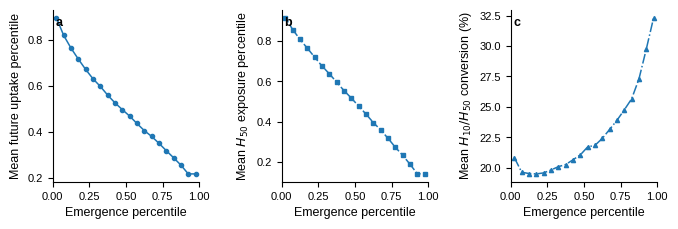

   ✅ Fig3_hubness_decomposition

FIGURE 4 — k/K robustness


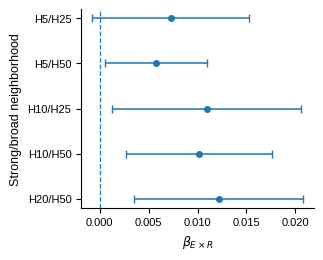

   ✅ Fig4_diffusion_kK_robustness

FIGURE 5 — Primary process models


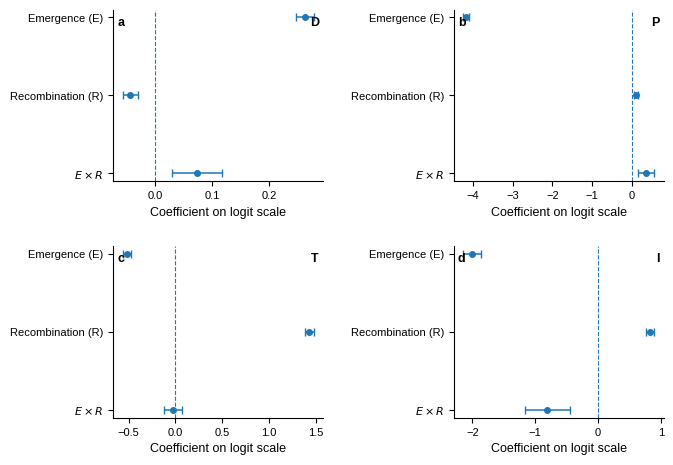

   ✅ Fig5_primary_process_models

FIGURE S1 — Marginal change E by R


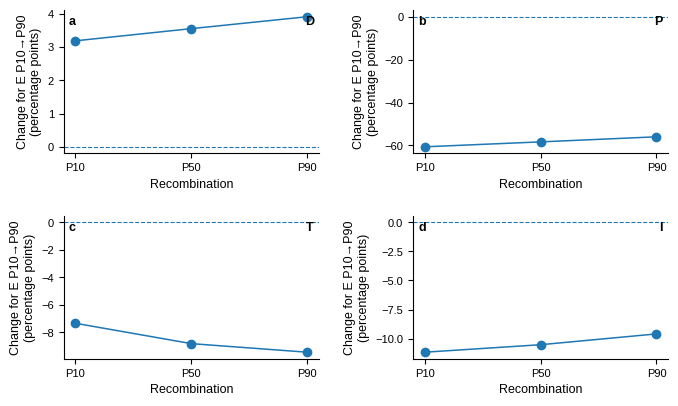

   ✅ FigS1_marginal_change_E_by_R

TABLE 1 — Operational definitions
TABLE 2 — Primary process models
TABLE 3 — Diffusion sensitivity

TABLE 1 — OPERATIONAL DEFINITIONS
               Dimension                                                            Operational measure Temporal window                            Analytical population      N                      Primary model
           Emergence (E)       Area-year percentile of semantic distance from the recent prior frontier t-3 to t-1 -> t           All focal MAIN-44 documents, 2016-2021 459177                          Predictor
       Recombination (R) Area-year percentile of disciplinary entropy among top-10 semantic antecedents t-3 to t-1 -> t           All focal MAIN-44 documents, 2016-2021 459177                          Predictor
           Diffusion (D)                                           Conditional semantic uptake: H10/H50      t+1 to t+3                           Documents with H50 > 0 427649                   Grou

In [3]:
# =====================================================================
# CAPES / SCIENTOMETRICS
# ASSETS FINAIS GERADOS NO COLAB
#
# AMBIENTE: CPU — GPU NÃO NECESSÁRIA
#
# IMPORTANTE:
#   Fig. 1 e Fig. 2 NÃO são produzidas aqui.
#   Elas serão produzidas diretamente para o pacote final do manuscrito.
#
# ESTE SCRIPT PRODUZ:
#
# FIGURAS
#   Fig3  Hubness decomposition
#   Fig4  k/K robustness of conditional semantic uptake
#   Fig5  Primary process models
#   FigS1 Marginal change of E by R
#
# TABELAS
#   Table1 Operational definitions
#   Table2 Primary process models
#   Table3 Diffusion k/K sensitivity
#
# FORMATOS DAS FIGURAS
#   PNG 600 dpi
#   PDF vetorial
#   EPS vetorial
#
# TABELAS
#   CSV
#   fragmentos LaTeX
#
# Todas as figuras são mostradas inline no Colab.
# =====================================================================


print(
    "▶ GERANDO ASSETS FINAIS DO COLAB — SEM FIG. 1 E FIG. 2...",
    flush=True
)


# =====================================================================
# 1. IMPORTAÇÕES
# =====================================================================

from pathlib import Path
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager


# =====================================================================
# 2. PATHS
# =====================================================================

DRIVE = Path(
    "/content/drive/MyDrive"
)


if not DRIVE.exists():

    from google.colab import drive

    drive.mount(
        "/content/drive"
    )


BASE = (
    DRIVE
    /
    "CAPES_Epistemic_Change"
)


PANEL_FILE = (
    BASE
    /
    "29_auditoria_hubness_semantic_exposure"
    /
    "CAPES_ETS_MAIN44_COM_HUBNESS_2016_2021.parquet"
)


K_COEF_FILE = (
    BASE
    /
    "31_sensibilidade_diffusion_k"
    /
    "sensibilidade_kK_coeficientes.csv"
)


ROB_COEF_FILE = (
    BASE
    /
    "32_robustez_familias_ETS"
    /
    "robustez_familias_coeficientes.csv"
)


ROB_MARG_FILE = (
    BASE
    /
    "32_robustez_familias_ETS"
    /
    "robustez_familias_E_P10_P90.csv"
)


T_COEF_FILE = (
    BASE
    /
    "33_translation_estimand_check"
    /
    "translation_fractional_logit_document_level.csv"
)


T_MARG_FILE = (
    BASE
    /
    "33_translation_estimand_check"
    /
    "translation_fractional_logit_marginal_E.csv"
)


# ---------------------------------------------------------------------
# NOVA PASTA.
# Não modifica nem apaga a pasta 34.
# ---------------------------------------------------------------------

OUT = (
    BASE
    /
    "35_manuscript_assets_final_colab"
)


FIG_DIR = (
    OUT
    /
    "figures"
)


TAB_DIR = (
    OUT
    /
    "tables"
)


TXT_DIR = (
    OUT
    /
    "captions_and_notes"
)


for folder in [
    OUT,
    FIG_DIR,
    TAB_DIR,
    TXT_DIR,
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# =====================================================================
# 3. CHECAR ARQUIVOS
# =====================================================================

required = [

    PANEL_FILE,
    K_COEF_FILE,
    ROB_COEF_FILE,
    ROB_MARG_FILE,
    T_COEF_FILE,
    T_MARG_FILE,
]


missing = [

    str(
        x
    )

    for x in required

    if not x.exists()
]


if missing:

    raise FileNotFoundError(

        "Arquivos ausentes:\n"
        +
        "\n".join(
            missing
        )
    )


# =====================================================================
# 4. ESTILO EDITORIAL
# =====================================================================

available_fonts = {

    f.name

    for f
    in font_manager.fontManager.ttflist
}


if "Arial" in available_fonts:

    FONT = "Arial"

elif "Liberation Sans" in available_fonts:

    FONT = "Liberation Sans"

else:

    FONT = "DejaVu Sans"


plt.rcParams.update(
    {
        "font.family":
            FONT,

        "font.size":
            9,

        "axes.labelsize":
            9,

        "xtick.labelsize":
            8,

        "ytick.labelsize":
            8,

        "legend.fontsize":
            8,

        "lines.linewidth":
            1.1,

        "pdf.fonttype":
            42,

        "ps.fonttype":
            42,

        "axes.grid":
            False,

        "figure.facecolor":
            "white",

        "axes.facecolor":
            "white",
    }
)


MM = (
    1
    /
    25.4
)


FULL_WIDTH = (
    174
    *
    MM
)


COLUMN_WIDTH = (
    84
    *
    MM
)


# =====================================================================
# 5. FUNÇÃO PARA SALVAR E EXIBIR
# =====================================================================

def save_show(
    fig,
    stem,
    dpi=600
):

    png = (
        FIG_DIR
        /
        f"{stem}.png"
    )

    pdf = (
        FIG_DIR
        /
        f"{stem}.pdf"
    )

    eps = (
        FIG_DIR
        /
        f"{stem}.eps"
    )


    fig.savefig(
        png,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white"
    )


    fig.savefig(
        pdf,
        bbox_inches="tight",
        facecolor="white"
    )


    fig.savefig(
        eps,
        bbox_inches="tight",
        facecolor="white"
    )


    plt.show()

    plt.close(
        fig
    )


    print(
        f"   ✅ {stem}",
        flush=True
    )


# =====================================================================
# 6. CARREGAR RESULTADOS
# =====================================================================

panel = pd.read_parquet(
    PANEL_FILE
)


kcoef = pd.read_csv(
    K_COEF_FILE
)


robcoef = pd.read_csv(
    ROB_COEF_FILE
)


robmarg = pd.read_csv(
    ROB_MARG_FILE
)


tcoef = pd.read_csv(
    T_COEF_FILE
)


tmarg = pd.read_csv(
    T_MARG_FILE
)


if len(
    panel
) != 459_177:

    raise RuntimeError(

        f"N painel inesperado: "
        f"{len(panel):,}"
    )


if panel[
    "AREA_RAW_NORM"
].nunique() != 44:

    raise RuntimeError(
        "Painel não possui 44 áreas."
    )


print(
    f"✅ Painel carregado: "
    f"{len(panel):,}",
    flush=True
)


# =====================================================================
# 7. FIGURE 3
# HUBNESS DECOMPOSITION
# =====================================================================

print(
    "\nFIGURE 3 — Hubness decomposition",
    flush=True
)


tmp = panel[
    [
        "E_PCT_AREA_ANO",
        "D_PCT_AREA_ANO",
        "H50_PCT_AREA_ANO",
        "D10_GIVEN_H50_RATE",
    ]
].copy()


# 20 intervalos iguais da distribuição percentílica de Emergence.
edges = np.linspace(
    0,
    1,
    21
)


tmp[
    "E_BIN"
] = pd.cut(

    tmp[
        "E_PCT_AREA_ANO"
    ],

    bins=edges,

    include_lowest=True,

    labels=False
)


binned = (

    tmp

    .groupby(
        "E_BIN",
        observed=True
    )

    .agg(

        E_MEAN=(
            "E_PCT_AREA_ANO",
            "mean"
        ),

        D_MEAN=(
            "D_PCT_AREA_ANO",
            "mean"
        ),

        H50_MEAN=(
            "H50_PCT_AREA_ANO",
            "mean"
        ),

        CONV_MEAN=(
            "D10_GIVEN_H50_RATE",
            "mean"
        ),

        N=(
            "E_PCT_AREA_ANO",
            "size"
        ),
    )

    .reset_index()
)


fig, axes = plt.subplots(

    1,
    3,

    figsize=(
        FULL_WIDTH,
        60 * MM
    ),

    sharex=True
)


# ---------------------------------------------------------------------
# a — Raw future uptake
# ---------------------------------------------------------------------

axes[
    0
].plot(

    binned[
        "E_MEAN"
    ],

    binned[
        "D_MEAN"
    ],

    marker="o",

    markersize=3
)


axes[
    0
].set_xlabel(
    "Emergence percentile"
)


axes[
    0
].set_ylabel(
    "Mean future uptake percentile"
)


axes[
    0
].text(

    0.02,
    0.96,
    "a",

    transform=
        axes[
            0
        ].transAxes,

    va="top",

    fontweight="bold"
)


# ---------------------------------------------------------------------
# b — Semantic exposure / hubness
# ---------------------------------------------------------------------

axes[
    1
].plot(

    binned[
        "E_MEAN"
    ],

    binned[
        "H50_MEAN"
    ],

    marker="s",

    markersize=3,

    linestyle="--"
)


axes[
    1
].set_xlabel(
    "Emergence percentile"
)


axes[
    1
].set_ylabel(
    "Mean $H_{50}$ exposure percentile"
)


axes[
    1
].text(

    0.02,
    0.96,
    "b",

    transform=
        axes[
            1
        ].transAxes,

    va="top",

    fontweight="bold"
)


# ---------------------------------------------------------------------
# c — Conditional semantic uptake
# ---------------------------------------------------------------------

axes[
    2
].plot(

    binned[
        "E_MEAN"
    ],

    binned[
        "CONV_MEAN"
    ]
    *
    100,

    marker="^",

    markersize=3,

    linestyle="-."
)


axes[
    2
].set_xlabel(
    "Emergence percentile"
)


axes[
    2
].set_ylabel(
    "Mean $H_{10}/H_{50}$ conversion (%)"
)


axes[
    2
].text(

    0.02,
    0.96,
    "c",

    transform=
        axes[
            2
        ].transAxes,

    va="top",

    fontweight="bold"
)


for axx in axes:

    axx.spines[
        "top"
    ].set_visible(
        False
    )

    axx.spines[
        "right"
    ].set_visible(
        False
    )

    axx.set_xlim(
        0,
        1
    )


fig.tight_layout(
    w_pad=2.0
)


save_show(
    fig,
    "Fig3_hubness_decomposition"
)


del tmp

gc.collect()


# =====================================================================
# 8. FIGURE 4
# k/K ROBUSTNESS
# =====================================================================

print(
    "\nFIGURE 4 — k/K robustness",
    flush=True
)


inter = kcoef[
    kcoef[
        "VARIABLE"
    ]
    ==
    "E_X_R"
].copy()


inter[
    "LABEL"
] = (

    "H"
    +
    inter[
        "STRONG_K"
    ]
    .astype(
        int
    )
    .astype(
        str
    )

    +

    "/H"

    +

    inter[
        "BROAD_K"
    ]
    .astype(
        int
    )
    .astype(
        str
    )
)


desired_order = [

    "H5/H25",
    "H5/H50",
    "H10/H25",
    "H10/H50",
    "H20/H50",
]


inter[
    "LABEL"
] = pd.Categorical(

    inter[
        "LABEL"
    ],

    categories=
        desired_order,

    ordered=True
)


inter = (

    inter

    .sort_values(
        "LABEL"
    )

    .reset_index(
        drop=True
    )
)


fig, ax = plt.subplots(

    figsize=(
        COLUMN_WIDTH,
        68 * MM
    )
)


ypos = np.arange(
    len(
        inter
    )
)


ax.errorbar(

    inter[
        "BETA"
    ],

    ypos,

    xerr=np.vstack(
        [
            inter[
                "BETA"
            ]
            -
            inter[
                "CI95_LOW"
            ],

            inter[
                "CI95_HIGH"
            ]
            -
            inter[
                "BETA"
            ],
        ]
    ),

    fmt="o",

    capsize=3,

    markersize=4
)


ax.axvline(

    0,

    linewidth=0.9,

    linestyle="--"
)


ax.set_yticks(
    ypos
)


ax.set_yticklabels(
    inter[
        "LABEL"
    ]
)


ax.invert_yaxis()


ax.set_xlabel(
    r"$\beta_{E\times R}$"
)


ax.set_ylabel(
    "Strong/broad neighborhood"
)


ax.spines[
    "top"
].set_visible(
    False
)


ax.spines[
    "right"
].set_visible(
    False
)


fig.tight_layout()


save_show(
    fig,
    "Fig4_diffusion_kK_robustness"
)


# =====================================================================
# 9. CONSTRUIR BASE DOS MODELOS PRINCIPAIS
# =====================================================================

primary_parts = []


for model, dim, dim_label in [

    (
        "D_GROUPED_BINOMIAL",
        "D",
        "Conditional semantic uptake"
    ),

    (
        "P_LOGIT_T3_GIVEN_T1",
        "P",
        "Persistence"
    ),

    (
        "I_FRACTIONAL_LOGIT",
        "I",
        "Institutional breadth"
    ),
]:

    z = robcoef[
        robcoef[
            "MODEL"
        ]
        ==
        model
    ].copy()


    z[
        "DIMENSION"
    ] = dim


    z[
        "DIMENSION_LABEL"
    ] = dim_label


    primary_parts.append(
        z
    )


# ---------------------------------------------------------------------
# Translation principal:
# document-weighted fractional logit.
# ---------------------------------------------------------------------

zt = tcoef.copy()


zt[
    "MODEL"
] = (
    "T_FRACTIONAL_LOGIT_DOCUMENT"
)


zt[
    "DIMENSION"
] = "T"


zt[
    "DIMENSION_LABEL"
] = "Translation"


primary_parts.append(
    zt
)


primary = pd.concat(

    primary_parts,

    ignore_index=True,

    sort=False
)


var_order = {

    "E_C":
        0,

    "R_C":
        1,

    "E_X_R":
        2,
}


dim_order = {

    "D":
        0,

    "P":
        1,

    "T":
        2,

    "I":
        3,
}


primary[
    "VAR_ORDER"
] = primary[
    "VARIABLE"
].map(
    var_order
)


primary[
    "DIM_ORDER"
] = primary[
    "DIMENSION"
].map(
    dim_order
)


primary = (

    primary

    .sort_values(
        [
            "DIM_ORDER",
            "VAR_ORDER",
        ]
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 10. FIGURE 5
# PRIMARY PROCESS MODELS
# =====================================================================

print(
    "\nFIGURE 5 — Primary process models",
    flush=True
)


fig, axes = plt.subplots(

    2,
    2,

    figsize=(
        FULL_WIDTH,
        120 * MM
    )
)


axes = axes.ravel()


labels = {

    "E_C":
        "Emergence (E)",

    "R_C":
        "Recombination (R)",

    "E_X_R":
        r"$E \times R$",
}


panel_letters = [

    "a",
    "b",
    "c",
    "d",
]


for axx, dim, letter in zip(

    axes,

    [
        "D",
        "P",
        "T",
        "I",
    ],

    panel_letters
):

    z = primary[
        primary[
            "DIMENSION"
        ]
        ==
        dim
    ].copy()


    z = z.sort_values(
        "VAR_ORDER"
    )


    yy = np.arange(
        len(
            z
        )
    )


    axx.errorbar(

        z[
            "BETA"
        ],

        yy,

        xerr=np.vstack(
            [
                z[
                    "BETA"
                ]
                -
                z[
                    "CI95_LOW"
                ],

                z[
                    "CI95_HIGH"
                ]
                -
                z[
                    "BETA"
                ],
            ]
        ),

        fmt="o",

        capsize=3,

        markersize=4
    )


    axx.axvline(

        0,

        linewidth=0.8,

        linestyle="--"
    )


    axx.set_yticks(
        yy
    )


    axx.set_yticklabels(
        [
            labels[
                x
            ]

            for x
            in z[
                "VARIABLE"
            ]
        ]
    )


    axx.invert_yaxis()


    axx.set_xlabel(
        "Coefficient on logit scale"
    )


    axx.text(

        0.02,
        0.96,
        letter,

        transform=
            axx.transAxes,

        va="top",

        fontweight="bold"
    )


    axx.text(

        0.98,
        0.96,
        dim,

        transform=
            axx.transAxes,

        ha="right",

        va="top",

        fontweight="bold"
    )


    axx.spines[
        "top"
    ].set_visible(
        False
    )


    axx.spines[
        "right"
    ].set_visible(
        False
    )


fig.tight_layout(
    h_pad=2.2,
    w_pad=2.2
)


save_show(
    fig,
    "Fig5_primary_process_models"
)


# =====================================================================
# 11. FIGURE S1
# MARGINAL CHANGE E P10 → P90 BY R
# =====================================================================

print(
    "\nFIGURE S1 — Marginal change E by R",
    flush=True
)


marg_parts = []


for model, dim in [

    (
        "D_GROUPED_BINOMIAL",
        "D"
    ),

    (
        "P_LOGIT_T3_GIVEN_T1",
        "P"
    ),

    (
        "I_FRACTIONAL_LOGIT",
        "I"
    ),
]:

    z = robmarg[
        robmarg[
            "MODEL"
        ]
        ==
        model
    ].copy()


    z[
        "DIMENSION"
    ] = dim


    marg_parts.append(

        z[
            [
                "DIMENSION",
                "R_PERCENTILE",
                "E_P10_P90_CHANGE_PP",
            ]
        ]
    )


zt = tmarg.copy()


zt[
    "DIMENSION"
] = "T"


marg_parts.append(

    zt[
        [
            "DIMENSION",
            "R_PERCENTILE",
            "E_P10_P90_CHANGE_PP",
        ]
    ]
)


marg = pd.concat(

    marg_parts,

    ignore_index=True
)


fig, axes = plt.subplots(

    2,
    2,

    figsize=(
        FULL_WIDTH,
        105 * MM
    )
)


axes = axes.ravel()


for axx, dim, letter in zip(

    axes,

    [
        "D",
        "P",
        "T",
        "I",
    ],

    [
        "a",
        "b",
        "c",
        "d",
    ]
):

    z = marg[
        marg[
            "DIMENSION"
        ]
        ==
        dim
    ].sort_values(
        "R_PERCENTILE"
    )


    axx.plot(

        z[
            "R_PERCENTILE"
        ],

        z[
            "E_P10_P90_CHANGE_PP"
        ],

        marker="o"
    )


    axx.axhline(

        0,

        linewidth=0.8,

        linestyle="--"
    )


    axx.set_xticks(
        [
            0.1,
            0.5,
            0.9,
        ]
    )


    axx.set_xticklabels(
        [
            "P10",
            "P50",
            "P90",
        ]
    )


    axx.set_xlabel(
        "Recombination"
    )


    axx.set_ylabel(
        "Change for E P10→P90\n"
        "(percentage points)"
    )


    axx.text(

        0.02,
        0.96,
        letter,

        transform=
            axx.transAxes,

        va="top",

        fontweight="bold"
    )


    axx.text(

        0.98,
        0.96,
        dim,

        transform=
            axx.transAxes,

        ha="right",

        va="top",

        fontweight="bold"
    )


    axx.spines[
        "top"
    ].set_visible(
        False
    )


    axx.spines[
        "right"
    ].set_visible(
        False
    )


fig.tight_layout(
    h_pad=2.0,
    w_pad=2.0
)


save_show(
    fig,
    "FigS1_marginal_change_E_by_R"
)


# =====================================================================
# 12. TABLE 1
# OPERATIONAL DEFINITIONS
# =====================================================================

print(
    "\nTABLE 1 — Operational definitions",
    flush=True
)


table1 = pd.DataFrame(
    [
        {
            "Dimension":
                "Emergence (E)",

            "Operational measure":
                (
                    "Area-year percentile of semantic distance "
                    "from the recent prior frontier"
                ),

            "Temporal window":
                "t-3 to t-1 -> t",

            "Analytical population":
                (
                    "All focal MAIN-44 documents, "
                    "2016-2021"
                ),

            "N":
                459_177,

            "Primary model":
                "Predictor",
        },

        {
            "Dimension":
                "Recombination (R)",

            "Operational measure":
                (
                    "Area-year percentile of disciplinary entropy "
                    "among top-10 semantic antecedents"
                ),

            "Temporal window":
                "t-3 to t-1 -> t",

            "Analytical population":
                (
                    "All focal MAIN-44 documents, "
                    "2016-2021"
                ),

            "N":
                459_177,

            "Primary model":
                "Predictor",
        },

        {
            "Dimension":
                "Diffusion (D)",

            "Operational measure":
                (
                    "Conditional semantic uptake: "
                    "H10/H50"
                ),

            "Temporal window":
                "t+1 to t+3",

            "Analytical population":
                "Documents with H50 > 0",

            "N":
                427_649,

            "Primary model":
                "Grouped binomial",
        },

        {
            "Dimension":
                "Persistence (P)",

            "Operational measure":
                (
                    "Presence of uptake at t+3 "
                    "conditional on uptake at t+1"
                ),

            "Temporal window":
                "t+1 -> t+3",

            "Analytical population":
                "Documents with uptake at t+1",

            "N":
                290_520,

            "Primary model":
                "Binary logit",
        },

        {
            "Dimension":
                "Translation (T)",

            "Operational measure":
                (
                    "Share of future top-10 uptake "
                    "crossing broad disciplinary areas"
                ),

            "Temporal window":
                "t+1 to t+3",

            "Analytical population":
                (
                    "Documents with at least one "
                    "future top-10 uptake"
                ),

            "N":
                363_690,

            "Primary model":
                "Document-weighted fractional logit",
        },

        {
            "Dimension":
                "Institutionalization (I)",

            "Operational measure":
                (
                    "Pairwise diversity of postgraduate programs "
                    "among future uptake events"
                ),

            "Temporal window":
                "t+1 to t+3",

            "Analytical population":
                (
                    "Documents with at least two "
                    "future uptake events"
                ),

            "N":
                302_956,

            "Primary model":
                "Fractional logit",
        },
    ]
)


TABLE1_CSV = (
    TAB_DIR
    /
    "Table1_operational_definitions.csv"
)


table1.to_csv(
    TABLE1_CSV,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 13. TABLE 2
# PRIMARY PROCESS MODELS
# =====================================================================

print(
    "TABLE 2 — Primary process models",
    flush=True
)


parameter_labels = {

    "E_C":
        "Emergence (E)",

    "R_C":
        "Recombination (R)",

    "E_X_R":
        "E × R",
}


table2 = primary[
    [
        "DIMENSION",
        "DIMENSION_LABEL",
        "VARIABLE",
        "BETA",
        "SE_CLUSTER",
        "CI95_LOW",
        "CI95_HIGH",
        "P_VALUE",
        "N",
        "N_PPG",
    ]
].copy()


table2[
    "Parameter"
] = table2[
    "VARIABLE"
].map(
    parameter_labels
)


table2[
    "Estimate"
] = table2[
    "BETA"
]


table2[
    "SE"
] = table2[
    "SE_CLUSTER"
]


table2[
    "95% CI"
] = (

    "["

    +

    table2[
        "CI95_LOW"
    ].map(
        lambda x:
            f"{x:.3f}"
    )

    +

    ", "

    +

    table2[
        "CI95_HIGH"
    ].map(
        lambda x:
            f"{x:.3f}"
    )

    +

    "]"
)


def fmt_p(
    p
):

    if p < 0.001:

        return "<0.001"

    return f"{p:.3f}"


table2[
    "p"
] = table2[
    "P_VALUE"
].map(
    fmt_p
)


table2_final = table2[
    [
        "DIMENSION",
        "DIMENSION_LABEL",
        "Parameter",
        "Estimate",
        "SE",
        "95% CI",
        "p",
        "N",
        "N_PPG",
    ]
].copy()


TABLE2_CSV = (
    TAB_DIR
    /
    "Table2_primary_process_models.csv"
)


table2_final.to_csv(
    TABLE2_CSV,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 14. TABLE 3
# DIFFUSION k/K SENSITIVITY
# =====================================================================

print(
    "TABLE 3 — Diffusion sensitivity",
    flush=True
)


kE = kcoef[
    kcoef[
        "VARIABLE"
    ]
    ==
    "E_C"
][
    [
        "STRONG_K",
        "BROAD_K",
        "BETA",
    ]
].rename(
    columns={
        "BETA":
            "Beta_E"
    }
)


kR = kcoef[
    kcoef[
        "VARIABLE"
    ]
    ==
    "R_C"
][
    [
        "STRONG_K",
        "BROAD_K",
        "BETA",
    ]
].rename(
    columns={
        "BETA":
            "Beta_R"
    }
)


kI = kcoef[
    kcoef[
        "VARIABLE"
    ]
    ==
    "E_X_R"
][
    [
        "STRONG_K",
        "BROAD_K",
        "BETA",
        "CI95_LOW",
        "CI95_HIGH",
        "P_VALUE",
        "N",
        "MEAN_CONVERSION",
    ]
].rename(
    columns={
        "BETA":
            "Beta_ExR"
    }
)


table3 = (

    kI

    .merge(
        kE,
        on=[
            "STRONG_K",
            "BROAD_K",
        ],
        how="left"
    )

    .merge(
        kR,
        on=[
            "STRONG_K",
            "BROAD_K",
        ],
        how="left"
    )
)


table3[
    "Definition"
] = (

    "H"

    +

    table3[
        "STRONG_K"
    ].astype(
        int
    ).astype(
        str
    )

    +

    "/H"

    +

    table3[
        "BROAD_K"
    ].astype(
        int
    ).astype(
        str
    )
)


table3[
    "Interaction 95% CI"
] = (

    "["

    +

    table3[
        "CI95_LOW"
    ].map(
        lambda x:
            f"{x:.3f}"
    )

    +

    ", "

    +

    table3[
        "CI95_HIGH"
    ].map(
        lambda x:
            f"{x:.3f}"
    )

    +

    "]"
)


table3[
    "p interaction"
] = table3[
    "P_VALUE"
].map(
    fmt_p
)


table3_final = table3[
    [
        "Definition",
        "N",
        "MEAN_CONVERSION",
        "Beta_E",
        "Beta_R",
        "Beta_ExR",
        "Interaction 95% CI",
        "p interaction",
    ]
].copy()


TABLE3_CSV = (
    TAB_DIR
    /
    "Table3_diffusion_kK_sensitivity.csv"
)


table3_final.to_csv(
    TABLE3_CSV,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 15. FUNÇÃO PARA TEXTO LATEX
# =====================================================================

def esc_tex(
    x
):

    x = str(
        x
    )


    replacements = {

        "&":
            r"\&",

        "%":
            r"\%",

        "_":
            r"\_",

        "#":
            r"\#",
    }


    for old, new in replacements.items():

        x = x.replace(
            old,
            new
        )


    return x


# =====================================================================
# 16. TABLE 1 — LATEX
# =====================================================================

t1 = [

    r"\begin{table*}[ht]",

    r"\caption{Operational definition of the Epistemic Transition Signature dimensions}",

    r"\label{tab:operational}",

    r"\centering",

    r"\small",

    r"\begin{tabular}{p{2.6cm}p{5.2cm}p{2.0cm}p{4.2cm}r}",

    r"\hline",

    r"Dimension & Operational measure & Window & Analytical population & $N$ \\",

    r"\hline",
]


for _, r in table1.iterrows():

    t1.append(

        "{} & {} & {} & {} & {:,} \\\\".format(

            esc_tex(
                r[
                    "Dimension"
                ]
            ),

            esc_tex(
                r[
                    "Operational measure"
                ]
            ),

            esc_tex(
                r[
                    "Temporal window"
                ]
            ),

            esc_tex(
                r[
                    "Analytical population"
                ]
            ),

            int(
                r[
                    "N"
                ]
            )
        )
    )


t1.extend(
    [
        r"\hline",
        r"\end{tabular}",
        r"\end{table*}",
    ]
)


TABLE1_TEX = (
    TAB_DIR
    /
    "Table1_operational_definitions.tex"
)


TABLE1_TEX.write_text(
    "\n".join(
        t1
    ),
    encoding="utf-8"
)


# =====================================================================
# 17. TABLE 2 — LATEX
# =====================================================================

t2 = [

    r"\begin{table*}[ht]",

    r"\caption{Primary prospective models of Epistemic Transition Signature dimensions}",

    r"\label{tab:primarymodels}",

    r"\centering",

    r"\small",

    r"\begin{tabular}{llrrrrr}",

    r"\hline",

    r"Outcome & Parameter & Estimate & SE & 95\% CI & $p$ & $N$ \\",

    r"\hline",
]


last_dim = None


for _, r in table2_final.iterrows():

    dim_label = (

        r[
            "DIMENSION"
        ]

        if r[
            "DIMENSION"
        ] != last_dim

        else ""
    )


    t2.append(

        "{} & {} & {:.3f} & {:.3f} & {} & {} & {:,} \\\\".format(

            esc_tex(
                dim_label
            ),

            esc_tex(
                r[
                    "Parameter"
                ]
            ),

            float(
                r[
                    "Estimate"
                ]
            ),

            float(
                r[
                    "SE"
                ]
            ),

            esc_tex(
                r[
                    "95% CI"
                ]
            ),

            esc_tex(
                r[
                    "p"
                ]
            ),

            int(
                r[
                    "N"
                ]
            )
        )
    )


    last_dim = r[
        "DIMENSION"
    ]


t2.extend(
    [
        r"\hline",

        (
            r"\multicolumn{7}{p{16cm}}{\footnotesize "
            r"Notes: D, grouped binomial conditional semantic uptake "
            r"($H_{10}/H_{50}$); P, logistic persistence at $t+3$ "
            r"conditional on uptake at $t+1$; T, document-weighted "
            r"fractional logistic translation; I, fractional logistic "
            r"pairwise institutional diversity. All models include "
            r"area-by-year fixed effects, academic-degree controls, "
            r"log program-year size, and standard errors clustered by "
            r"postgraduate program.} \\"
        ),

        r"\end{tabular}",

        r"\end{table*}",
    ]
)


TABLE2_TEX = (
    TAB_DIR
    /
    "Table2_primary_process_models.tex"
)


TABLE2_TEX.write_text(
    "\n".join(
        t2
    ),
    encoding="utf-8"
)


# =====================================================================
# 18. TABLE 3 — LATEX
# =====================================================================

t3 = [

    r"\begin{table*}[ht]",

    r"\caption{Sensitivity of conditional semantic uptake to strong and broad neighborhood thresholds}",

    r"\label{tab:diffusionsensitivity}",

    r"\centering",

    r"\small",

    r"\begin{tabular}{lrrrrrr}",

    r"\hline",

    (
        r"Definition & $N$ & Mean conversion & "
        r"$\beta_E$ & $\beta_R$ & "
        r"$\beta_{E\times R}$ & 95\% CI \\"
    ),

    r"\hline",
]


for _, r in table3_final.iterrows():

    t3.append(

        "{} & {:,} & {:.3f} & {:.3f} & {:.3f} & {:.3f} & {} \\\\".format(

            esc_tex(
                r[
                    "Definition"
                ]
            ),

            int(
                r[
                    "N"
                ]
            ),

            float(
                r[
                    "MEAN_CONVERSION"
                ]
            ),

            float(
                r[
                    "Beta_E"
                ]
            ),

            float(
                r[
                    "Beta_R"
                ]
            ),

            float(
                r[
                    "Beta_ExR"
                ]
            ),

            esc_tex(
                r[
                    "Interaction 95% CI"
                ]
            )
        )
    )


t3.extend(
    [
        r"\hline",
        r"\end{tabular}",
        r"\end{table*}",
    ]
)


TABLE3_TEX = (
    TAB_DIR
    /
    "Table3_diffusion_kK_sensitivity.tex"
)


TABLE3_TEX.write_text(
    "\n".join(
        t3
    ),
    encoding="utf-8"
)


# =====================================================================
# 19. CAPTIONS SOMENTE DAS FIGURAS GERADAS NO COLAB
# =====================================================================

captions = r"""
\textbf{Fig. 3} Decomposition of prospective semantic uptake into geometric exposure and conditional uptake. Points represent means within 20 equal-width bins of the area-year Emergence percentile. Panel a shows raw future top-10 uptake rank, panel b semantic exposure/hubness measured using future top-50 inclusion, and panel c conditional semantic uptake measured as H10/H50 among exposed documents. The strong negative association between Emergence and raw uptake largely follows the association between Emergence and semantic exposure, whereas conditional uptake exhibits a different pattern

\textbf{Fig. 4} Sensitivity of the Emergence-by-Recombination interaction in conditional semantic uptake to alternative strong/broad neighborhood definitions. Points show interaction coefficients and bars show 95\% confidence intervals from H50-weighted models restricted to at least five broad-neighborhood exposures. H10/H50 is the primary operationalization

\textbf{Fig. 5} Coefficients from the primary prospective process models. Points show coefficients and bars show 95\% confidence intervals for Emergence, Recombination, and their interaction. D is modeled using grouped-binomial conditional semantic uptake (H10/H50); P using logistic persistence at t+3 conditional on uptake at t+1; T using document-weighted fractional logistic translation across broad disciplinary areas; and I using fractional logistic pairwise institutional diversity. Coefficients are reported on the logit scale

\textbf{Fig. S1} Model-based change associated with increasing Emergence from the 10th to the 90th percentile at low, median, and high levels of Recombination. Values are average predicted percentage-point changes from the primary D, P, T, and I models
""".strip()


CAPTION_FILE = (
    TXT_DIR
    /
    "captions_colab_figures.tex"
)


CAPTION_FILE.write_text(
    captions,
    encoding="utf-8"
)


# =====================================================================
# 20. NOTAS METODOLÓGICAS PARA AS TABELAS
# =====================================================================

notes = r"""
Table 1 reports the operational definitions, temporal windows, and analysis-specific risk sets for the six Epistemic Transition Signature dimensions.

Table 2 uses the primary estimand for each prospective outcome. Translation is represented by the document-weighted fractional logit. The edge-weighted grouped-binomial specification is retained only as a sensitivity analysis because the direction of the Emergence-by-Recombination interaction depends on the estimand.

Table 3 evaluates whether the interaction observed for conditional semantic uptake depends on the choice of strong and broad semantic-neighborhood thresholds. H10/H50 remains the primary definition; H5/H25, H5/H50, H10/H25, and H20/H50 are sensitivity analyses.

All models are associational. Future semantic-neighbor inclusion is interpreted as prospective semantic uptake or proximity rather than citation, adoption, impact, or causal influence.
""".strip()


NOTE_FILE = (
    TXT_DIR
    /
    "table_notes_final.txt"
)


NOTE_FILE.write_text(
    notes,
    encoding="utf-8"
)


# =====================================================================
# 21. PRINT TABLES INLINE
# =====================================================================

print(
    "\n"
    +
    "=" * 120
)


print(
    "TABLE 1 — OPERATIONAL DEFINITIONS"
)


print(
    "=" * 120
)


print(
    table1.to_string(
        index=False
    )
)


print(
    "\n"
    +
    "=" * 120
)


print(
    "TABLE 2 — PRIMARY PROCESS MODELS"
)


print(
    "=" * 120
)


print(

    table2_final[
        [
            "DIMENSION",
            "Parameter",
            "Estimate",
            "SE",
            "95% CI",
            "p",
            "N",
        ]
    ]

    .round(
        {
            "Estimate":
                4,

            "SE":
                4,
        }
    )

    .to_string(
        index=False
    )
)


print(
    "\n"
    +
    "=" * 120
)


print(
    "TABLE 3 — DIFFUSION k/K SENSITIVITY"
)


print(
    "=" * 120
)


print(

    table3_final

    .round(
        {
            "MEAN_CONVERSION":
                4,

            "Beta_E":
                4,

            "Beta_R":
                4,

            "Beta_ExR":
                4,
        }
    )

    .to_string(
        index=False
    )
)


# =====================================================================
# 22. MANIFEST
# =====================================================================

manifest = []


for p in sorted(
    OUT.rglob(
        "*"
    )
):

    if p.is_file():

        manifest.append(
            {
                "file":
                    str(
                        p.relative_to(
                            OUT
                        )
                    ),

                "size_kb":
                    round(
                        p.stat().st_size
                        /
                        1024,
                        1
                    ),
            }
        )


manifest_df = pd.DataFrame(
    manifest
)


MANIFEST_FILE = (
    OUT
    /
    "asset_manifest.csv"
)


manifest_df.to_csv(
    MANIFEST_FILE,
    index=False,
    encoding="utf-8-sig"
)


# =====================================================================
# 23. RESULTADO
# =====================================================================

print(
    "\n"
    +
    "=" * 120
)


print(
    "ASSETS FINAIS GERADOS NO COLAB"
)


print(
    "=" * 120
)


print(
    manifest_df.to_string(
        index=False
    )
)


print(
    "\nPasta:"
)


print(
    OUT
)


print(
    "\n✅ FIG. 3 GERADA."
)


print(
    "✅ FIG. 4 GERADA."
)


print(
    "✅ FIG. 5 GERADA."
)


print(
    "✅ FIG. S1 GERADA."
)


print(
    "✅ TABLES 1–3 GERADAS."
)


print(
    "=" * 120
)